In [1]:
  # This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import types
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from textwrap import wrap
sns.set_style('whitegrid')  # or any other seaborn style

from textwrap import wrap
from datetime import datetime
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
# Or for full screen width in Jupyter:
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')
plt.rcParams['figure.figsize'] = [15, 8]
plt.rcParams['figure.dpi'] = 100
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/paretto-products/data2.csv
/kaggle/input/world-cities/worldcities.csv


/tmp/ipykernel_13/25782273.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


In [2]:
# !pip install -U kaleido
!pip install -U plotly
import plotly.graph_objects as go
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 69.5 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [3]:
# import plotly.io as pio

# # Set renderer to SVG for static output
# pio.renderers.default = 'svg'

# Exploring Data

The ga_sessions_* data from Google Analytics 360 exported to BigQuery generally represents:

✅ A complete log of user sessions on your website, broken down at:

the session level

the hit level (individual actions per session like pageviews, events, transactions)

✅ Core Concepts in This Data
Level	Represents	Key Tables/Fields

* User level	Unique users across time	fullVisitorId, userId

* Session level	A single visit to the site	visitId, visitNumber, trafficSource, totals

* Hit level	Individual actions in a session	hits.type, hits.page.pagePath, hits.eventInfo

* Ecommerce	Purchase interactions	hits.eCommerceAction, hits.product

* Traffic metadata	Where traffic came from	trafficSource.medium, trafficSource.source

* Geo info	Visitor location	geoNetwork.country, geoNetwork.city

* Device & tech	User's device/browser	device.category, device.operatingSystem

✅ In Business Terms, This Data Allows  To:


Use Case	Metrics / Fields

* Traffic Analysis	Sessions, Users, Pageviews 

* User Behavior	Bounce rate, pages/session, session duration

* Funnel Analysis	Product views → Add to cart → Purchase (via hits.eCommerceAction)

* Sales & Revenue	totals.totalTransactionRevenue (in micros)

* Conversion Metrics	Transactions, conversion rate

* Source/Medium Analysis	Understand which campaigns or sources are effective

* Geo & Device Insights	Performance by country, device type

* Cohort / Retention	With some modeling, you can analyze user retention by fullVisitorId




**Below a larger view for each field and its magnitude**

https://support.google.com/analytics/answer/3437719?hl=en


**✅ In the Below lines we will concentrate more on User Behavior metrics and revenue statistics , Analyzing them by Time , Geographical levels , product , user type level , device category , and traffic type.**


In [4]:
import bq_helper
from bq_helper import BigQueryHelper
# https://www.kaggle.com/sohier/introduction-to-the-bq-helper-package
google_analytics = bq_helper.BigQueryHelper(active_project="bigquery-public-data",
                                   dataset_name="data:google_analytics_sample")

Using Kaggle's public dataset BigQuery integration.


In [5]:
import warnings
warnings.filterwarnings('ignore')
cities = pd.read_csv("/kaggle/input/world-cities/worldcities.csv")

In [6]:
google_analytics

In [7]:
bq_assistant = BigQueryHelper("bigquery-public-data", "google_analytics_sample")


Using Kaggle's public dataset BigQuery integration.


## Exploring Data

Let's query over an example table 

In [8]:

QUERY = """
    SELECT * 
    FROM bigquery-public-data.google_analytics_sample.ga_sessions_20170801
"""
df = bq_assistant.query_to_pandas(QUERY)

In [9]:
df.head()

,visitorId,visitNumber,visitId,visitStartTime,date,totals,trafficSource,device,geoNetwork,customDimensions,hits,fullVisitorId,userId,clientId,channelGrouping,socialEngagementType
0,<NA>,1,1501591568,1501591568,20170801,"{'visits': 1, 'hits': 1, 'pageviews': 1, 'time...","{'referralPath': None, 'campaign': '(not set)'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Europe', 'subContinent': 'South...",[],"[{'hitNumber': 1, 'time': 0, 'hour': 5, 'minut...",3418334011779872055,None,None,Organic Search,Not Socially Engaged
1,<NA>,2,1501589647,1501589647,20170801,"{'visits': 1, 'hits': 1, 'pageviews': 1, 'time...","{'referralPath': '/analytics/web/', 'campaign'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Asia', 'subContinent': 'Souther...","[{'index': 4, 'value': 'APAC'}]","[{'hitNumber': 1, 'time': 0, 'hour': 5, 'minut...",2474397855041322408,None,None,Referral,Not Socially Engaged
2,<NA>,1,1501616621,1501616621,20170801,"{'visits': 1, 'hits': 1, 'pageviews': 1, 'time...","{'referralPath': '/analytics/web/', 'campaign'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Europe', 'subContinent': 'North...","[{'index': 4, 'value': 'EMEA'}]","[{'hitNumber': 1, 'time': 0, 'hour': 12, 'minu...",5870462820713110108,None,None,Referral,Not Socially Engaged
3,<NA>,1,1501601200,1501601200,20170801,"{'visits': 1, 'hits': 1, 'pageviews': 1, 'time...","{'referralPath': '/analytics/web/', 'campaign'...","{'browser': 'Firefox', 'browserVersion': 'not ...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 8, 'minut...",9397809171349480379,None,None,Referral,Not Socially Engaged
4,<NA>,1,1501615525,1501615525,20170801,"{'visits': 1, 'hits': 1, 'pageviews': 1, 'time...","{'referralPath': '/analytics/web/', 'campaign'...","{'browser': 'Chrome', 'browserVersion': 'not a...","{'continent': 'Americas', 'subContinent': 'Nor...","[{'index': 4, 'value': 'North America'}]","[{'hitNumber': 1, 'time': 0, 'hour': 12, 'minu...",6089902943184578335,None,None,Referral,Not Socially Engaged


In [10]:
df['socialEngagementType'].value_counts()

socialEngagementType
Not Socially Engaged    2556
Name: count, dtype: int64

Here we notice that data is not that simple

In [11]:
df['continent'] = df['geoNetwork'].str.get('continent')
df['country'] = df['geoNetwork'].str.get('country')

In [12]:
df['visits'] = df['totals'].str.get('visits')

In [13]:
df['pageviews'] = df['totals'].str.get('pageviews')

In [14]:
df['totals'][0]

{'visits': 1,
 'hits': 1,
 'pageviews': 1,
 'timeOnSite': None,
 'bounces': 1,
 'transactions': None,
 'transactionRevenue': None,
 'newVisits': 1,
 'screenviews': None,
 'uniqueScreenviews': None,
 'timeOnScreen': None,
 'totalTransactionRevenue': None,
 'sessionQualityDim': 1}

Here we explore the nested nature of data , this gives us a hint that to correctly query the data, we should un nest fields like hits , products , to get relevant details

## Data Acquisition

Our interest in this notebook , is analyzing products statistics , explore the performance per products in the period from July 2016 to August 2017 , but we also are interested about our query performance.

Here my decision was to use Paretto rule , of the 691 products we get the products that represent 80% of traffic.

**While choosing products with 80% of traffic not of revenue , that we are interested in exploring improvement , so if a product is found in the products that compose 80% of sessions and not making high revenue that's a question mark , an improvement area.**

In [15]:
QUERY = """ with data as (
SELECT
  product.v2ProductName AS product_name,
    COUNT (DISTINCT  CONCAT(fullVisitorId, '.', CAST(visitId AS STRING))) AS sessions  , 
    
FROM
  `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
  UNNEST(hits) AS hits , 
      UNNEST(hits.product) AS product

WHERE
  hits.product IS NOT NULL
  AND hits.page.pagePath IS NOT NULL
GROUP BY
  product_name
ORDER BY
  sessions DESC)

  , ordered_data as ( select * , 

    SUM(sessions) OVER (ORDER BY sessions DESC) AS cumulative_sessions,
    SUM(sessions) OVER () AS total_sessions

    from data
  
  )

  ,
pareto AS (
  SELECT *,
    cumulative_sessions / total_sessions AS cumulative_percentage
  FROM ordered_data
)
SELECT *
FROM pareto
WHERE cumulative_percentage <= 0.80
"""

In [16]:
top_viewed_pages = bq_assistant.query_to_pandas(QUERY)

In [17]:
top_viewed_pages

,product_name,sessions,cumulative_sessions,total_sessions,cumulative_percentage
0,Google Men's Performance Full Zip Jacket Black,49252,5794144,12473159,0.464529
1,Google Men's Microfiber 1/4 Zip Pullover Grey/...,32493,8815243,12473159,0.706737
2,Rocket Flashlight,48671,5940459,12473159,0.476259
3,Ballpoint Stylus Pen,40225,7671402,12473159,0.615033
4,Google Men's 100% Cotton Short Sleeve Hero Tee...,86856,1960013,12473159,0.157138
...,...,...,...,...,...
188,Google Women's 1/4 Zip Jacket Charcoal,32759,8717456,12473159,0.698897
189,Suitcase Organizer Cubes,83535,2384881,12473159,0.191201
190,Leather and Metal Ballpoint Pen,40431,7590942,12473159,0.608582
191,Spiral Notebook and Pen Set,31564,9037956,12473159,0.724592


So of the 691 products we have 193 of them that represent products about which 80% of sessions , this saves query run time without losing much data value.

## Selecting relevant fields

Our analysis of Google Analytics (GA) session data focuses on understanding product performance through two primary lenses:

**User Interaction Metrics**: This includes metrics such as sessions, conversion rates, and bounce rates, providing insights into user engagement and initial product reception.

**Transaction Metrics**: We will examine revenue, transaction volume, and funnel progression to evaluate the effectiveness of the user journey towards conversion.

To gain a comprehensive understanding, these core metrics will be analyzed with consideration for the following influencing factors:

* Temporal Trends: Data will be examined as time series, including an exploration of performance by hour of day, to identify patterns and optimal engagement periods.

* Geographical Location: We will analyze performance based on the geographic origin of sessions to identify regional variations and target specific markets.

* Traffic Acquisition Channel: An investigation into how users arrive at product landing pages will provide insights into the effectiveness of different marketing and acquisition strategies.

* Device Category: Performance will be segmented by device type (mobile, tablet, desktop) to optimize the user experience across various platforms.

* New vs. Returning Visitors: Differentiating between new and returning visitors will help us understand customer loyalty and acquisition effectiveness.

In [18]:
multi_product_query = """



WITH 


general_prods as (SELECT
  product.v2ProductName AS product_name,
    COUNT (DISTINCT  CONCAT(fullVisitorId, '.', CAST(visitId AS STRING))) AS sessions ,

FROM
  `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
  UNNEST(hits) AS hits , 
      UNNEST(hits.product) AS product

WHERE
  hits.product IS NOT NULL
  AND hits.page.pagePath IS NOT NULL
GROUP BY
  product_name
ORDER BY
  sessions DESC
  LIMIT 193)
,

product_data AS (
  SELECT
    EXTRACT(MONTH FROM TIMESTAMP_SECONDS(visitStartTime)) AS month,
    EXTRACT(YEAR FROM TIMESTAMP_SECONDS(visitStartTime)) AS year,
    EXTRACT(HOUR FROM TIMESTAMP_SECONDS(visitStartTime)) AS hour,
    CONCAT(fullVisitorId, '.', CAST(visitId AS STRING)) AS sessionId ,
   CAST (totals.newVisits as numeric) AS newVisits ,
     trafficSource.source AS traffic_source ,
     trafficSource.medium as traffic_medium , 
         totals.timeOnSite AS session_duration_seconds,
    totals.pageviews AS pages_per_session,

     device.deviceCategory ,
    CAST(totals.transactions as NUMERIC) as transactions,
    hits.eCommerceAction.action_type AS ecomAction,
    CAST(totals.bounces as NUMERIC) as bounces , 
    product.v2ProductName AS productName,
    product.v2ProductCategory AS productCategory,
    product.productPrice / 1000000 AS productPrice,
    product.productQuantity,
    product.productRevenue / 1000000 AS productRevenue,
    geoNetwork.country,
    geoNetwork.continent as region,
    geoNetwork.city
  FROM
    `bigquery-public-data.google_analytics_sample.ga_sessions_*` ga,
    UNNEST(hits) AS hits,
    UNNEST(hits.product) AS product

  WHERE

     product.v2ProductName in (select product_name from general_prods)
)

SELECT
  productName,
  traffic_source,
  traffic_medium ,
  newVisits ,
  deviceCategory ,
  productCategory,
  country,
  region ,
  city,
  month,
  hour , 
  year,
  SUM(CASE WHEN bounces = 1 THEN 1 ELSE 0 END)  as total_bounces,
  AVG(productPrice) AS avg_price,
  COUNT(DISTINCT sessionId) AS total_sessions,
  AVG(session_duration_seconds) as average_session_length ,
  AVG(pages_per_session) as average_pages_per_session,
  COUNT(DISTINCT CASE WHEN ecomAction = '1' THEN sessionId END) AS product_detail_views,
  COUNT(DISTINCT CASE WHEN ecomAction = '2' THEN sessionId END) AS add_to_cart,
  COUNT(DISTINCT CASE WHEN ecomAction = '5'  THEN sessionId END) AS checkouts,
  COUNT(DISTINCT CASE WHEN ecomAction = '6'  THEN sessionId END) AS completed_purchases,
  SUM(productRevenue) AS total_revenue,
  COUNT(DISTINCT CASE WHEN transactions > 0 THEN sessionId END) AS converting_sessions
FROM
  product_data
  
GROUP BY
  productName,
  traffic_medium ,
  traffic_source ,
  deviceCategory ,
  productCategory,
  newVisits ,
  country,
  region ,
  city,
  month, 
  year , 
  hour


"""

In [19]:
#top_viewed_pages_prod = bq_assistant.query_to_pandas(multi_product_query)

In [20]:
 top_viewed_pages_prod=pd.read_csv('/kaggle/input/paretto-products/data2.csv')

In [21]:
# top_viewed_pages_prod = bq_assistant.query_to_pandas(multi_product_query)

# Features Engineering 

then we fill null values with zero

In [22]:
top_viewed_pages_prod.fillna(0 , inplace=True)

To prevent misinterpreting '1' as a numerical count, we've transformed the new_visit field into a nominal variable with text values (e.g., 'new visitor', 'old visitor'). Consequently, it will be treated as an object data type.

The new_visit field is inherently categorical, differentiating between new and returning visitors. To reflect this and avoid any numerical confusion (where '1' might be mistaken for a count), we've converted it to a descriptive text format and will handle it as an object type.

In [23]:
top_viewed_pages_prod['user_type'] = top_viewed_pages_prod['newVisits'].map({1: 'New', 0: 'Returning'})
top_viewed_pages_prod.drop(columns = ['newVisits'] , inplace=True)
top_viewed_pages_prod['date'] = pd.to_datetime(top_viewed_pages_prod[['year', 'month']].assign(day=1))


then creating the variable brand , since the data is for google stores , brands are mostly related to google , we extract brand from product name.

In [24]:

def extract_brand(product_name):
    brands = ['Google', 'YouTube', 'Nest', 'Android']
    for brand in brands:
        if brand.lower() in product_name.lower():
            return brand
    return 'Other'

In [25]:
data = top_viewed_pages_prod

In [26]:
data['brand'] = data['productName'].apply(extract_brand)

In [27]:
brand_counts=data['brand'].value_counts(normalize=True)

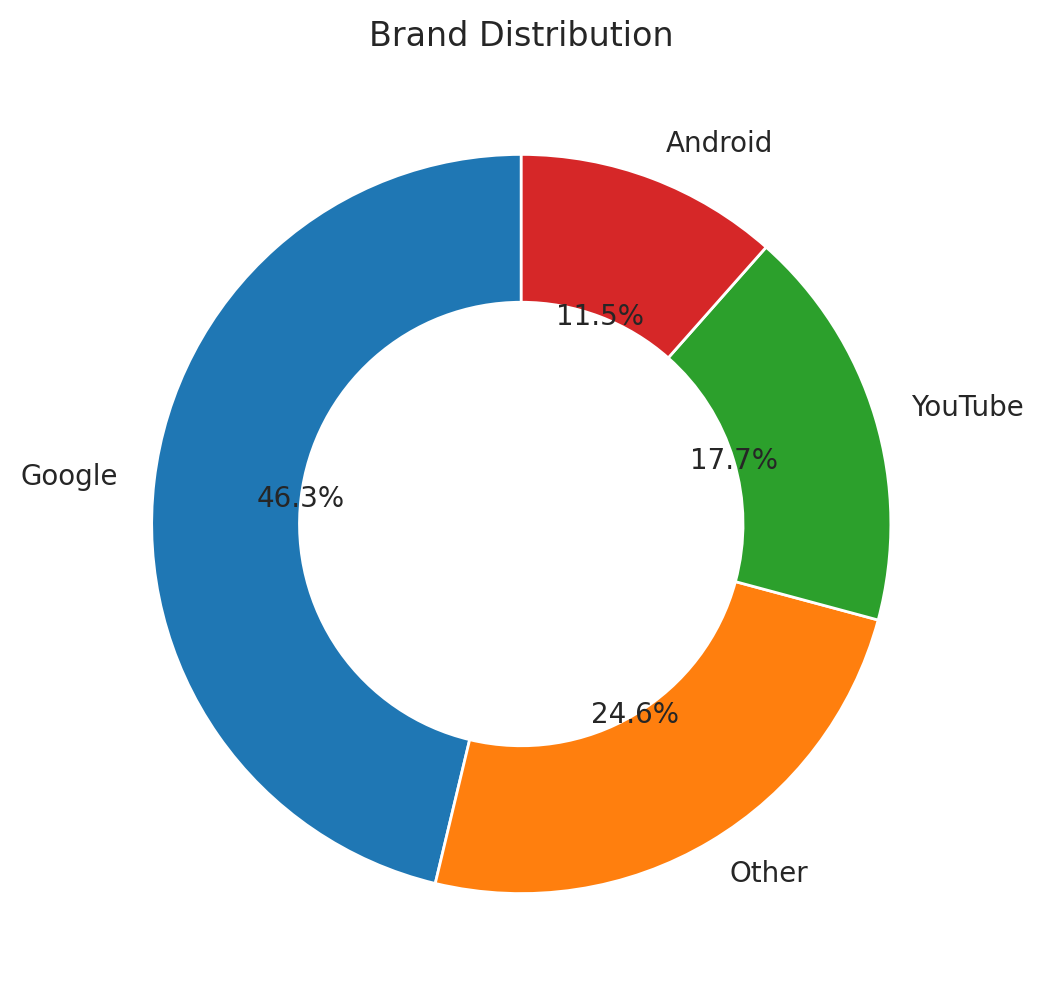

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Pie chart with a hole = doughnut
ax.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.4})

ax.set_title('Brand Distribution')
plt.show()

# EDA

Getting general info about how data is composed, data types and missing values

In [29]:
top_viewed_pages_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6804231 entries, 0 to 6804230
Data columns (total 26 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   Unnamed: 0                 int64         
 1   productName                object        
 2   traffic_source             object        
 3   traffic_medium             object        
 4   deviceCategory             object        
 5   productCategory            object        
 6   country                    object        
 7   region                     object        
 8   city                       object        
 9   month                      int64         
 10  hour                       int64         
 11  year                       int64         
 12  total_bounces              int64         
 13  avg_price                  float64       
 14  total_sessions             int64         
 15  average_session_length     float64       
 16  average_pages_per_session  float64  

Exploring the magnitude that traffic medium none is not meaning it is a missing value , it means that user entered product page directly.

In [30]:
top_viewed_pages_prod.loc[top_viewed_pages_prod['traffic_medium']=="(none)" , 'traffic_source'].value_counts()

traffic_source
(direct)    3282121
Name: count, dtype: int64

## Top products

getting aggregated statistics per product to get the top / bottom - as per stat magnitude -  performing products in each of interest statistics.

In [31]:
# Aggregate metrics
product_metrics = top_viewed_pages_prod.groupby('productName').agg({
    'converting_sessions': 'sum',
    'total_bounces': 'sum',
    'total_sessions': 'sum',
    'total_revenue':'sum' 
     , 'avg_price': 'mean'
}).reset_index()
product_metrics['bounce_rate'] = (product_metrics['total_bounces'] / product_metrics['total_sessions']) * 100
product_metrics['conversion_rate'] = (product_metrics['converting_sessions'] / product_metrics['total_sessions']) * 100
product_metrics['revenue_per_session'] = (product_metrics['total_revenue'] / product_metrics['total_sessions']) * 100

# Top 10 by each metric
top_sessions = list(product_metrics.sort_values(by =['converting_sessions']).nlargest(5, 'converting_sessions')['productName'])
top_conv_rate = list(product_metrics.sort_values(by =['conversion_rate']).nlargest(5, 'conversion_rate')['productName'])
top_bounce = list(product_metrics.sort_values(by =['bounce_rate']).nlargest(5, 'bounce_rate')['productName'])
# product_metrics['avg_timeOnSite']=product_metrics['avg_timeOnSite'].astype('float')
# top_time = list(product_metrics.nlargest(5, 'avg_timeOnSite')['productName'])
top_rev = list(product_metrics.sort_values(by =['revenue_per_session']).nlargest(5, 'revenue_per_session')['productName'])

then we plot paretto chart to explore products that compose 80% of total revenue

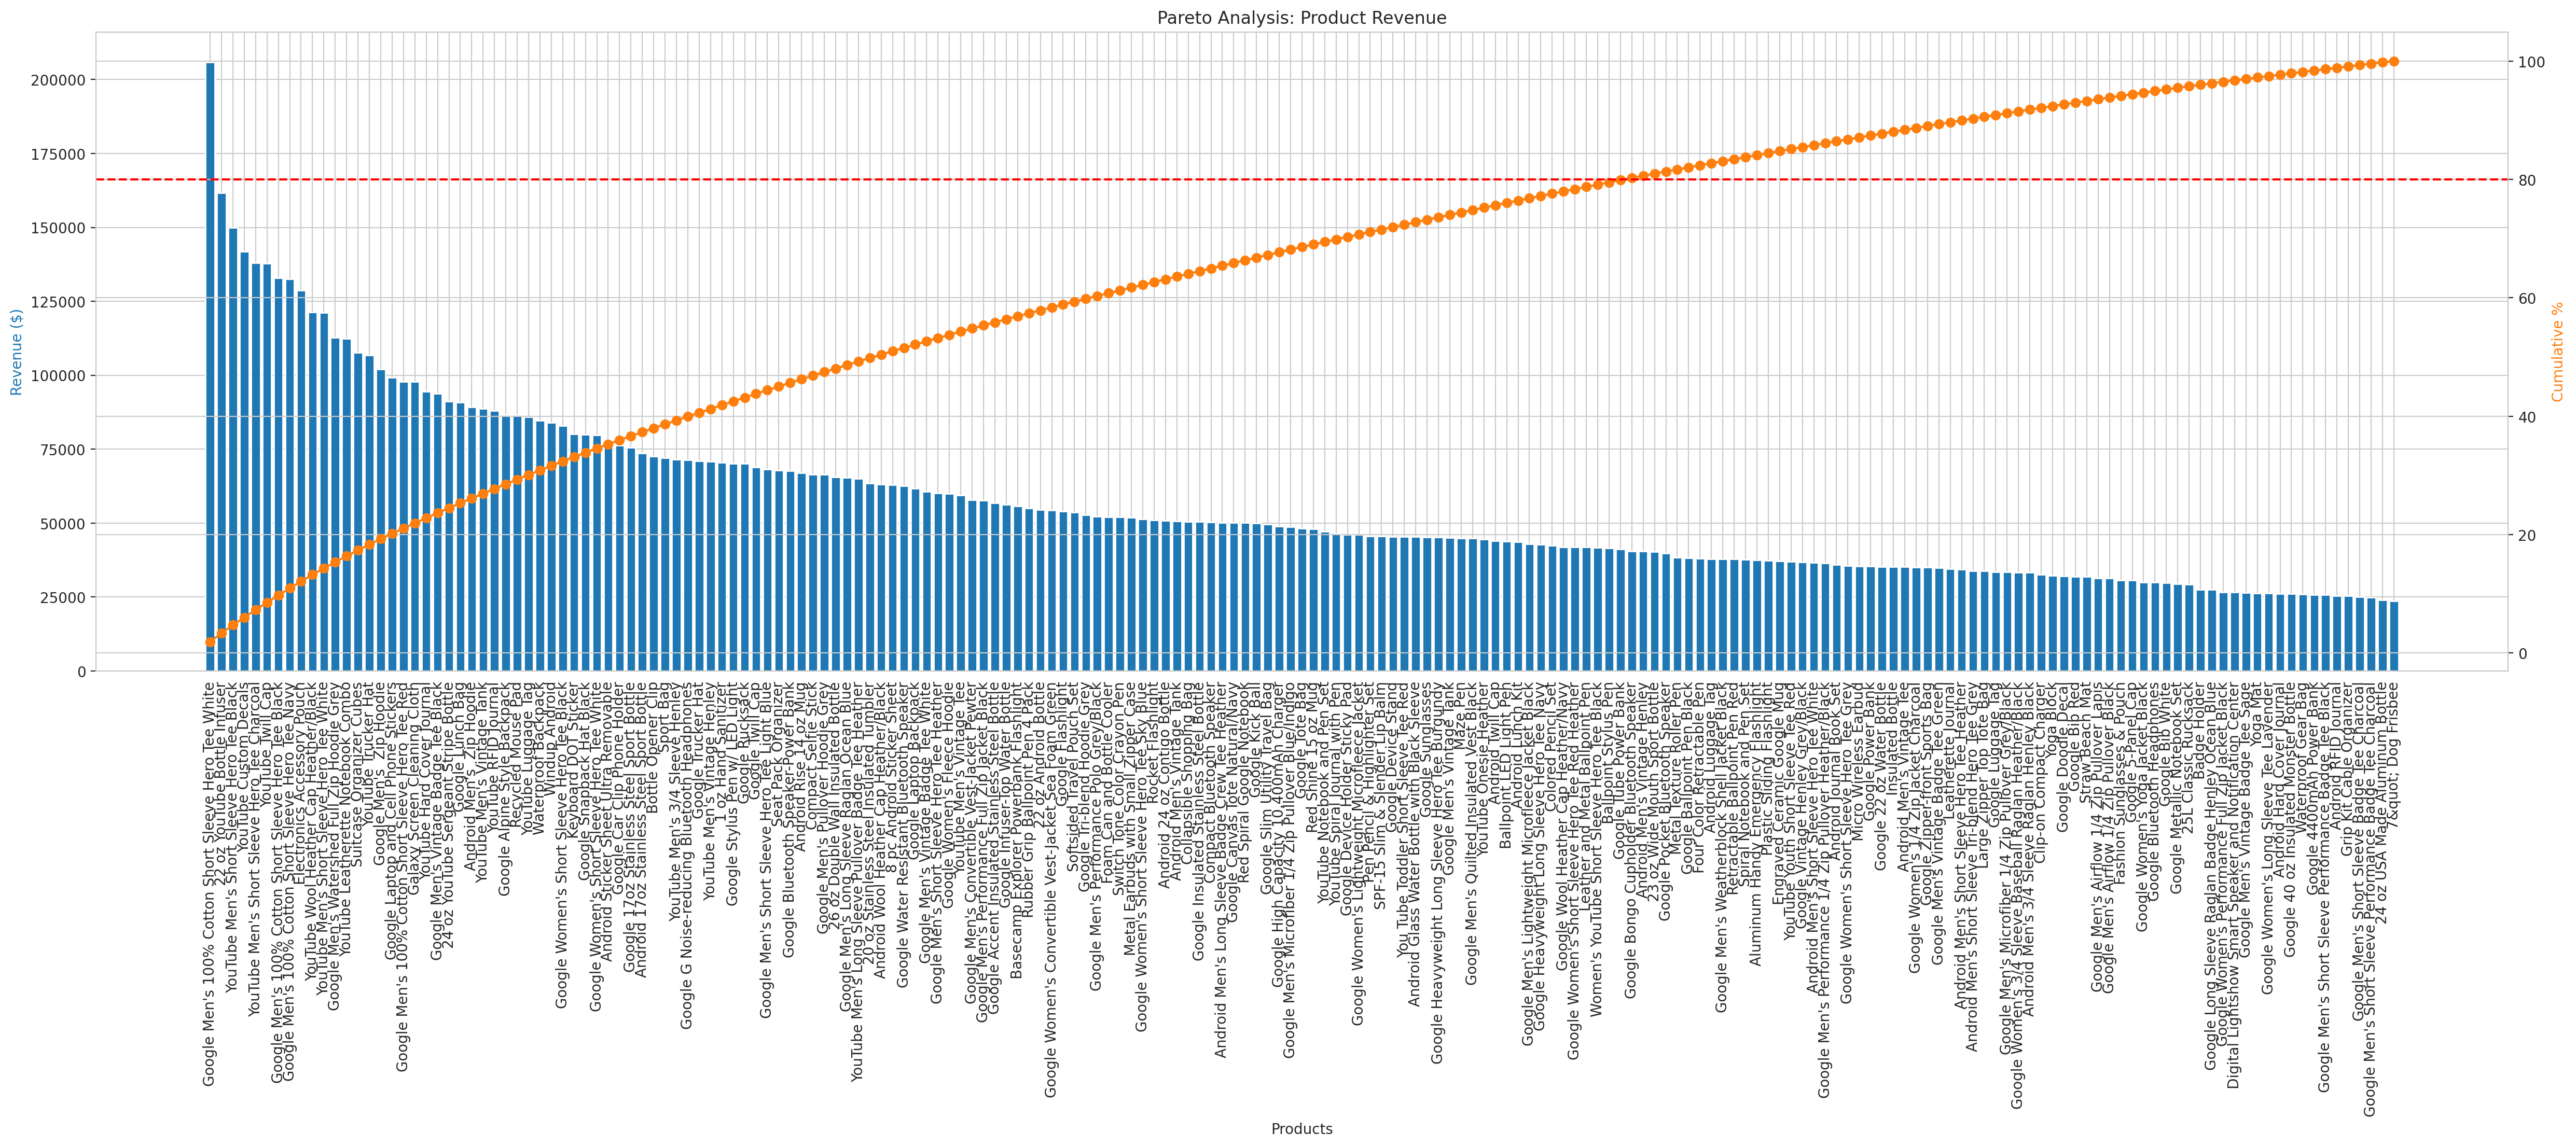

In [32]:
product_metrics.sort_values(by = ['total_sessions'] , ascending=False , inplace=True)
product_metrics.reset_index()
revenue = product_metrics['total_sessions']
products = product_metrics['productName']


cumulative = np.cumsum(revenue)/np.sum(revenue)*100
product_metrics['cumulative'] = cumulative

fig, ax1 = plt.subplots(figsize=(30,8))

# Bar plot
ax1.bar(products, revenue, color='C0')
ax1.set_xlabel('Products')
ax1.set_ylabel('Revenue ($)', color='C0')
plt.xticks(rotation=90)  # 90 degrees = vertical


# Line plot
ax2 = ax1.twinx()
ax2.plot(products, cumulative, color='C1', marker='o')
ax2.set_ylabel('Cumulative %', color='C1')
ax2.axhline(80, color='red', linestyle='--')

plt.title('Pareto Analysis: Product Revenue')

plt.show()

In [33]:
# !pip install --upgrade kaleido
# import kaleido
# kaleido.get_chrome()

We plot scatterplot revenue vs session , exploring products 

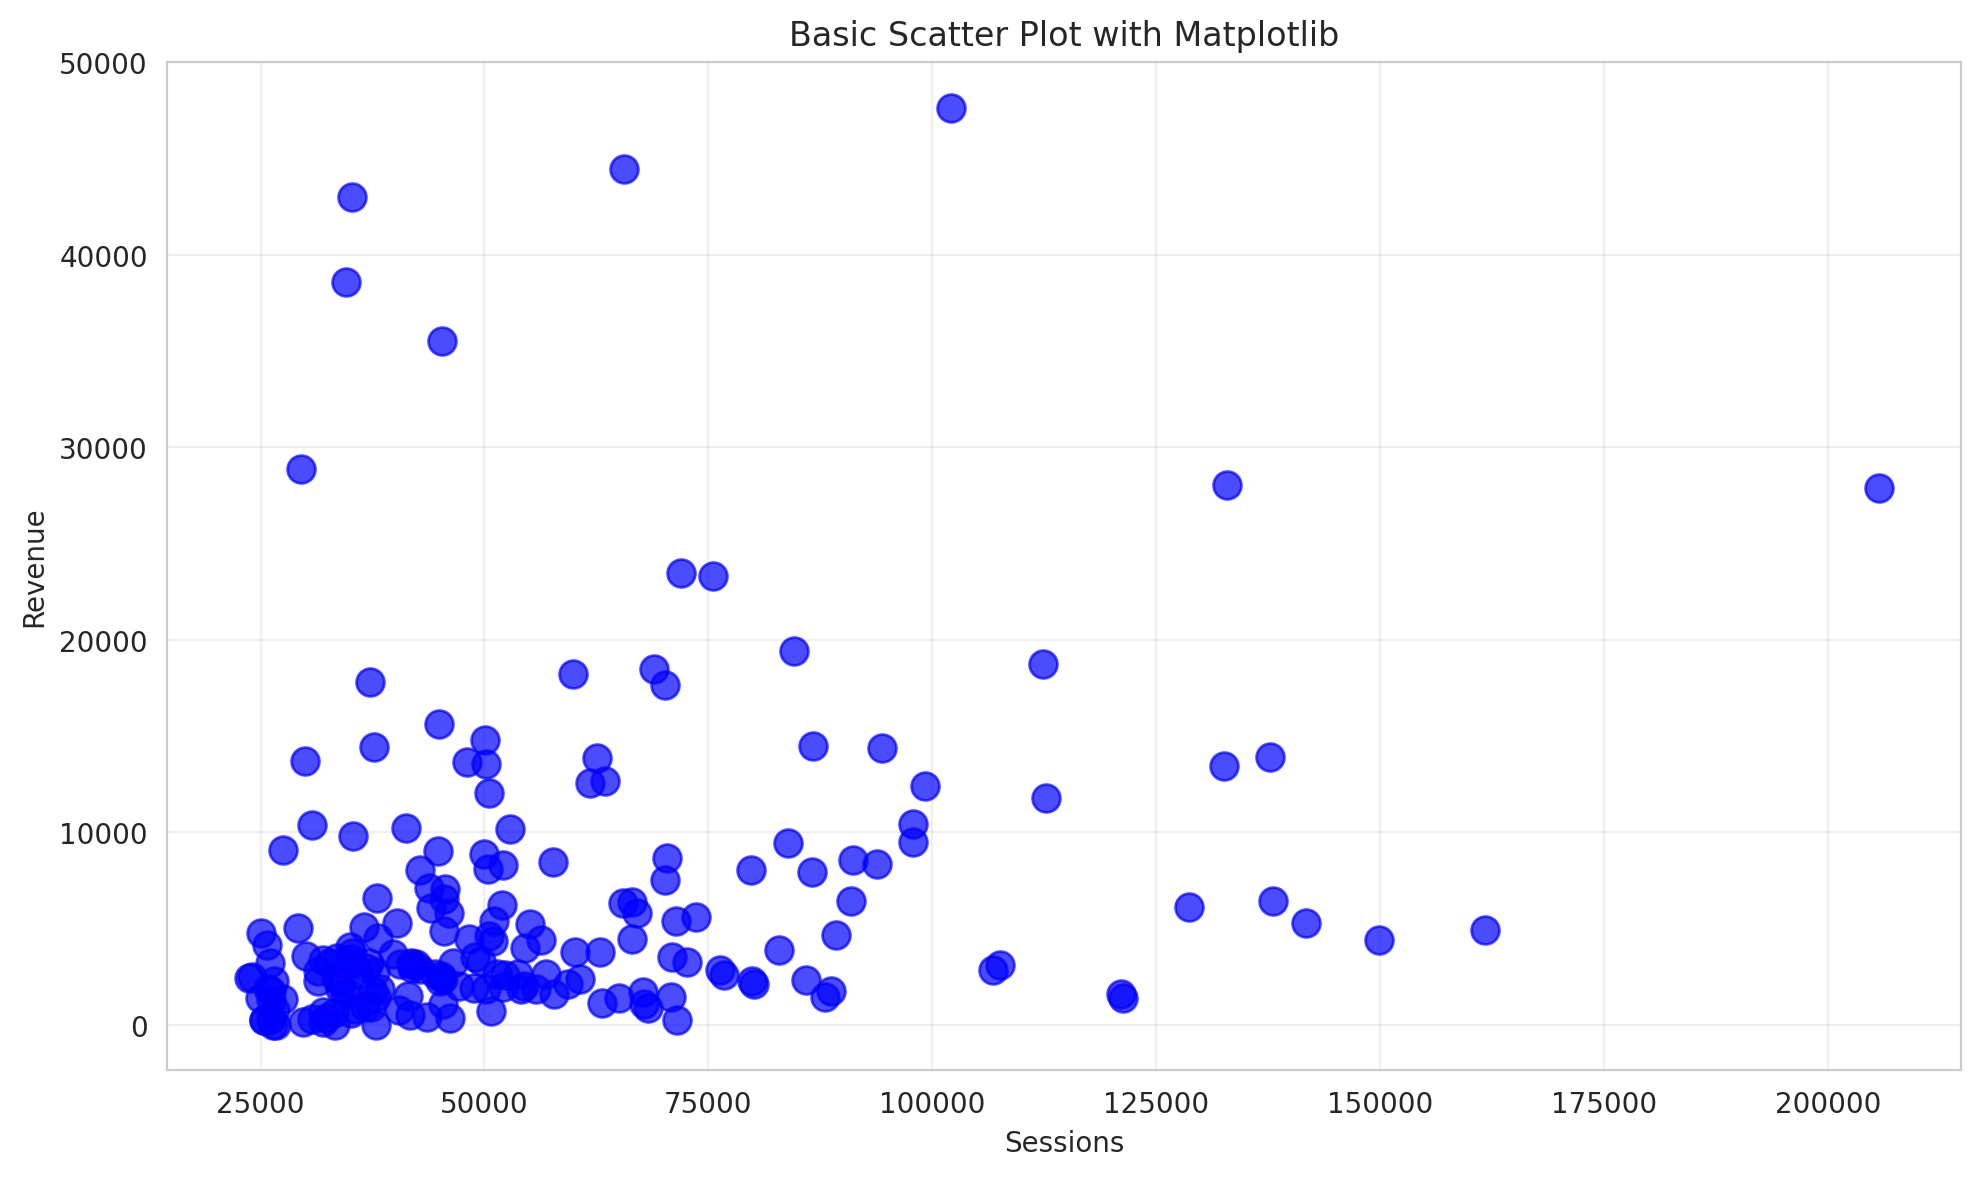

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create scatter plot
scatter = ax.scatter(product_metrics['total_sessions'], 
                    product_metrics['total_revenue'],
                    s=100,  # size=10 equivalent in matplotlib (s=size^2 roughly)
                    color='blue',
                    alpha=0.7)

# Create hover-like annotations (since matplotlib doesn't have native hover)
# This creates text labels that appear near points
# hover_texts = [f'Product: {top_viewed_pages.iloc[idx, 0]} with price: {np.round(top_viewed_pages.iloc[idx, 1], 2)}$' 
#                for idx in top_viewed_pages.index]

# # Add annotations for each point (optional - can be commented out if too cluttered)
# for i, txt in enumerate(hover_texts):
#     ax.annotate(txt, 
#                (product_metrics['total_sessions'].iloc[i], 
#                 product_metrics['total_revenue'].iloc[i]),
#                xytext=(5, 5), textcoords='offset points',
#                fontsize=8, alpha=0.7,
#                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Set labels and title
ax.set_xlabel('Sessions')  # Note: your original had this swapped
ax.set_ylabel('Revenue')   # Note: your original had this swapped
ax.set_title('Basic Scatter Plot with Matplotlib')

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

Most effecient products (greatest revenue with least sessions number)

In [35]:
most_effecient_products=product_metrics.loc[(product_metrics['total_revenue'] > 20000 ) & (product_metrics['total_sessions'] < 100000 ) , ['productName' , 'total_revenue','total_sessions' , 'avg_price'] ]

In [36]:
most_effecient_products['productName']

50     Google 17oz Stainless Steel Sport Bottle
162                                   Sport Bag
8            26 oz Double Wall Insulated Bottle
117                           Google Sunglasses
51                    Google 22 oz Water Bottle
145                         Leatherette Journal
110                Google Metallic Notebook Set
Name: productName, dtype: object

least effecient products 

In [37]:
least_effecient_products=product_metrics.loc[(product_metrics['total_revenue'] < 10000 ) & (product_metrics['total_sessions'] > 100000 ) , ['productName' , 'total_revenue','total_sessions' , 'avg_price'] ]

In [38]:
least_effecient_products

,productName,total_revenue,total_sessions,avg_price
3,22 oz YouTube Bottle Infuser,4913.930585,161684,5.021969
179,YouTube Men's Short Sleeve Hero Tee Black,4419.743948,149931,16.820680
173,YouTube Custom Decals,5259.847279,141783,1.997077
180,YouTube Men's Short Sleeve Hero Tee Charcoal,6423.949990,138071,18.809004
44,Electronics Accessory Pouch,6118.012719,128632,4.901372
191,YouTube Wool Heather Cap Heather/Black,1399.332096,121289,24.559788
181,YouTube Men's Short Sleeve Hero Tee White,1605.904913,121114,16.884846
164,Suitcase Organizer Cubes,3104.682495,107586,21.016378
189,YouTube Trucker Hat,2843.366155,106832,22.157113


In [39]:
[x for x in least_effecient_products['productName'] if x in top_bounce]

[]

In [40]:
least_effecient_products['productName']

3                      22 oz YouTube Bottle Infuser
179       YouTube Men's Short Sleeve Hero Tee Black
173                           YouTube Custom Decals
180    YouTube Men's Short Sleeve Hero Tee Charcoal
44                      Electronics Accessory Pouch
191          YouTube Wool Heather Cap Heather/Black
181       YouTube Men's Short Sleeve Hero Tee White
164                        Suitcase Organizer Cubes
189                             YouTube Trucker Hat
Name: productName, dtype: object

In [41]:
class HierericalAnalysis :
    def __init__(self):
        pass
    def plot_setup(self) :
        pass
    def get_grouped_data(self):
        pass
        
    def _handle_time_field(self):
        pass
    def _visualize(self) :
        pass
    def _plot_time_analysis(self):
        pass
    def _plot_single_dimension_time_analysis(self):
        pass
    def _plot_multiple_dimension_time_analysis(self):
        pass
    def _plot_categorical_analysis(self):
        pass
    def _plot_single_categorical_analysis(self):
        pass
    def _plot_double_categorical_analysis(self):
        pass
    def _plot_facet_categorical_analysis(self):
        pass
    
    
    
    

In [42]:


def hier_analysis(data:pd.DataFrame, breaks:list, agg:types.LambdaType, name:str, time_column:str=None, date_fmt:datetime="%Y-%m-%d" , figsize:tuple=None , Top=None):
    """
    ِ A function to analyze a certain measure across number of breaks , either time breaks or normal categorical breaks
    Parameters : 
    ------------
    data : pd.DataFrame 
     The dataset in which we interested
    

    
    """
    df = data.copy()

    time_col = time_column
    if time_col is None:
        for col in breaks:
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                time_col = col
                break

    is_time_analysis = time_col is not None

    if is_time_analysis and not pd.api.types.is_datetime64_any_dtype(df[time_col]):
        try:
            df[time_col] = pd.to_datetime(df[time_col], format=date_fmt)
        except:
            raise ValueError(f"Could not convert column '{time_col}' to datetime")
    non_time_breaks = [col for col in breaks if col != time_col]



    

    
    grouped = df.groupby(breaks, observed=True).apply(agg).replace([np.inf, -np.inf], np.nan).fillna(0)
    grouped=grouped.reset_index(name=name).sort_values(name, ascending=False)
    if len(breaks) ==2 :
    
    
        category_totals = grouped.groupby(breaks[0])[name].sum().reset_index(name='Category_Total')[:Top]
        grouped = grouped.merge(category_totals, on=breaks[0] , how='inner')[:Top]
        
        # Sort by category total then by sales within category
        sorted_grouped = grouped.sort_values(['Category_Total', name], ascending=[False, False])
        result_df = sorted_grouped.drop(columns=['Category_Total'])
    else :  
        result_df = grouped
    non_time_breaks = [col for col in breaks if col != time_col]
        # Set up visualization
    default_width = 14 if is_time_analysis else 12
    default_height = 3 + 2*(len(non_time_breaks)-1)
    figsize = figsize if figsize else (default_width, default_height)
    plt.figure(figsize=figsize)
        # Custom styling
    title_font = {'fontsize': 18, 'fontweight': 'bold', 'color': '#333333'}
    label_font = {'fontsize': 10, 'color': '#555555'}
    tick_font = {'fontsize': 8, 'color': '#666666'}
        

    if is_time_analysis:
        _plot_time_analysis(result_df, breaks, name, time_col  ,title_font ,label_font , tick_font)
    else:
        _plot_categorical_analysis(result_df, breaks, name , figsize=figsize)

    # return result_df


def _plot_time_analysis(df, breaks, name, time_col ,  title_font , label_font, tick_font , palette='viridis'
                      ):
    """Handle all time-based visualizations with smart faceting"""
    non_time_breaks = [col for col in breaks if col != time_col]
    num_dimensions = len(non_time_breaks)
    
    if num_dimensions == 0:
        # Pure time series
        ax = sns.lineplot(data=df, x=time_col, y=name, 
                         linewidth=2.5, color='#2e86de', marker='o')
        plt.gcf().autofmt_xdate()
        plt.xlabel(time_col, **label_font)
        plt.ylabel(name, **label_font)
        plt.title(f'{name} over Time', **title_font)
        
    elif num_dimensions == 1:
        # Time series with one grouping
        ax = sns.lineplot(data=df, x=time_col, y=name, hue=non_time_breaks[0],
                         palette=palette, linewidth=2.5, style=non_time_breaks[0],
                         markers=True, dashes=False)
        plt.gcf().autofmt_xdate()
        plt.xlabel(time_col, **label_font)
        plt.ylabel(name, **label_font)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
                  title=non_time_breaks[0])
        title = f"{name} by {non_time_breaks[0]} over Time"
        plt.title("\n".join(wrap(title, 60)), **title_font)
        
    else:
        # Smart faceting for multi-dimensional time series
        # Determine which variable has more categories for faceting
        var1, var2 = non_time_breaks[0], non_time_breaks[1]
        n_categories_var1 = df[var1].nunique()
        n_categories_var2 = df[var2].nunique()
        
        # Facet by the variable with more categories, hue by the other
        if n_categories_var1 > n_categories_var2:
            facet_var, hue_var = var1, var2
        else:
            facet_var, hue_var = var2, var1
        
        # Create FacetGrid with hue
        g = sns.FacetGrid(df, col=facet_var, hue=hue_var,
                         palette=palette, height=4 , col_wrap=3, aspect=1.2)
        
        # Map lineplot with proper styling
        g.map(sns.lineplot, time_col, name, linewidth=2.5, 
             estimator=None, alpha=0.8)
        
        # Add markers for better distinction
        if df[hue_var].nunique() <= 8:  # Only use markers if reasonable number
            g.map(sns.scatterplot, time_col, name, s=30, alpha=0.8)
        
        # Formatting
        g.set_titles(col_template="{col_name}")
        g.set_axis_labels(time_col, name)
        plt.gcf().autofmt_xdate()
        
        # Add legend for hue variable
        g.add_legend(title=hue_var)
        
        # Handle additional dimensions (3+) with subtitle annotations
        if len(non_time_breaks) > 2:
            extra_dims = ", ".join(non_time_breaks[2:])
            plt.annotate(f"Also grouped by: {extra_dims}",
                        xy=(0.5, -0.1), xycoords='figure fraction',
                        ha='center', fontsize=10, color='#555555')
        
        title = f"{name} by {facet_var} (col) and {hue_var} (color) over Time"
        if len(non_time_breaks) > 2:
            title += f" (+{len(non_time_breaks)-2} more)"
        plt.suptitle("\n".join(wrap(title, 80)), **title_font)
        plt.subplots_adjust(top=0.85, bottom=0.15 if len(non_time_breaks) > 2 else 0.1)


def _plot_categorical_analysis(df, breaks, name , figsize):
    num_dimensions = len(breaks)

   
    if num_dimensions == 1:
        # Single dimension horizontal bar plot with seaborn
        plt.figure(figsize=figsize)
        
        # 5. Create pivot table for stacked bars
        pivot_df = df.pivot_table(
            index=breaks[0],
            values=name
        ).fillna(0)
        
        # 6. Create plot
        # plt.figure(figsize=(12, 8))
        ax = pivot_df.plot.barh(
            stacked=False,
            width=0.8,
            cmap='viridis'
        )
        
        # 7. Add individual value labels for each subcategory
        for container in ax.containers:
            ax.bar_label(
                container,
                label_type='center',
                fmt='%.1f',
                padding=0,
                color='white',
                fontsize=9
            )        

        
        plt.title(f'{name} by {breaks[0]}')
        plt.xlabel(name)
        plt.ylabel(breaks[0])
        plt.tight_layout()
        plt.show()
    
    elif num_dimensions == 2:
        # Two dimensions grouped bar plot with seaborn
        # plt.figure(figsize=figsize)
        plt.subplots_adjust(left=0.01, right=0.99)
        pivot_df = df.pivot(
        index=breaks[0],
        columns=breaks[1],
        values=name
    ).fillna(0)
    
        ax = pivot_df.plot.barh(
        stacked=True,
        width=0.8,
        cmap='viridis'
            
    )
        ax.xaxis.set_visible(False) 
        ax.spines['bottom'].set_visible(False) 
    
        # 7. Add individual value labels for each subcategory
        for container in ax.containers:
            ax.bar_label(
                container,
                label_type='center',
                fmt='%.1f',
                padding=0,
                color='white',
                fontsize=9
            )

        
        plt.title(f'{name} by {breaks[0]} and {breaks[1]}')
        plt.xlabel(name)
        
        plt.ylabel(breaks[0])
        plt.legend(title=breaks[1], bbox_to_anchor=(1.005, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
    else:
        # Three+ variables (FacetGrid)
        row_var = breaks[0] if len(breaks) > 0 else None
        col_var = breaks[1] if len(breaks) > 1 else None
        hue_var = breaks[2] if len(breaks) > 2 else None
        
        g = sns.catplot(data=df, x=name, 
                        col=col_var, 
                        y=row_var,
                        hue=hue_var,
                        kind="bar", palette='tab10', 
                        height=4, aspect=1.2, saturation=0.85 ,col_wrap=3)
        g.set_axis_labels(name, row_var)
        
        title = f"{name} by {', '.join(breaks)}"
        #plt.suptitle("\n".join(wrap(title, 80)), **title_font)
    plt.subplots_adjust(top=0.9)

## Audience & User Behavior

### Bounce Rate

# Hiererical Analysis

In [43]:
name = 'bounce_rate'
agg_bounce =  lambda x: (x['total_bounces'].sum() / x['total_sessions'].sum()) * 100
data = top_viewed_pages_prod


#### By Traffic Medium

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

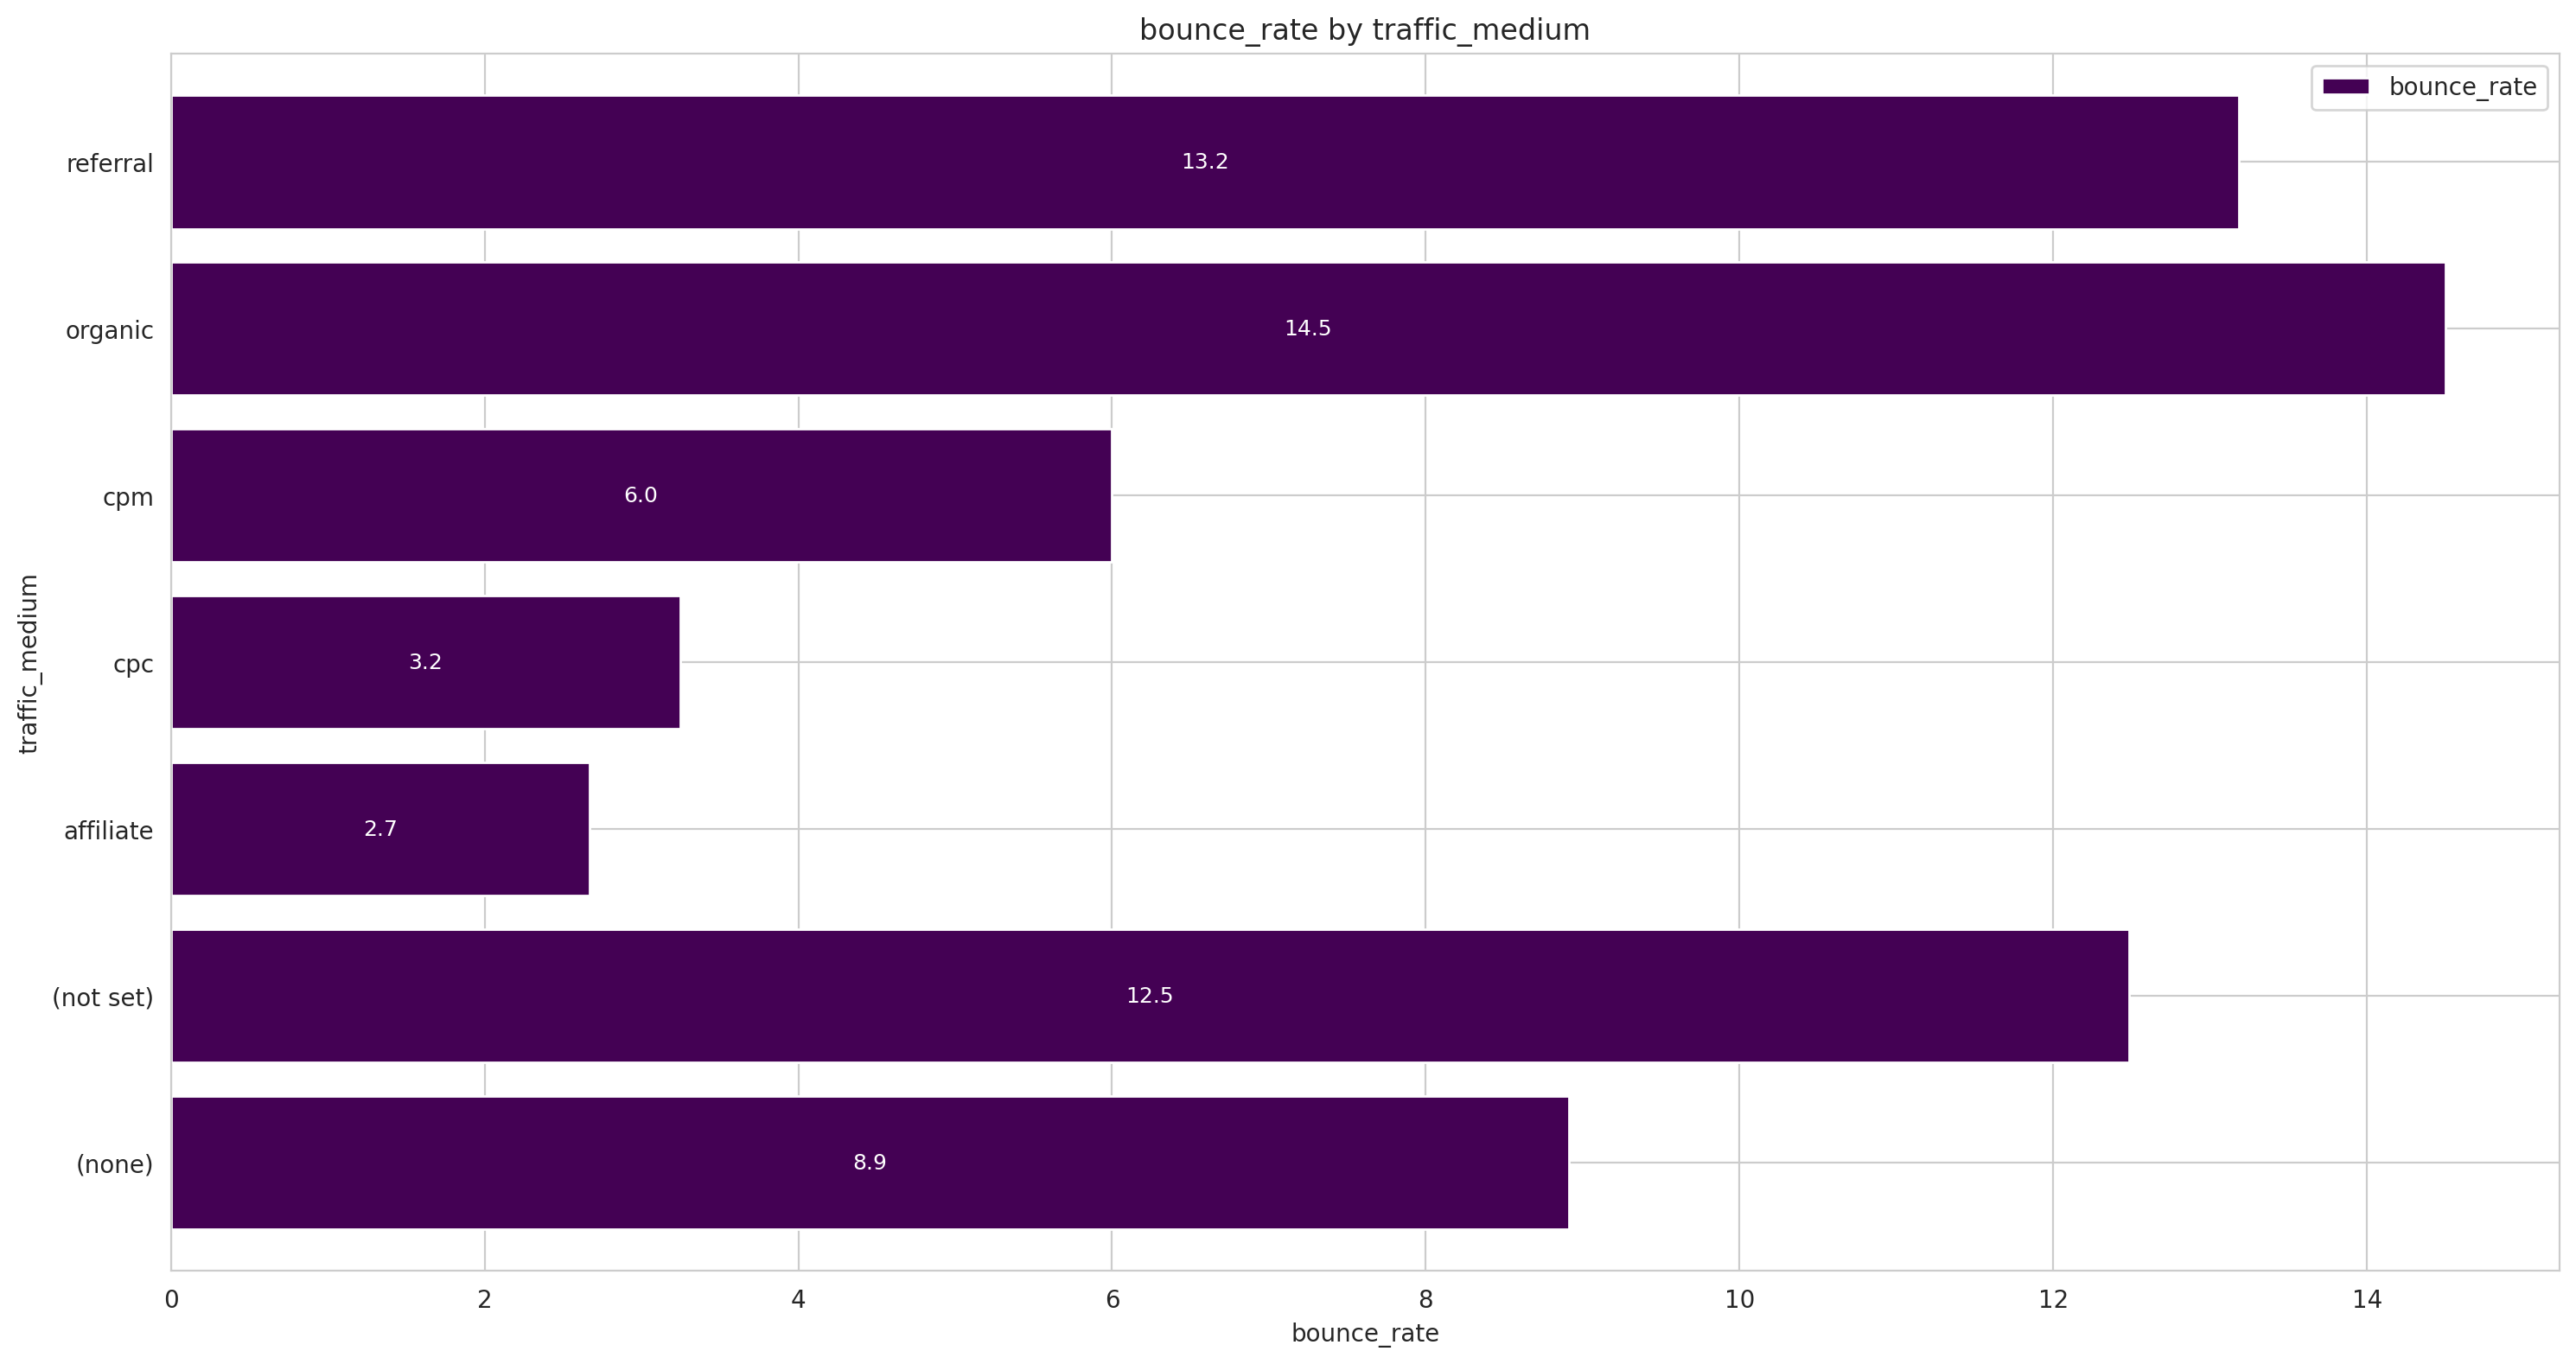

<Figure size 1500x800 with 0 Axes>

In [44]:
hier_analysis(data , ['traffic_medium' ] , agg_bounce , name  )

We notice that least bounce rate leading traffic medium is affiliate marketing , and CPC (cost per click) and this constists with our pre knowledge.


In Google Analytics, CPC (Cost Per Click) is a traffic medium that specifically designates paid traffic generated from advertising campaigns where advertisers pay for each click on their ads , so it is well understood and sesigned by the campaign to which each ad is directed to guarntee that the advertiser find that its product well directed to the correct users / customers.

and so on with affiliate marketing that means that an affiliate marketer directs to an advertiser's website or product page, typically through a unique affiliate link , so the marketer knows who is directly uses his link and user is meaning to use this specific link to claim offer.

On the other hand , we see that organic traffic has the most bounce rate , for the same idea when i search about a certain product , it is more likely , the first page i fing in search to click on it ,  but it is more likely as well that i don't like it because from the beginning i'm not directed to it that gives higher bounce rate within this category.


### By Device

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

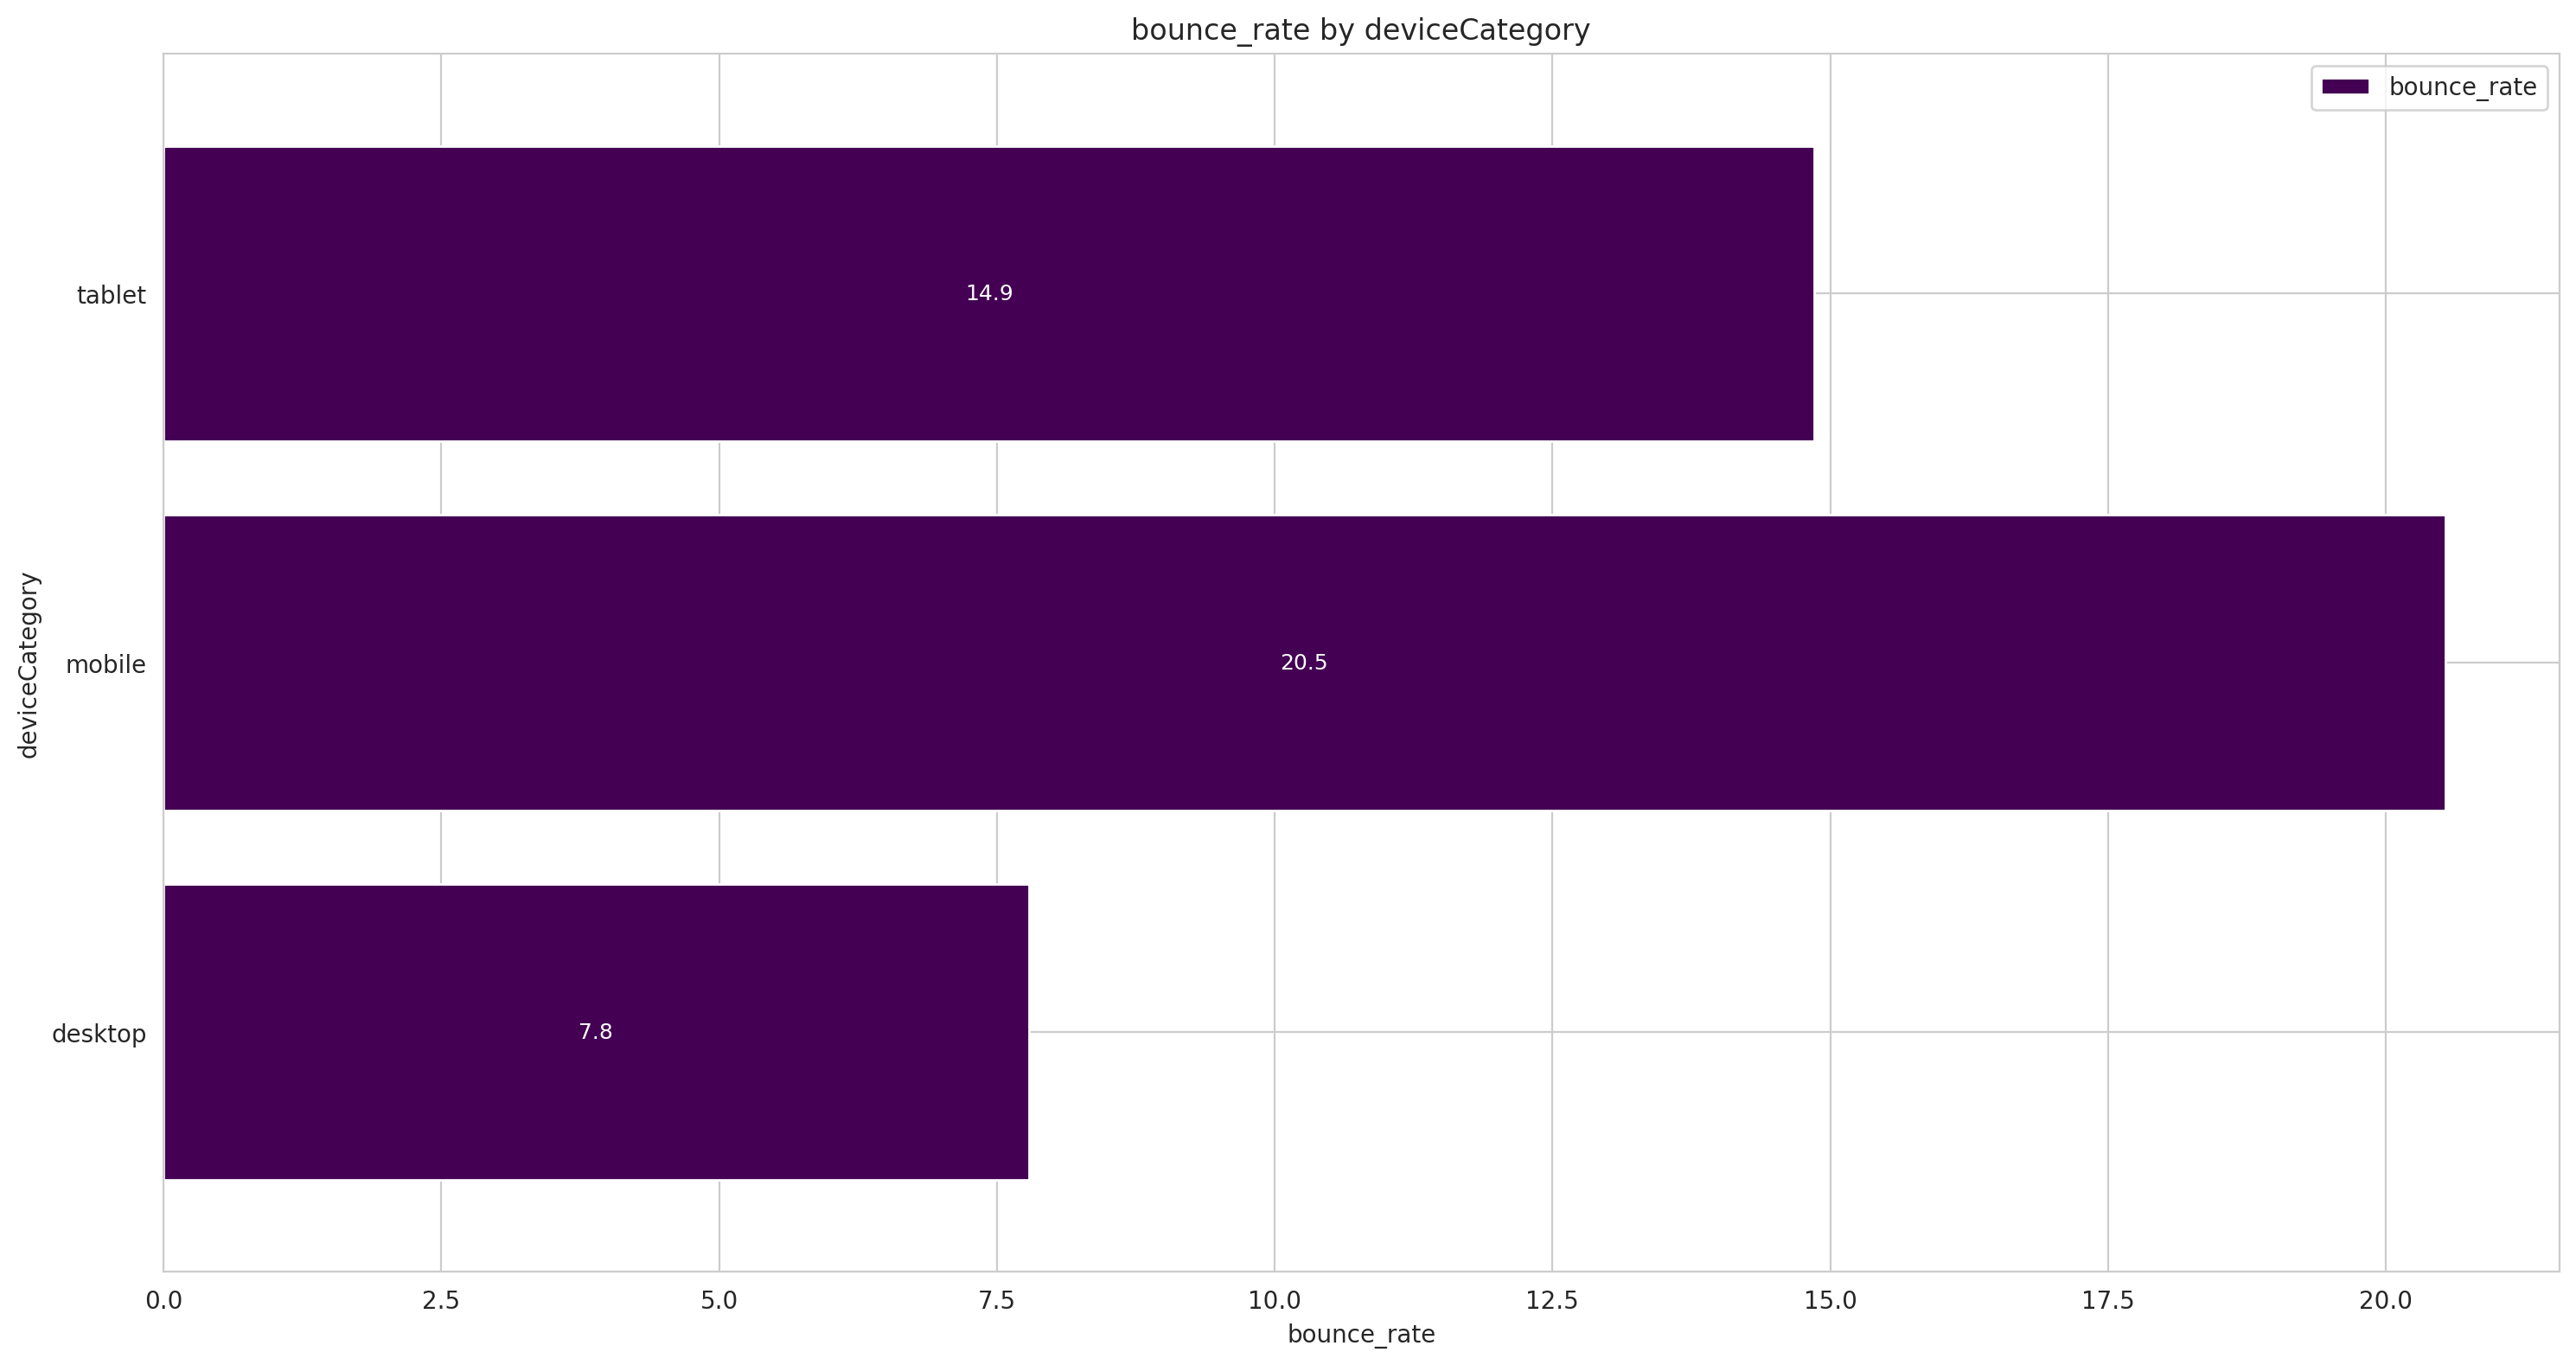

<Figure size 1500x800 with 0 Axes>

In [45]:
hier_analysis(data , ['deviceCategory' ] , agg_bounce , name  )

We find that the lowest bounce rate is within Desktop user, this consists with our pre knowledge that logically Desktop user is less possiblity to click a link by fault with the more control using mouse.


As well my self when i need to deal with anything related to money I use desktop to make sure no faults.


In the same time the largest bounce rate is using Mobile for the same reason , less control , less interest in serious shopping or financial deals mobile user generally tends more to browse.

<Figure size 3000x1200 with 0 Axes>

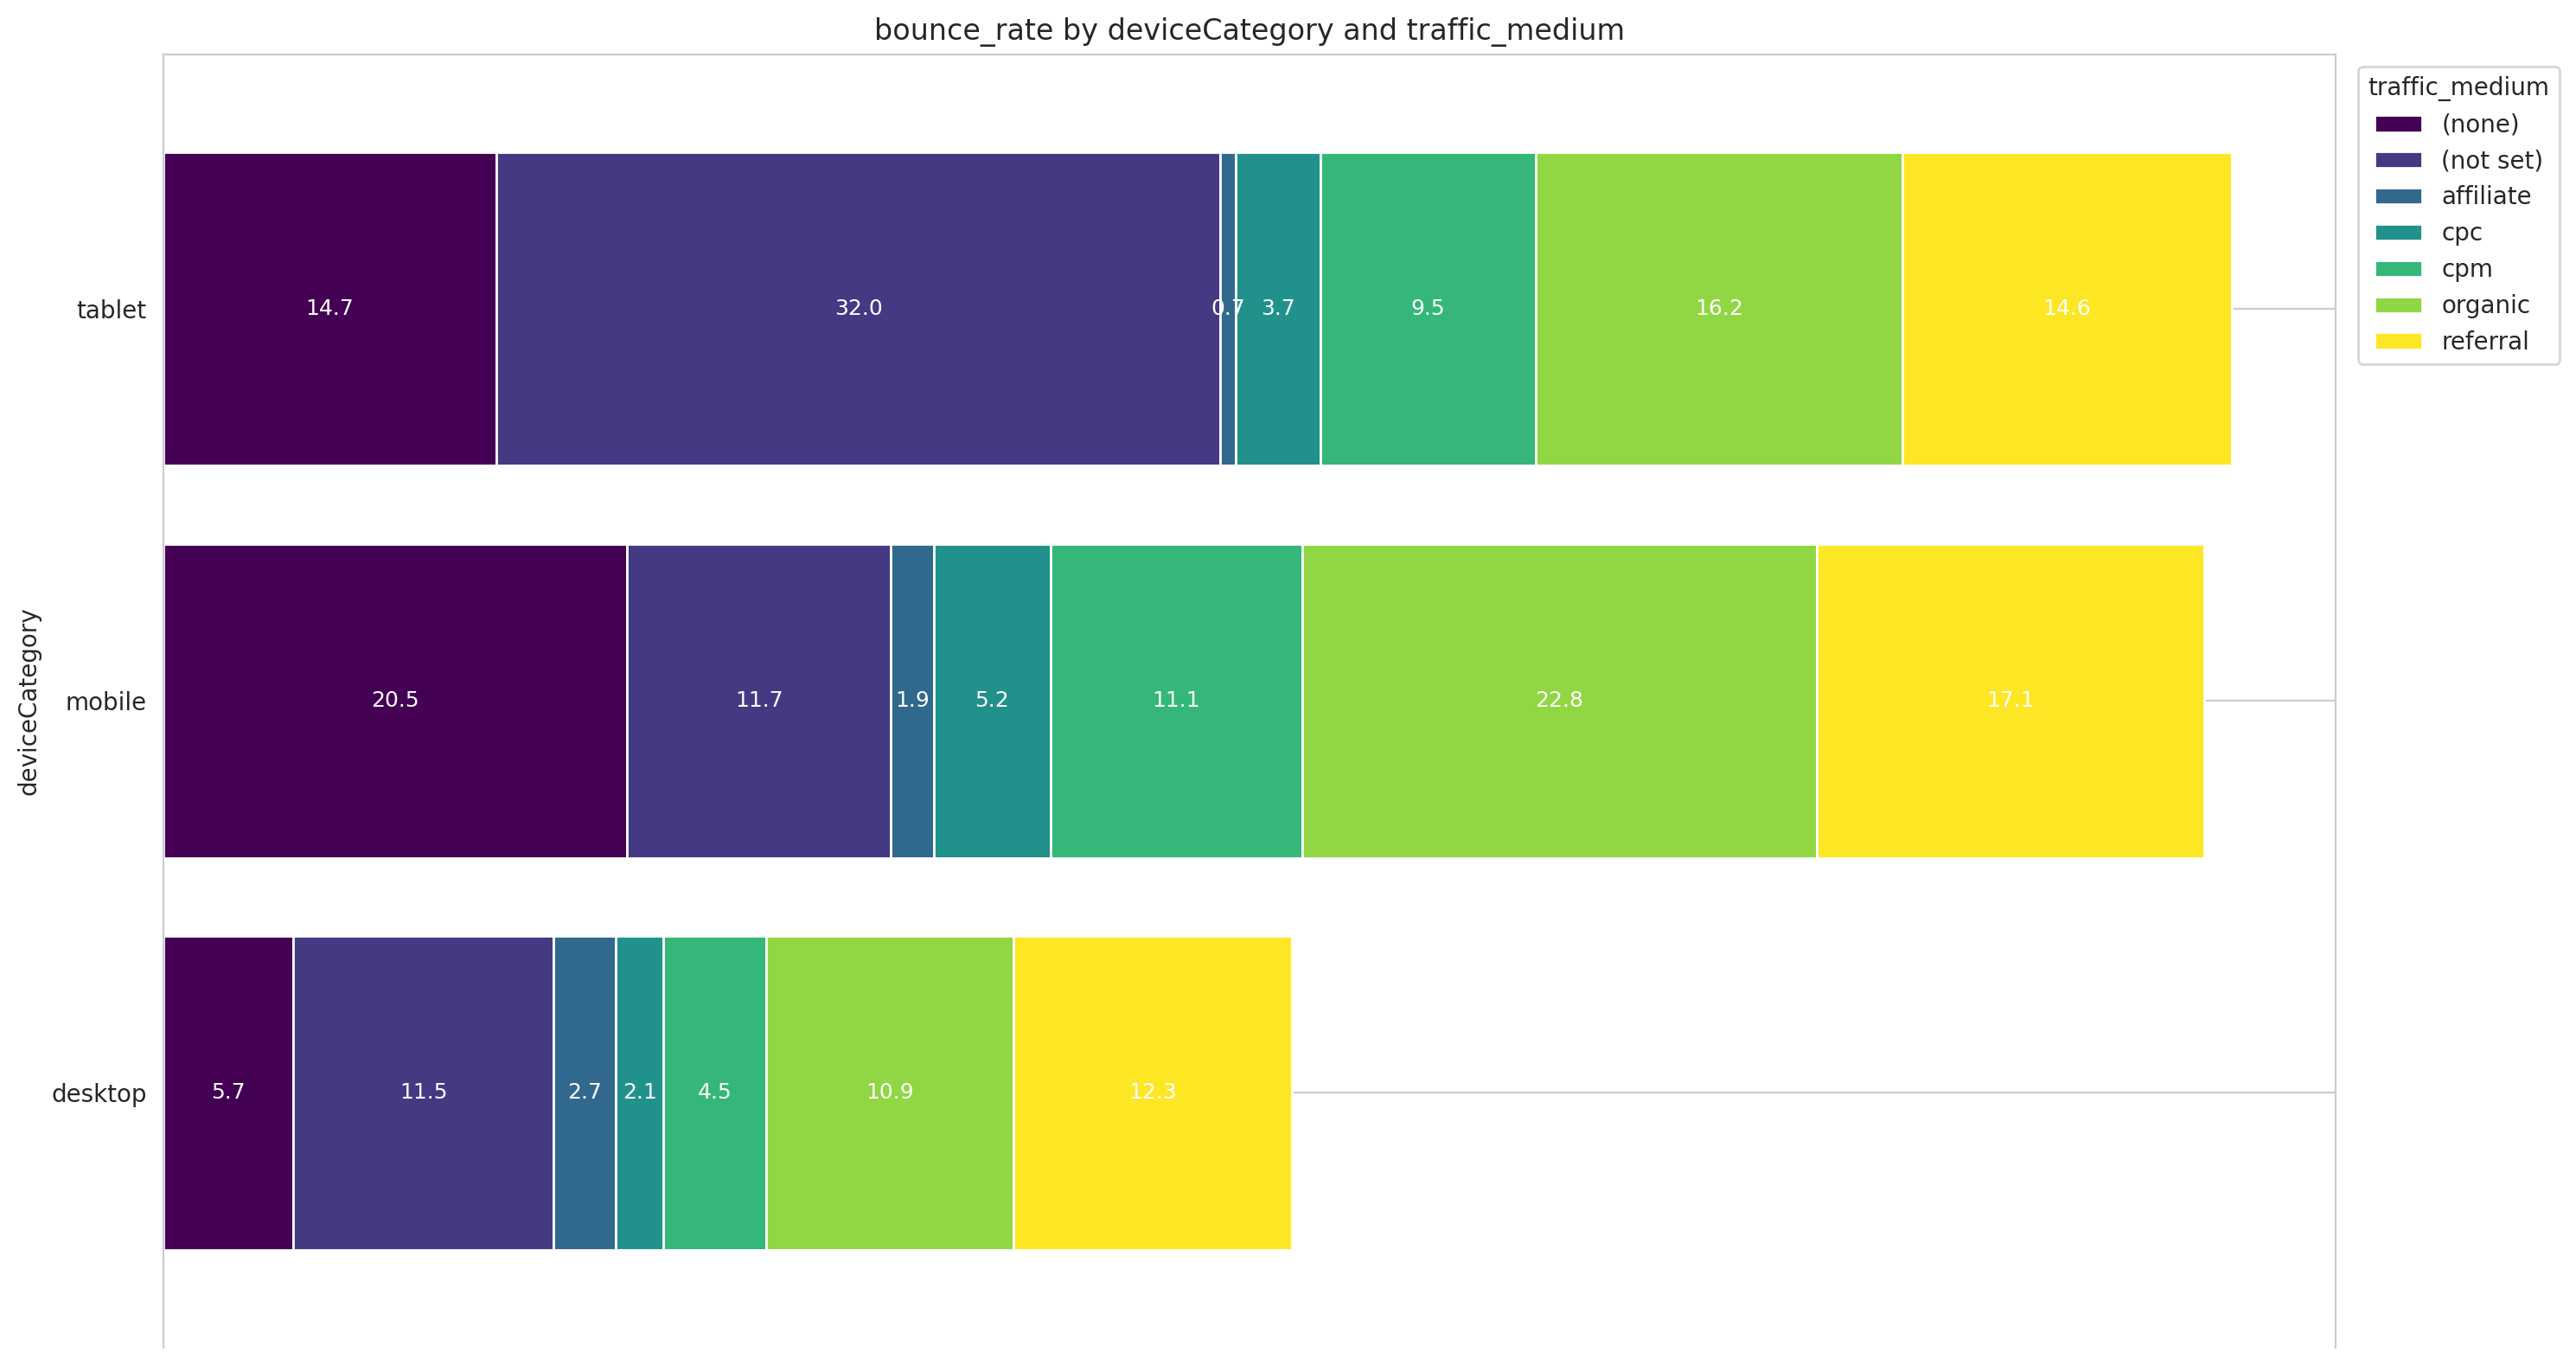

<Figure size 1500x800 with 0 Axes>

In [46]:
hier_analysis(data, [ 'deviceCategory'  , 'traffic_medium'] , agg_bounce , name , figsize=(30,12)  )

The co analysis of bounce rate based on device category and traffic medium suggests a new insight , the largest bounce rate is the highest among tablest users with (non set) , direct traffic .

Besides what we clarified that among mobile users the largest bounce rate is between organic traffic for the 2 reasons we clarified above.

Otherwise , the same we confirmed above that least bounce rate among deskrop users lead by cpc and affiliate marketing.

#### By Geographical Distribution

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

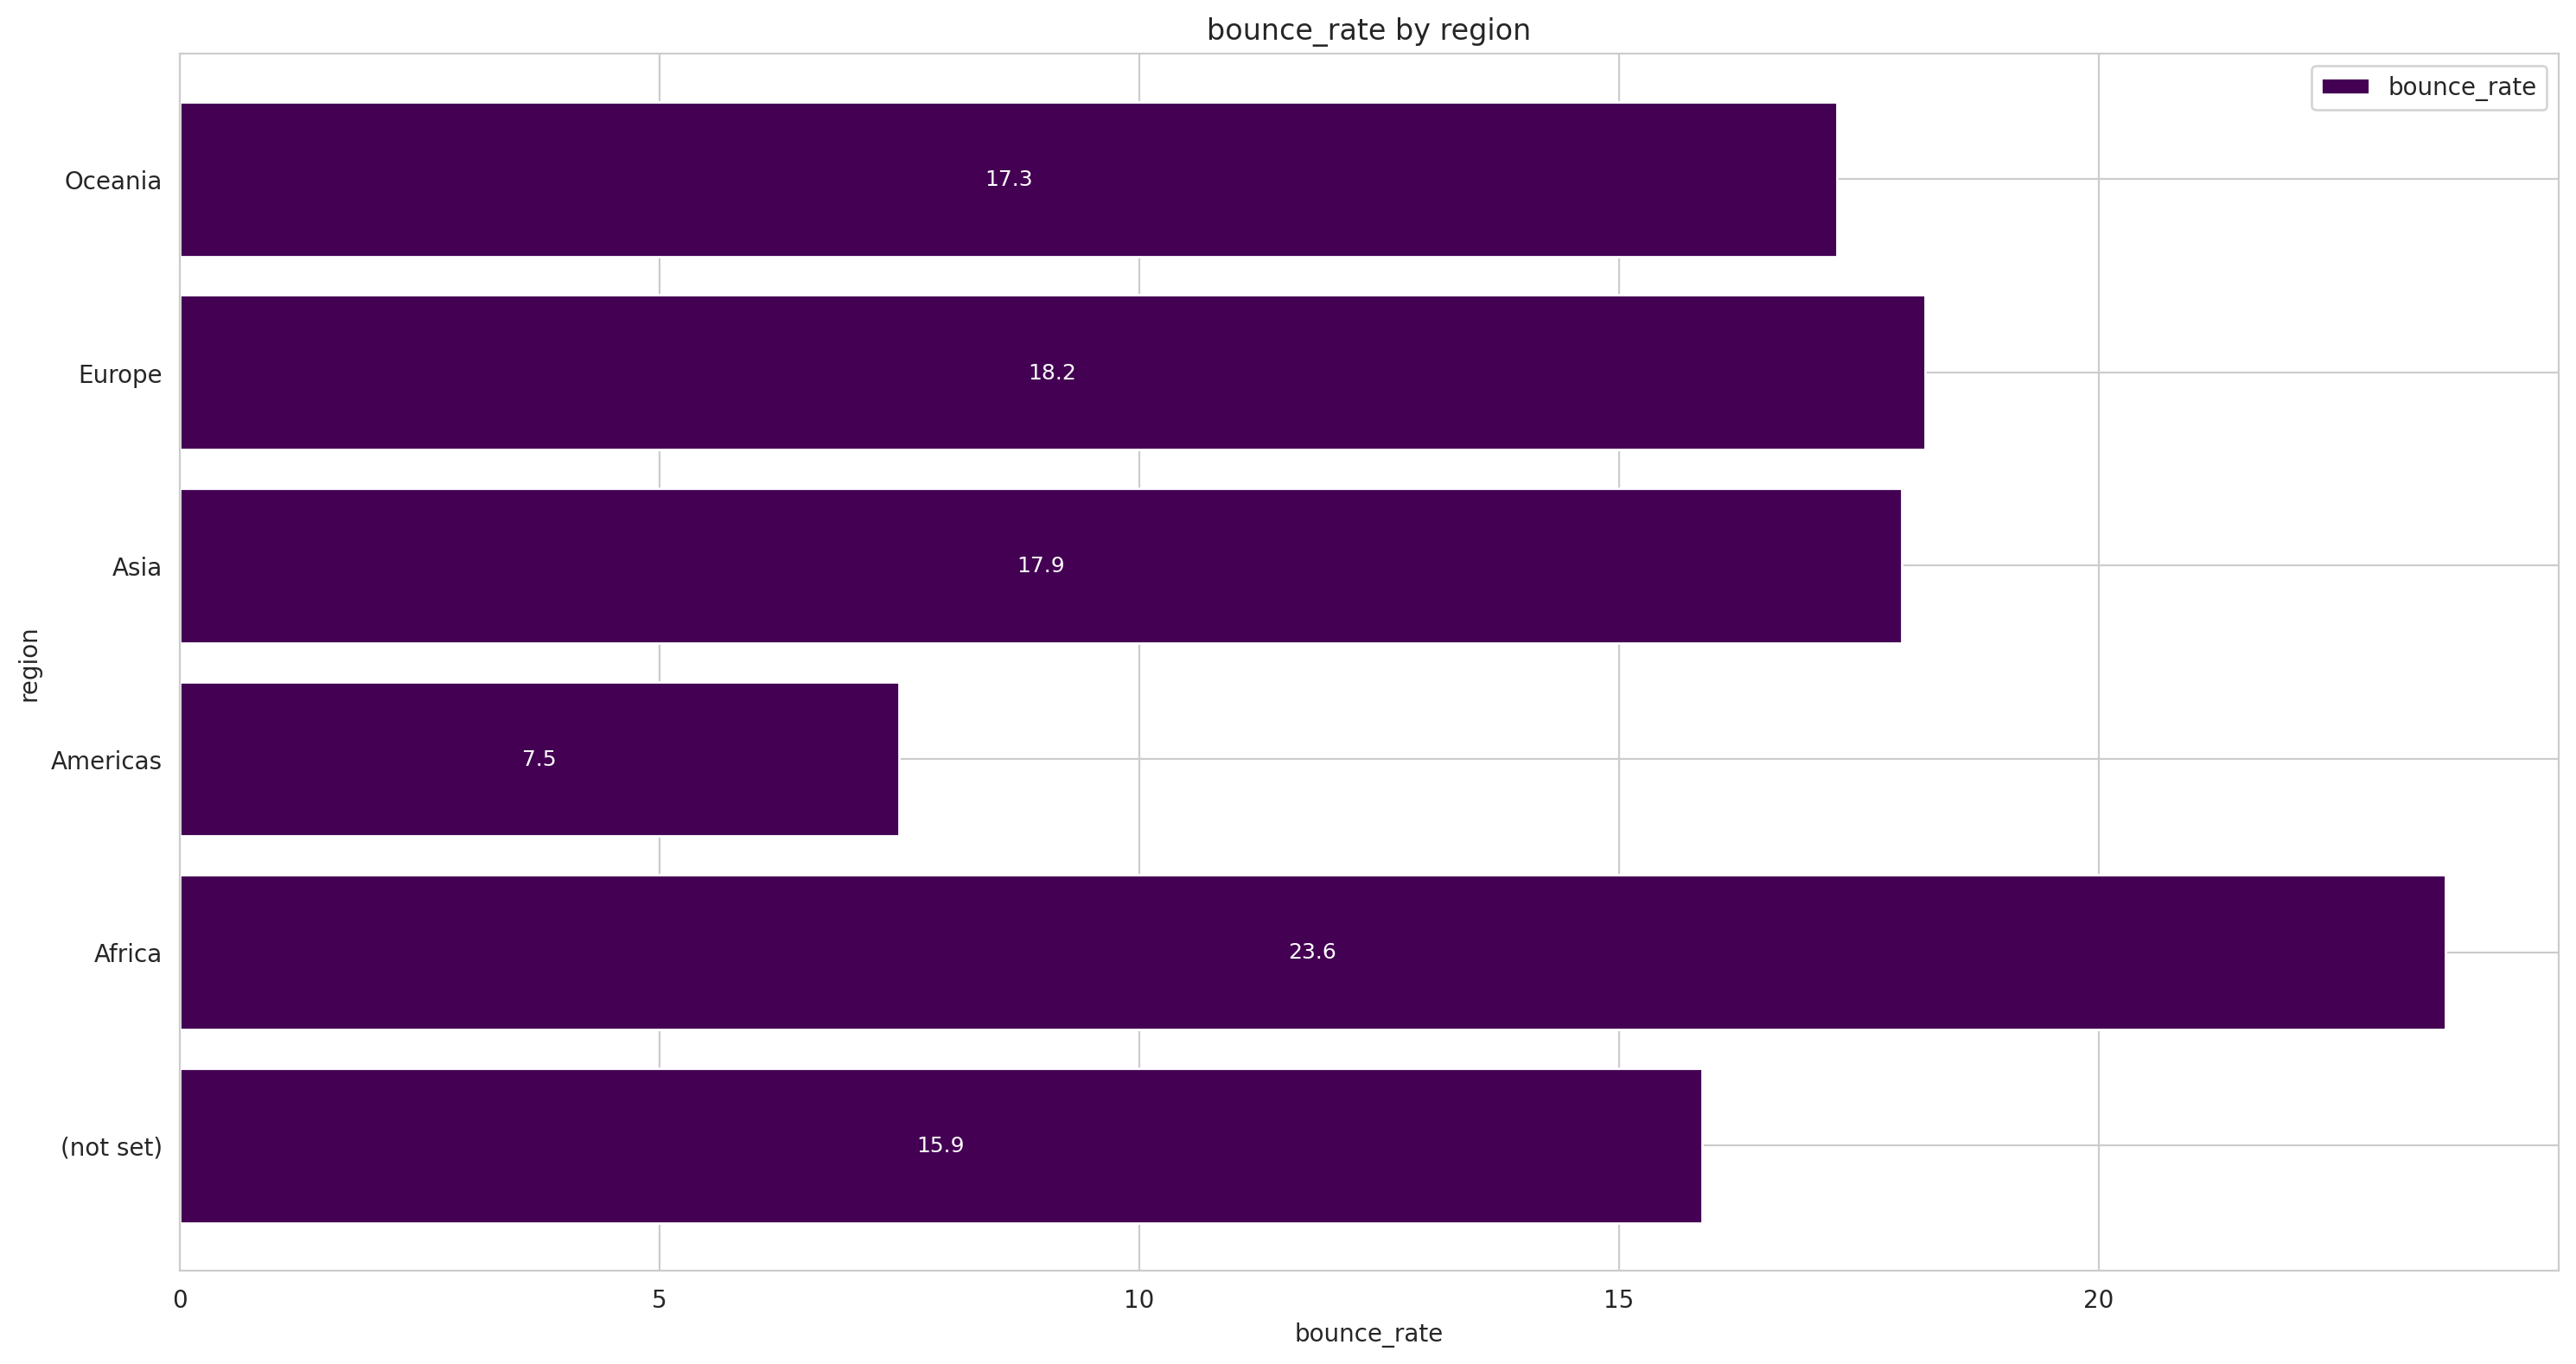

<Figure size 1500x800 with 0 Axes>

In [47]:
hier_analysis(data, [ 'region'  ] , agg_bounce , name   )

<Figure size 1200x500 with 0 Axes>

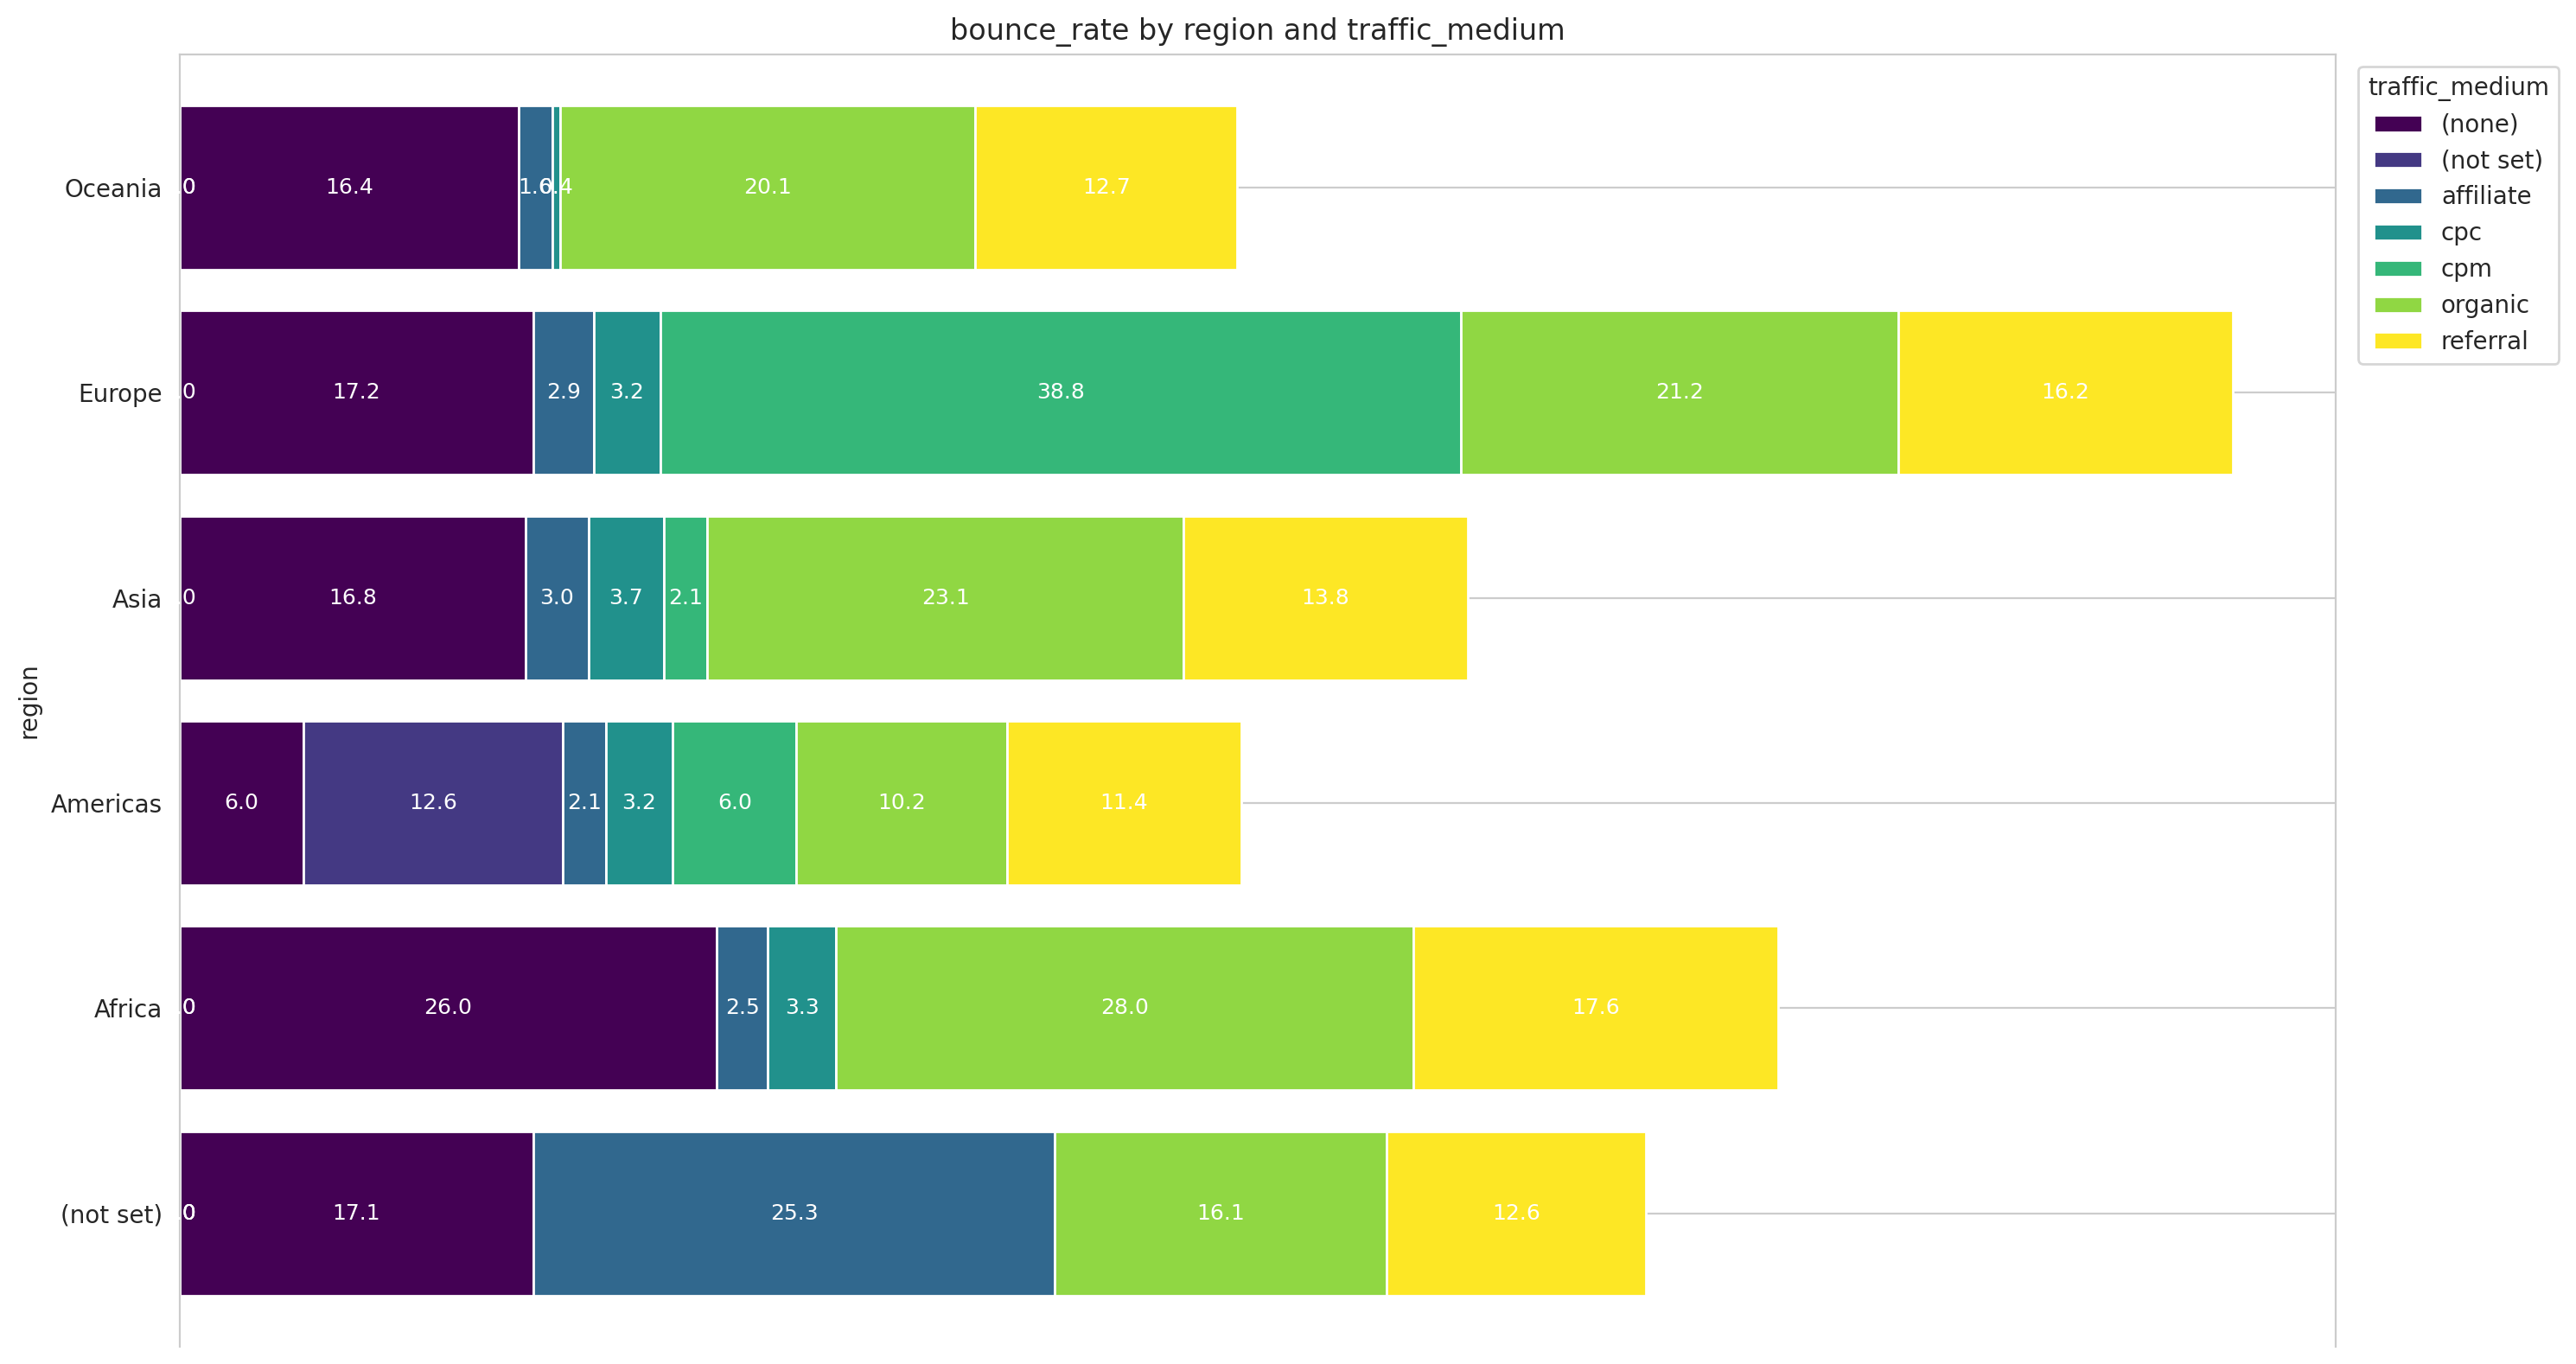

<Figure size 1500x800 with 0 Axes>

In [48]:
hier_analysis(data, [ 'region'  , 'traffic_medium'] , agg_bounce , name   )

<Figure size 1200x500 with 0 Axes>

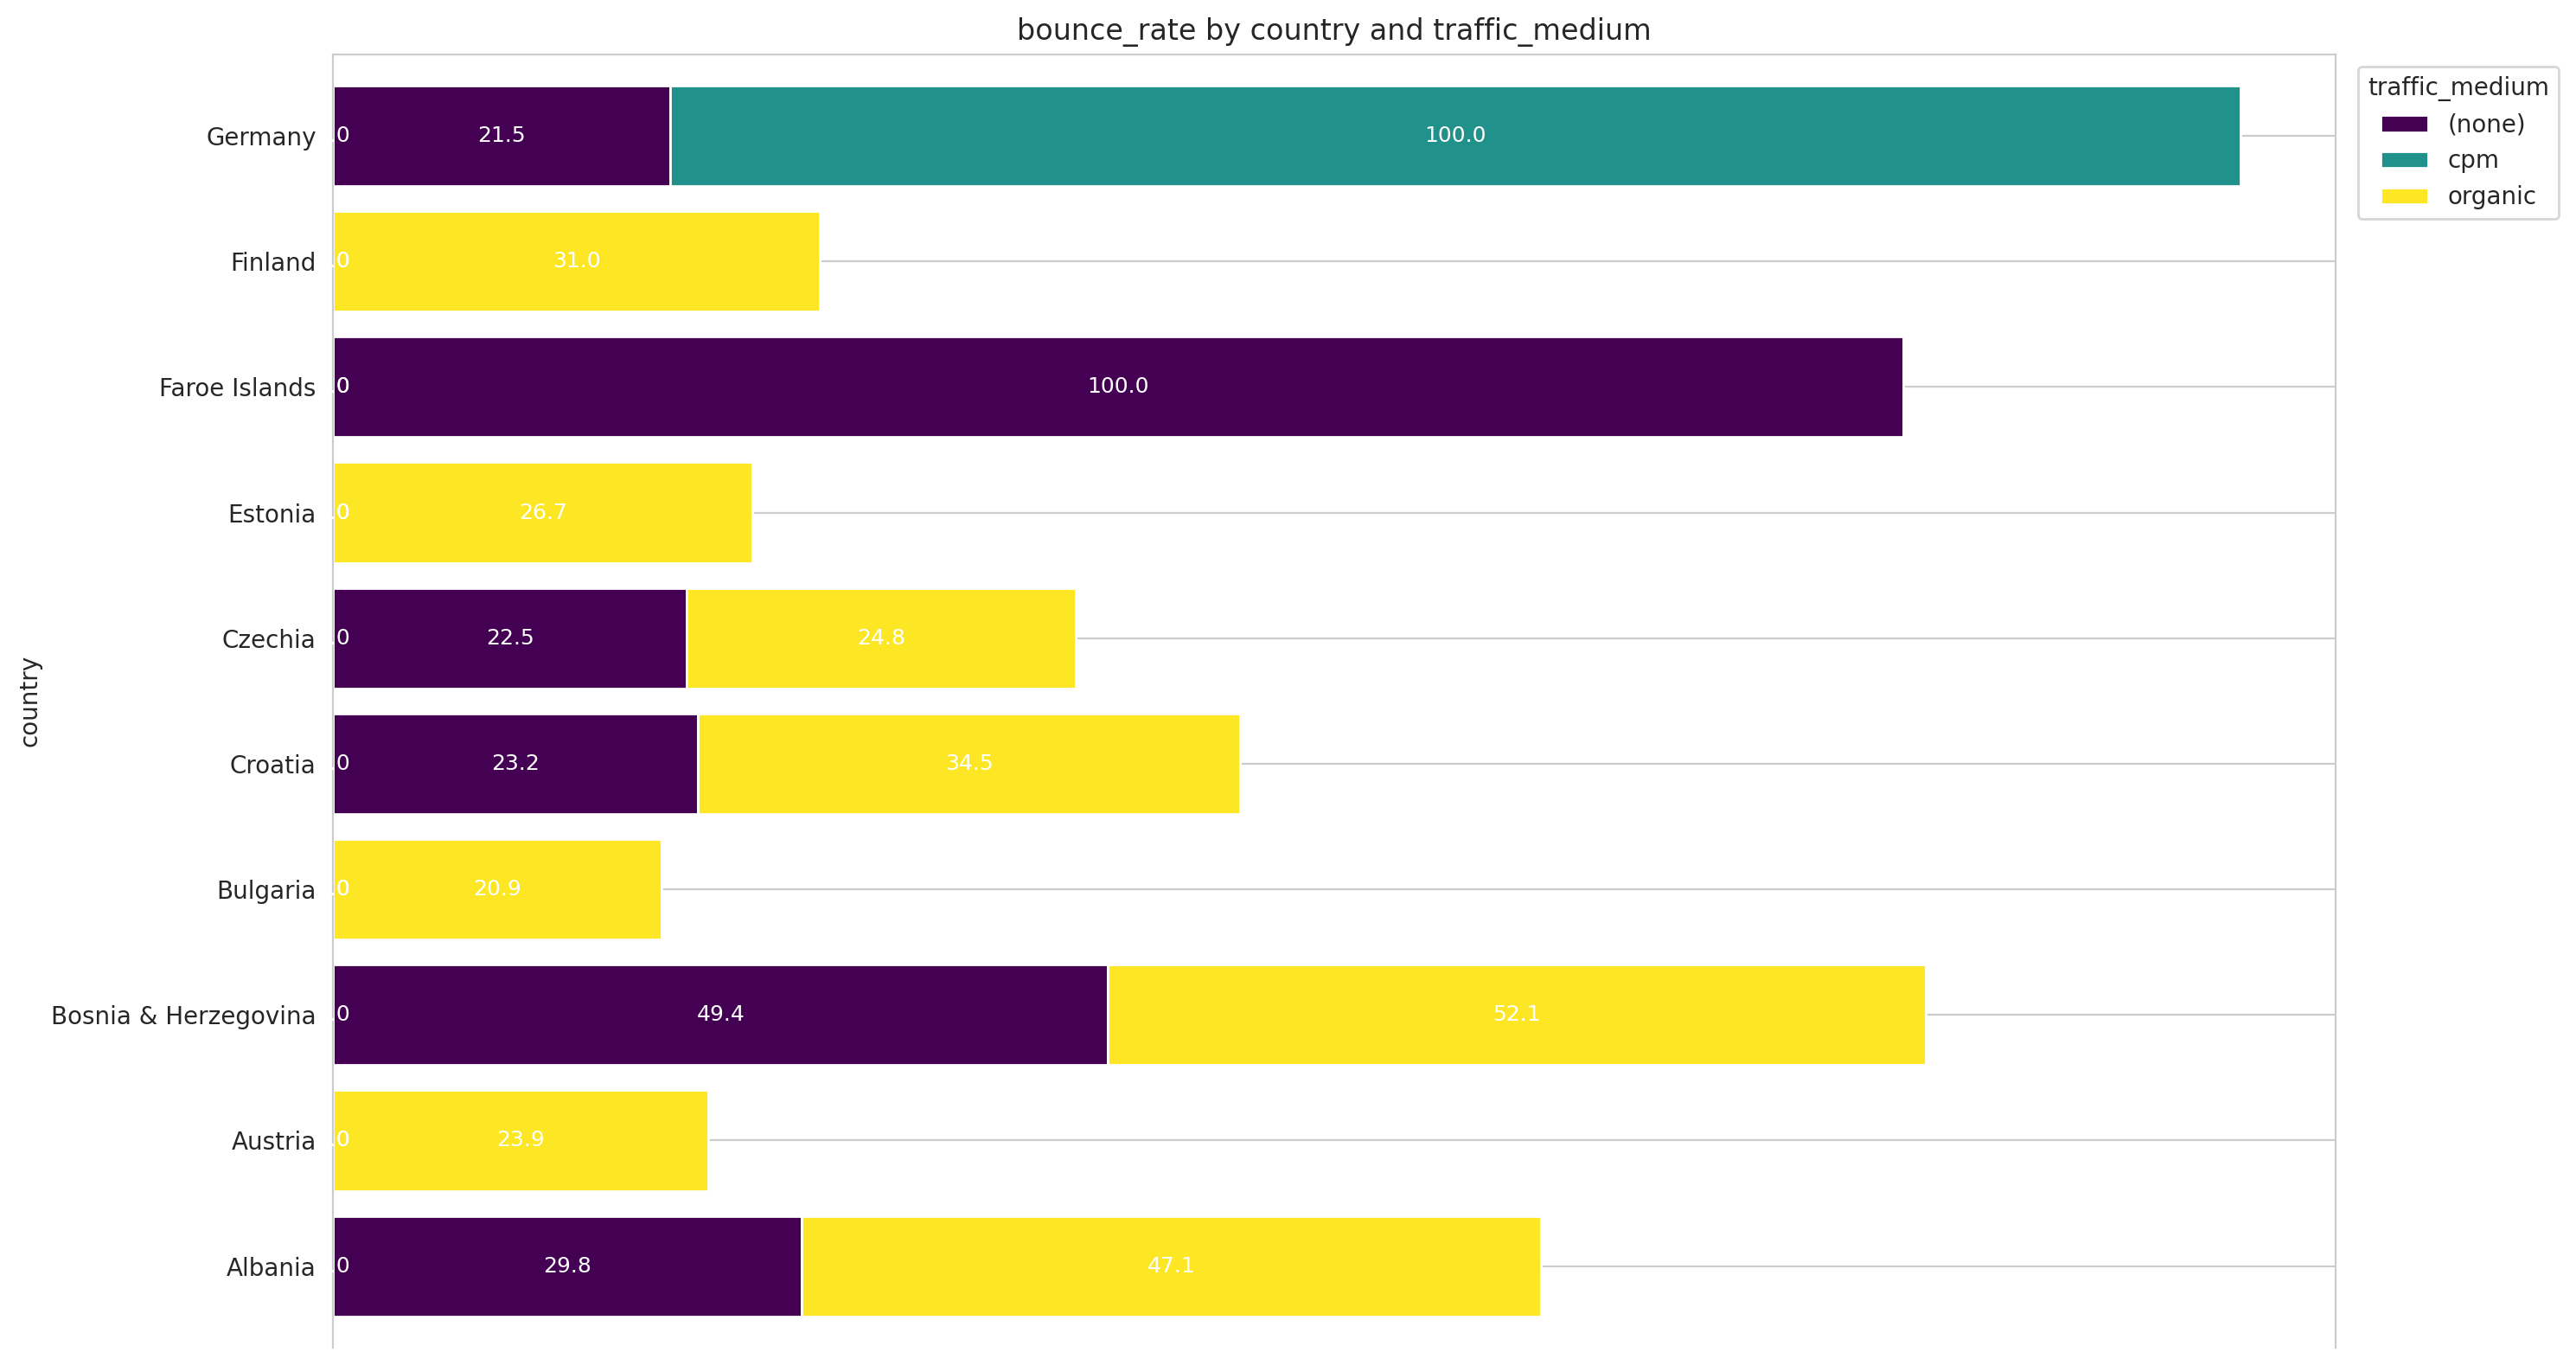

<Figure size 1500x800 with 0 Axes>

In [49]:
hier_analysis(data.loc[data['region']=='Europe' ,:], [ 'country'  , 'traffic_medium'] , agg_bounce , name  , Top=15 )

**Geographical analysis for bounce rate shows :**


1 - Lowest bounce rate is inside america , this is because most traffic is from there , and most of stores there as  well without much cargo cost.

2 - among all regions least bounce rate in each region is among affliate and cpc traffic 

3 - Africa has largest bounce traffic rate , i think due to Economic circumstances in most countries that makes users their less interested in e shopping except in case of affiliate marketing , they have least bounce rate after americas.

4 - Elephant in the room , CPC traffic in Europe has largest bounce rate , an issue should be studied which comes from 2 reasons 
   * General lack of CPM marketing
   * and in the case it was used (Germany) it was used in effeciently , reasoning a very large bounce rate 100 %.

#### By time

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

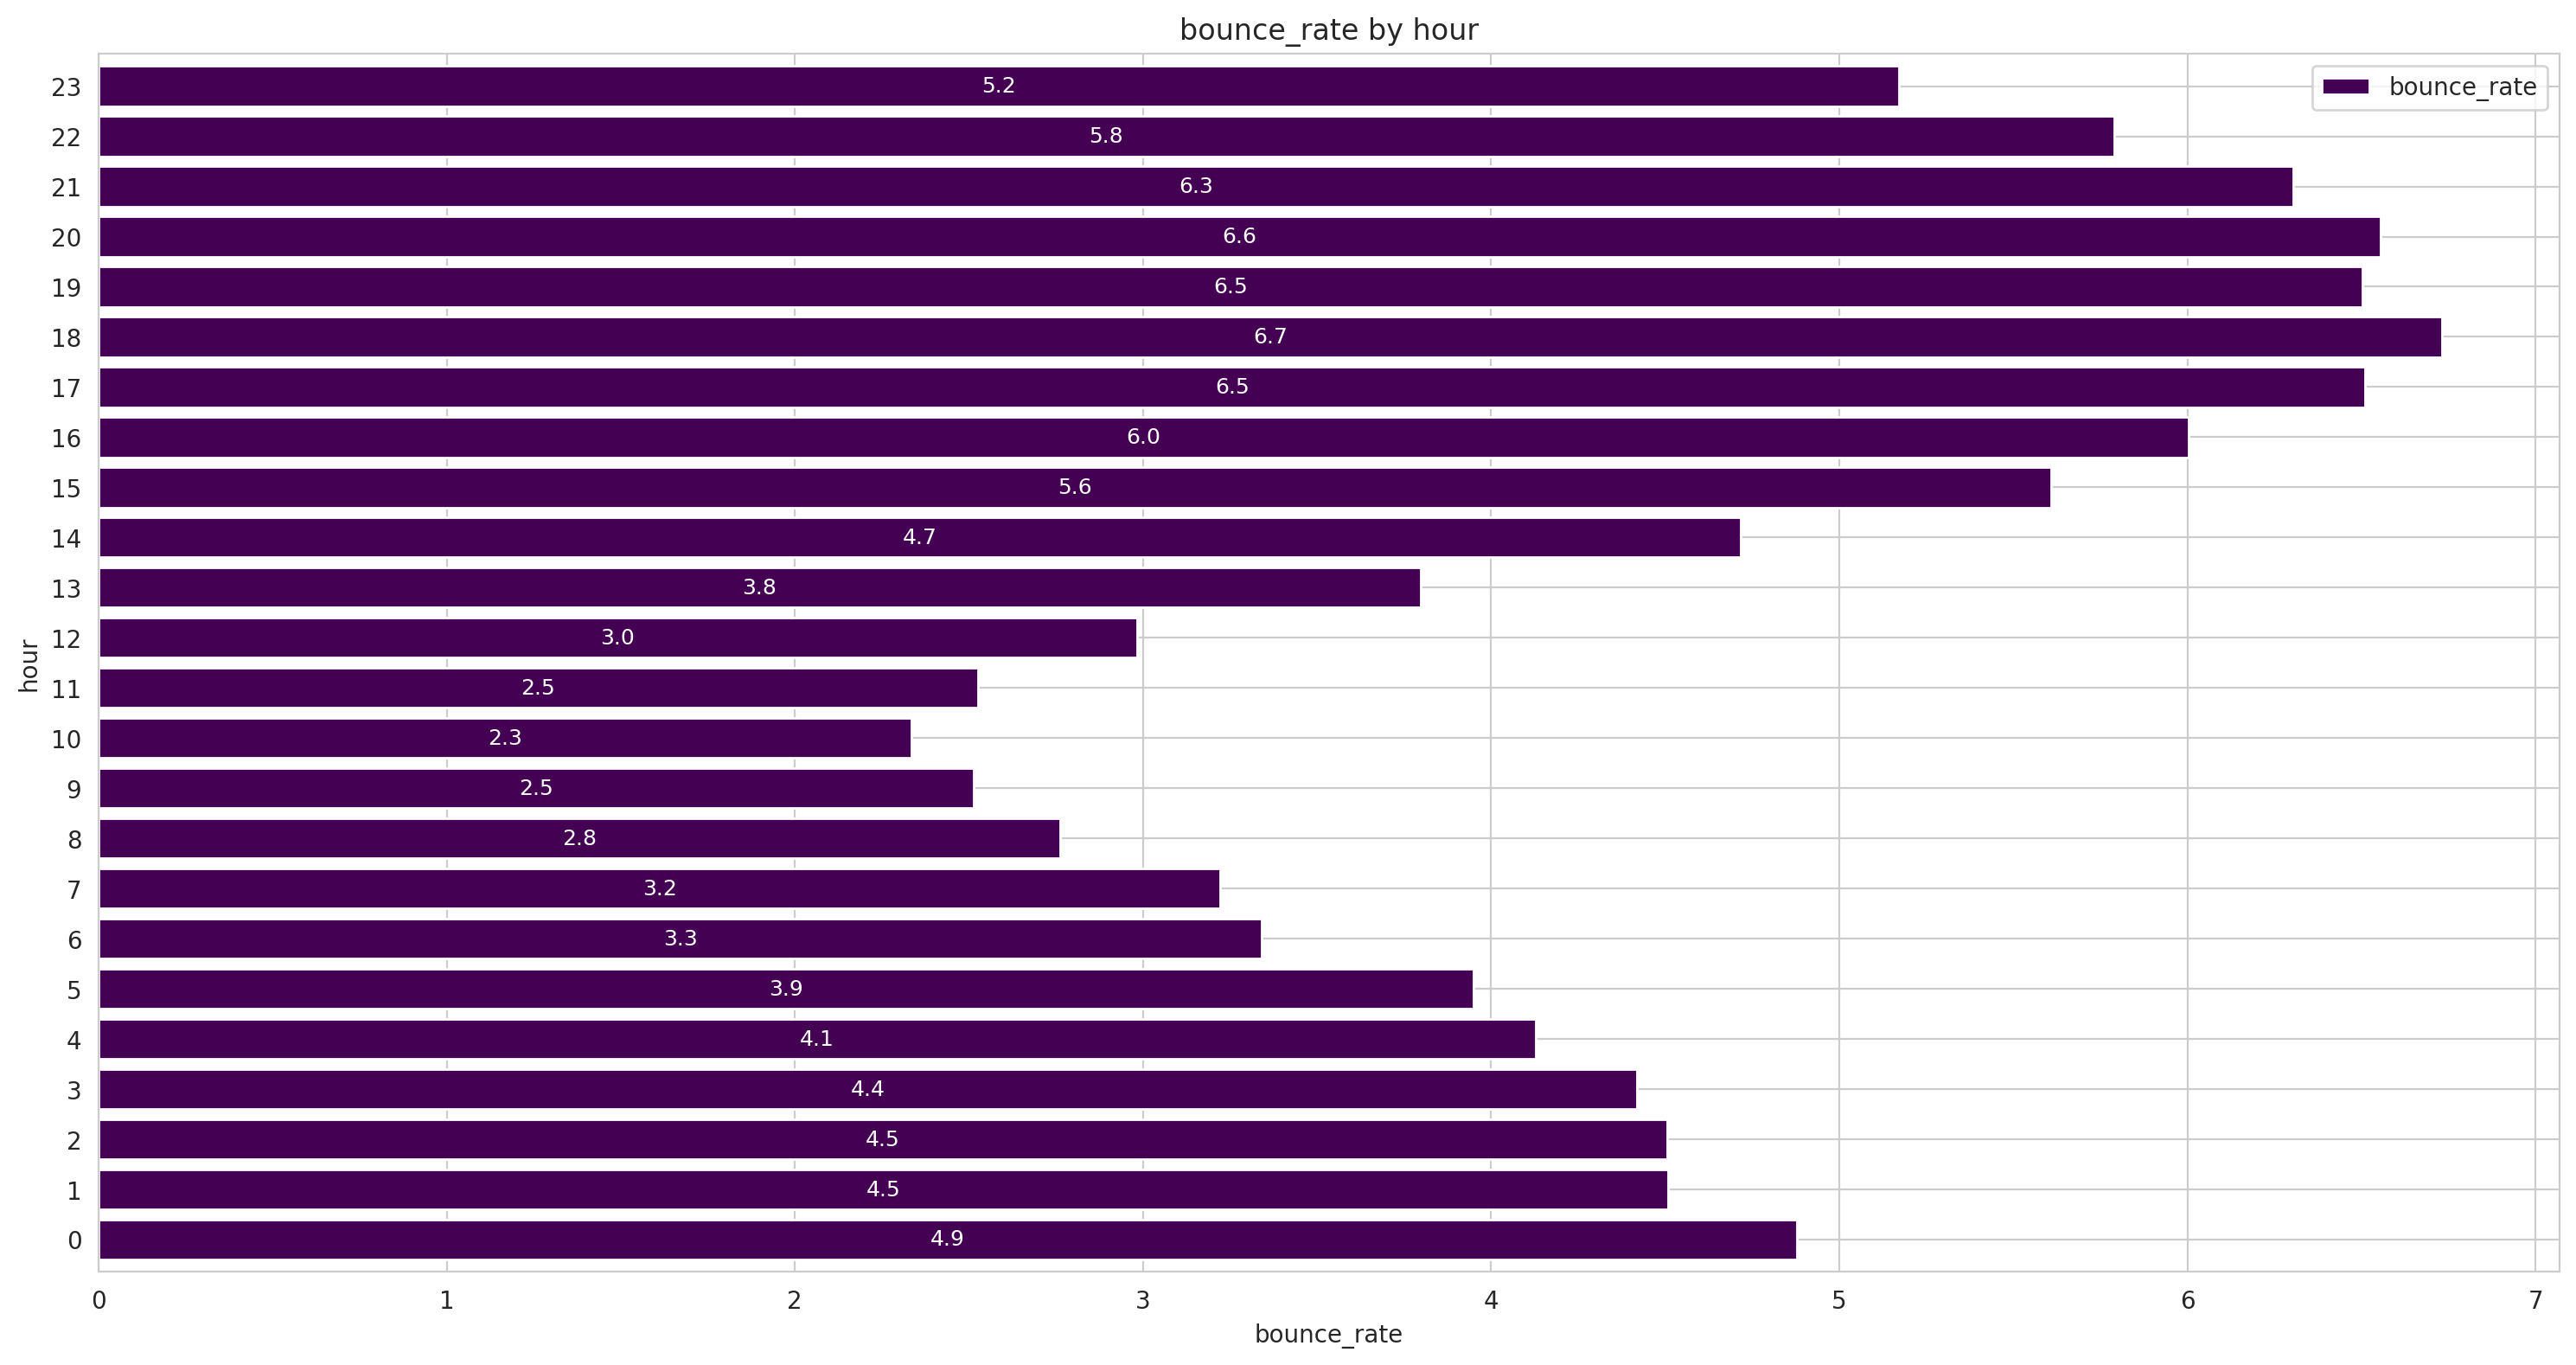

<Figure size 1500x800 with 0 Axes>

In [50]:
hier_analysis(data, [  'hour'] , lambda x : (x['total_sessions'].sum()/100000) , name )

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

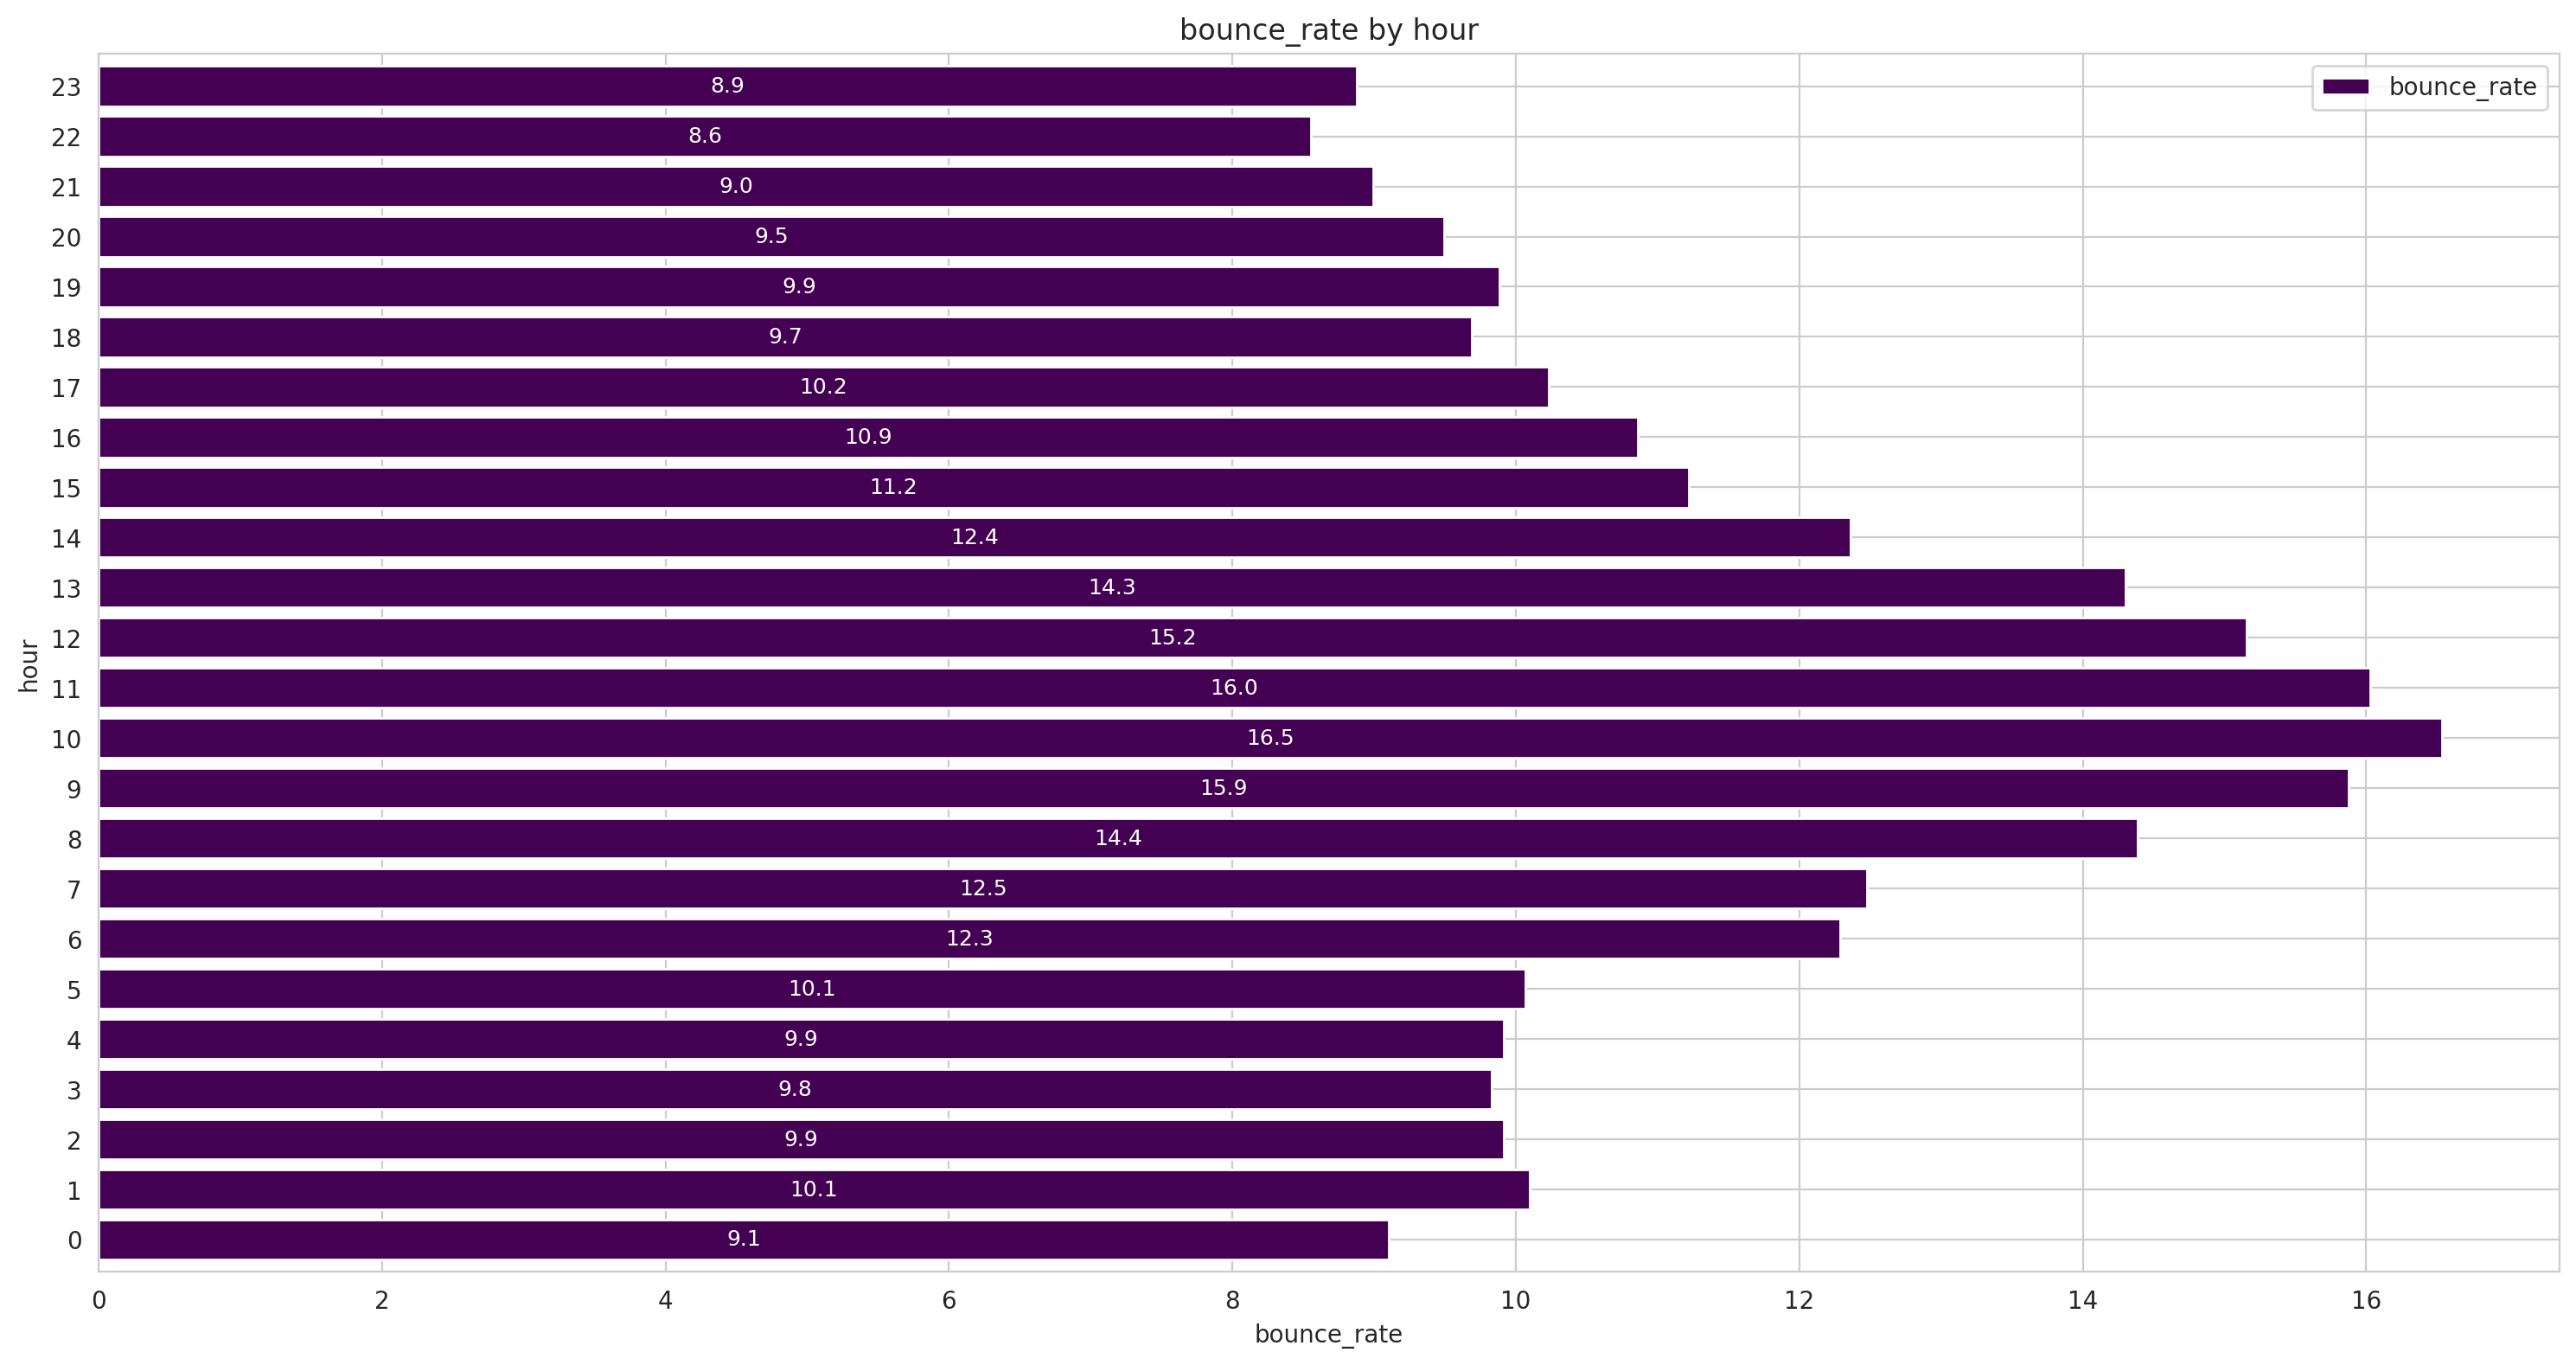

<Figure size 1500x800 with 0 Axes>

In [51]:
hier_analysis(data, [  'hour'] , agg_bounce , name )

We find that largest bounce rates are between 6 and 3 PM despite having least number of sessions , may be due to these are work hours , so people are less concentrating in E shopping

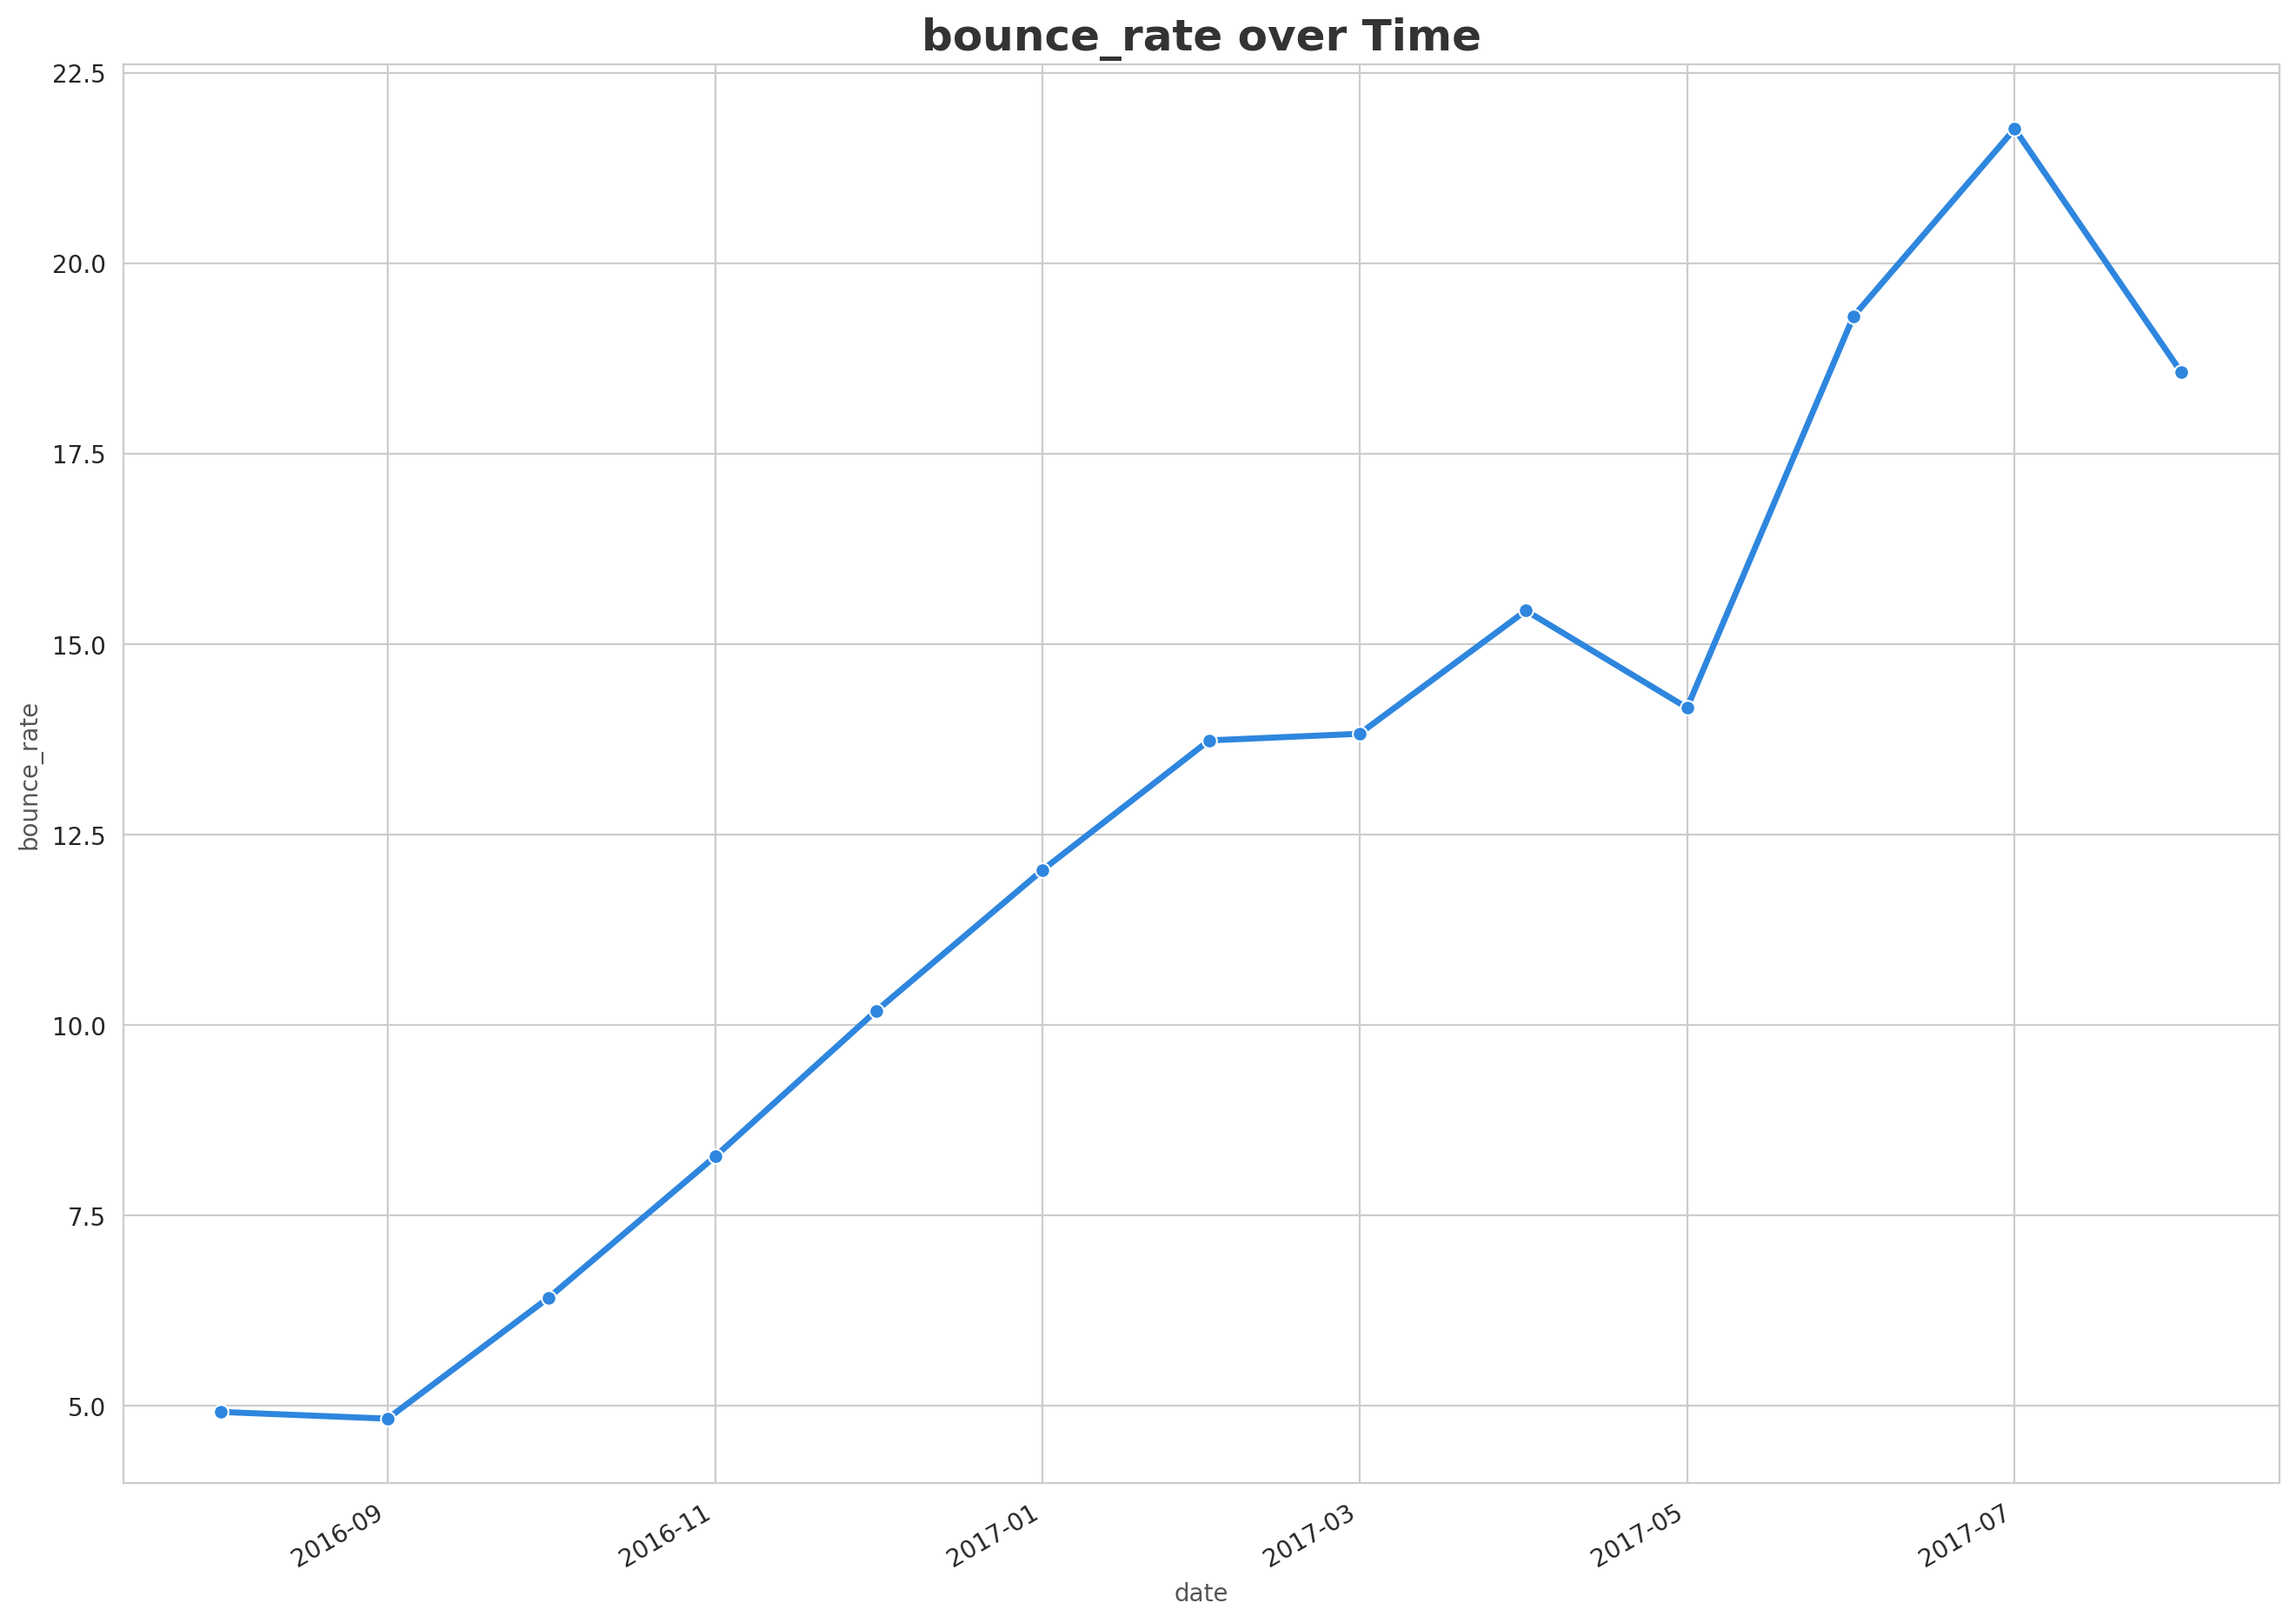

In [52]:
hier_analysis(data ,[ 'date'] , agg_bounce , name  , time_column ='date' , figsize=(16,12))

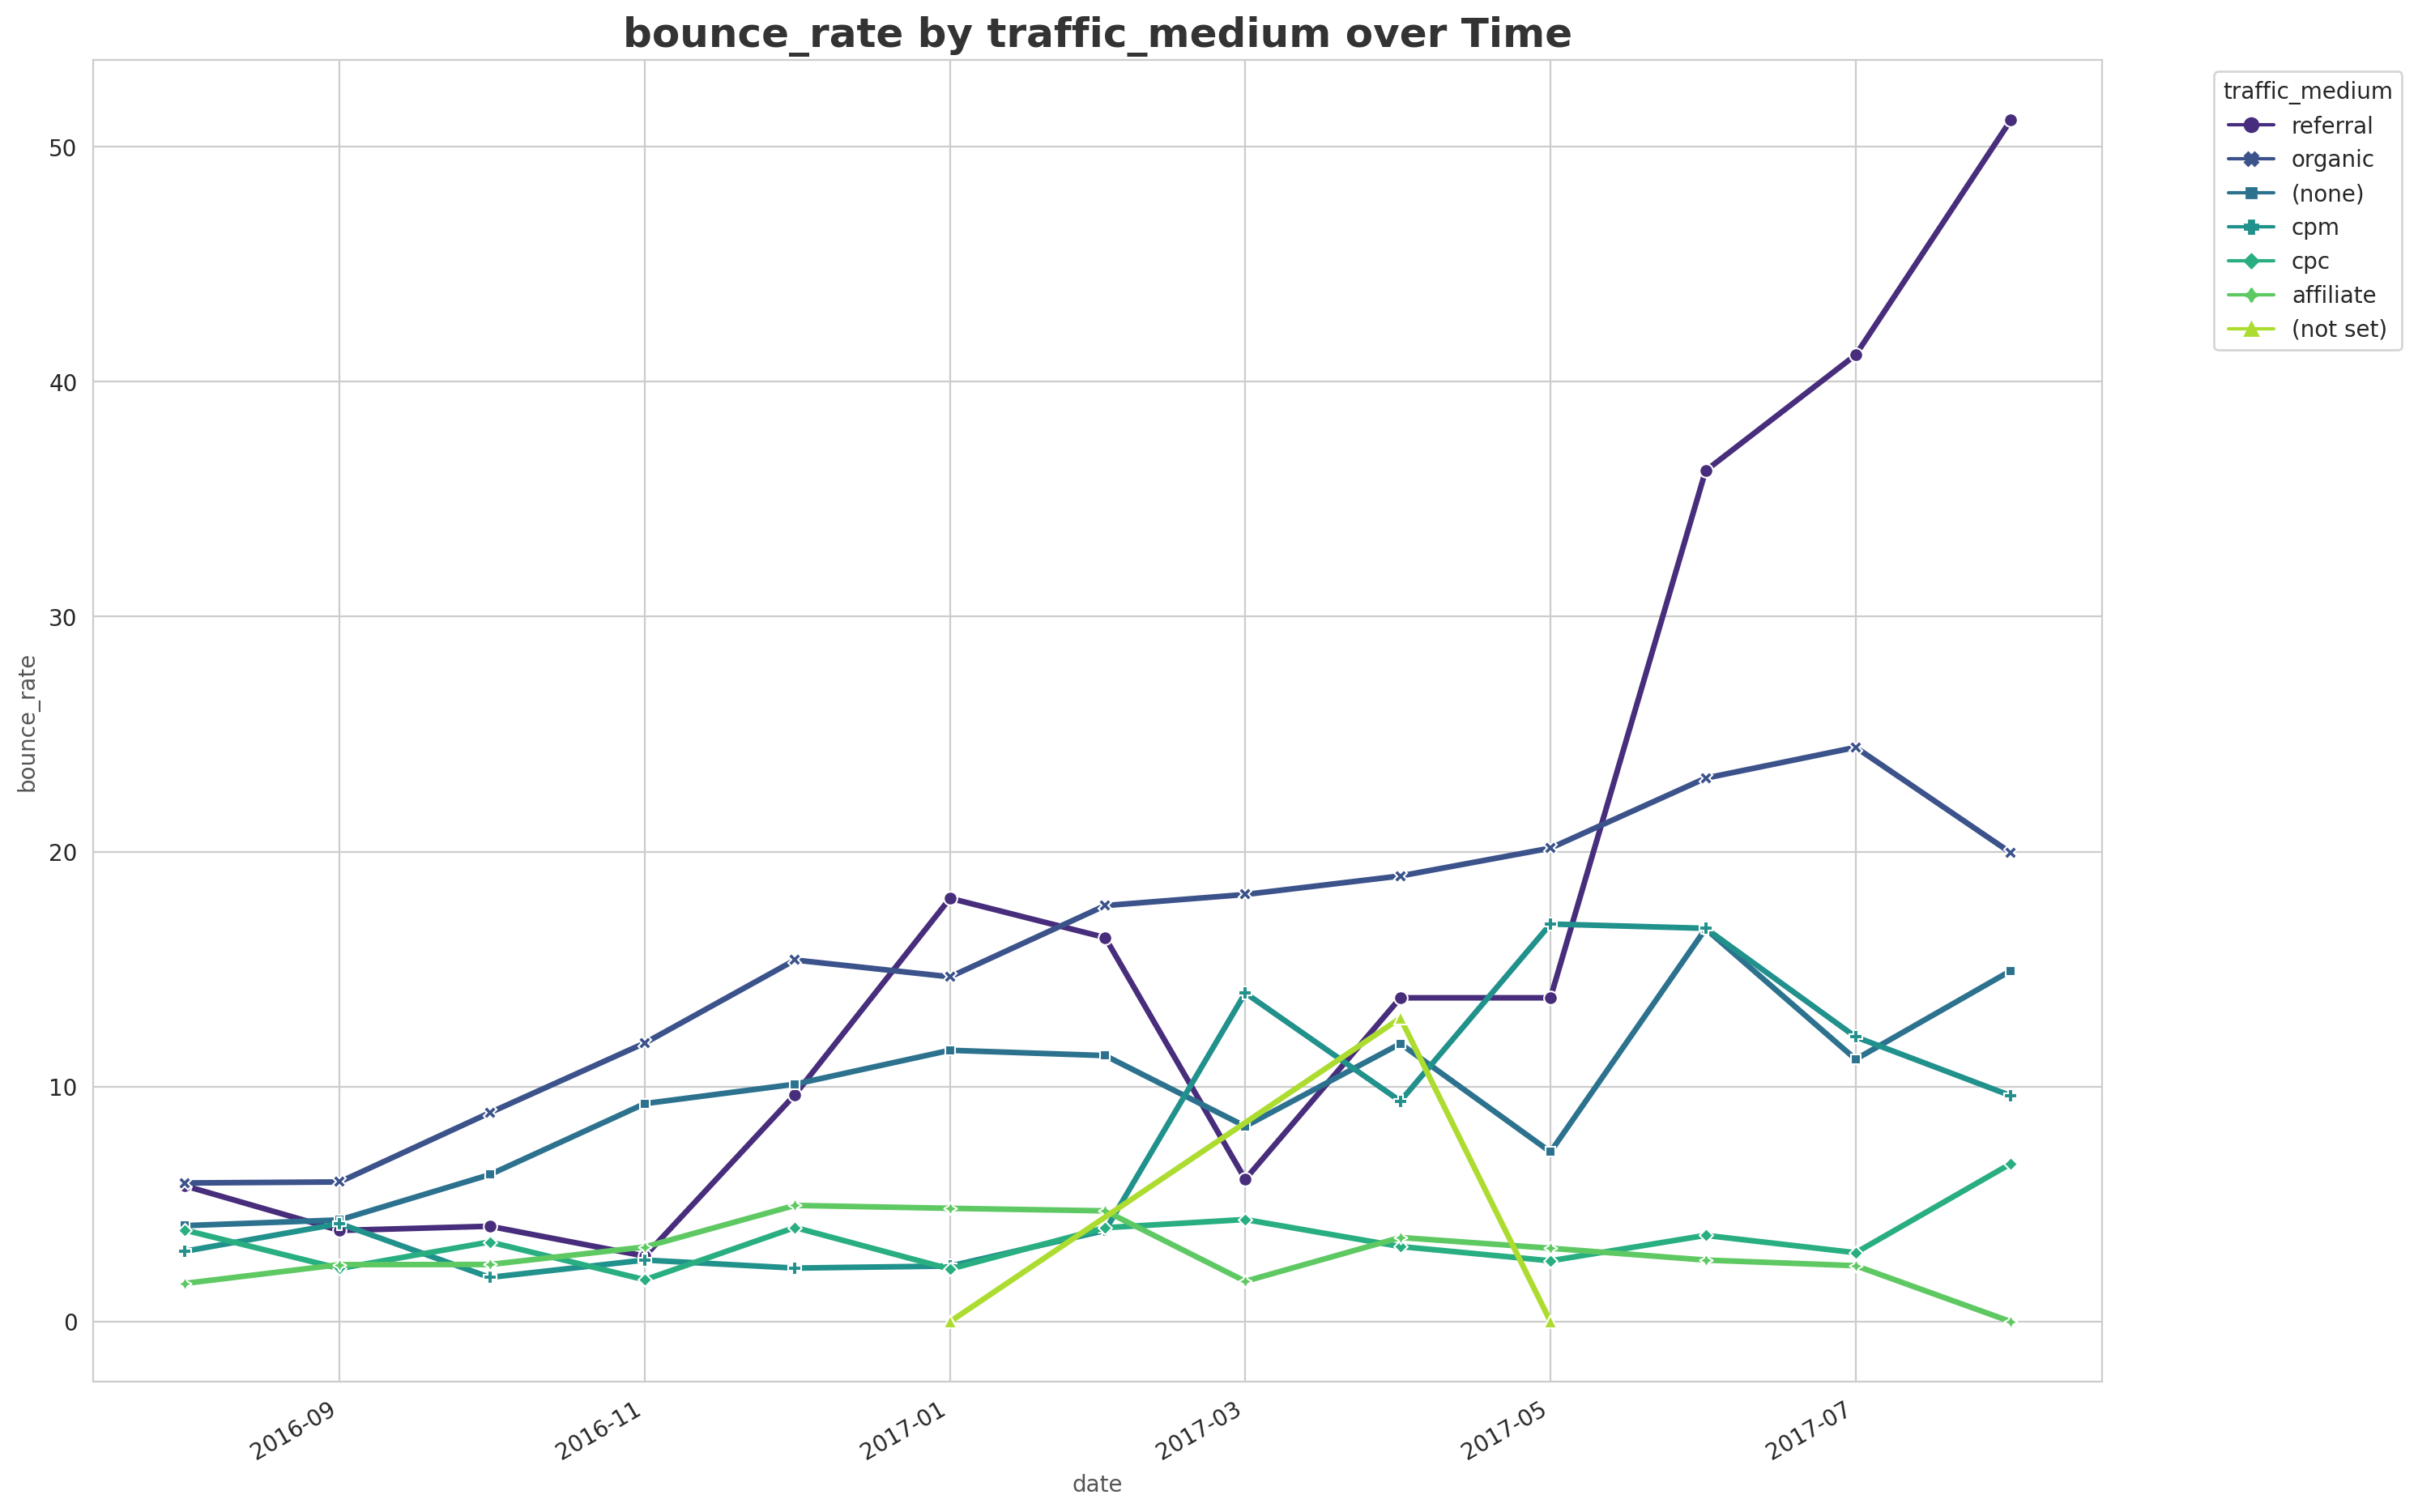

In [53]:
hier_analysis(data , ['traffic_medium' , 'date'  ] , agg_bounce , name  , time_column='date' , figsize=(16,12) )

Here we see that bounce rate is increasing over time , and it is clear that this increase , especially in the later months is due to the large increase in bounce rate from refferal and organic sources

#### By user type 

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

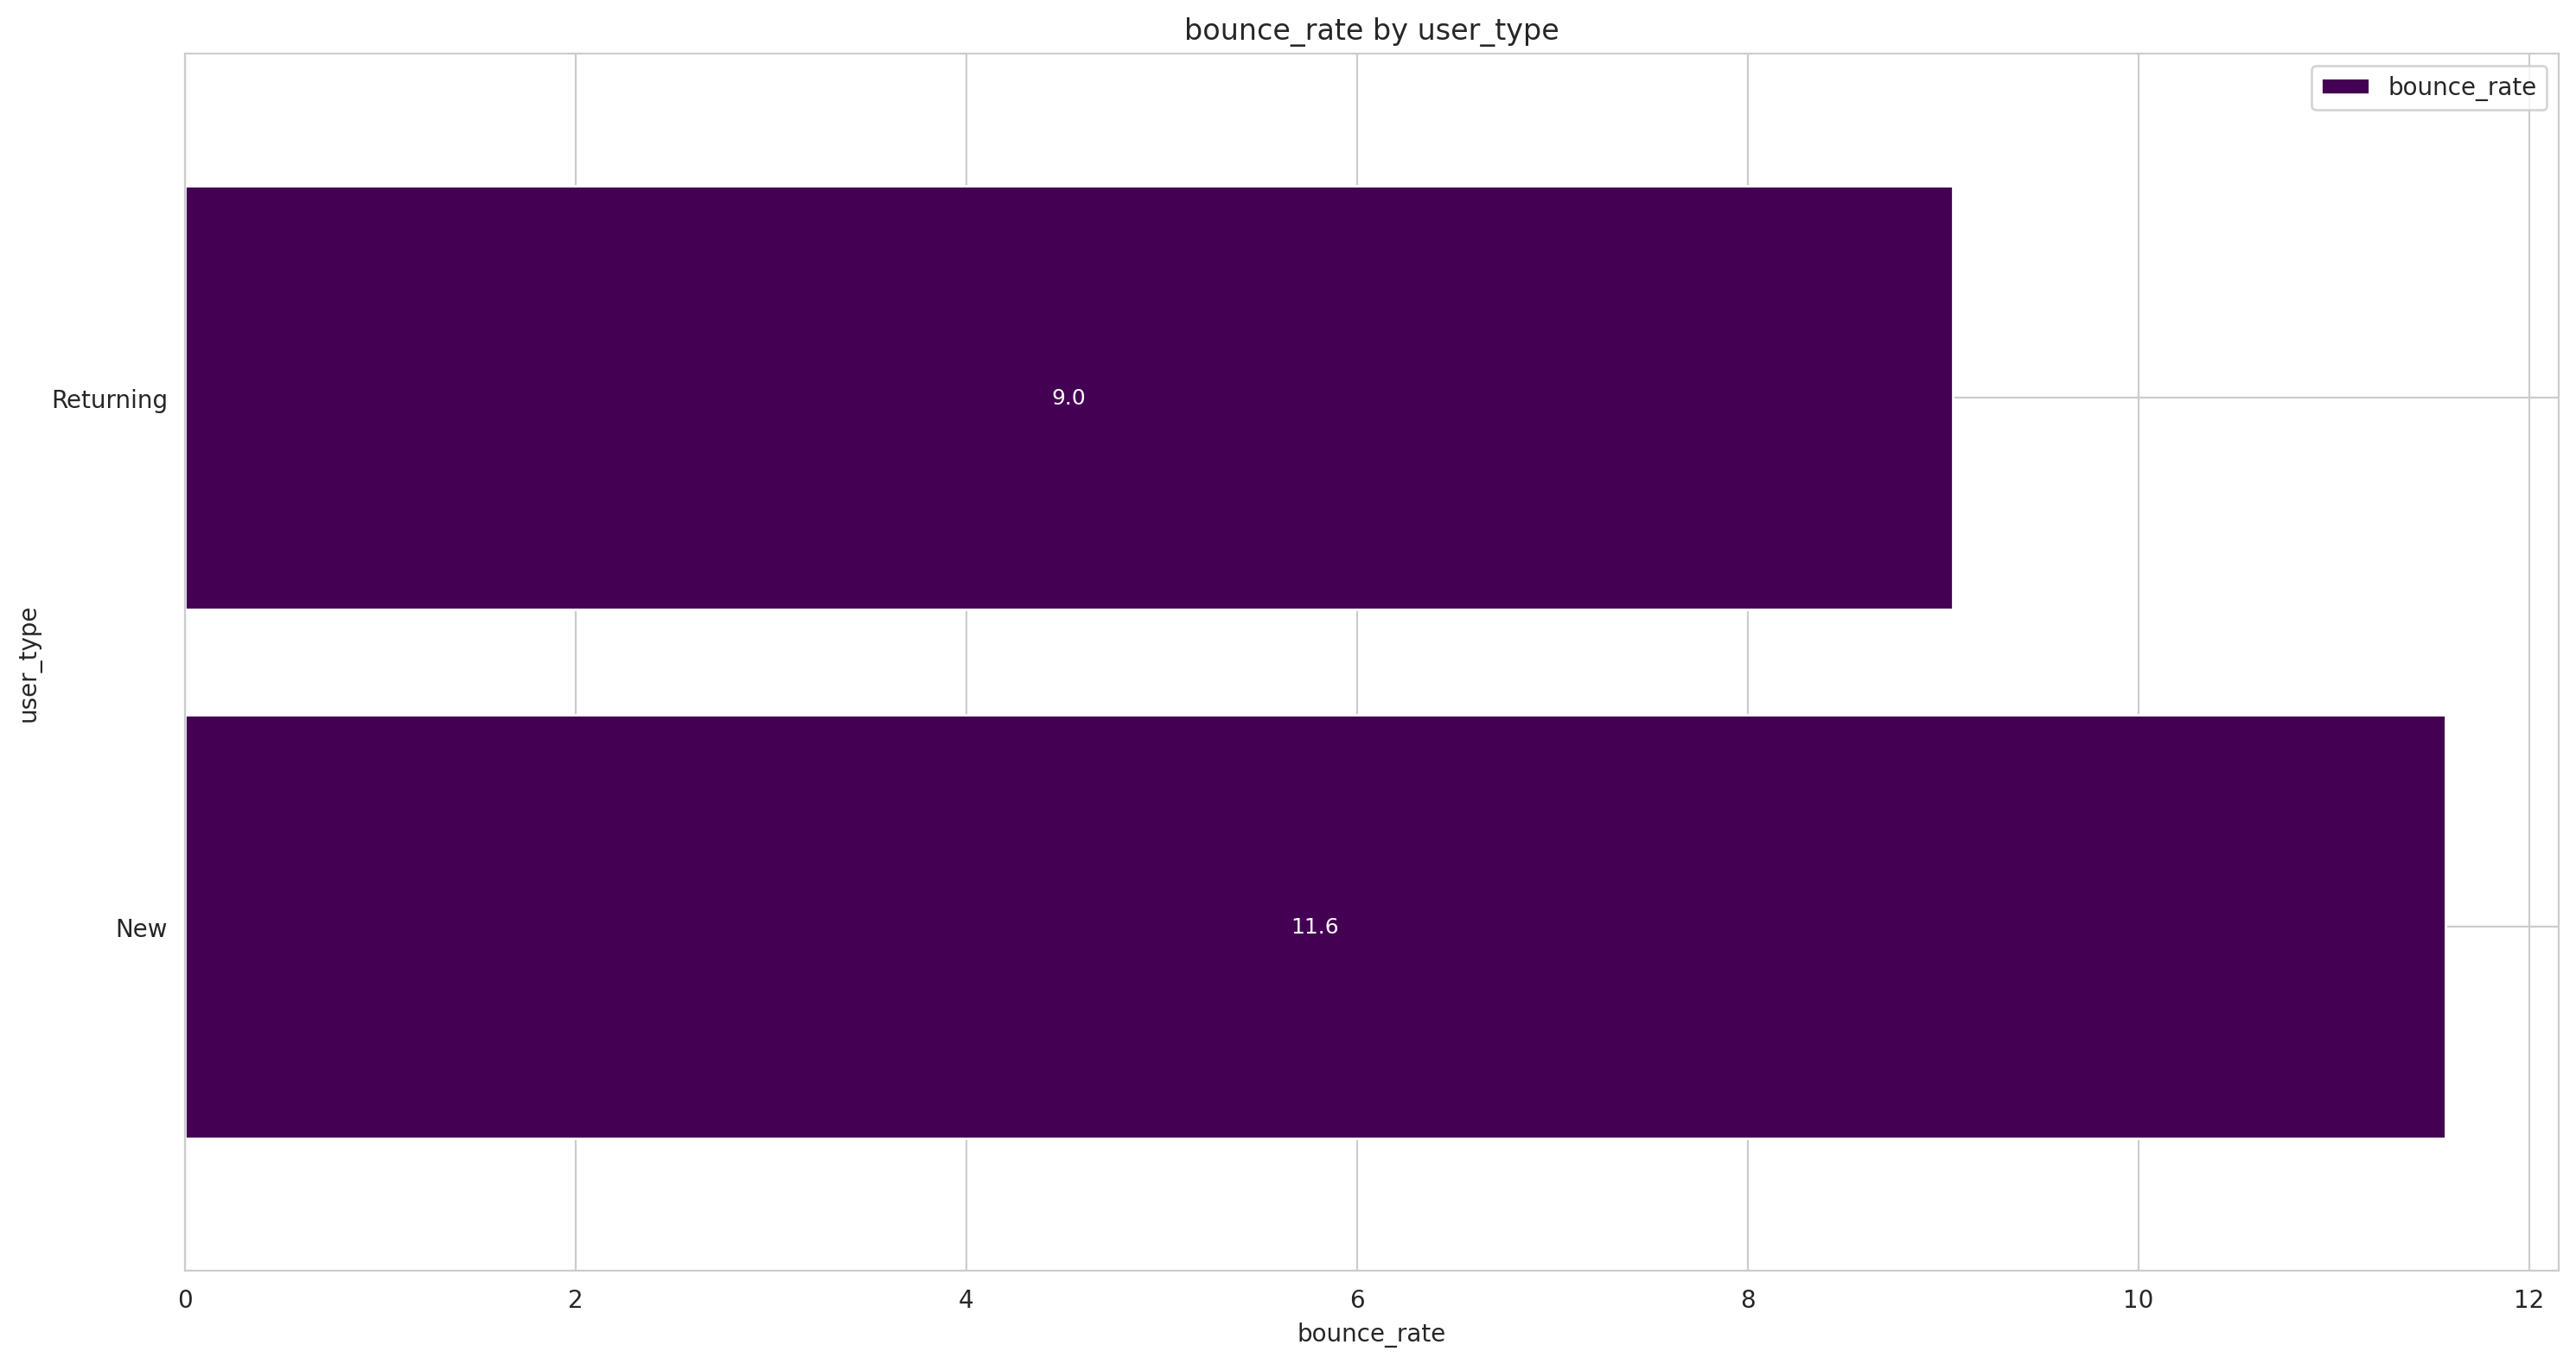

<Figure size 1500x800 with 0 Axes>

In [54]:
hier_analysis(data , [ 'user_type'  
                                                                            ] , agg_bounce , name )

Generally bounce rate is less among returning users is less , clear reason because the probability of misclick and totally lack of interest in the product among returning users is less.

<Figure size 1200x500 with 0 Axes>

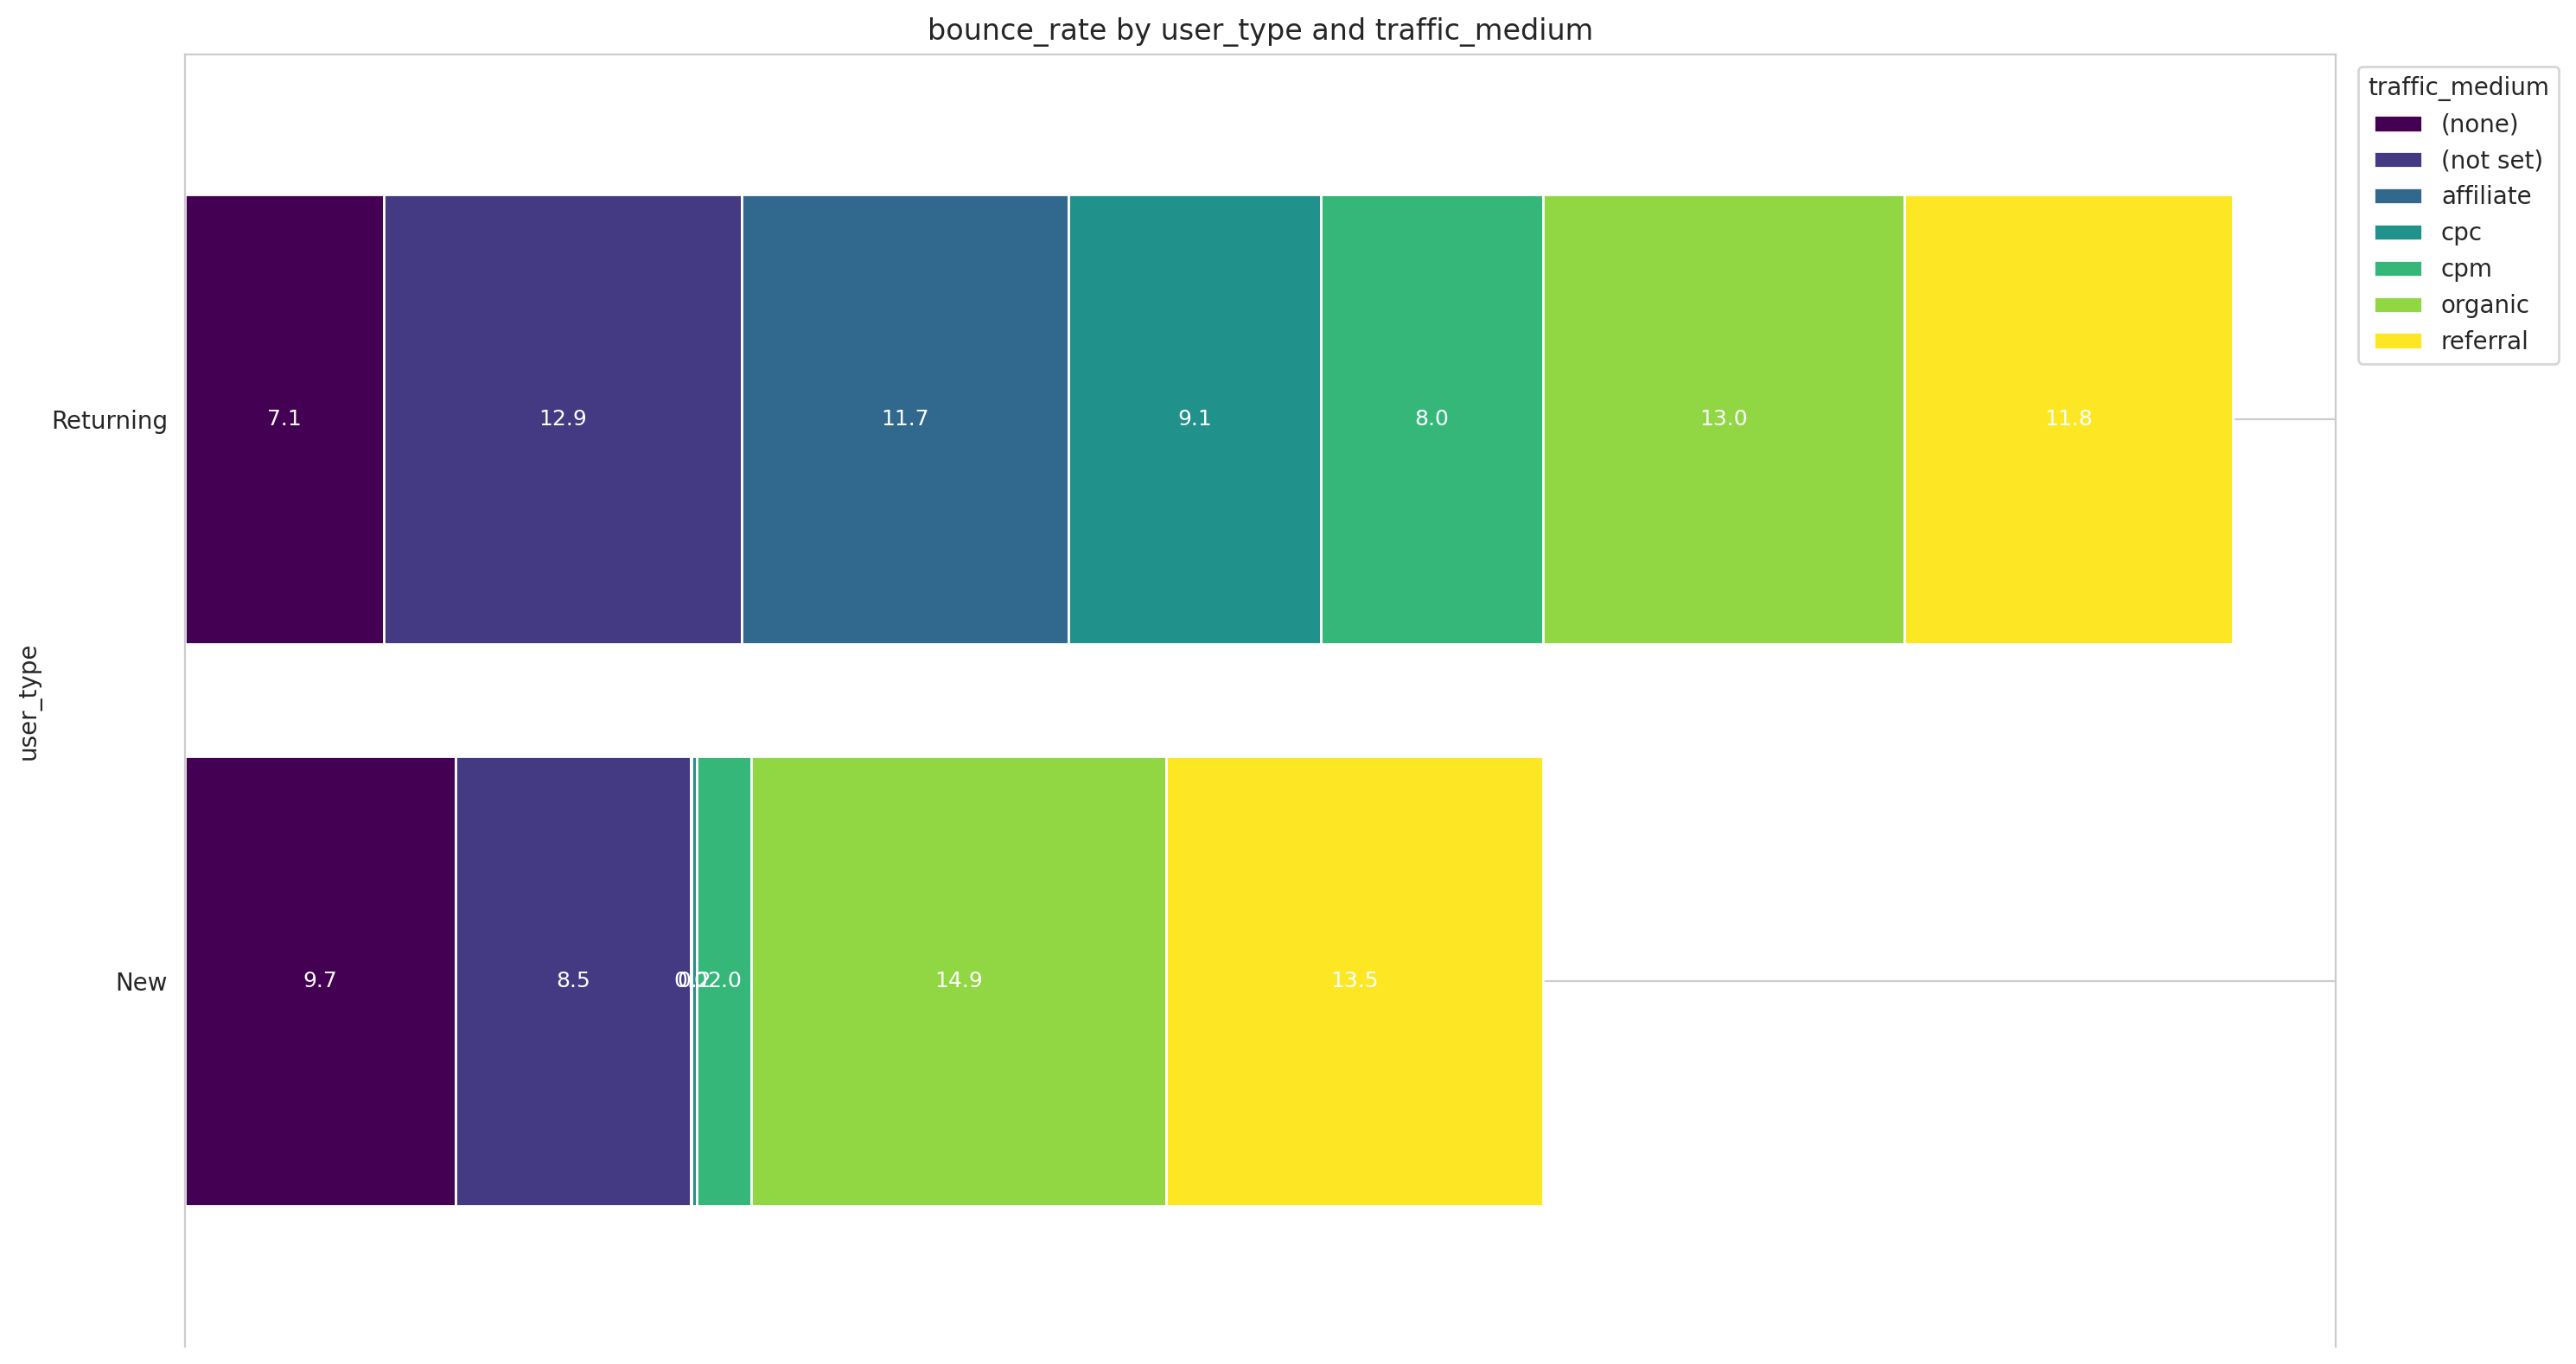

<Figure size 1500x800 with 0 Axes>

In [55]:
hier_analysis(data , [ 'user_type' , 
                                                                            'traffic_medium'] , agg_bounce , name )

Despite the fact above ,we notice that specifically among the new users , bounce rate among affiliate , cpc traffic sources drops almost to zero . 

Simply users join customers of a specific products through these programs , when i purchase a new product simply i must get a specific offer or a brobaganda that makes me think seriously about this product , even if i don't need it now.

#### By Product

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

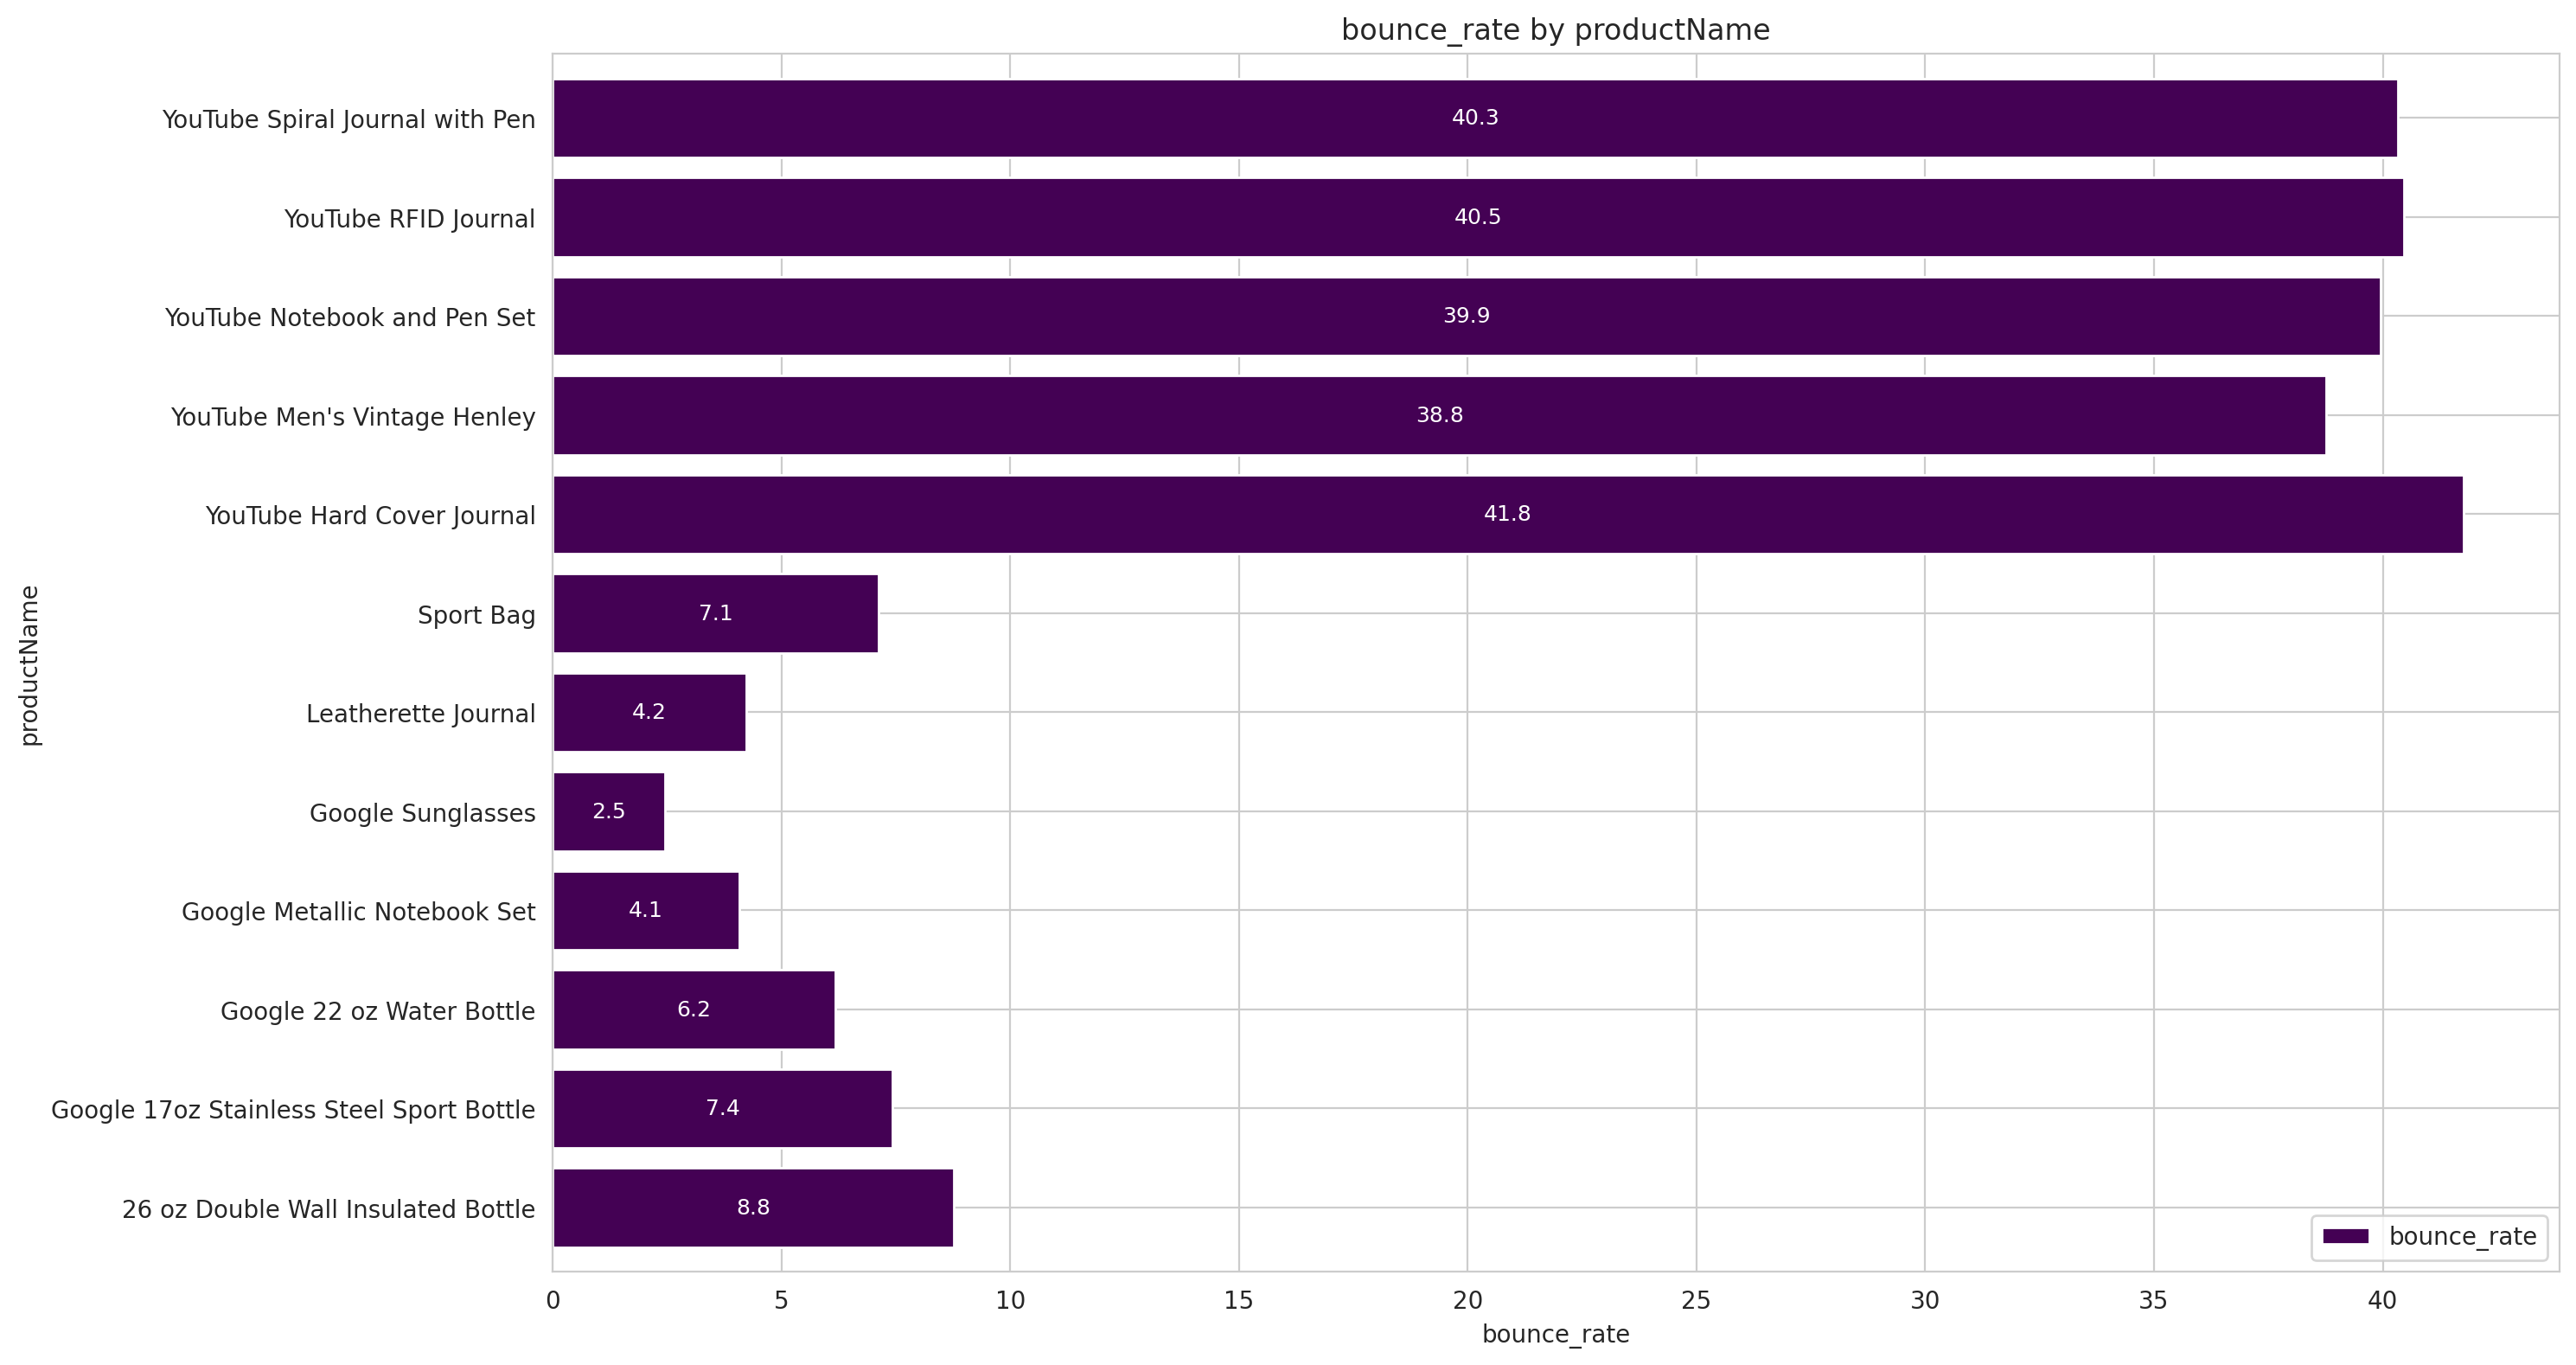

<Figure size 1500x800 with 0 Axes>

In [56]:


hier_analysis(data.loc[data['productName'].isin(top_bounce + list(most_effecient_products['productName'])) ,:] , ['productName' ] , agg_bounce , name  )

Comparing bounce rate among the most successful products and top bounce rate , clarifies the role it plays in revenue , while in the top 5 bounce rate products rate is around 40 % in the most successful ones is less than 10 %.

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

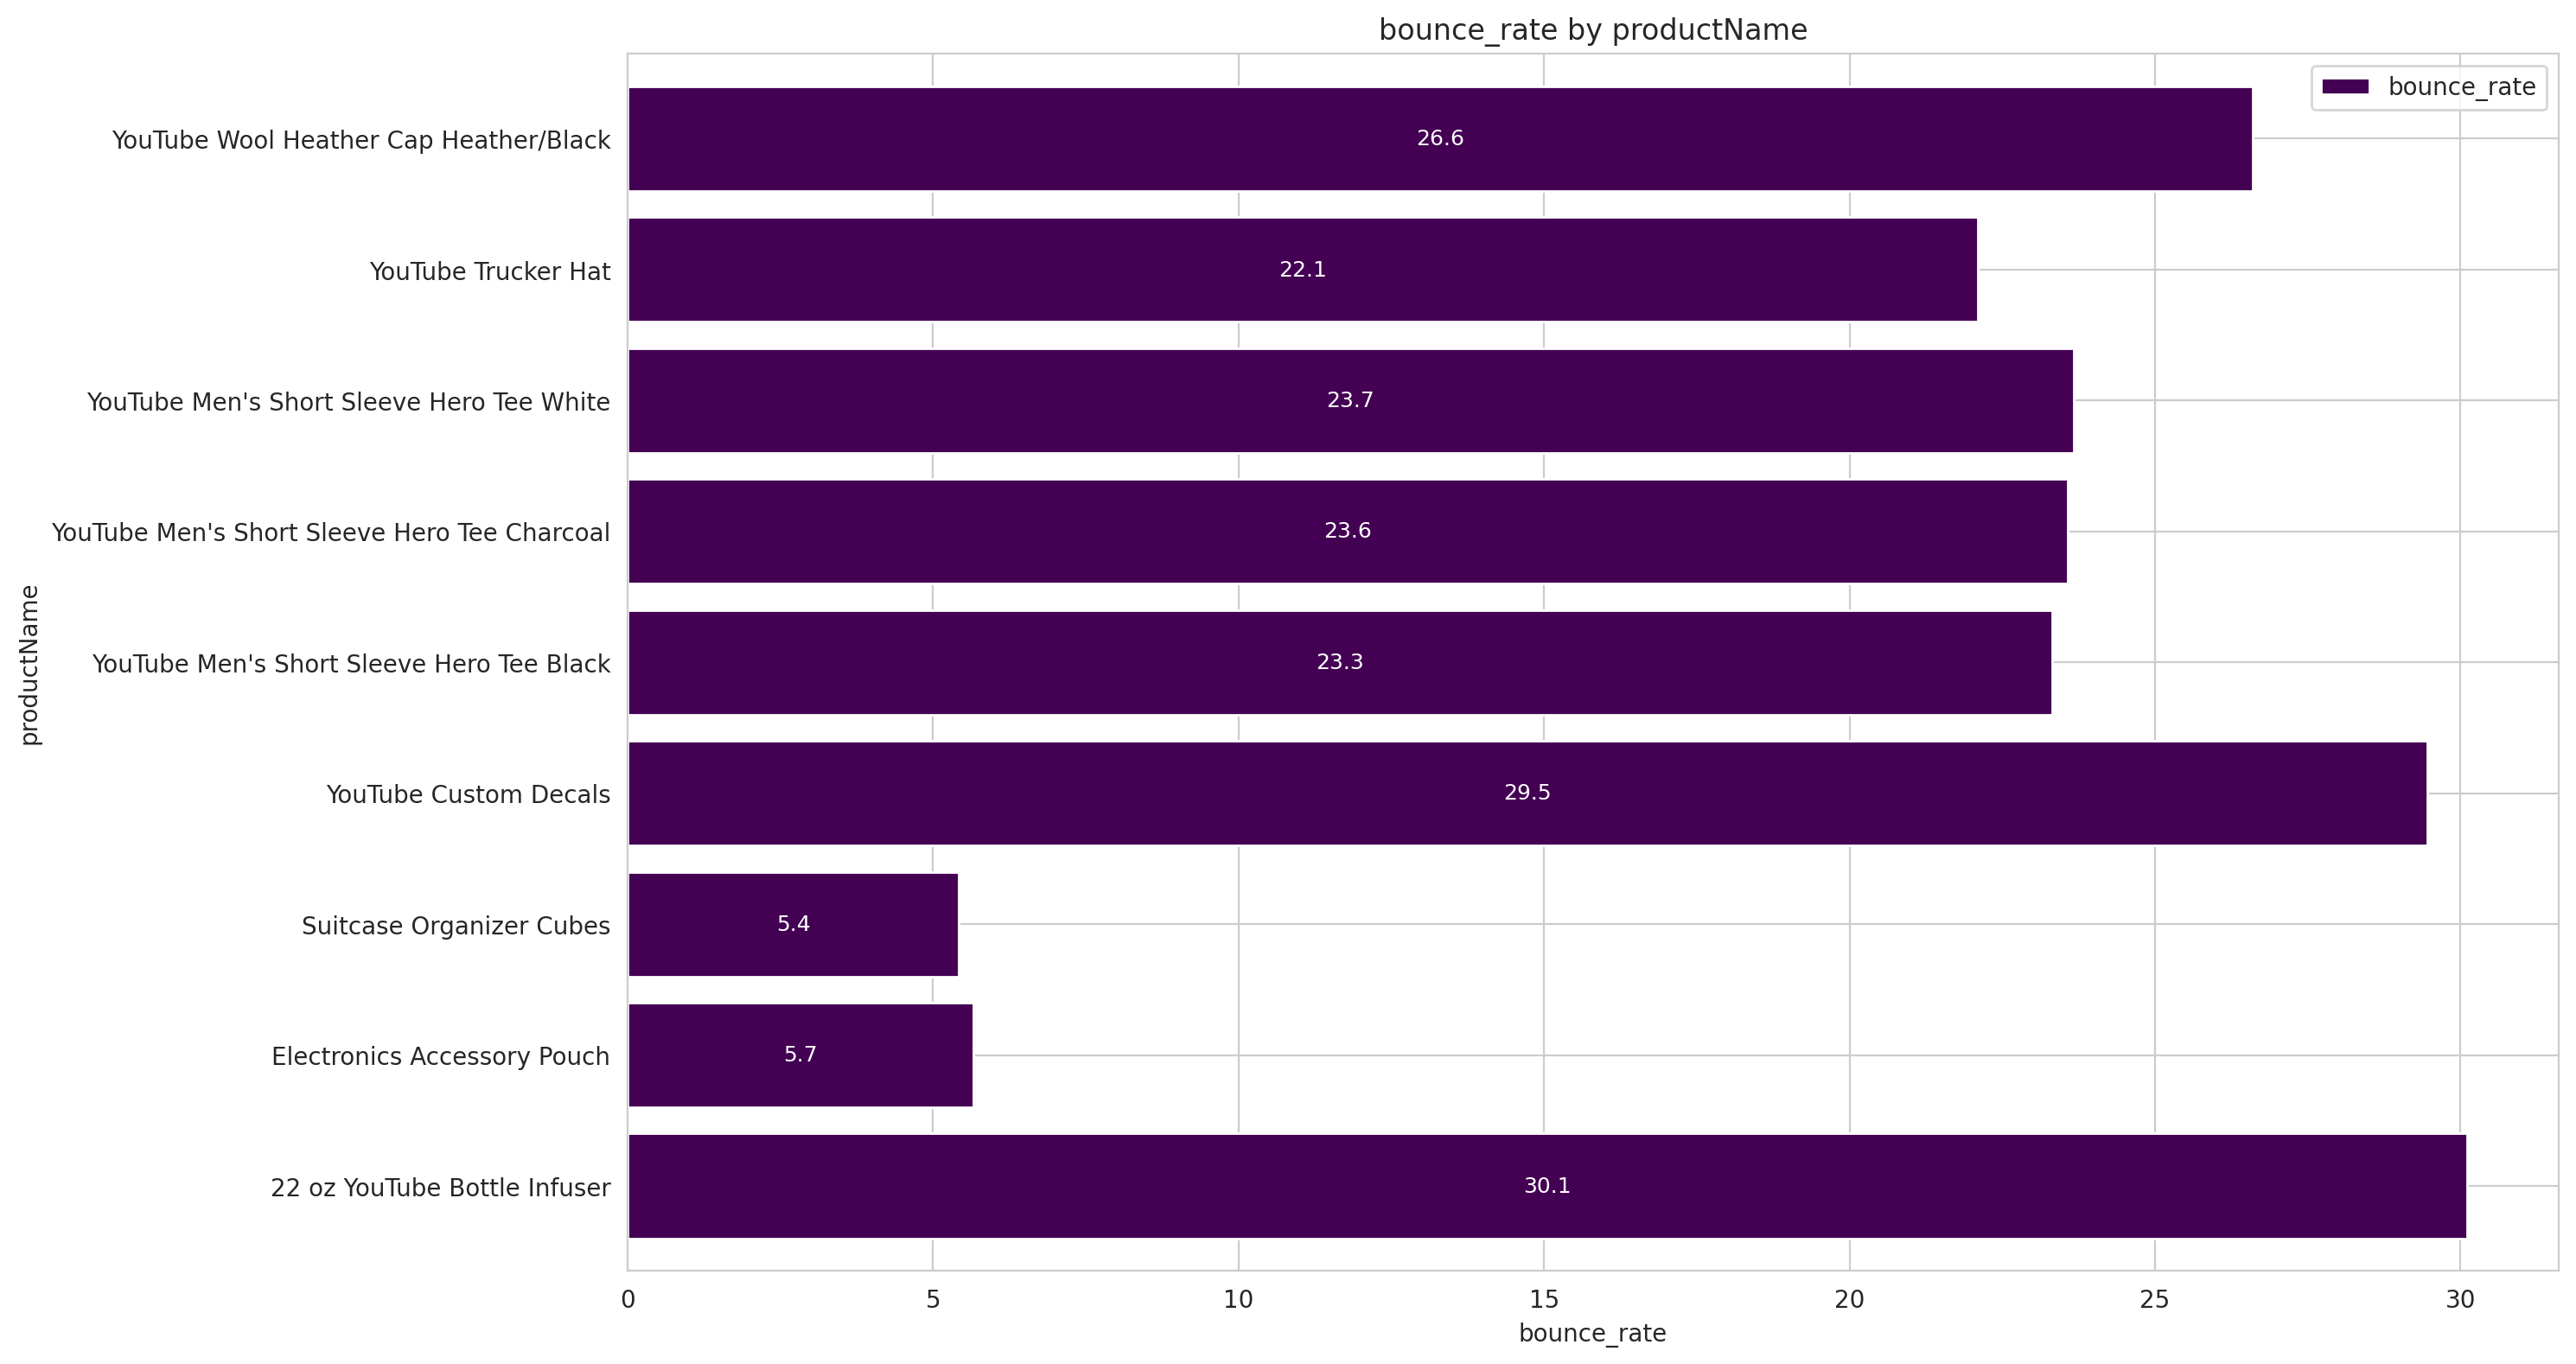

<Figure size 1500x800 with 0 Axes>

In [57]:
hier_analysis(data.loc[data['productName'].isin(list(least_effecient_products['productName'])) ,:] , ['productName' ] , agg_bounce , name  )

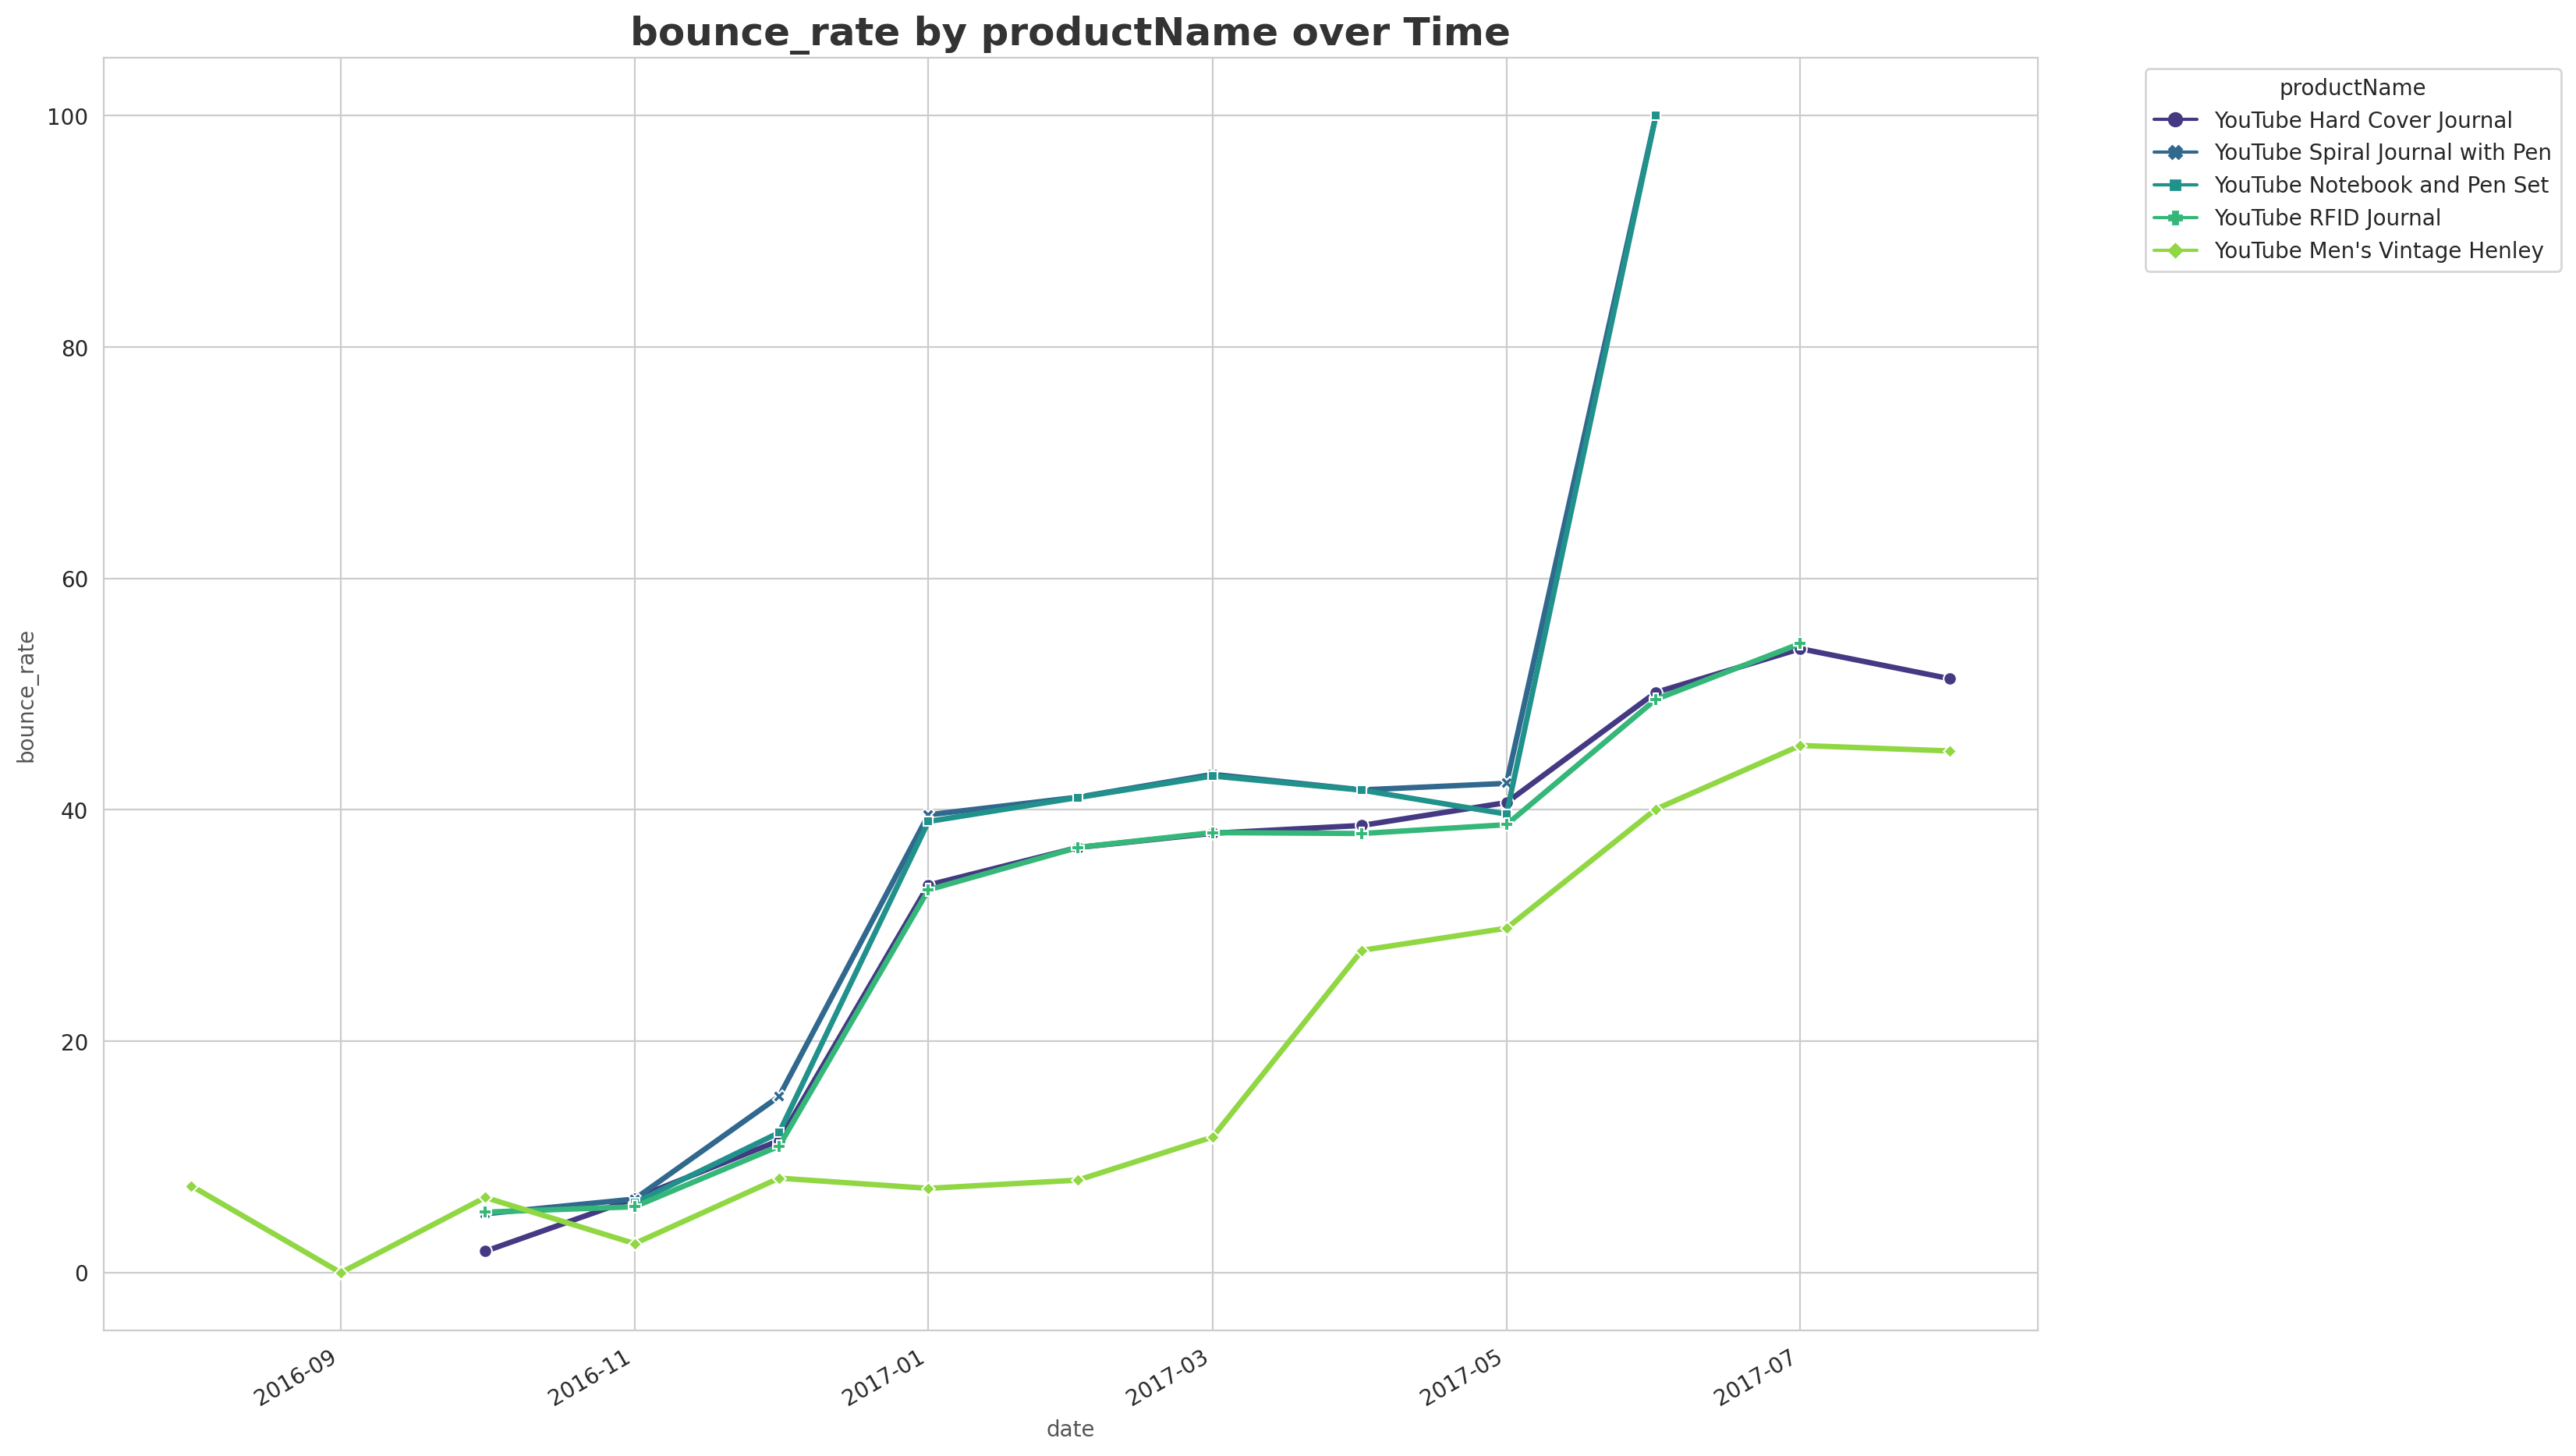

In [58]:
hier_analysis(data.loc[data['productName'].isin(top_bounce) ,:] ,['productName' , 'date'] , agg_bounce , name  , time_column ='date' , figsize=(16,12))

In the top bounce rate products , youtube special journal with pen , and 

<Figure size 1200x500 with 0 Axes>

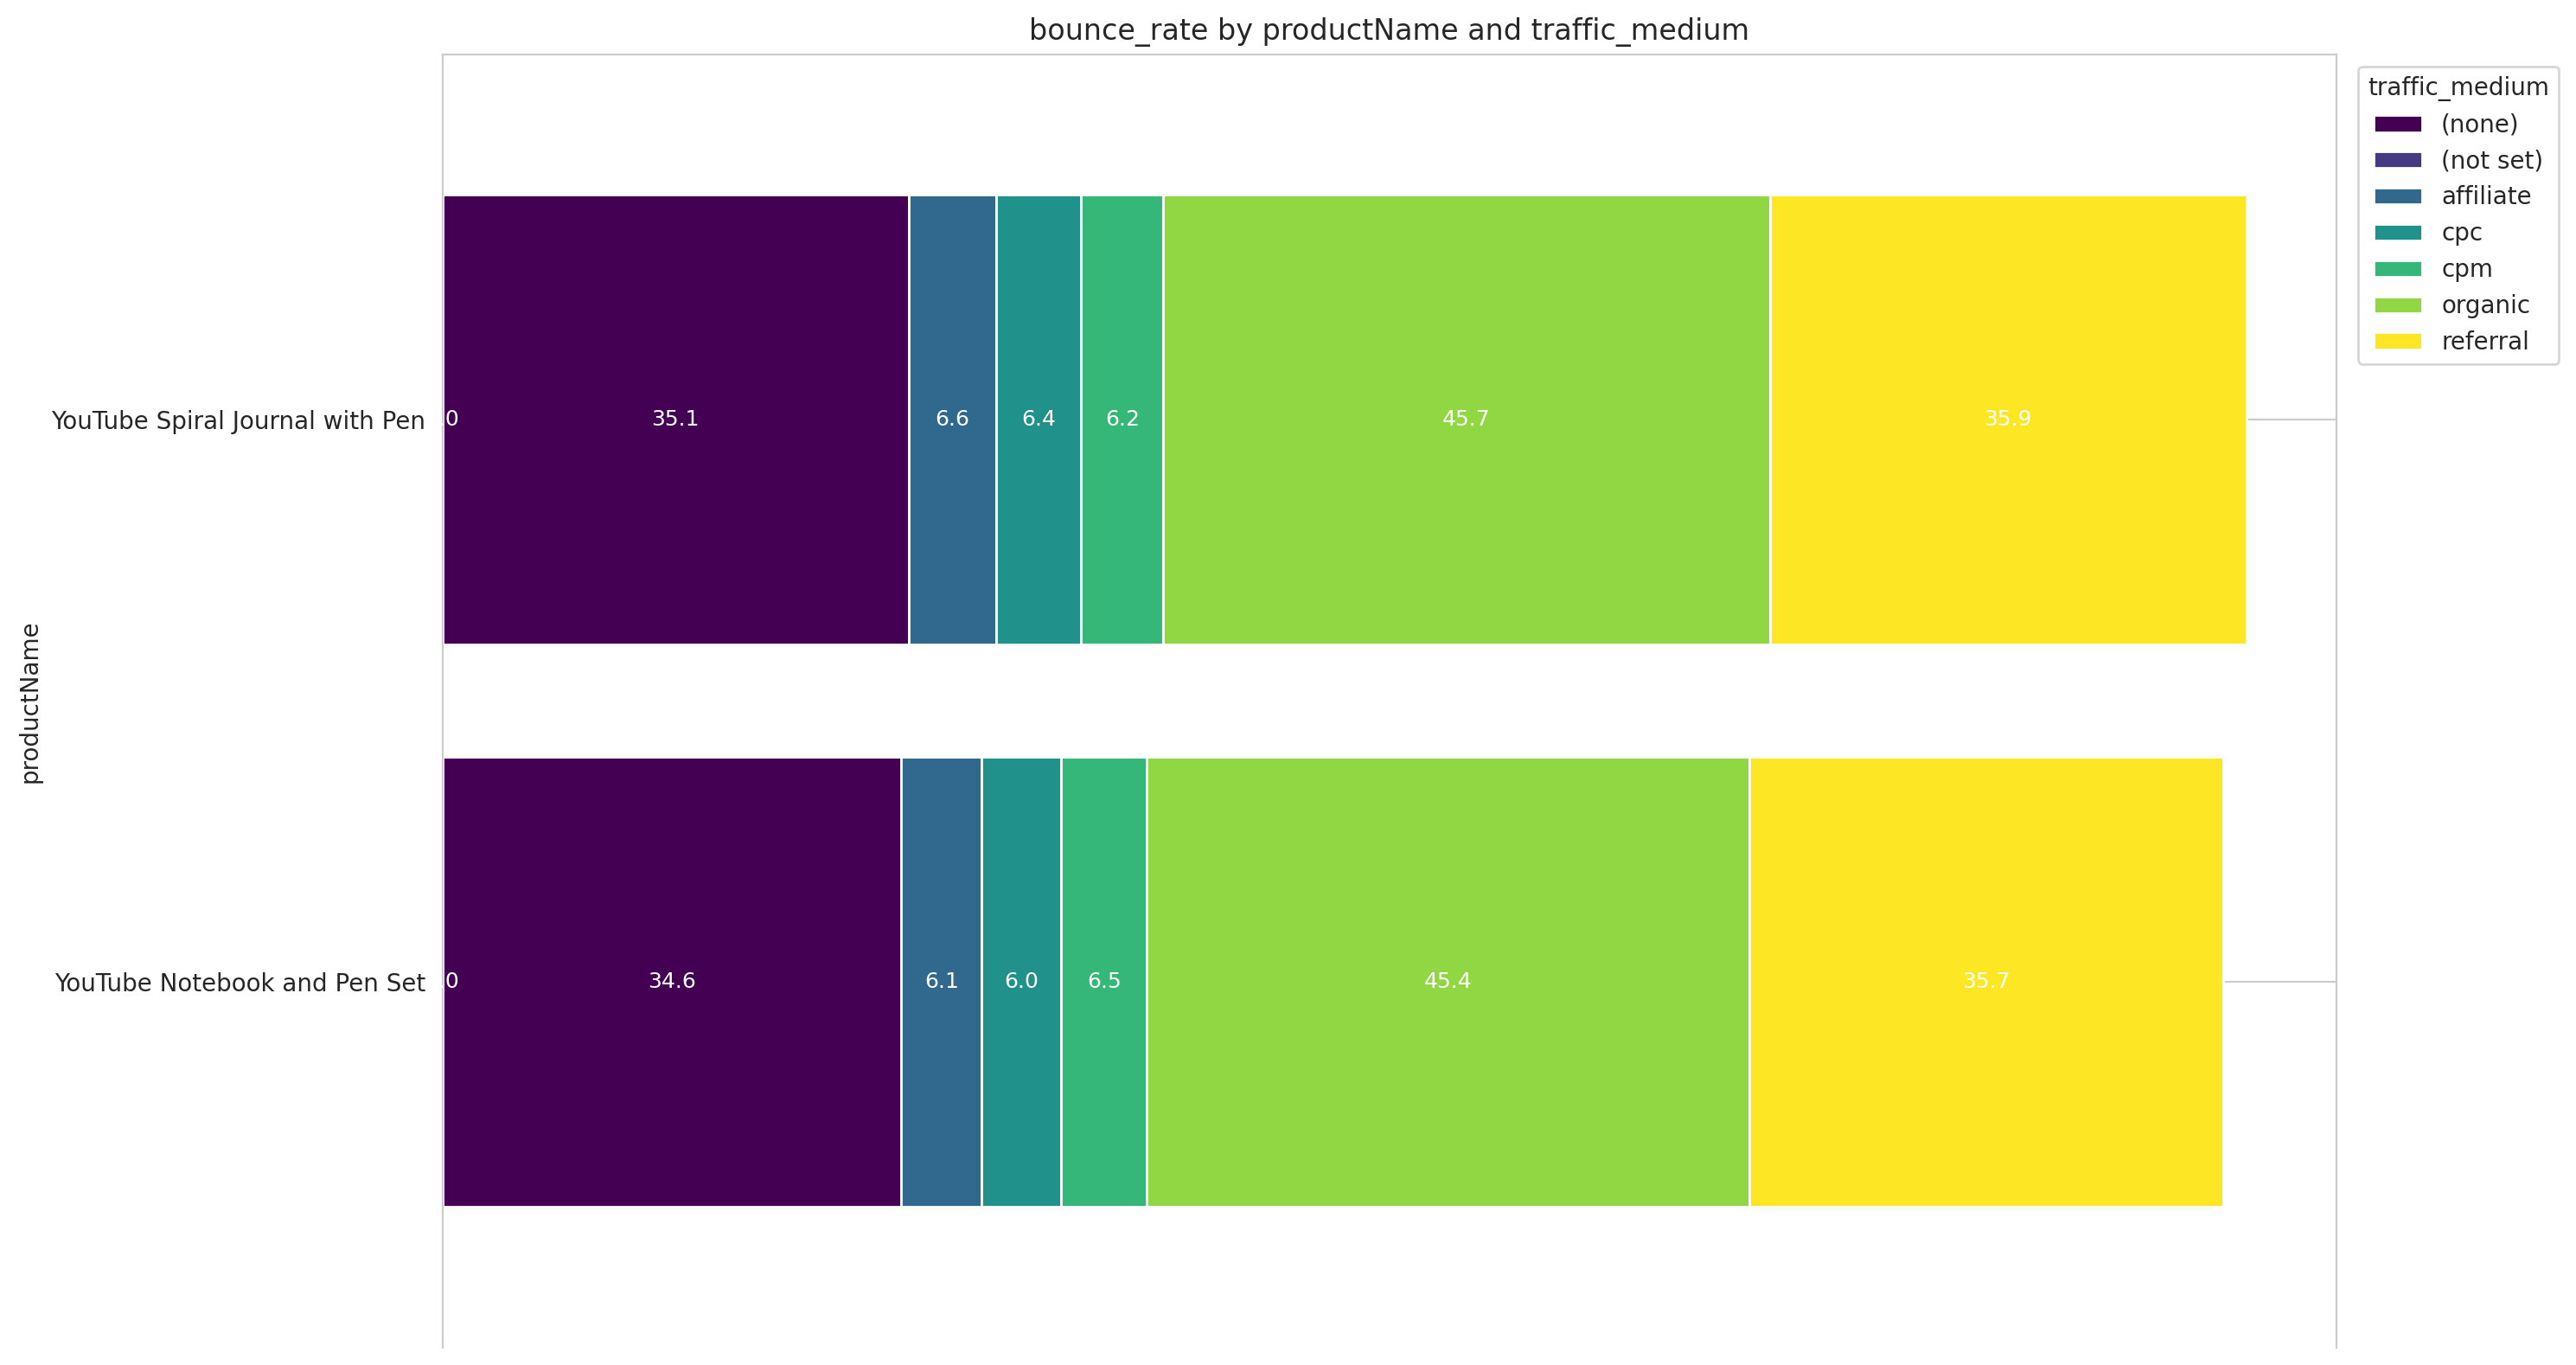

<Figure size 1500x800 with 0 Axes>

In [59]:
hier_analysis(data.loc[data['productName'].isin(top_bounce[2:4]) ,:] , [  'productName' , 
                                                                            'traffic_medium'] , agg_bounce , name )

We notice inside them Bounce rate is the highest around 45% from traffic rate organic

**Executive summary of about bounce rate :**

1- Traffic medium affiliate or CPM give the least bounce Rate , unlike direct and non set.

2 - Desktop users Give less bounce rate.

3- REturning users have least bounce rate.

4 - Despite 3 among new affiliate and CPM users , new users have the least bounce rate close to 0



5 - Africa has largsest bounce rate , but among CPM users Europeans have the largest 38%

## E-commerce Performance Insights

### Conversion Rate

Conversion rate in web analytics is the process of tracking, measuring, and analyzing the percentage of website visitors who complete a desired action, such as a purchase or form submission, out of the total number of visitors

In [60]:
conversion_agg = lambda x : x['converting_sessions'].sum()*100 / x['total_sessions'].sum()
name='conversion_rate'

In [61]:
product_metrics[['bounce_rate', 'conversion_rate']].corr()

,bounce_rate,conversion_rate
bounce_rate,1.000000,-0.706588
conversion_rate,-0.706588,1.000000


So we can conclude that patterns regarding conversion rate would be right the reverse to bounce rate , as they are by concept reverse relationship , high bounce rate implies less rach to conversion pages funnel

**By traffic medium**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

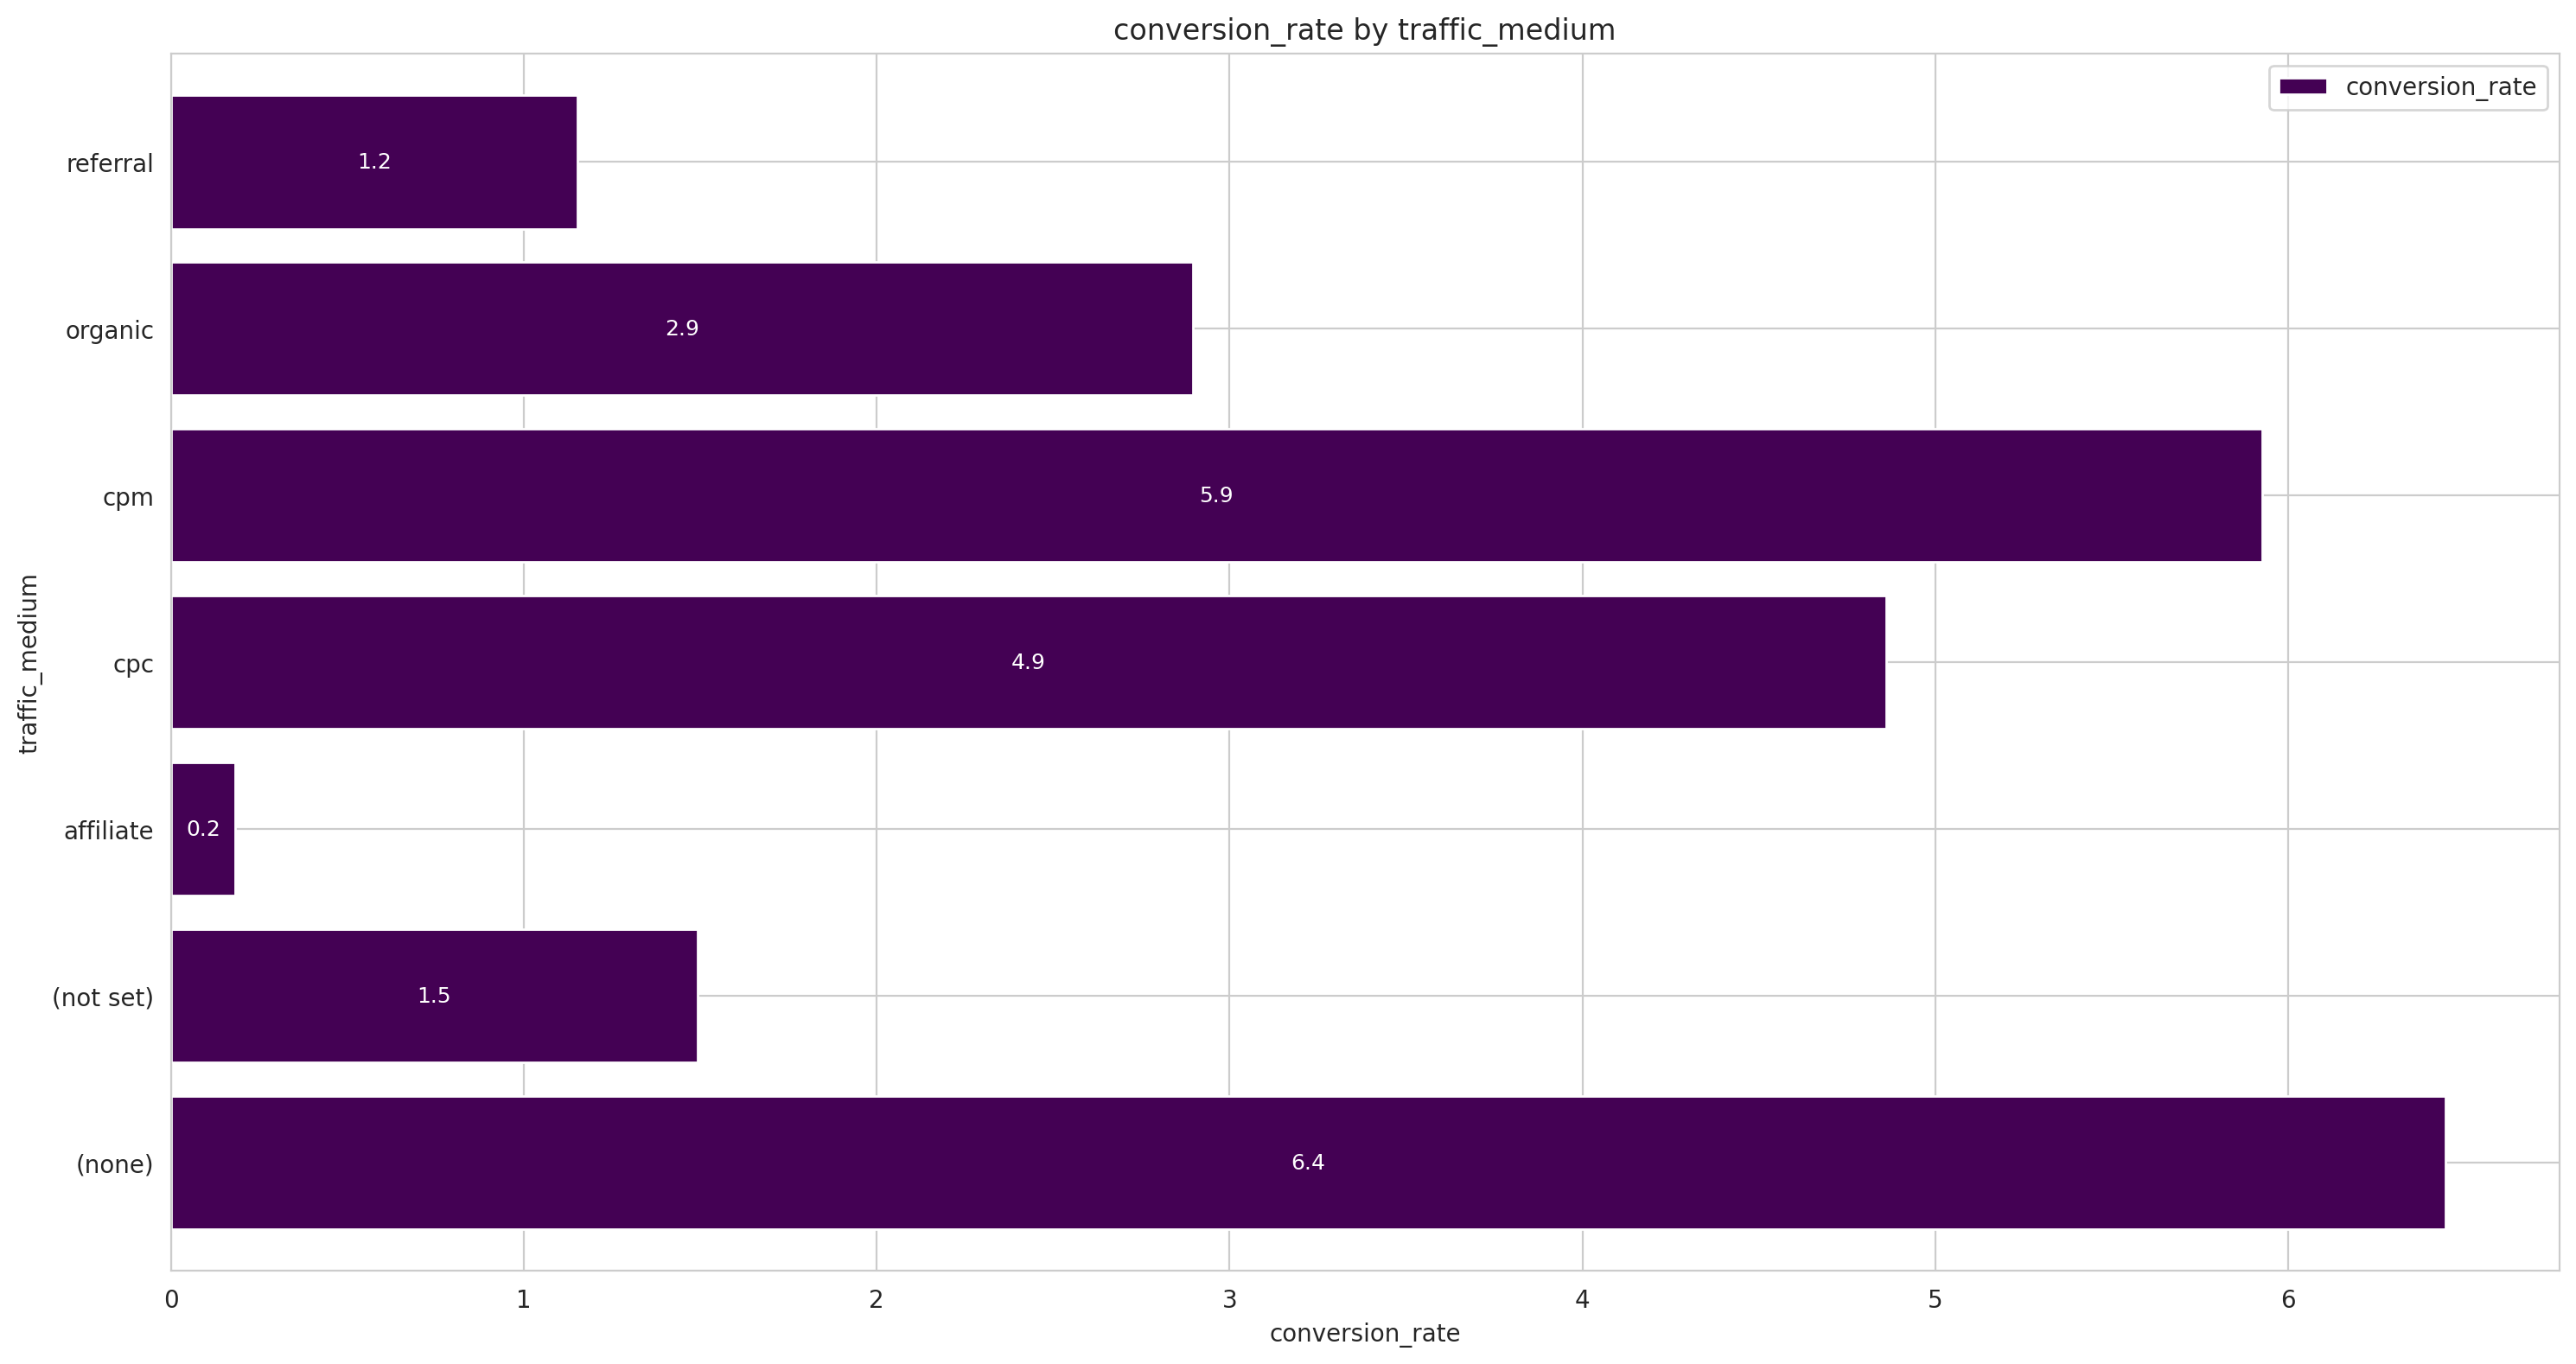

<Figure size 1500x800 with 0 Axes>

In [62]:
hier_analysis(data , [ 'traffic_medium' ] , conversion_agg , name  )

conversion rate as highest comes comes from none (naturally when a user directly goes to products page) it means he is more serious to buy.

unlike affiliate marketing despite it gets less bounce rate , but new users despite having almost zero bounce rate but they may be less serious to buy , they just look and in most cases don't go through purchase process.

**By user type**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

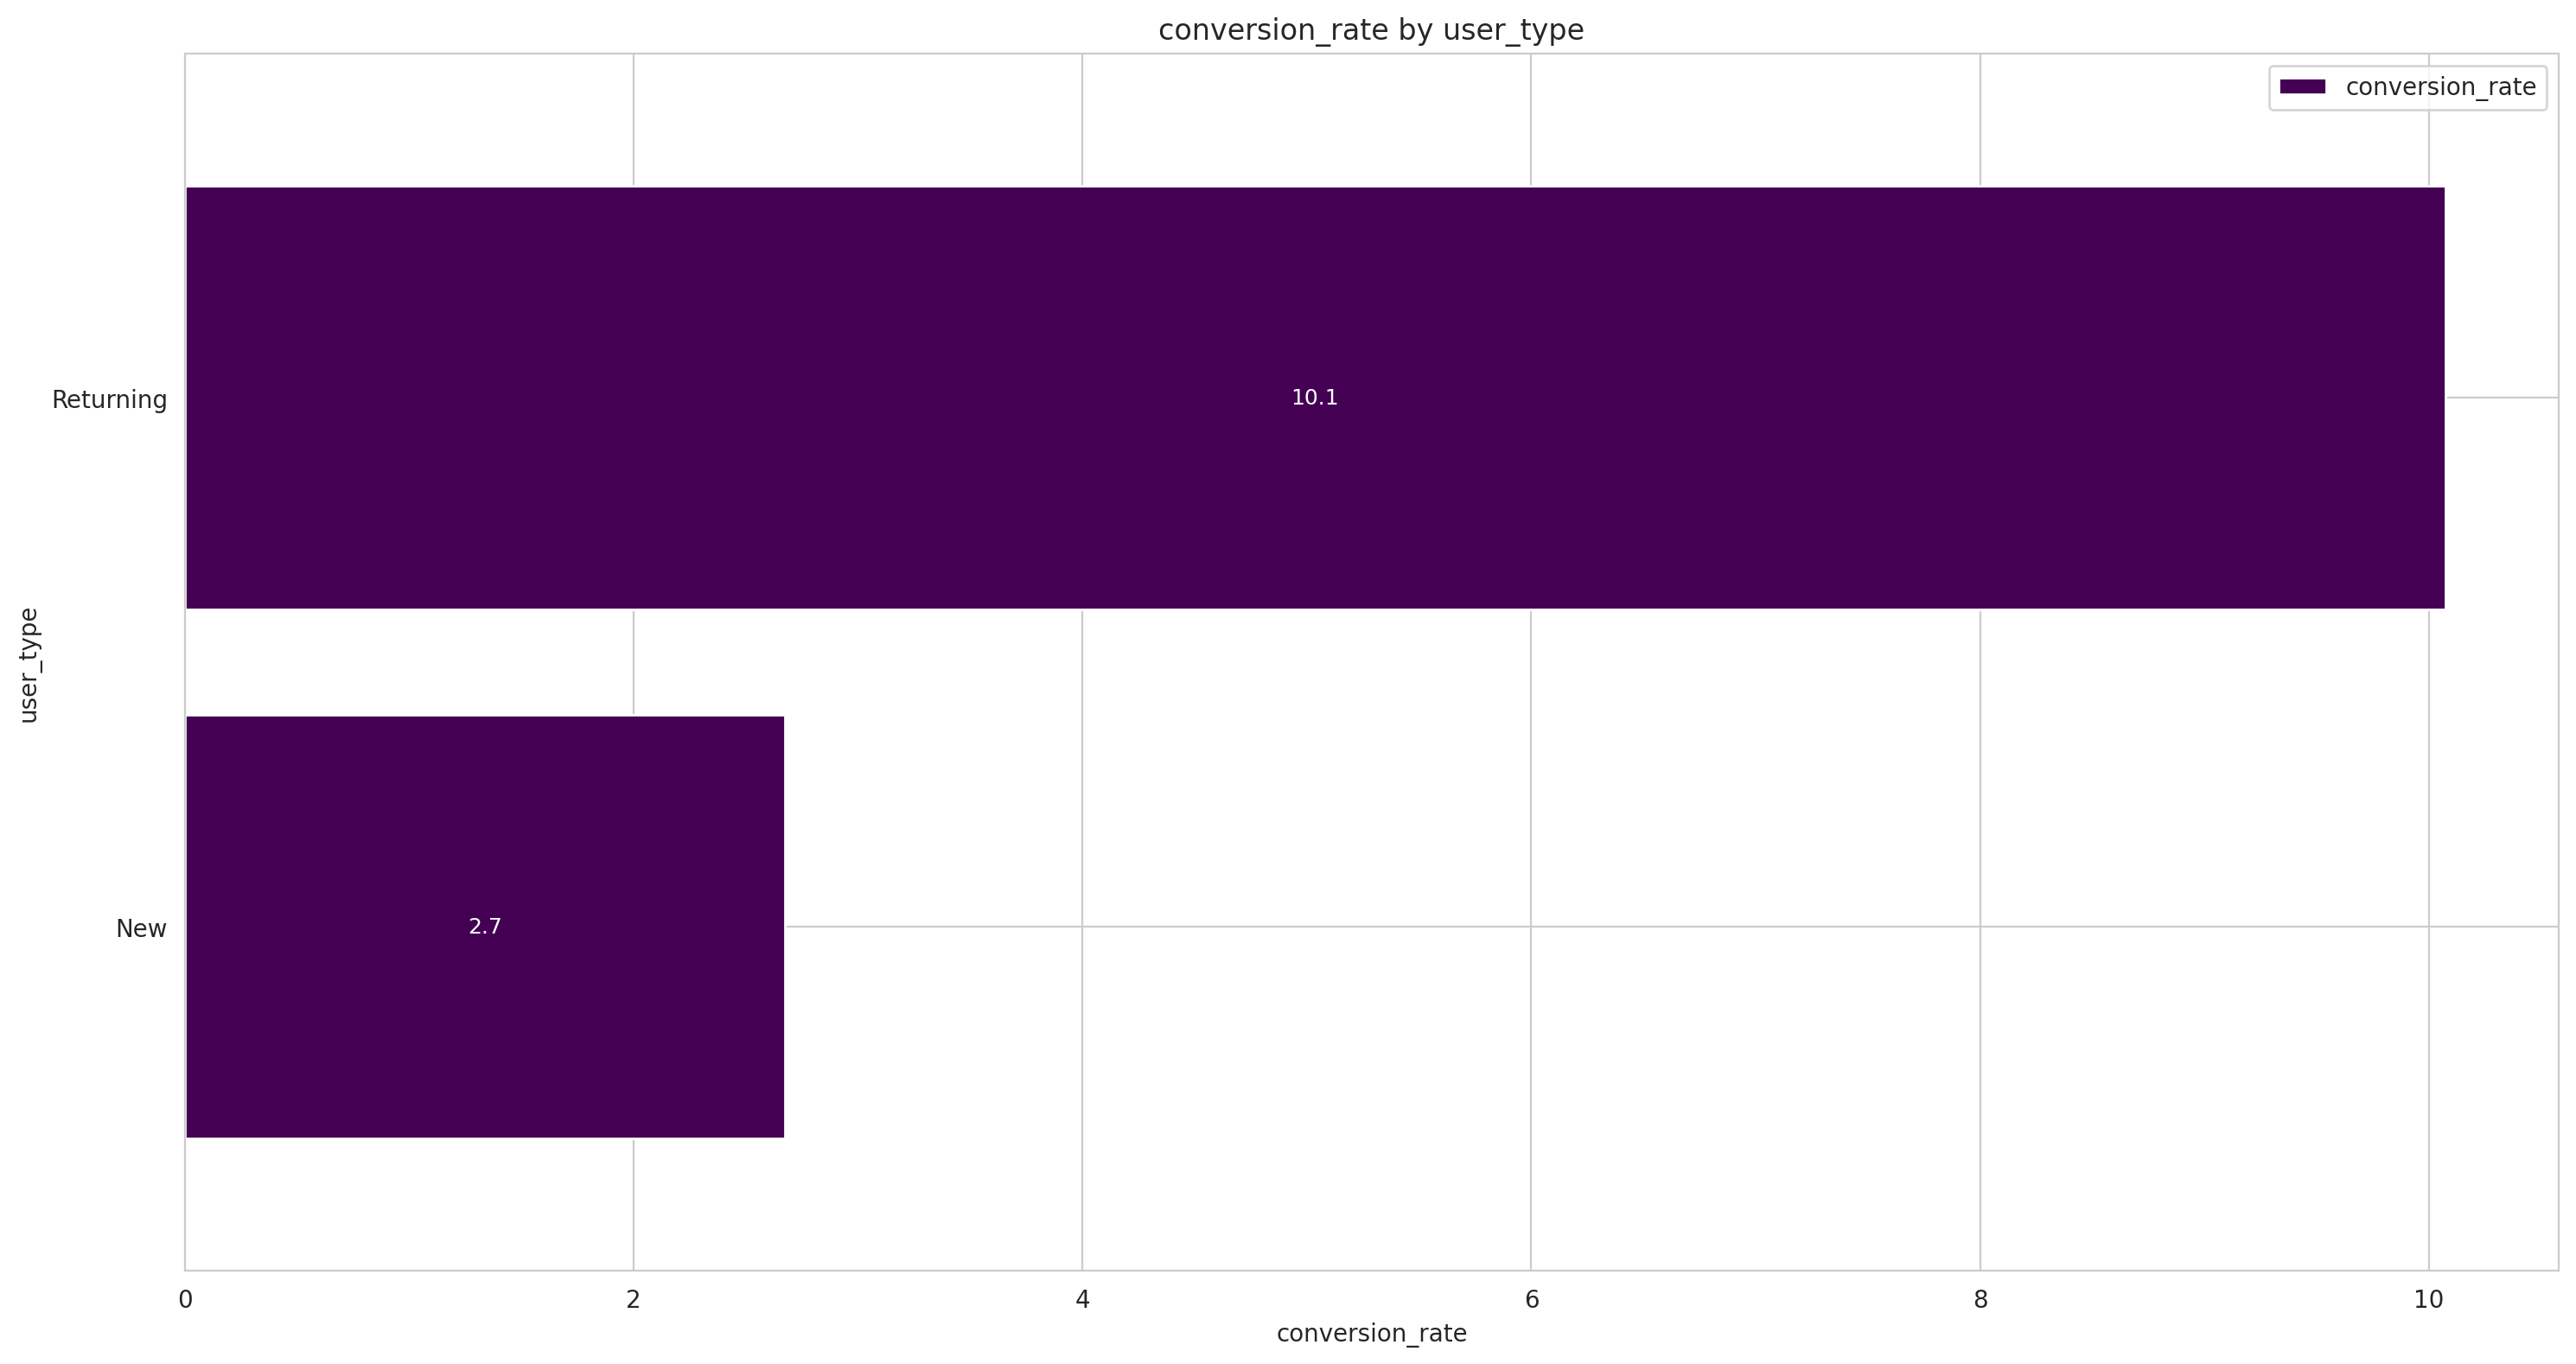

<Figure size 1500x800 with 0 Axes>

In [63]:
hier_analysis(data , [ 'user_type' ] , conversion_agg , name  )

We see that by far returning users have the more conversion rate , despite having lesser bounce rate but not that far , simplt because old users maintain more loyalty , unlike new users who may just want to brouse or browse many product to choose one , so they may not all bounce , but lesser percentage of them really purchase.

**By time**

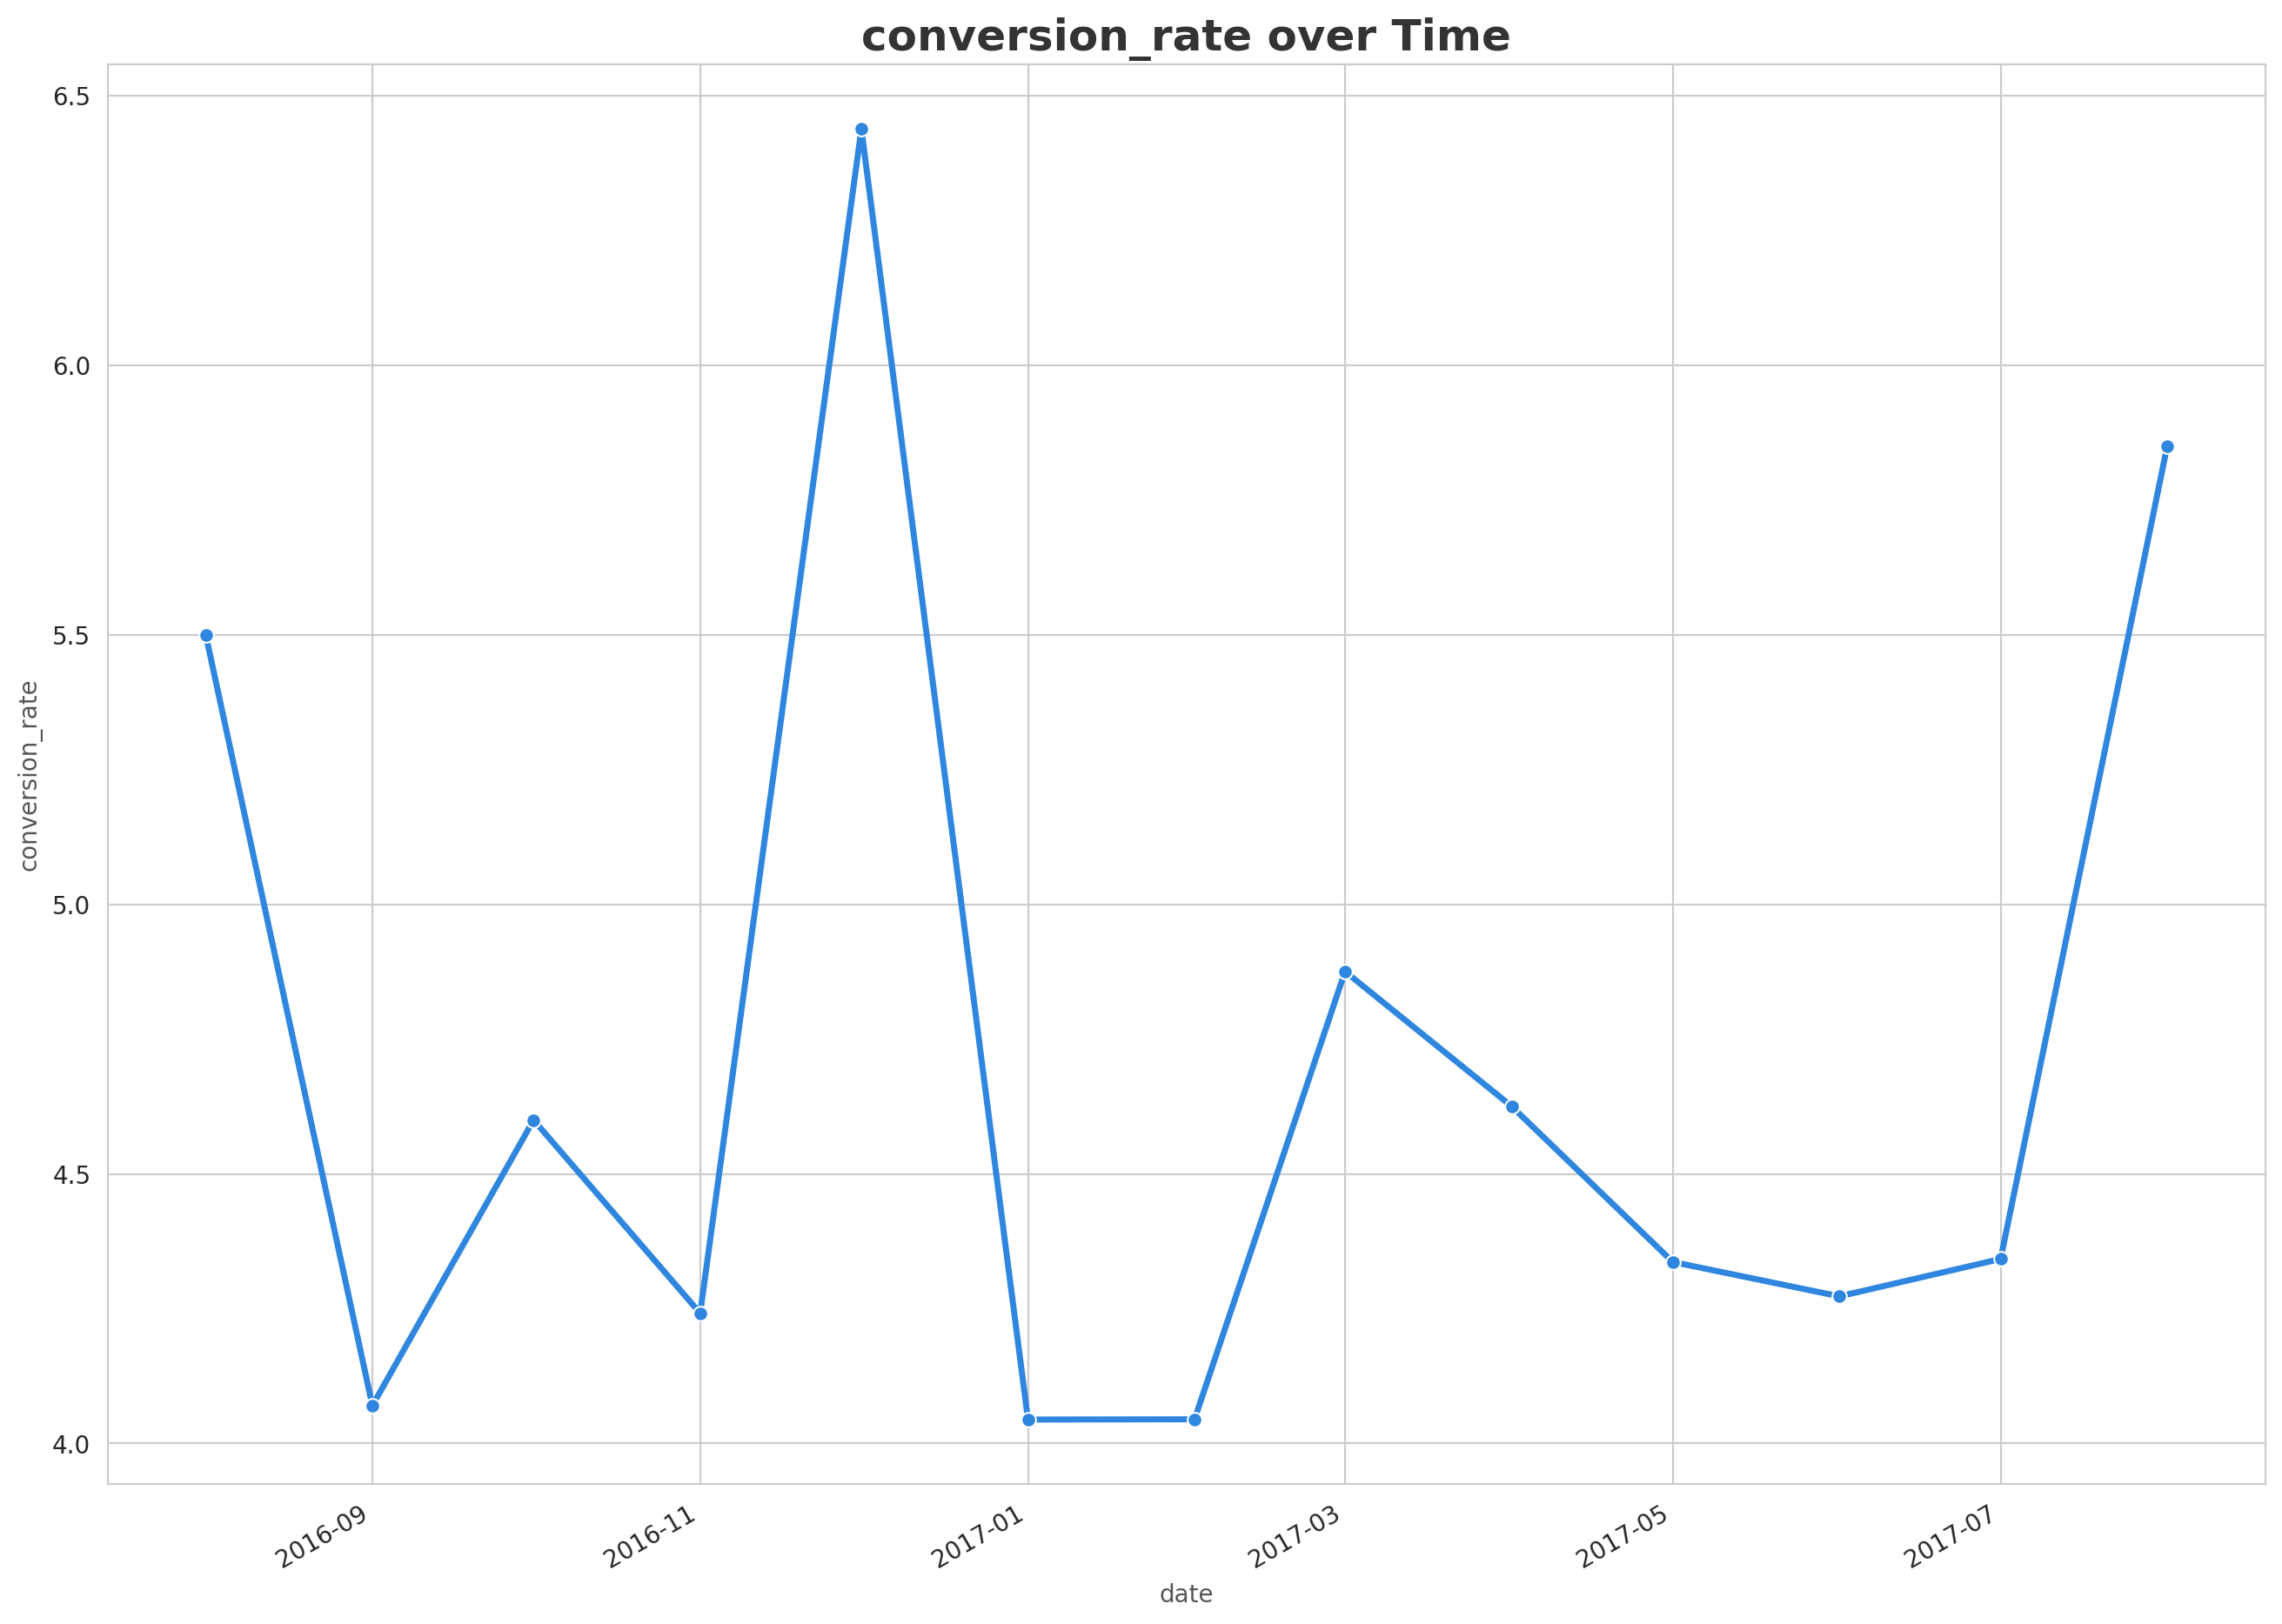

In [64]:
hier_analysis(data , ['date' ] , conversion_agg , name , figsize=(16,12) )

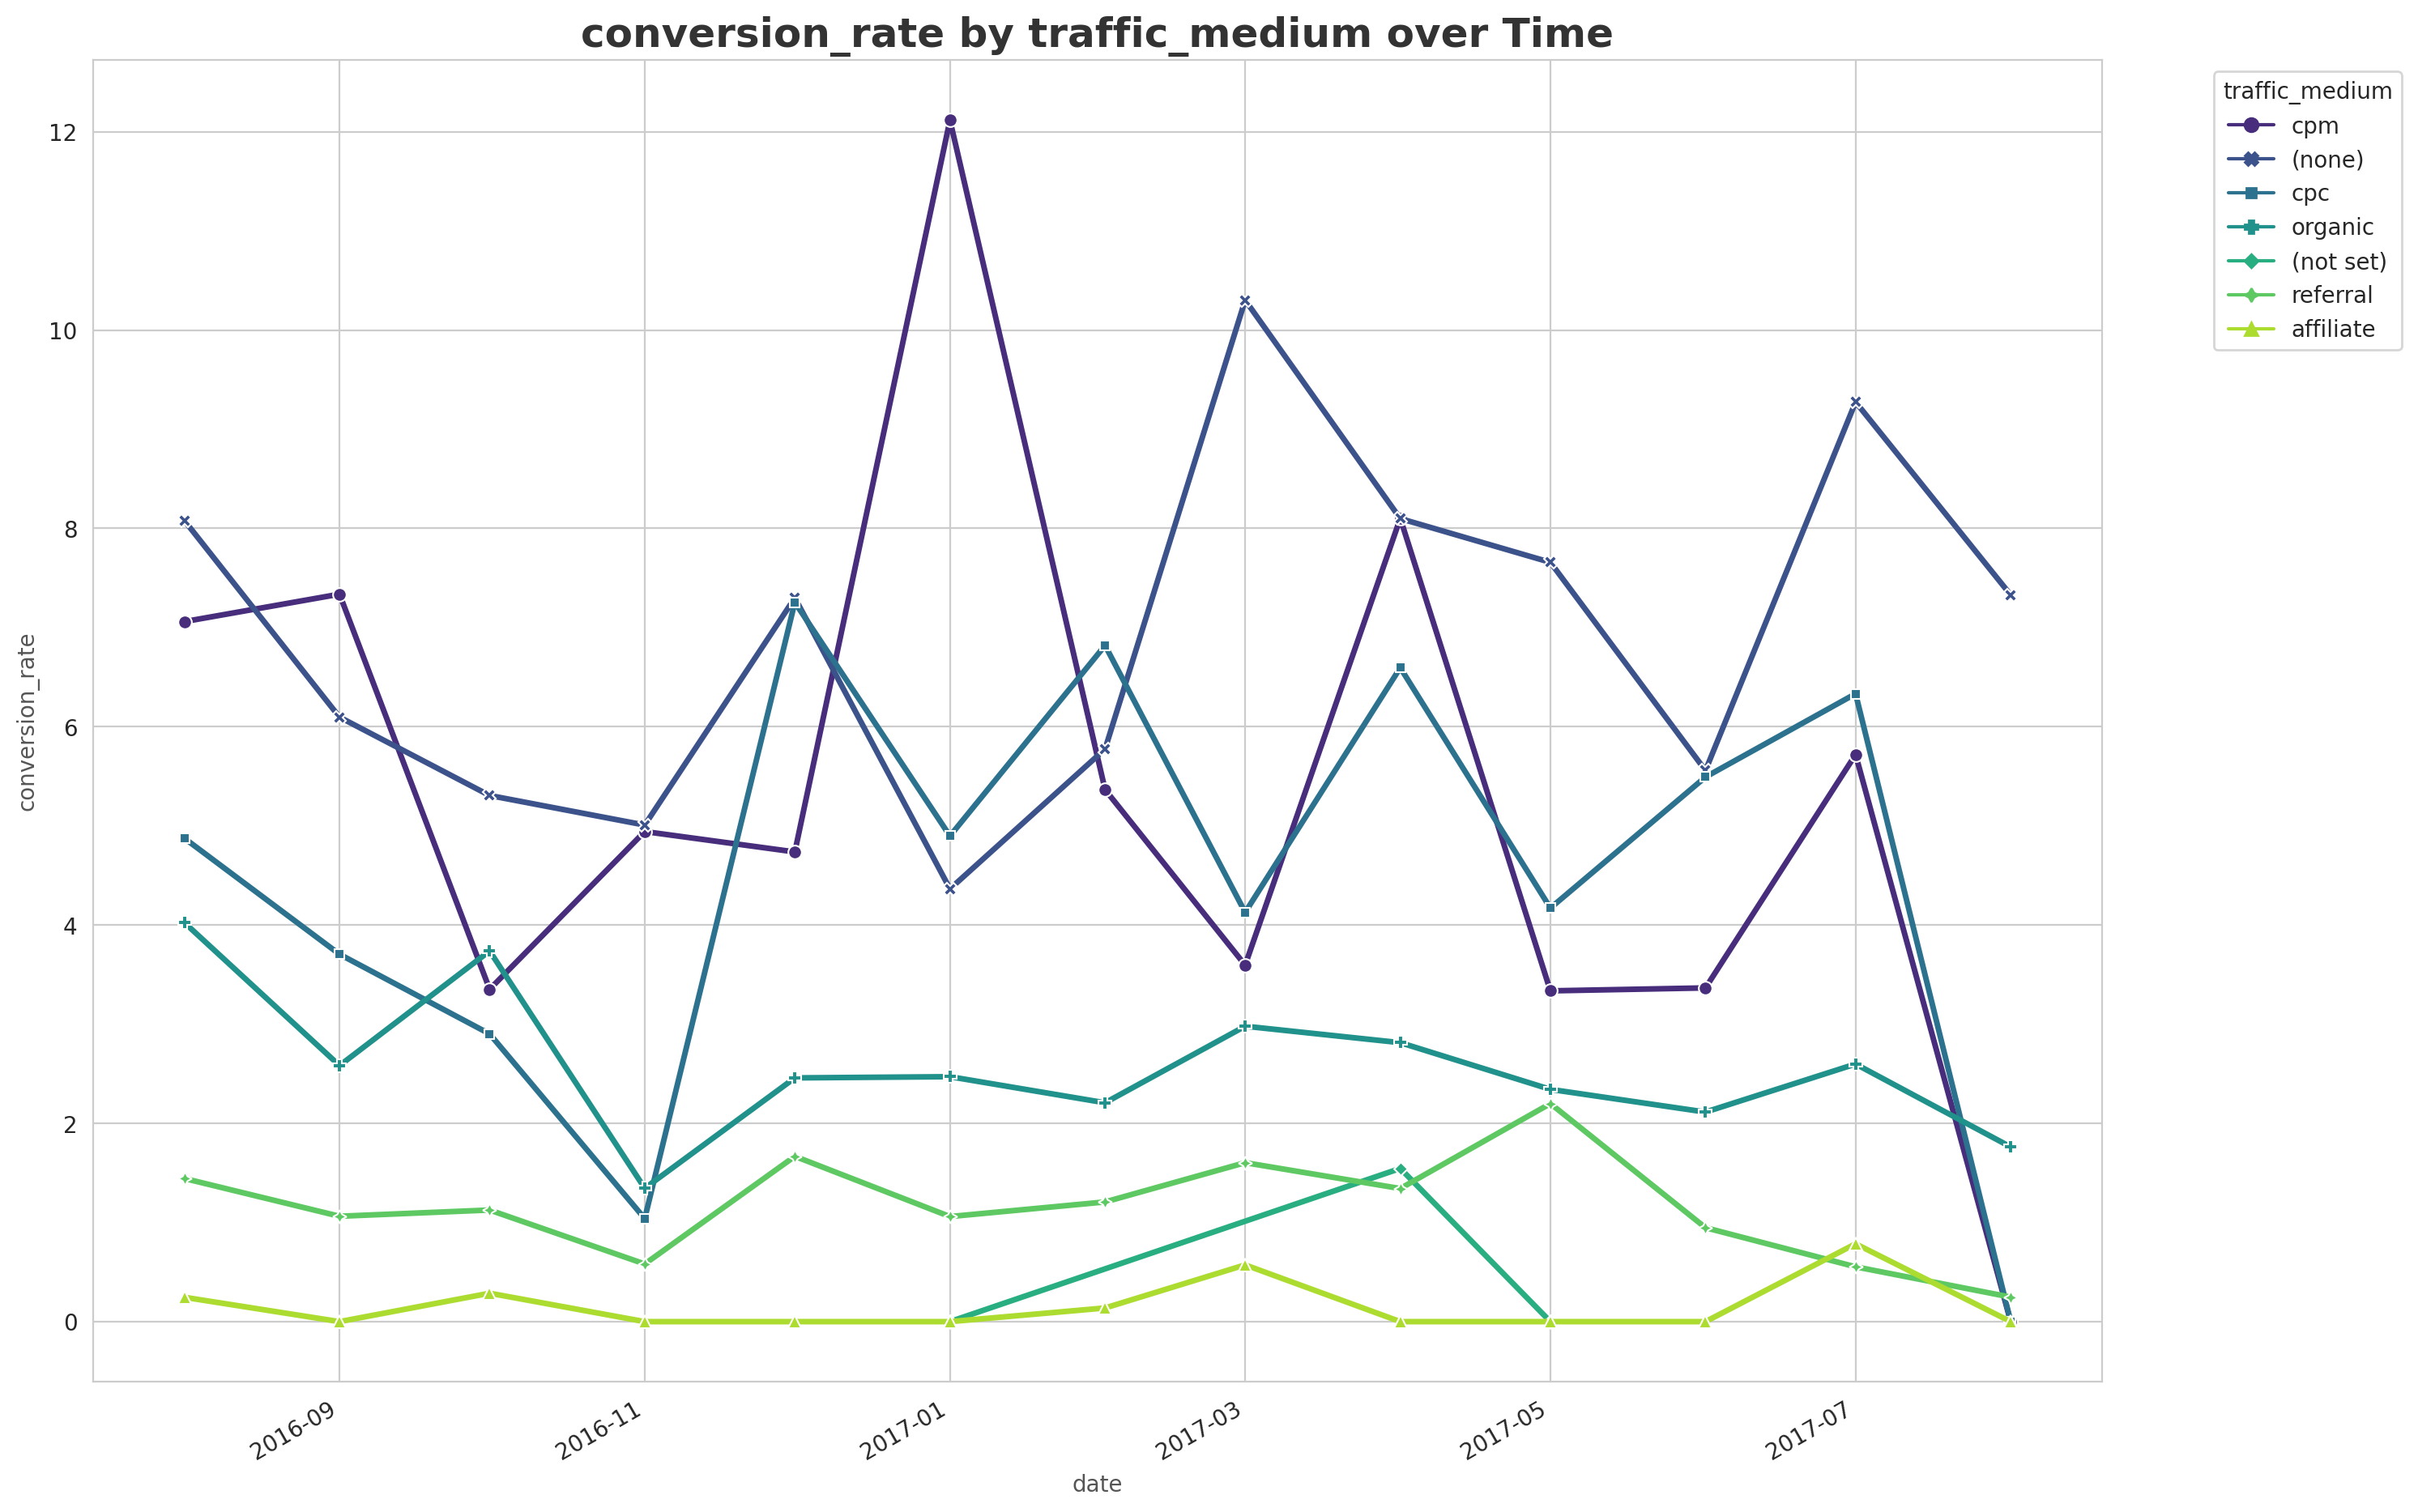

In [65]:
hier_analysis(data , [ 'date', 'traffic_medium' ] , conversion_agg , name , figsize=(16,12) )

We find that most part of year users conversion rate gets higher is in summer and holidays season between November and January due to thanks giving and new year.

Despite generally traffic medium none referring to directly heading user have more conversion rate in general , but specifically CPM masters in January. 

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

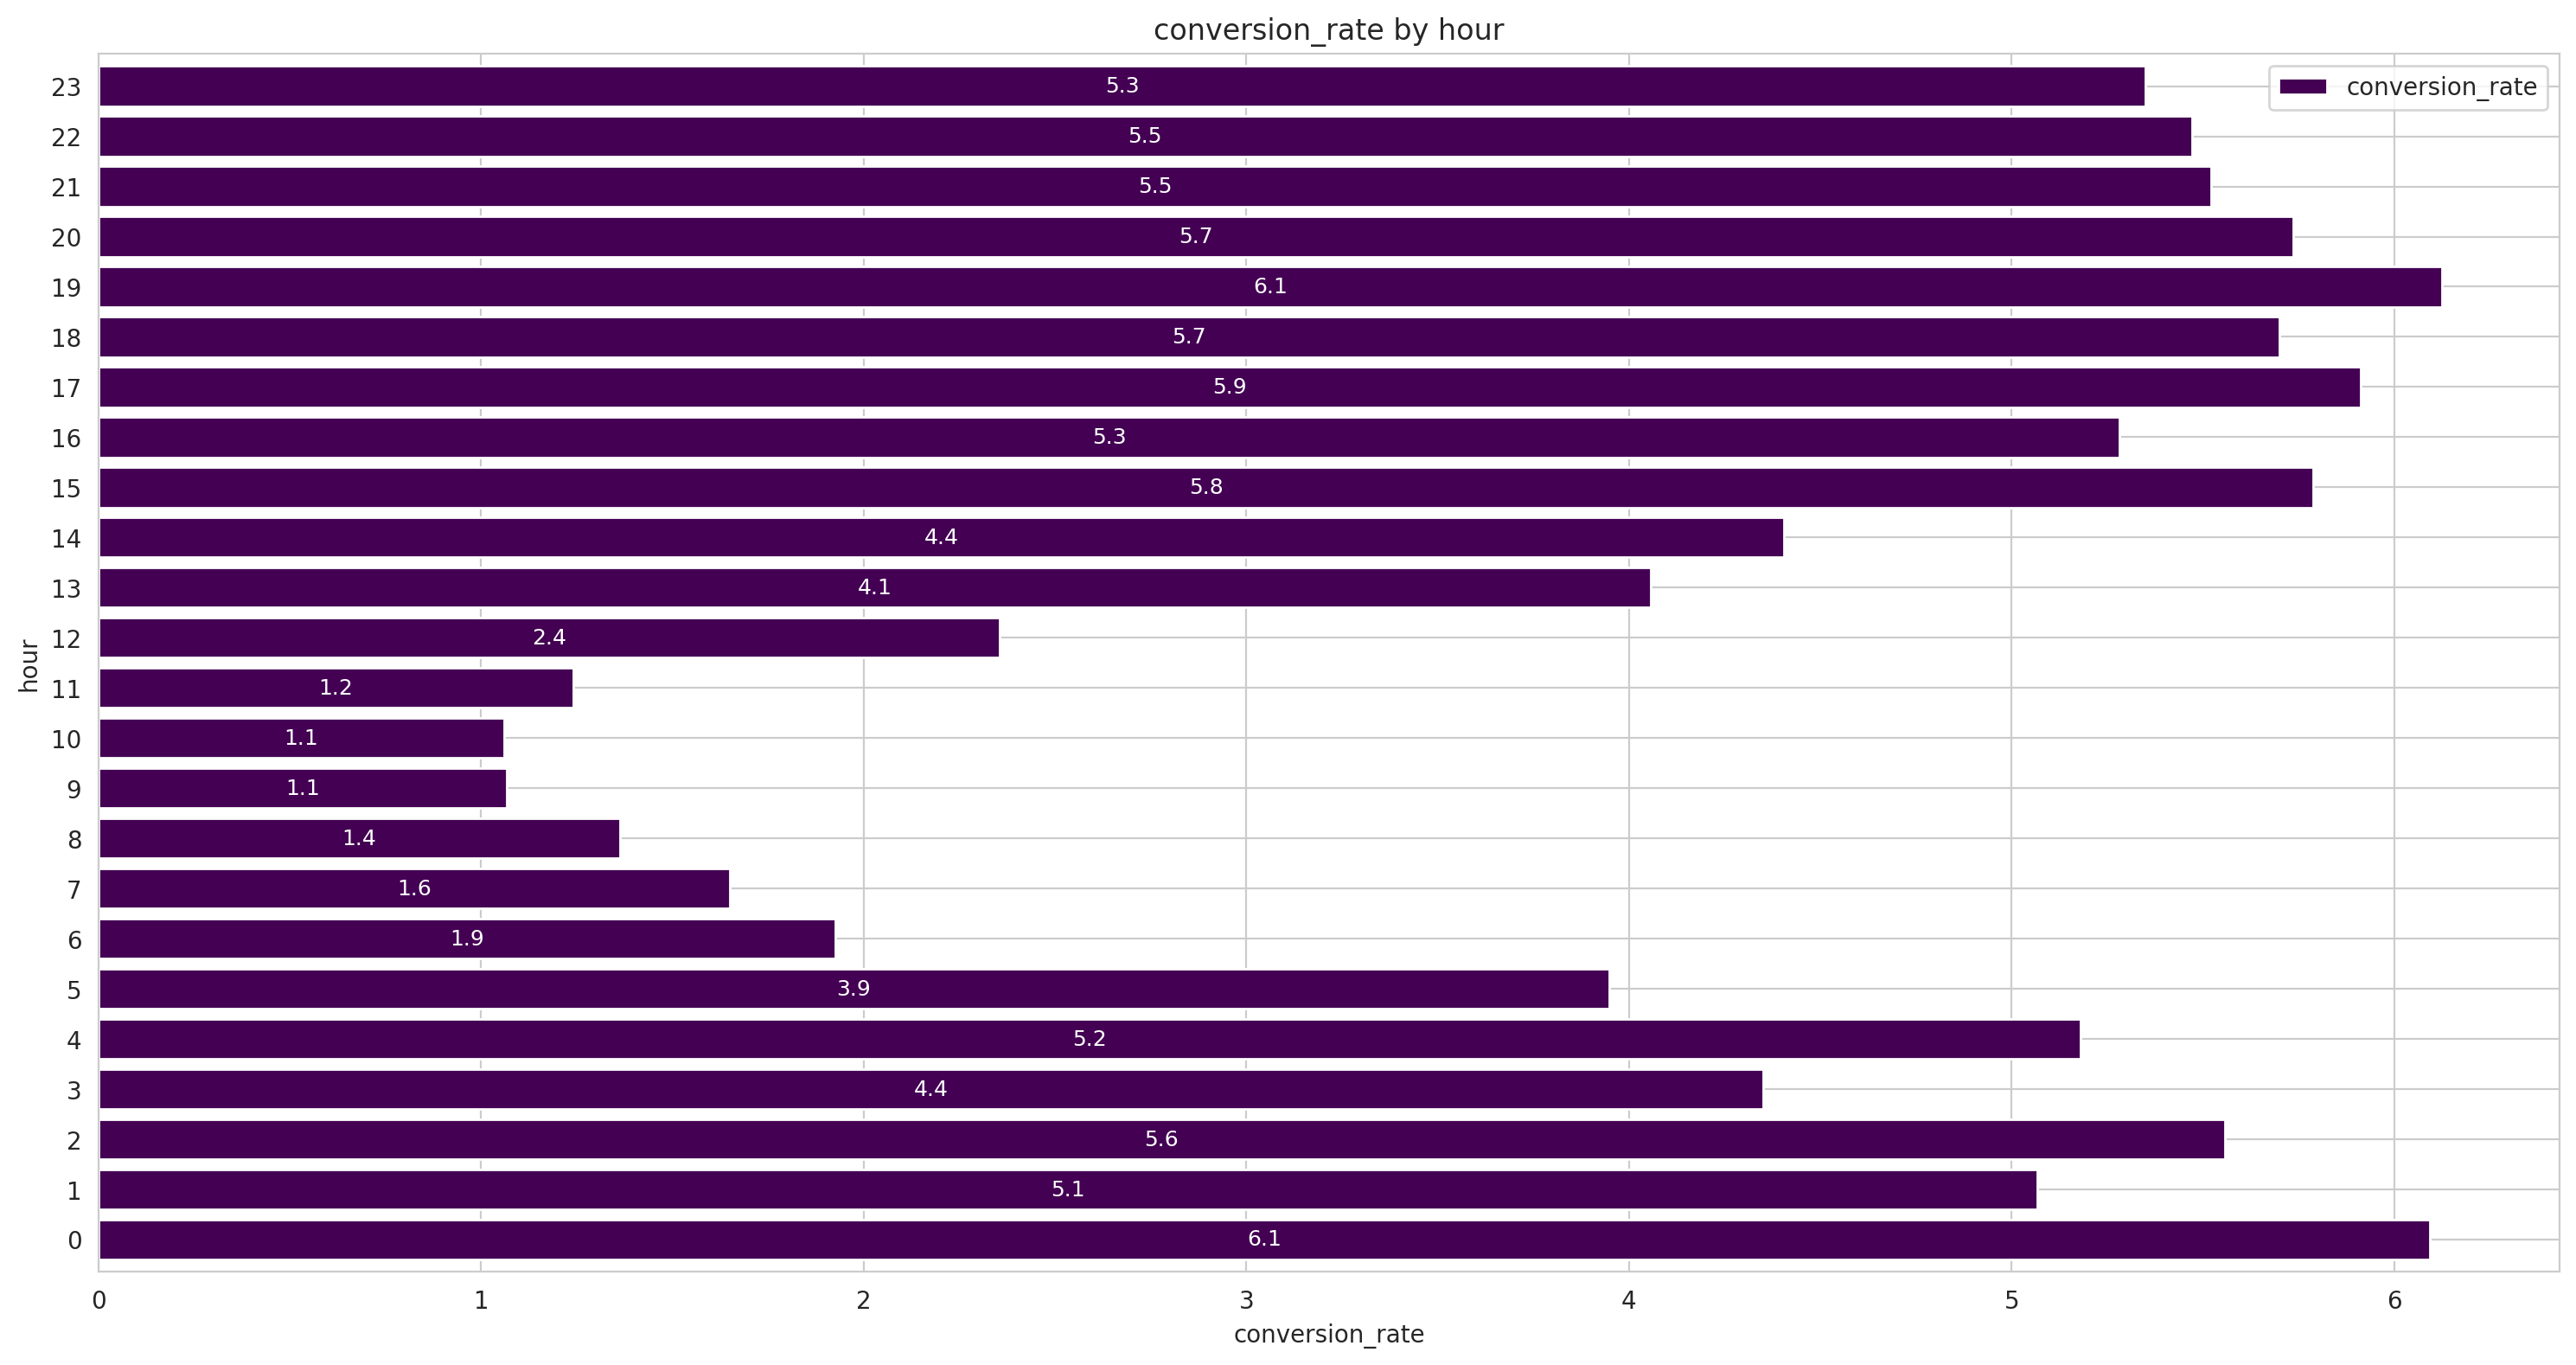

<Figure size 1500x800 with 0 Axes>

In [66]:
hier_analysis(data , [ 'hour' ] , conversion_agg , name  )

From 6:00 AM to 1:00 PM conversion rate drops may be as we mentionned above discussing bounce rate , these are hours of work and way to work.

**By Device category**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

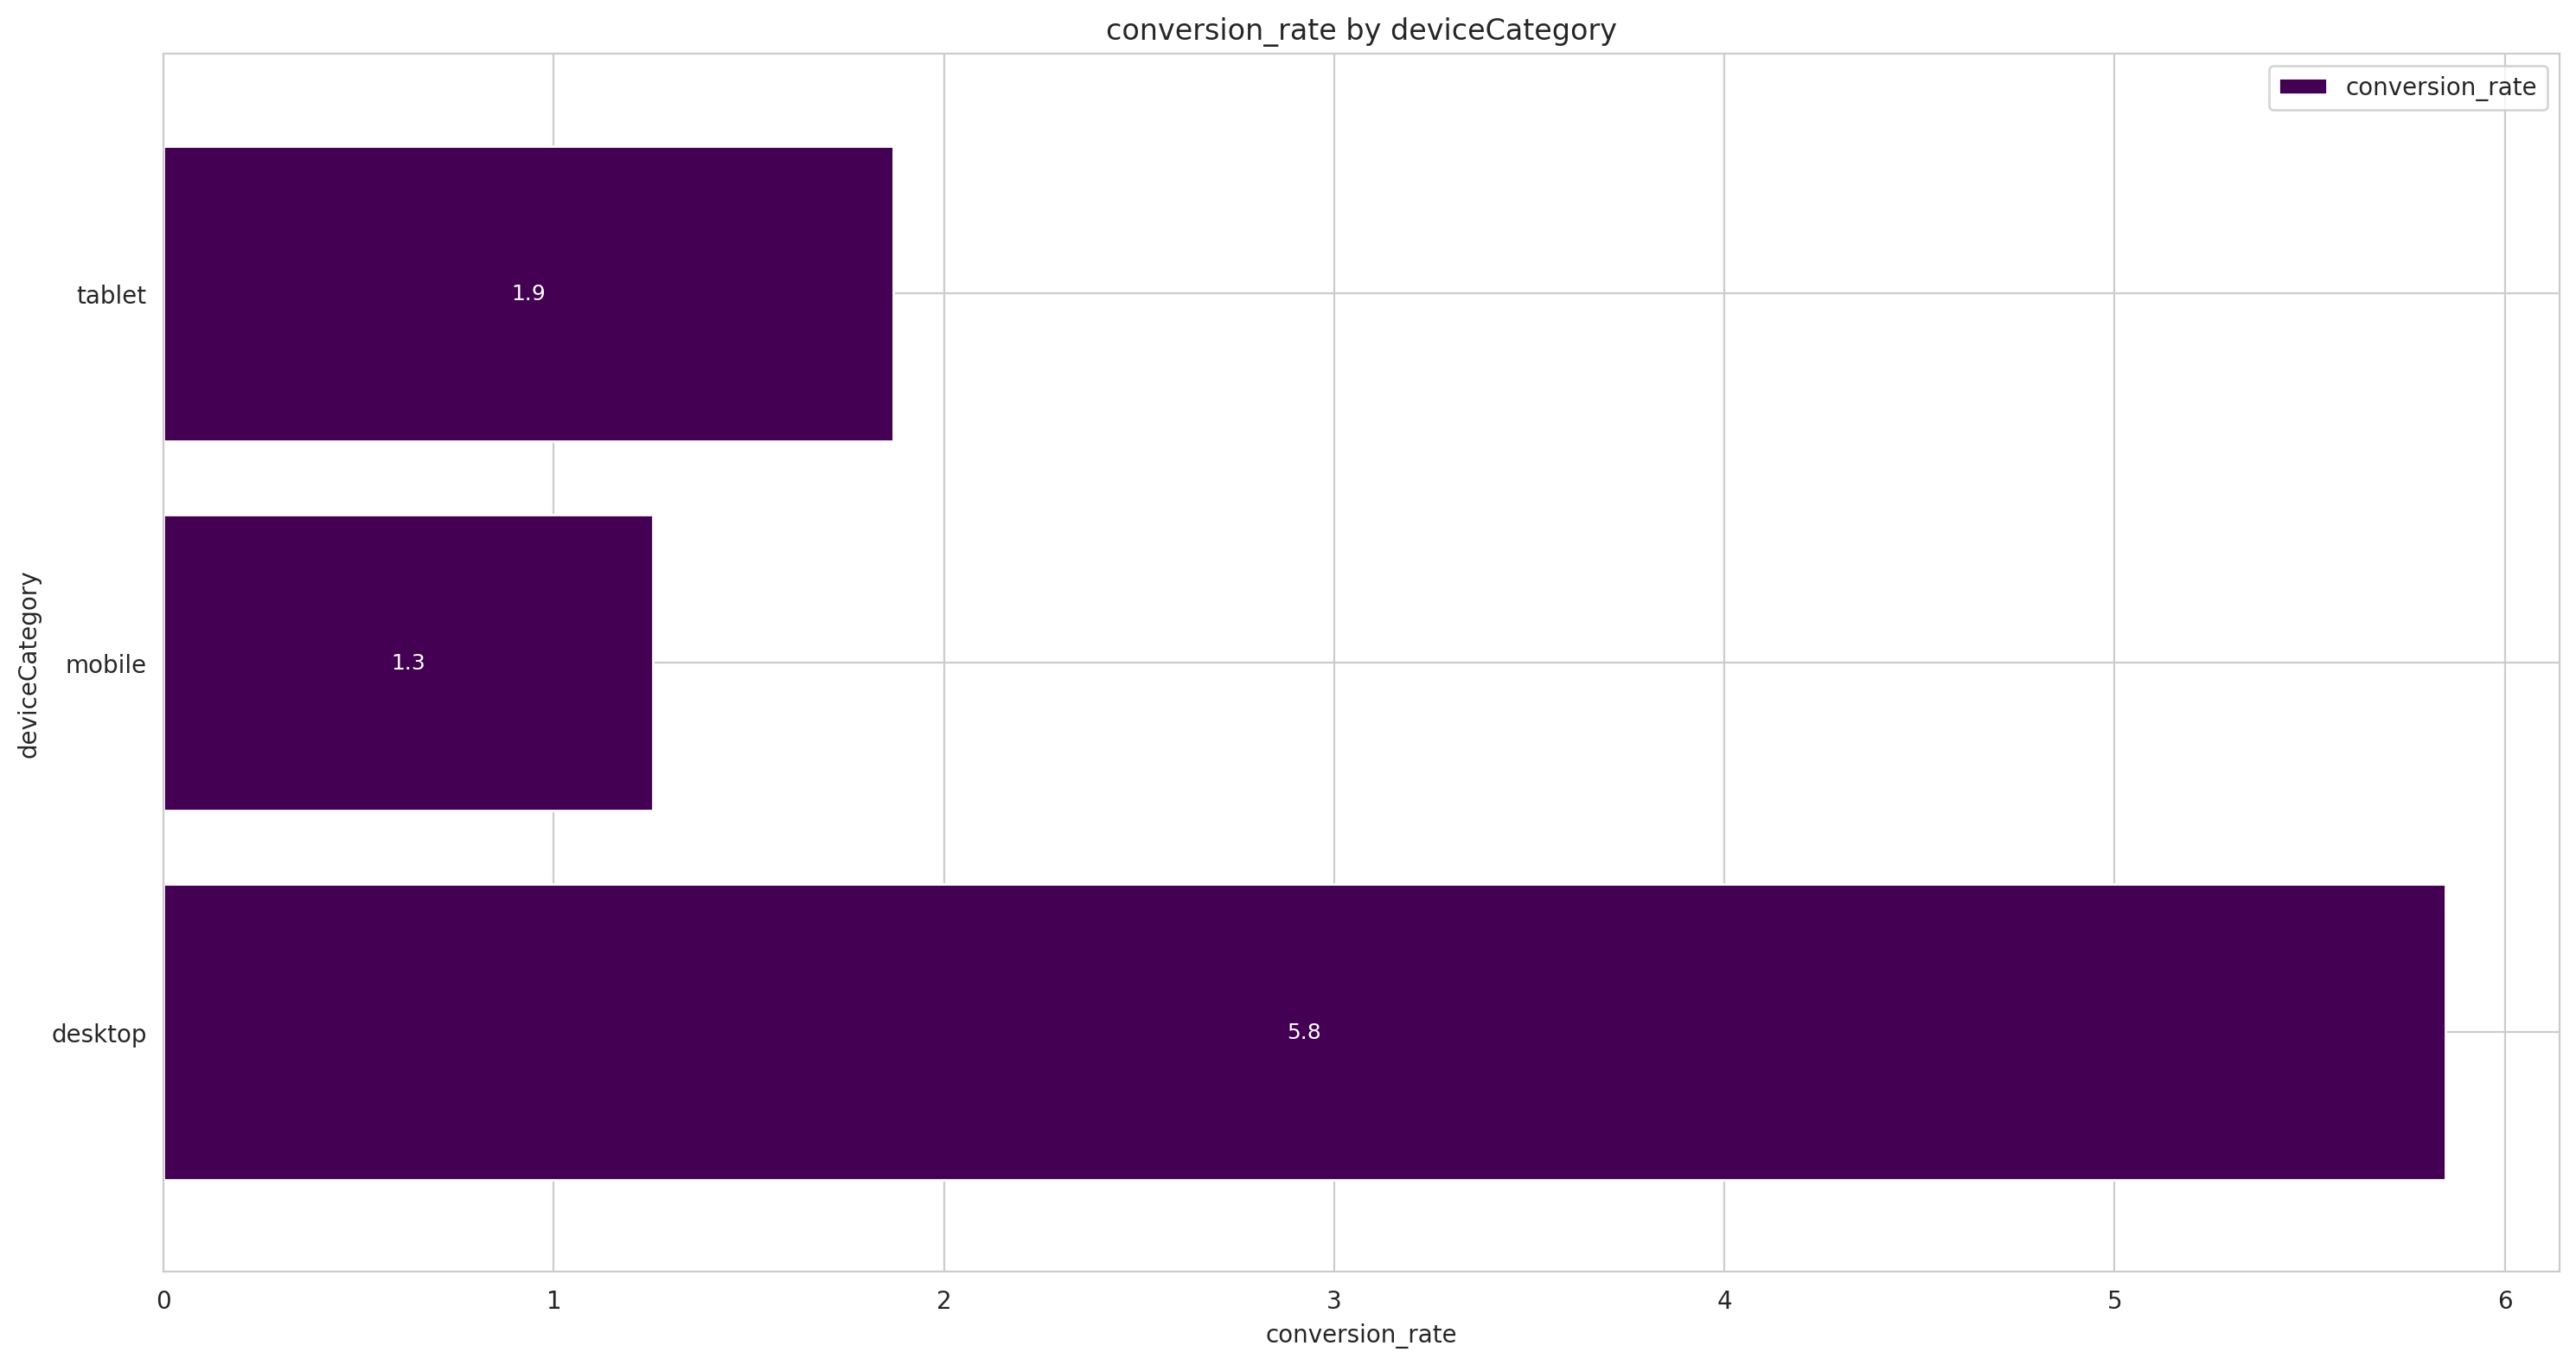

<Figure size 1500x800 with 0 Axes>

In [67]:
hier_analysis(data , [ 'deviceCategory' ] , conversion_agg , name  )

Not weird , linked to bounce rate analysis that most of conversions come by far from desktop users, They are more serious to take financial actions.

**By products**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

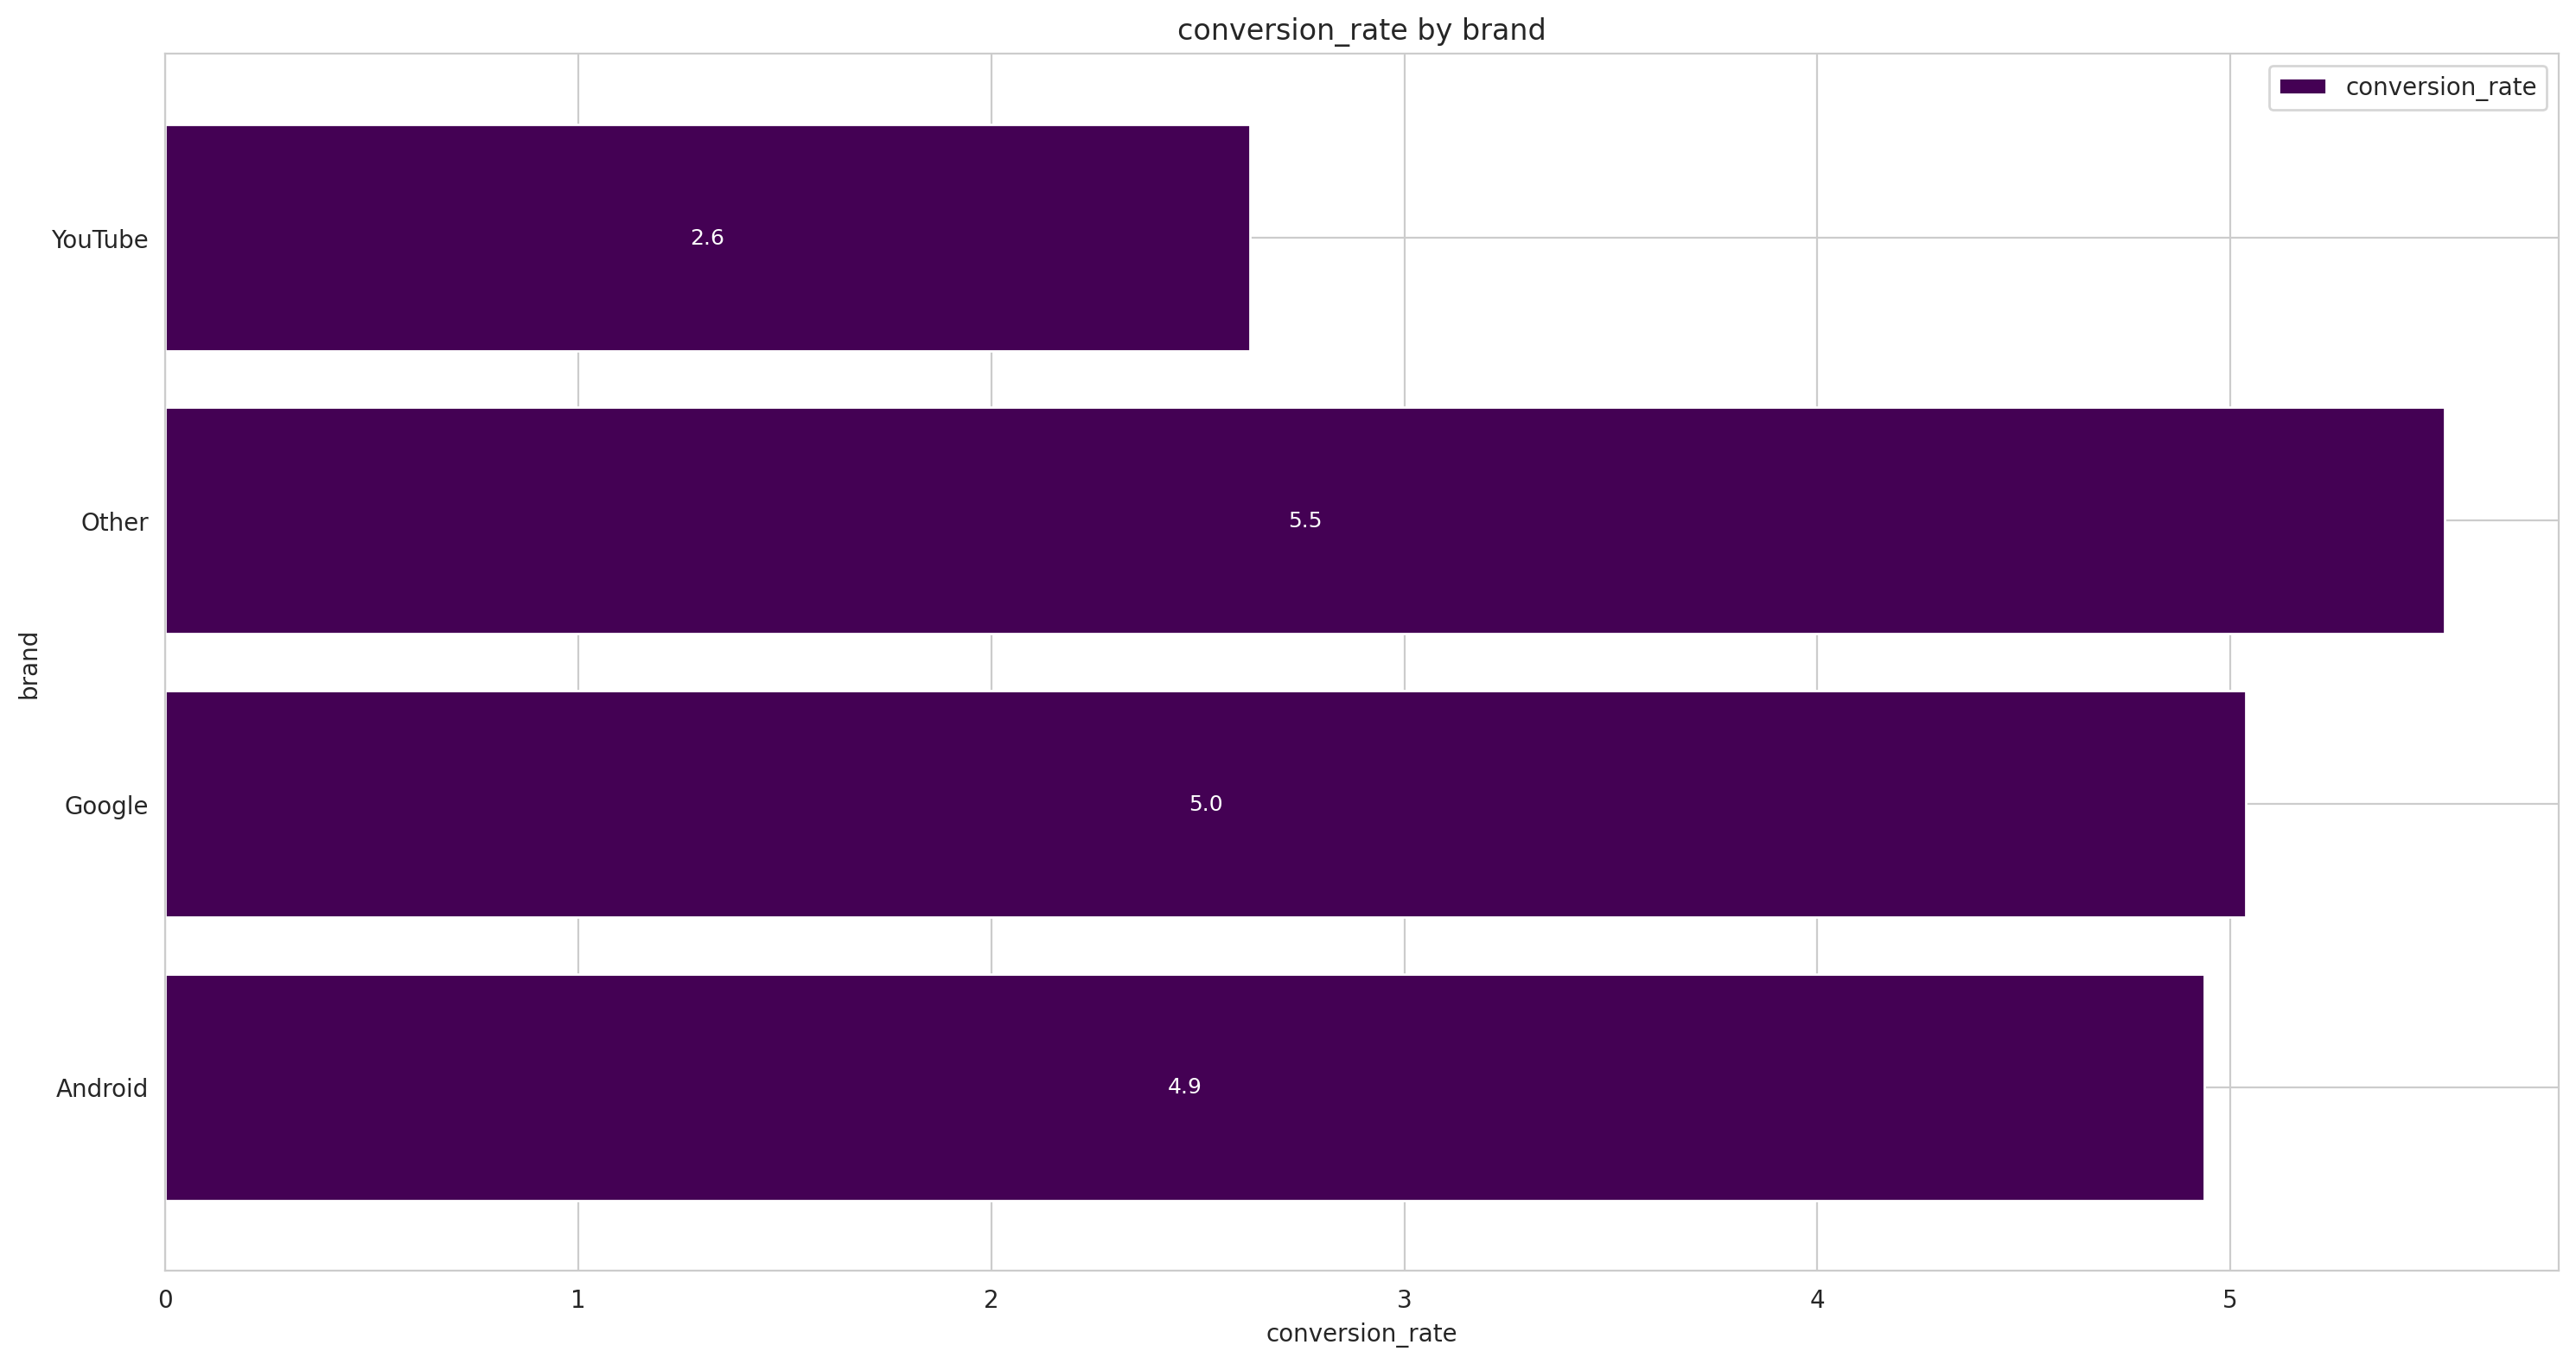

<Figure size 1500x800 with 0 Axes>

In [68]:
hier_analysis(data , ['brand' ] , conversion_agg , name  )

We notice that youtube brand products have the least conversion rate 

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

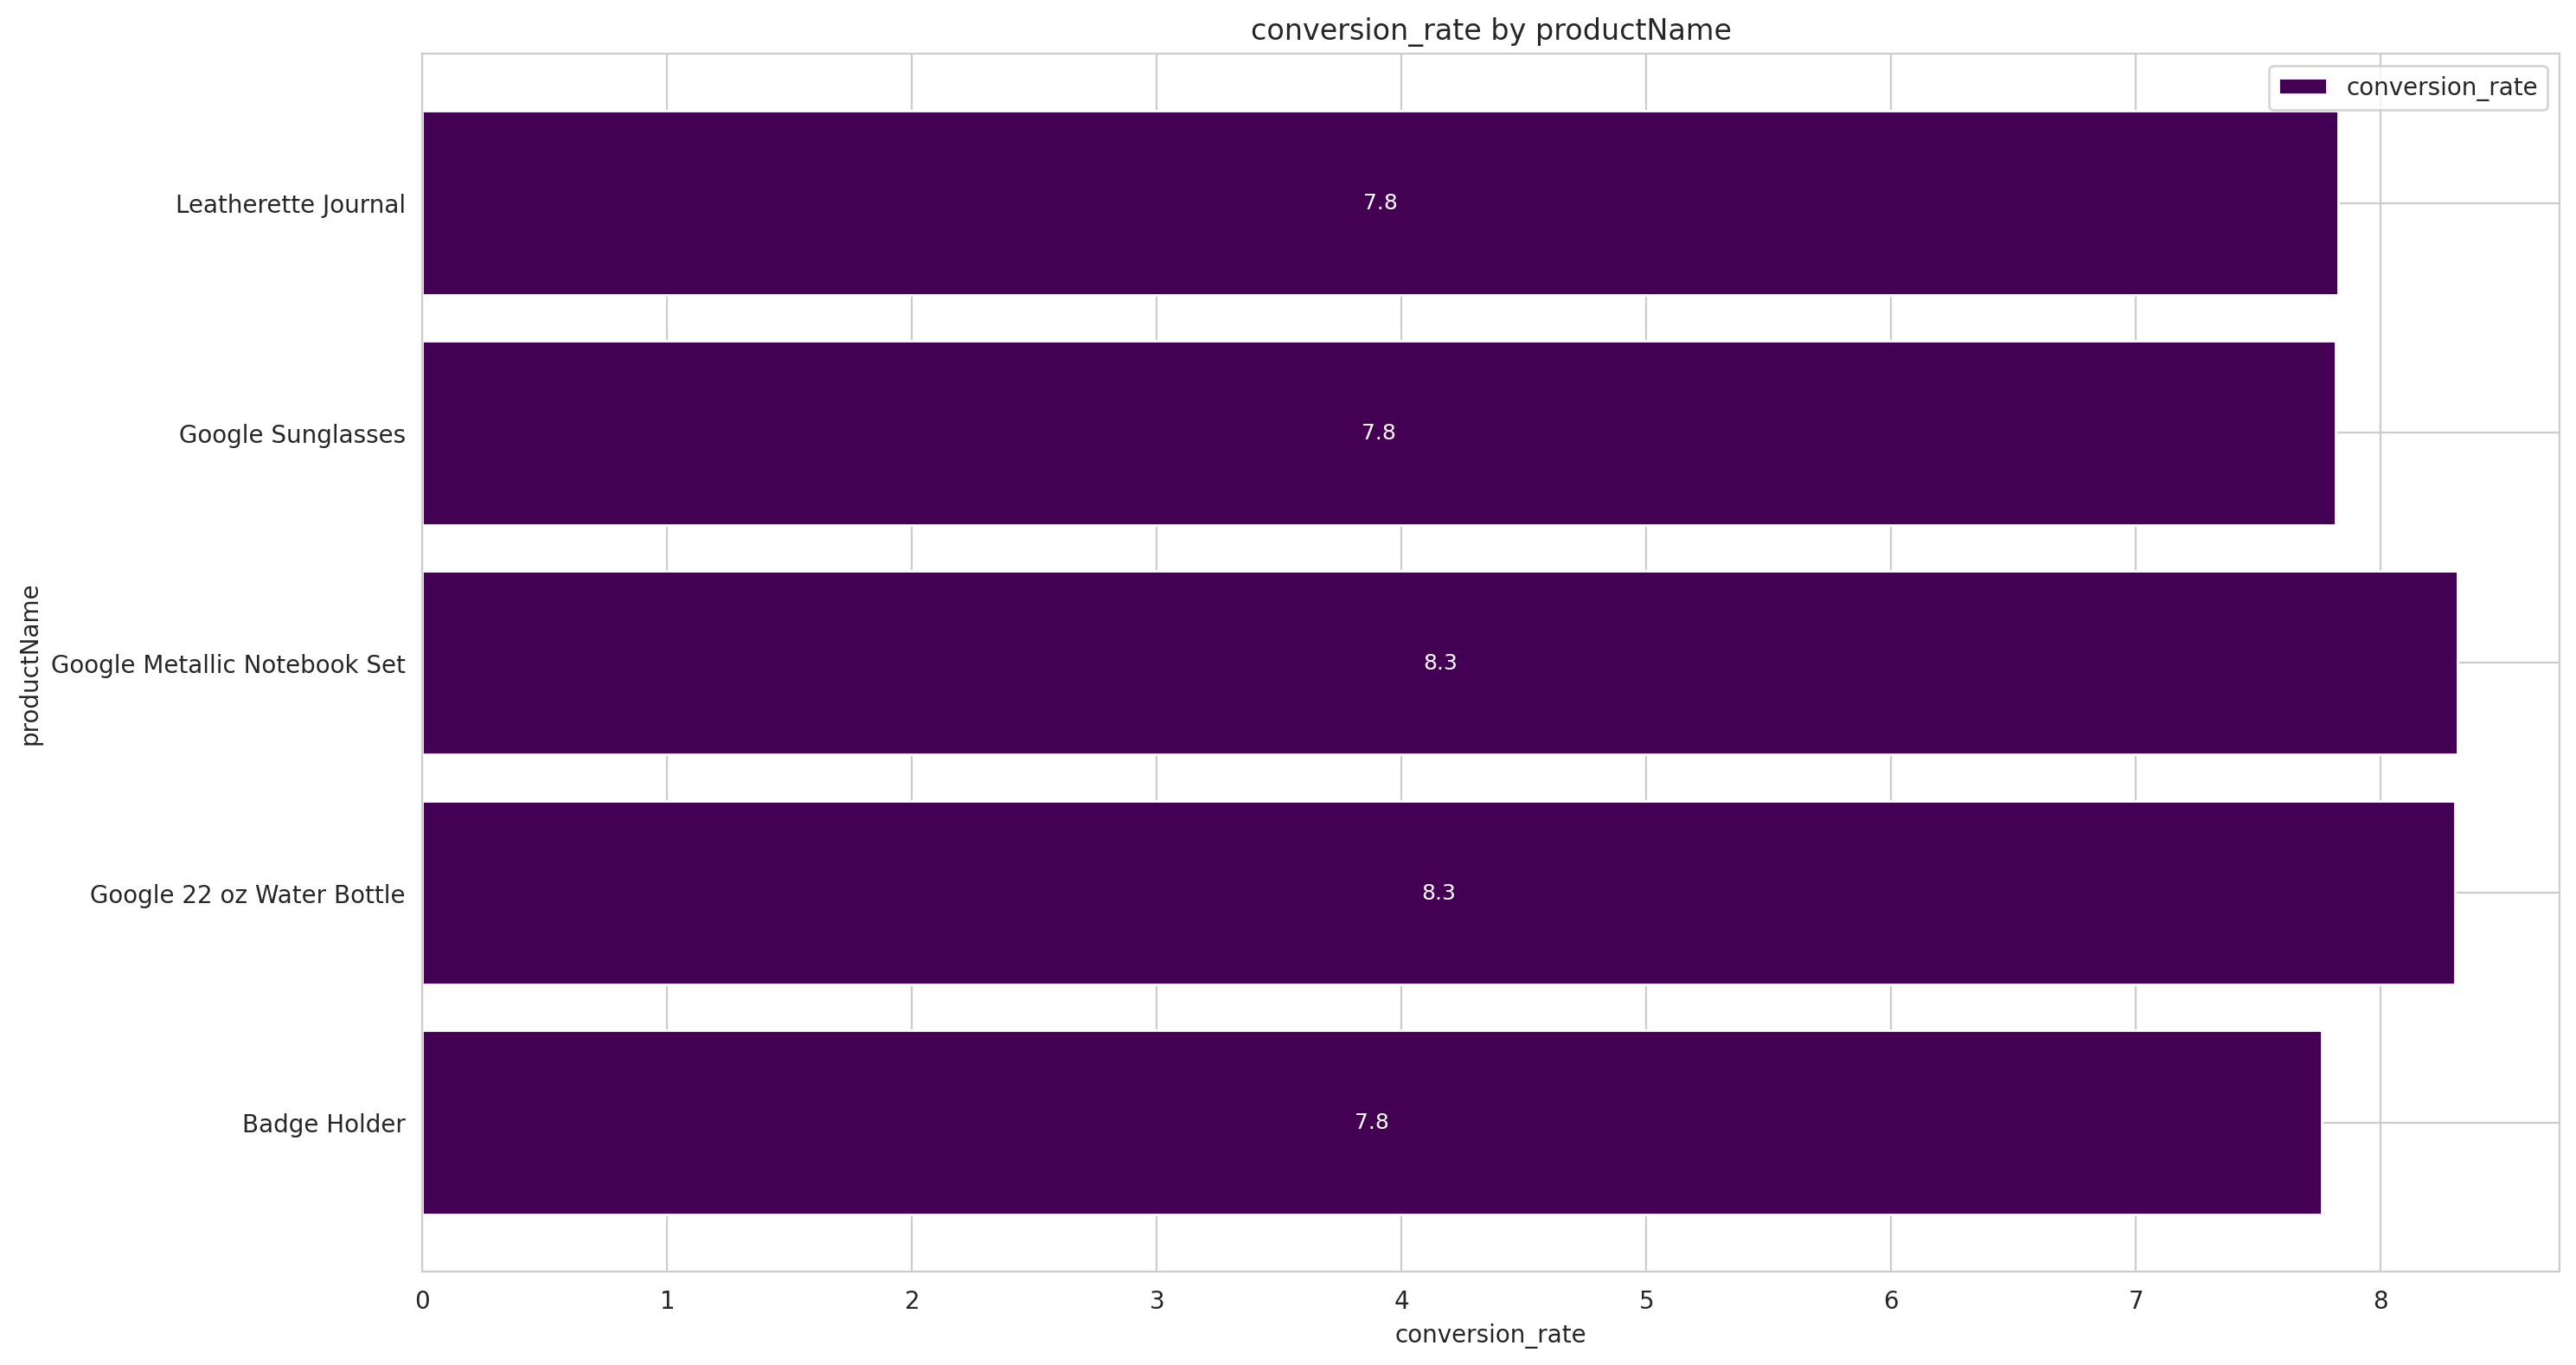

<Figure size 1500x800 with 0 Axes>

In [69]:
hier_analysis(data.loc[data['productName'].isin(top_conv_rate),:] , ['productName' ] , conversion_agg , name  )

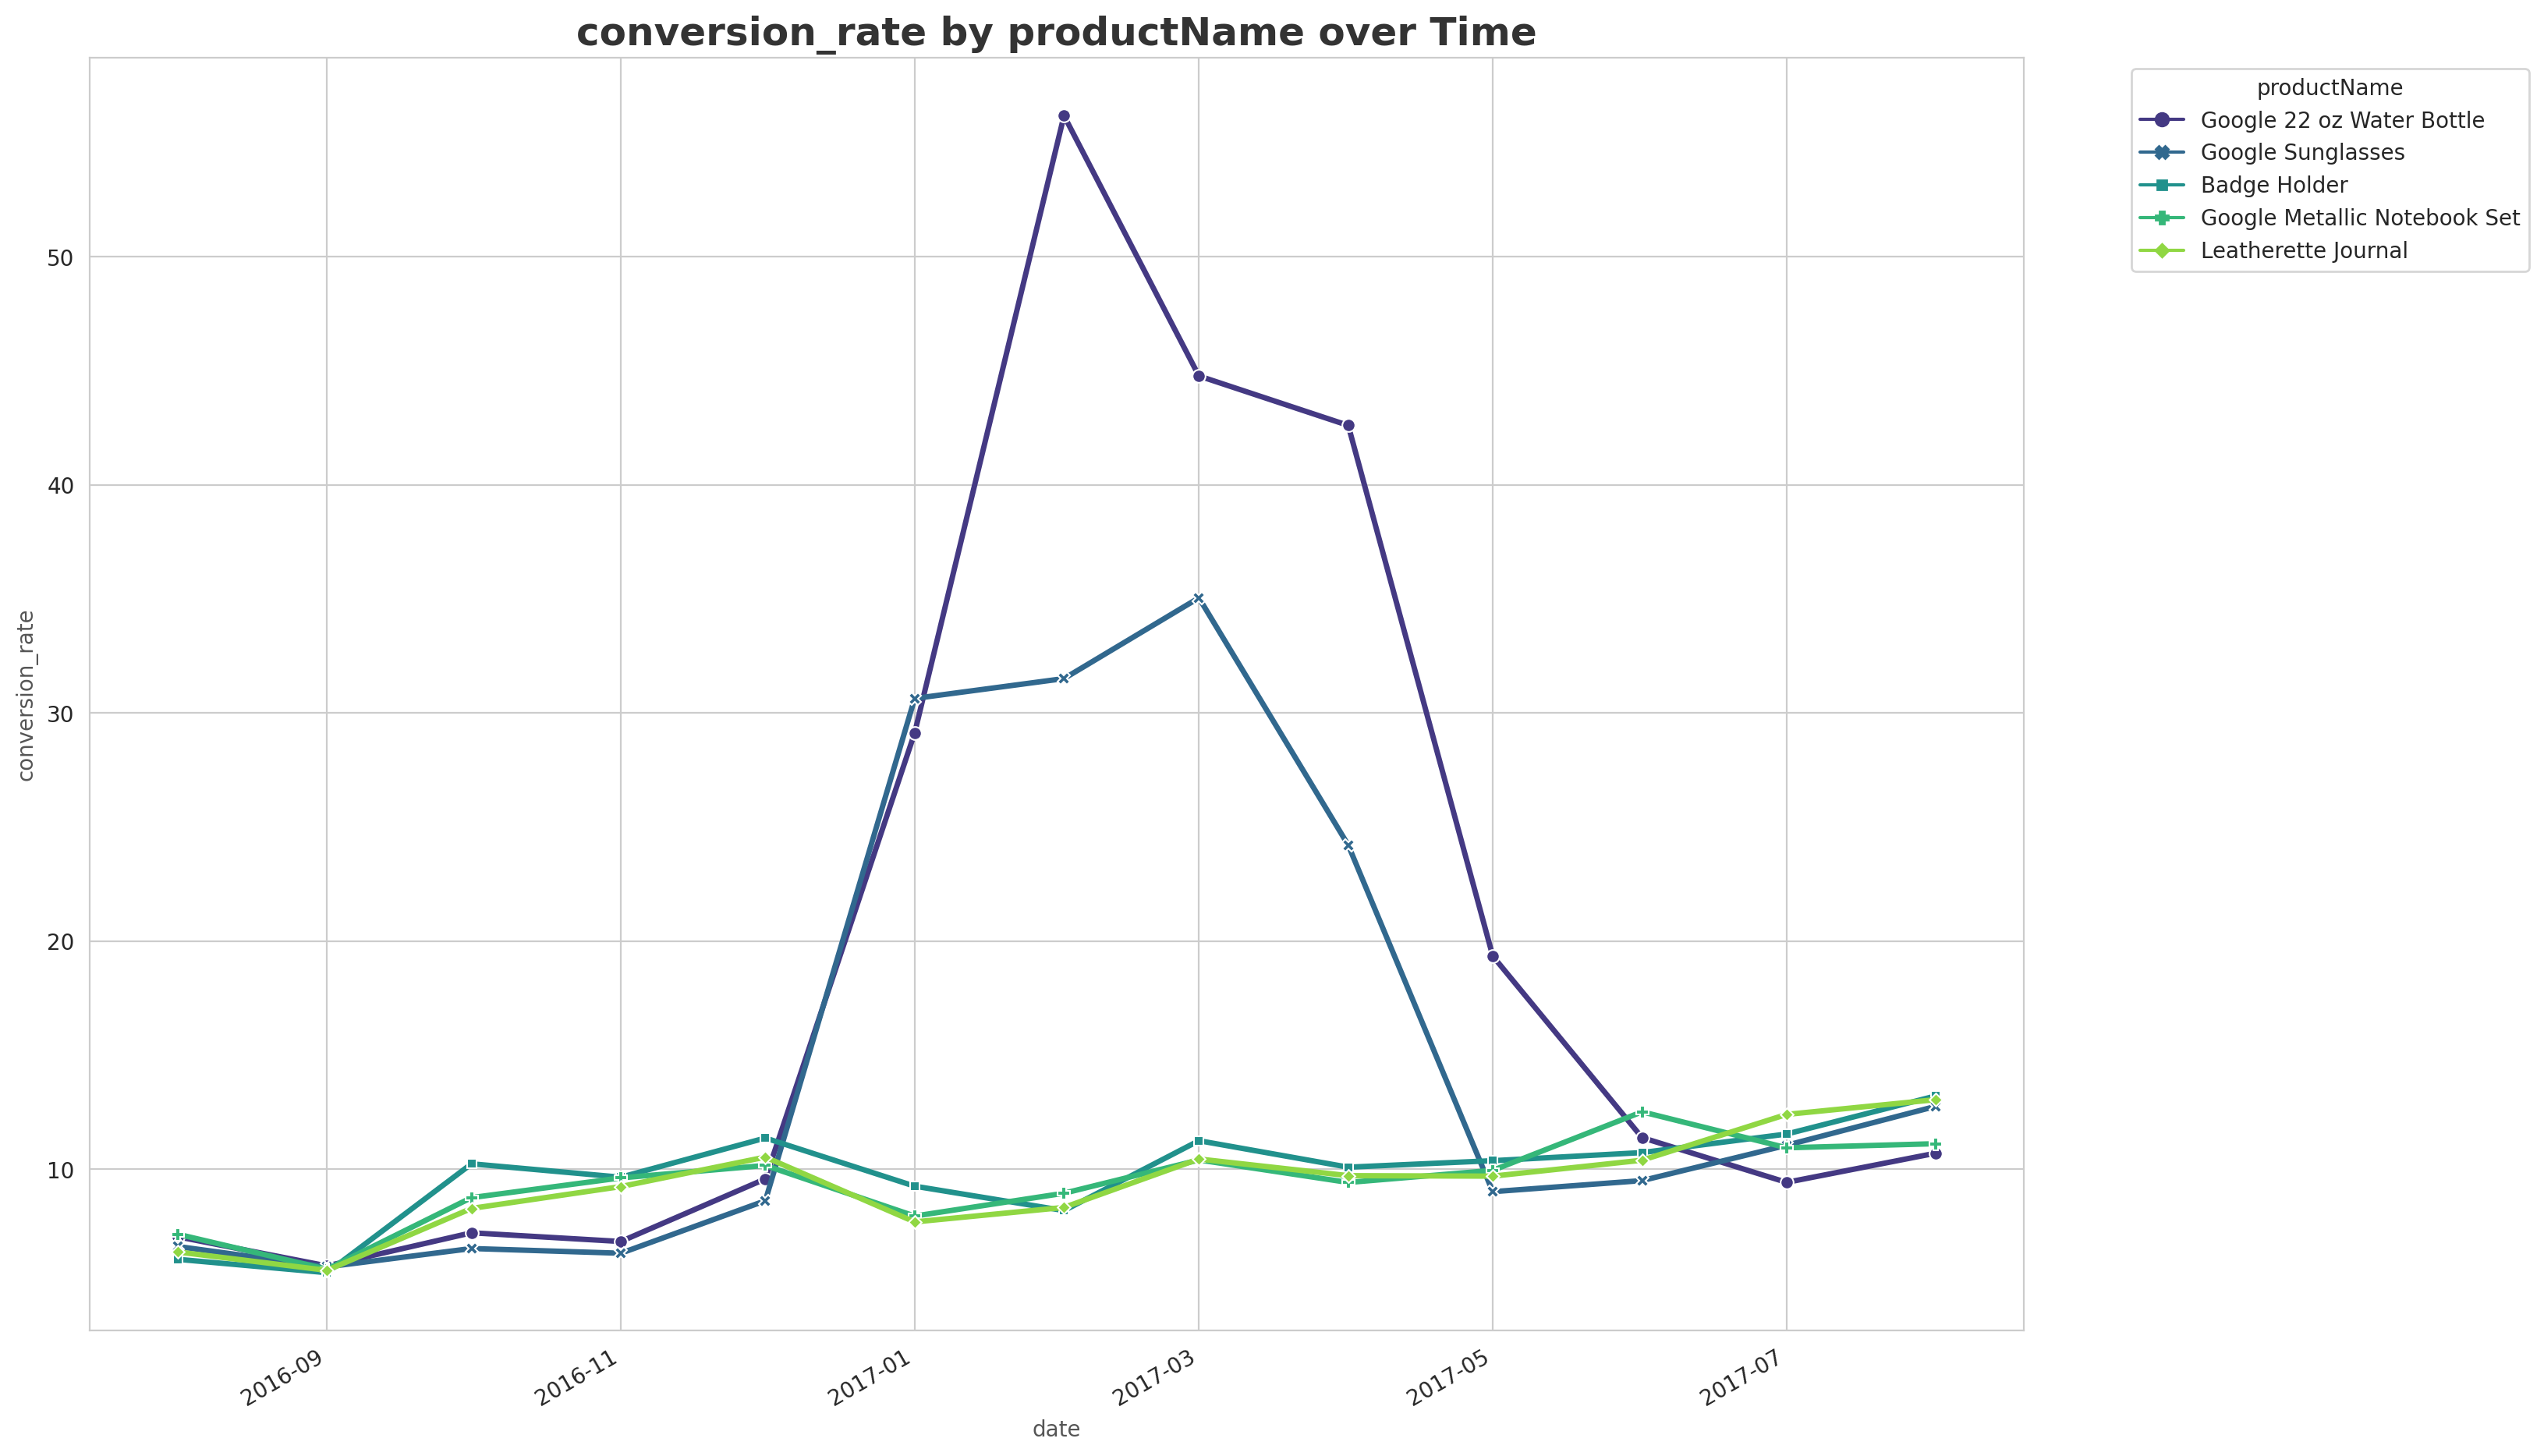

In [70]:
hier_analysis(data.loc[data['productName'].isin(top_conv_rate) ,:] , [  'productName', 'date' ] , conversion_agg , name , figsize=(16,12) )

We find that the top 5 products have average conversion r ate between 7 and 9 which is higher than the general average m but specifically "google 22 oz botle" and "google sunglasses " have almost 50 % conversion rate during summer , clear due to need to such products in this season.

## Funnel Analysis

Something that helps us to understand more conversion statistics, is studying funnel analysis, How much of users who go through purchase process drop or churn in each stage ? 

In [71]:
def plot_funnel(df) : 
    for product in df.index:
        stages = ['Product Detail Views', 'Add to Cart', 'Checkouts', 'Completed Purchases']
        values = df.loc[product].values
    
        fig = go.Funnel(
            y = stages,
            x = values,
            textinfo = "value+percent previous",
        )
        fig = go.Figure(fig)
        fig.update_layout(title_text=f'Funnel for {product}')
        # fig.show()



### General funnel

In [72]:
data['GP'] = 'GP'

In [73]:
plot_funnel(data.loc[: ,[ 'GP','product_detail_views', 'add_to_cart',
       'checkouts' , 'completed_purchases']].groupby('GP').sum())

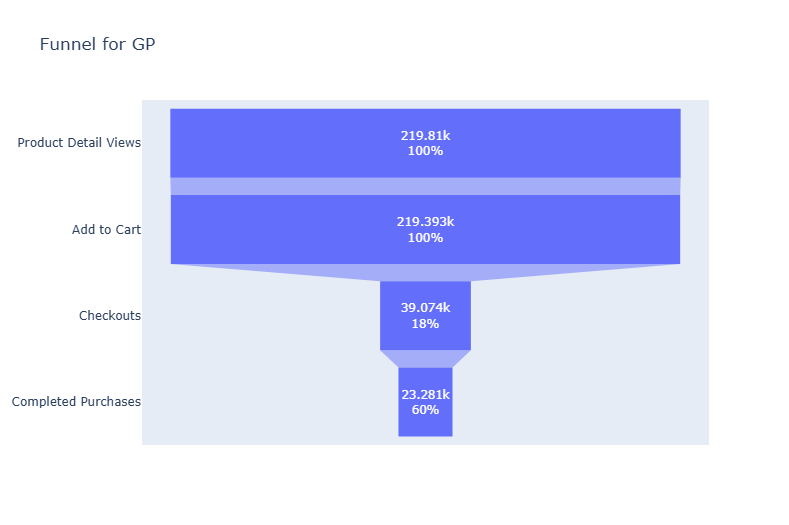

We find that generally , most users who churn churn between Add to cart and checkouts, almost 82% of users drop at that point may be they are hesitated or checkout button to be more tempting.

### By device category

In [74]:
plot_funnel(data.loc[: ,[ 'deviceCategory','product_detail_views', 'add_to_cart',
       'checkouts' , 'completed_purchases']].groupby('deviceCategory').sum())

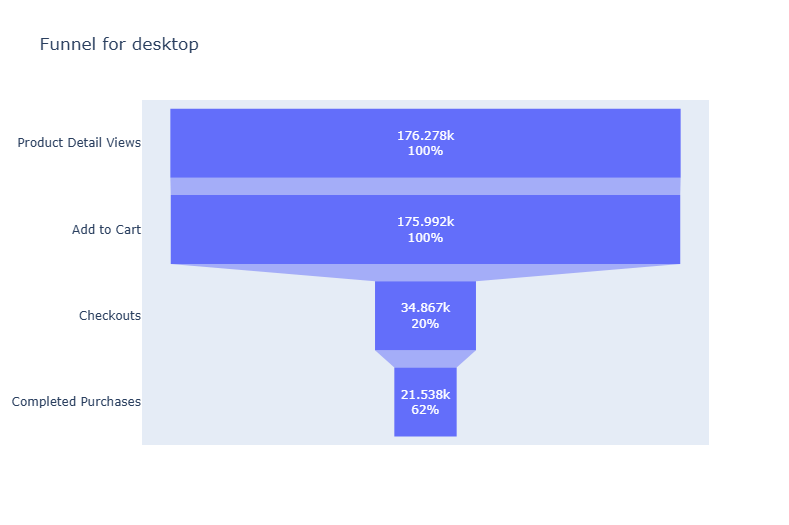
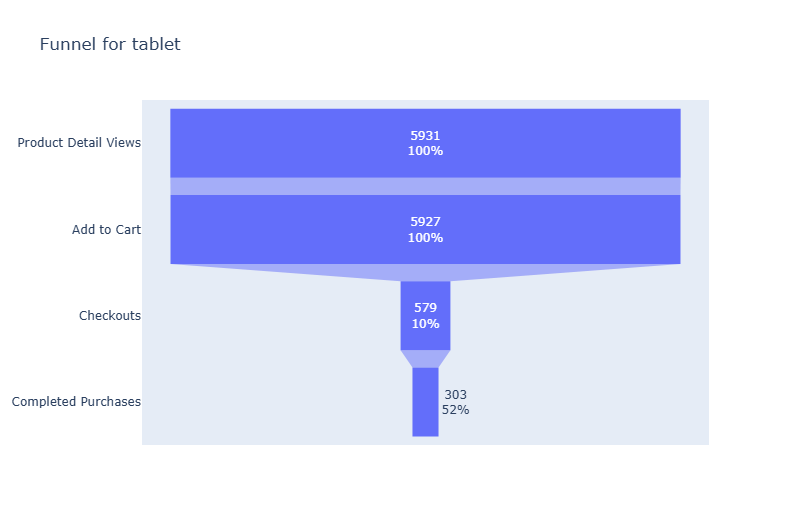
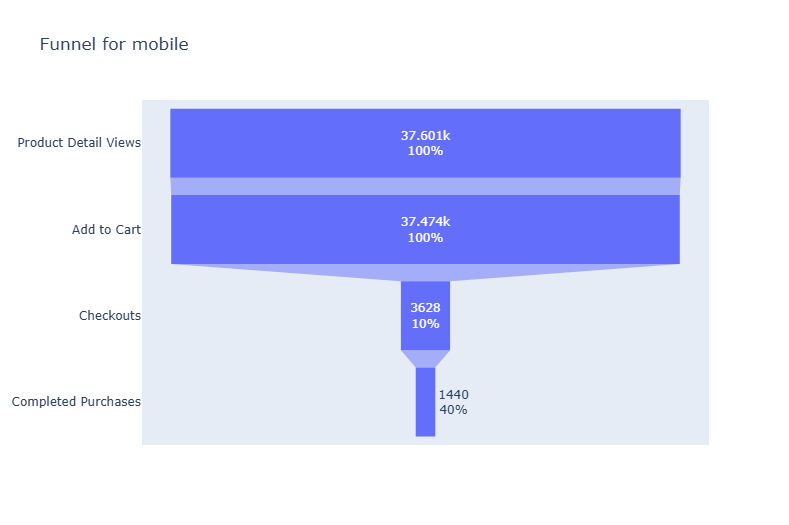

This gives supports what we found above , but gives us a more important piece of info , that from users go through purchase process, from them only 10 % go to checkout page in mobile and tablet users, but we see among desktop users the percentage increases to 20 % .

### By product

* Top bounce products :
  

In [75]:
plot_funnel(data.loc[ (data['productName'].isin(top_bounce)),[ 'productName','product_detail_views', 'add_to_cart',
       'checkouts' , 'completed_purchases']].groupby('productName').sum())

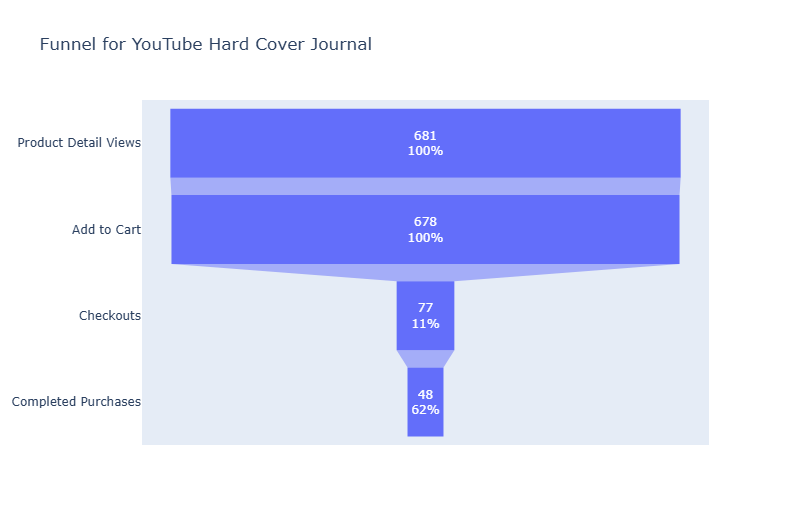
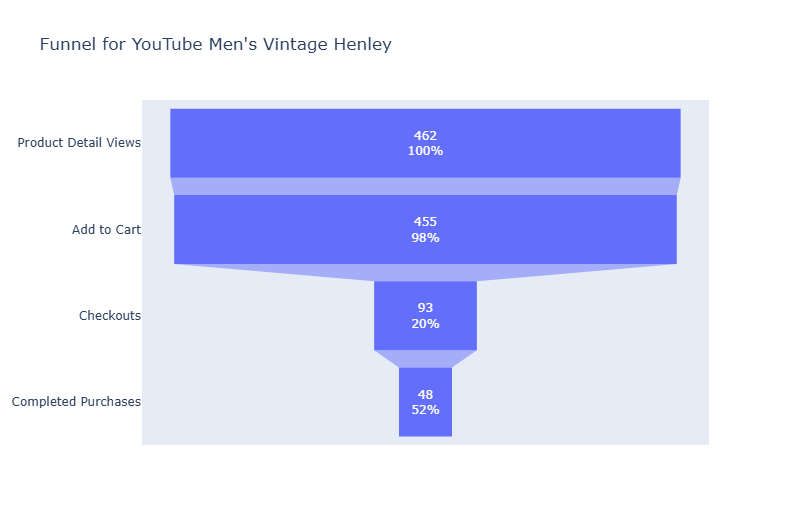
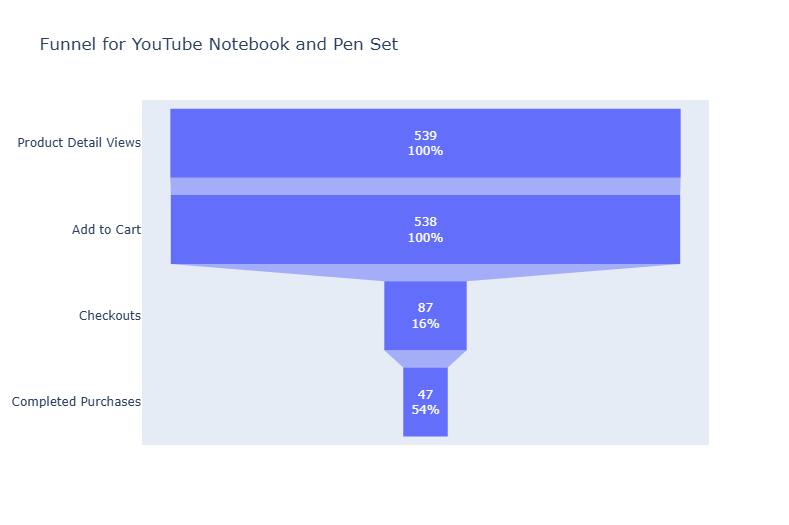
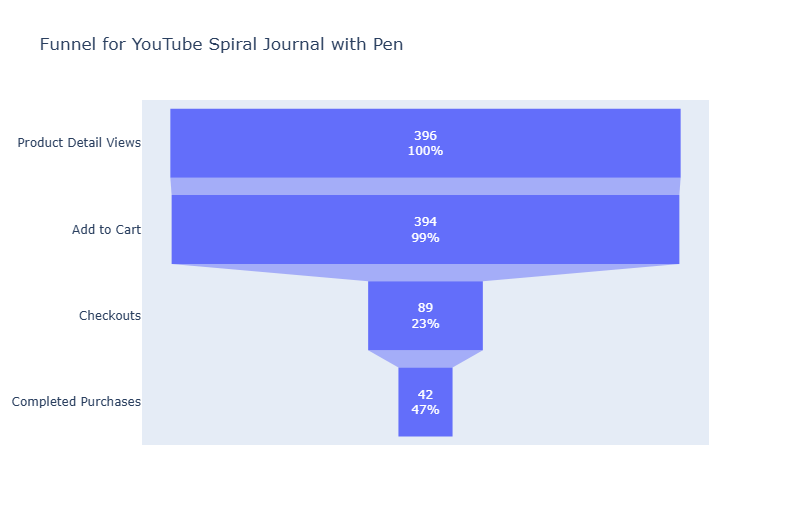
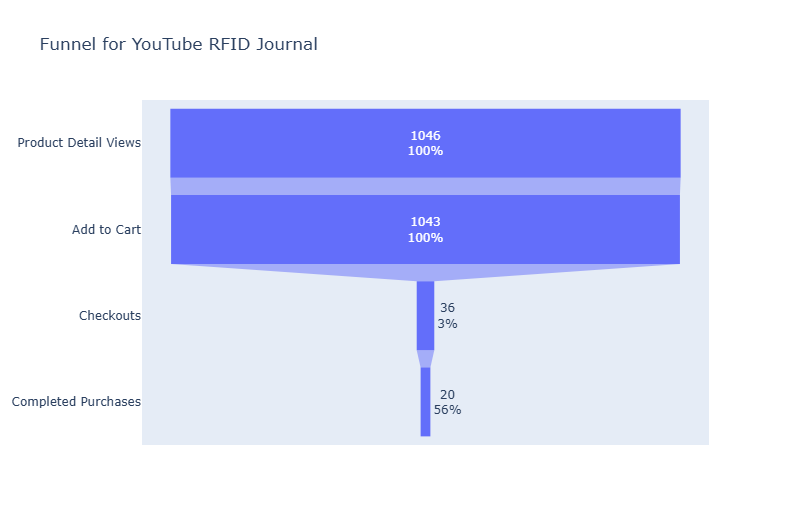

continuation percentage to checkout drops as low as 3 % despite relatively high percentage in case "Youtube spiral journal with pen"

* Top conversion rate products

In [76]:
plot_funnel( data.loc[ (data['productName'].isin(top_conv_rate)),[ 'productName','product_detail_views', 'add_to_cart',
       'checkouts' , 'completed_purchases']].groupby('productName').sum()) 

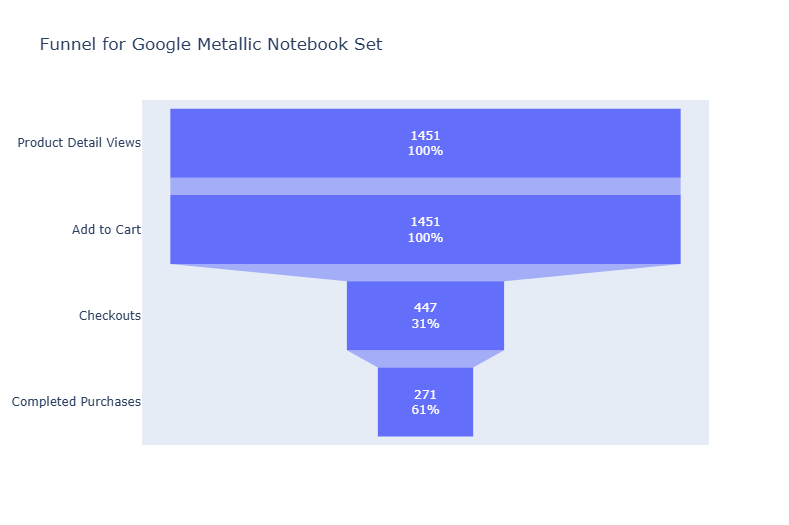
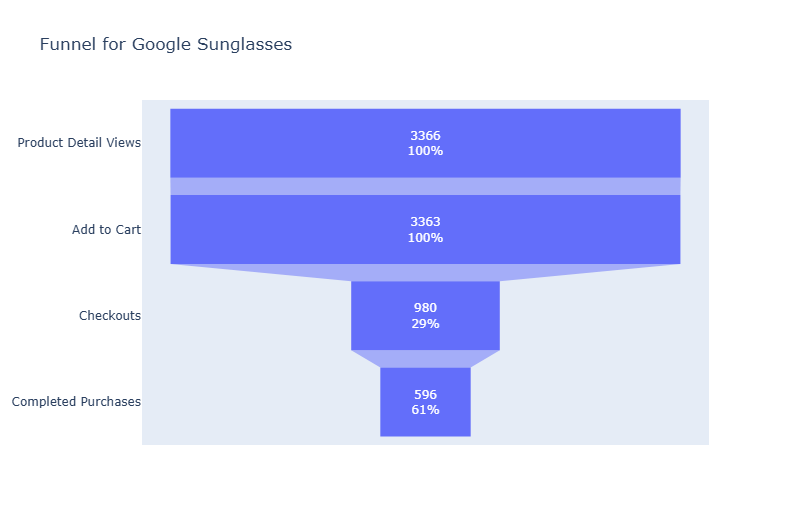
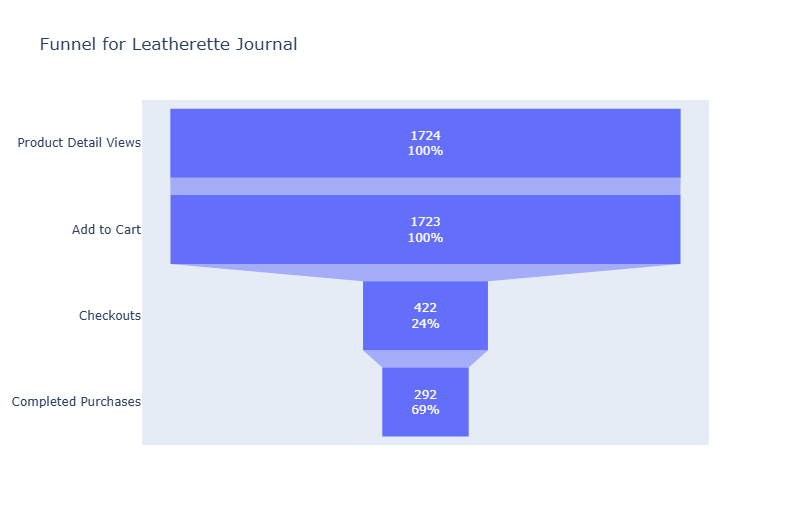
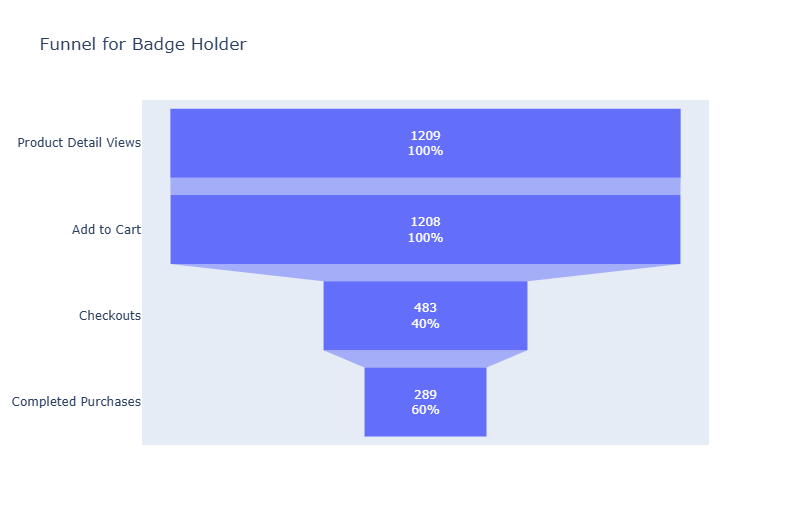
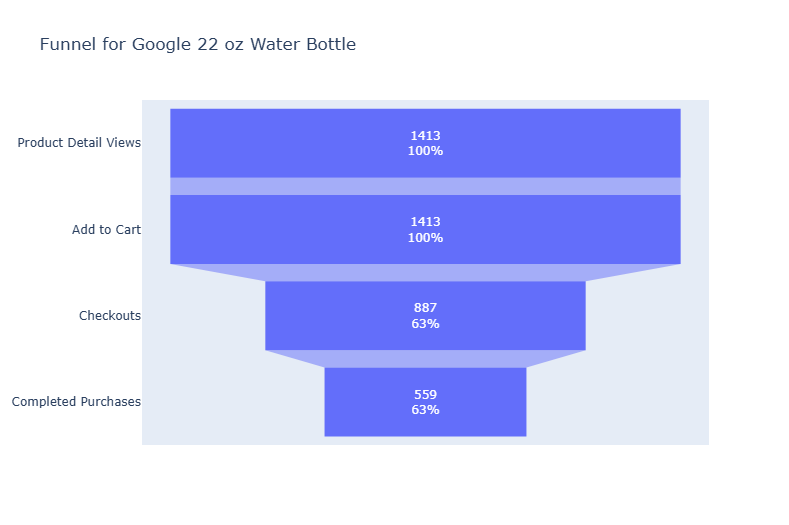

Here  we find that among these products unlike top bounce products these products have continuation rate to checkout no less than 20 % up to 63% .

**Executive summary for conversion & funnel Statistics**

1 - Most conversion rate from Desktop users

2- Most from CPM and direct traffic, Despite affiliate traffic has less bounce rate it has as well less conversion

3 - More conversion by far from returning than new users 

4 - least conversion in Early morning due to way to work and early work hours


5- most conversion in summer and new year holidays.

6 - products with most bounce rate are different regarding funnel from the most conversion products in the stage of checkout. indicating that many churn users are in this stage

## Revenue Insights

We will take revenue per session as our metric.

In [77]:
revenue_agg = lambda x : x['total_revenue'].sum() / x['total_sessions'].sum()
name='revenue_per_session in $'

In [78]:
product_metrics[['revenue_per_session', 'conversion_rate']].corr()

,revenue_per_session,conversion_rate
revenue_per_session,1.000000,0.409197
conversion_rate,0.409197,1.000000


average positive relationship with conversion rate

**By traffic medium**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

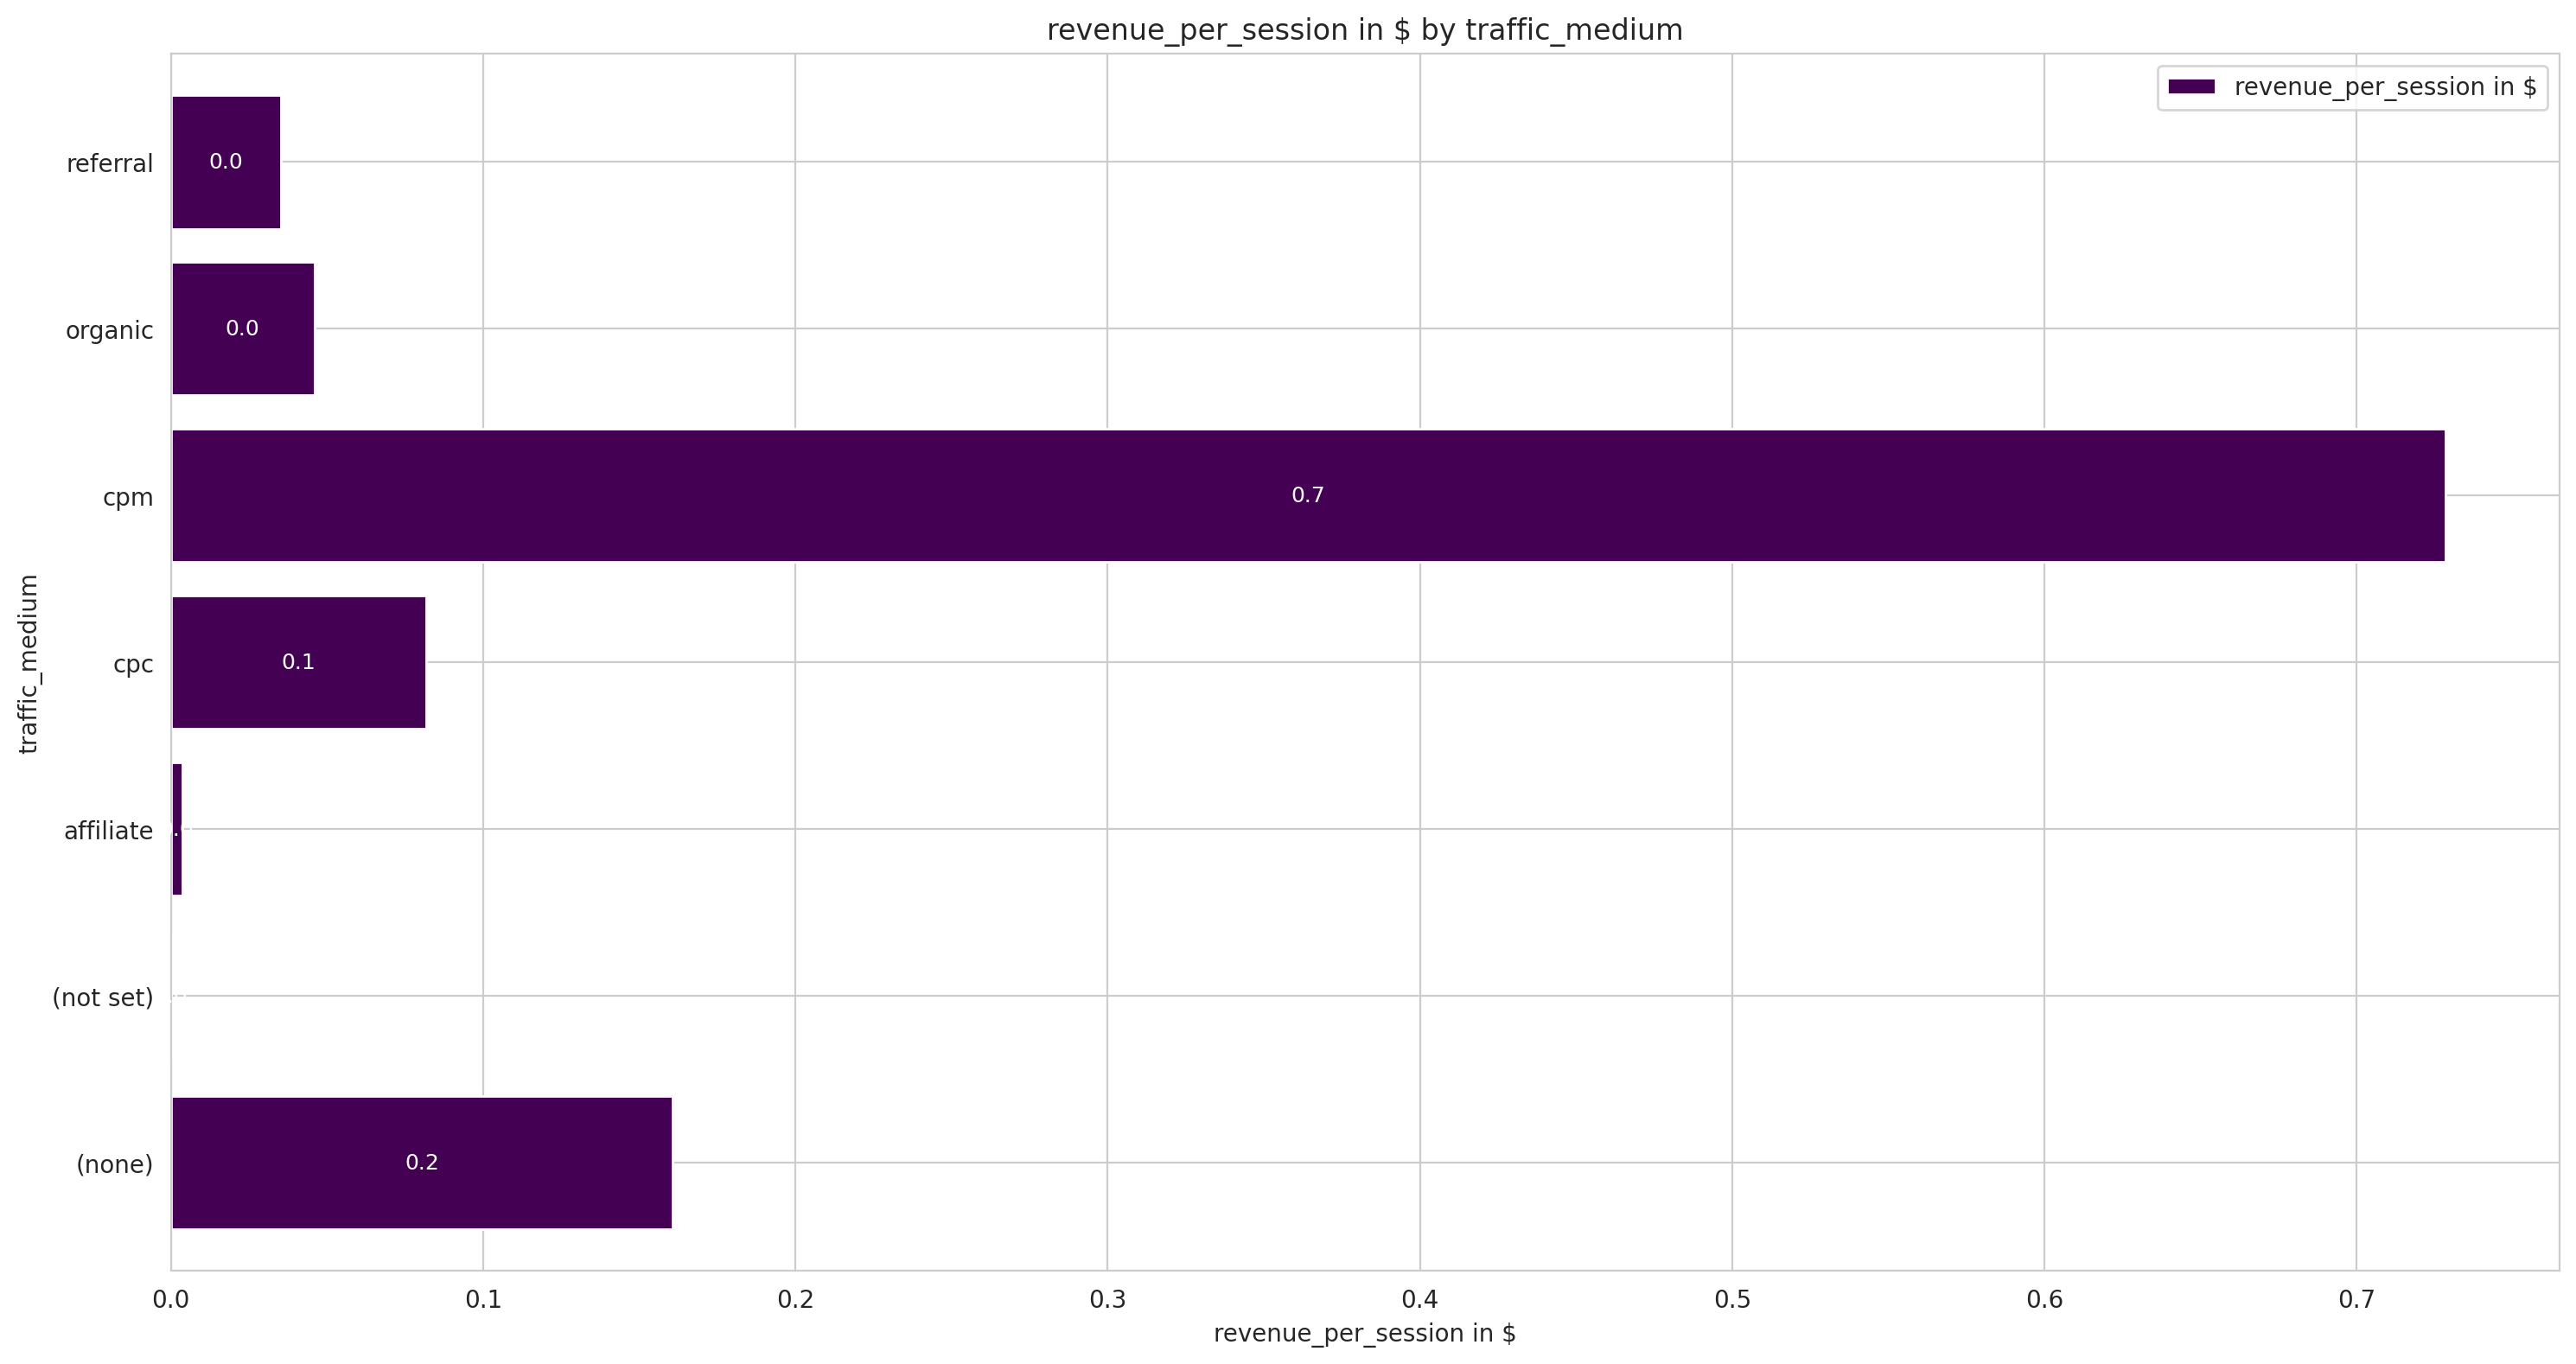

<Figure size 1500x800 with 0 Axes>

In [79]:
hier_analysis(data , [   'traffic_medium' ] , revenue_agg , name  )

Highest level at CPM and none traffic medium similarily as conversion rate.

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

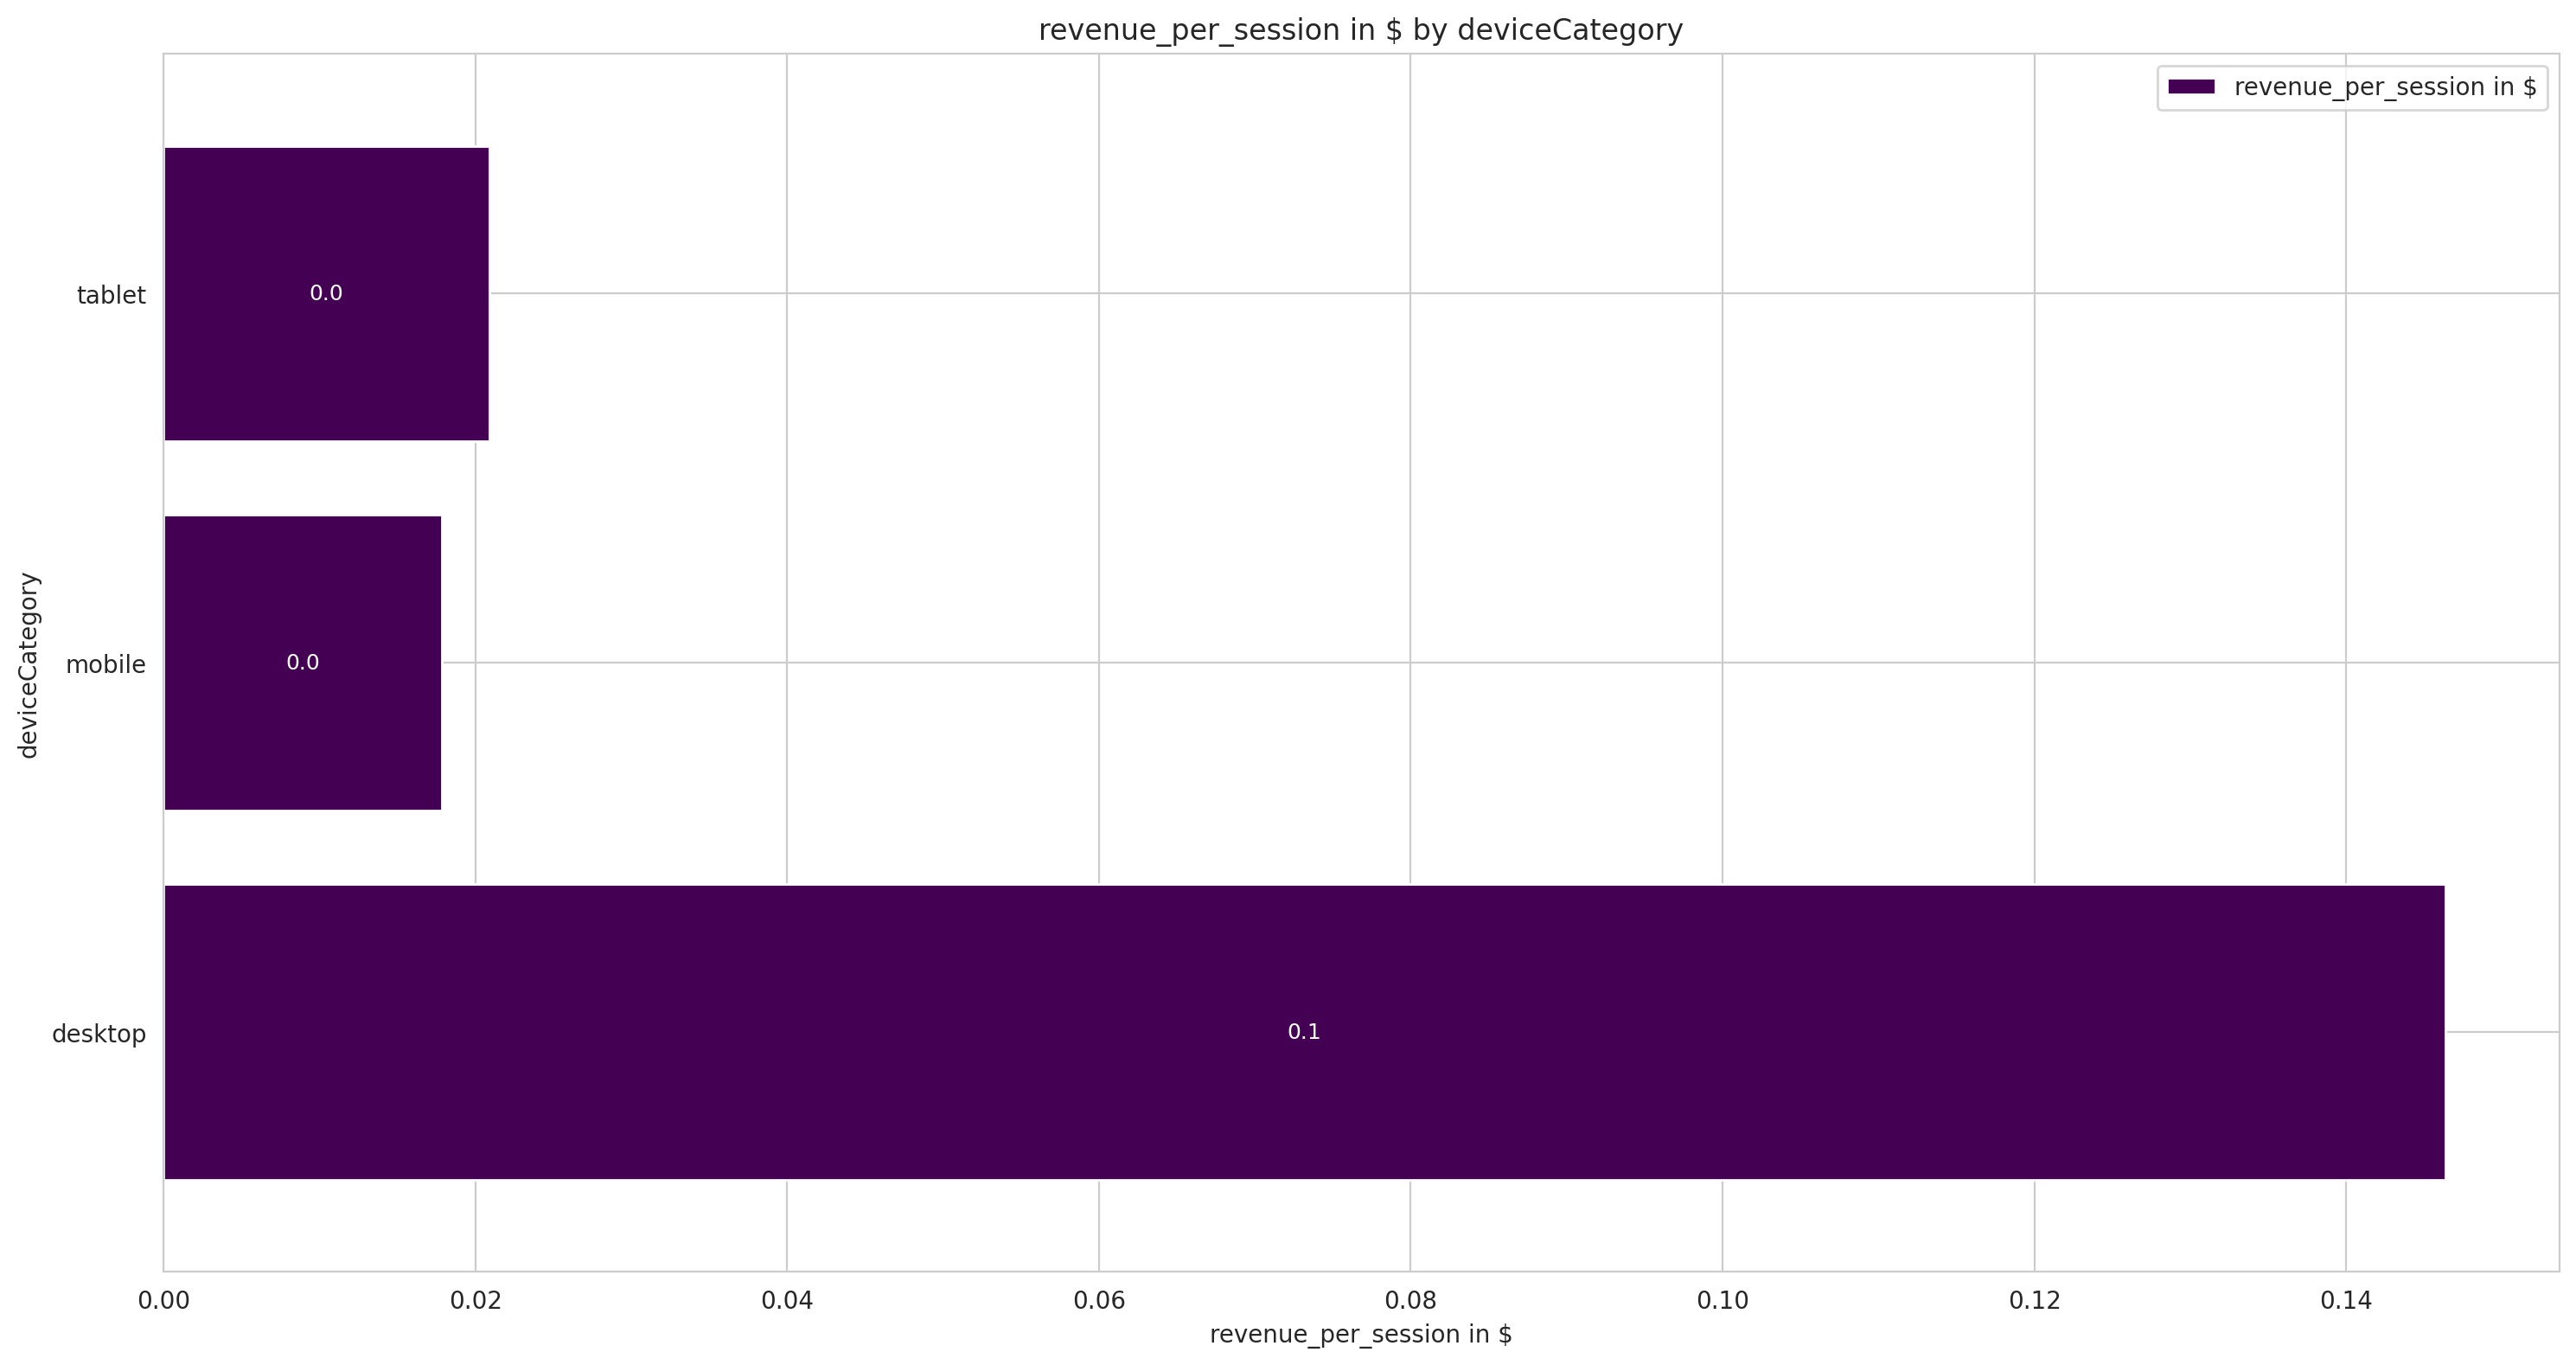

<Figure size 1500x800 with 0 Axes>

In [80]:
hier_analysis(data , [   'deviceCategory' ] , revenue_agg , name  )

**By product**

<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

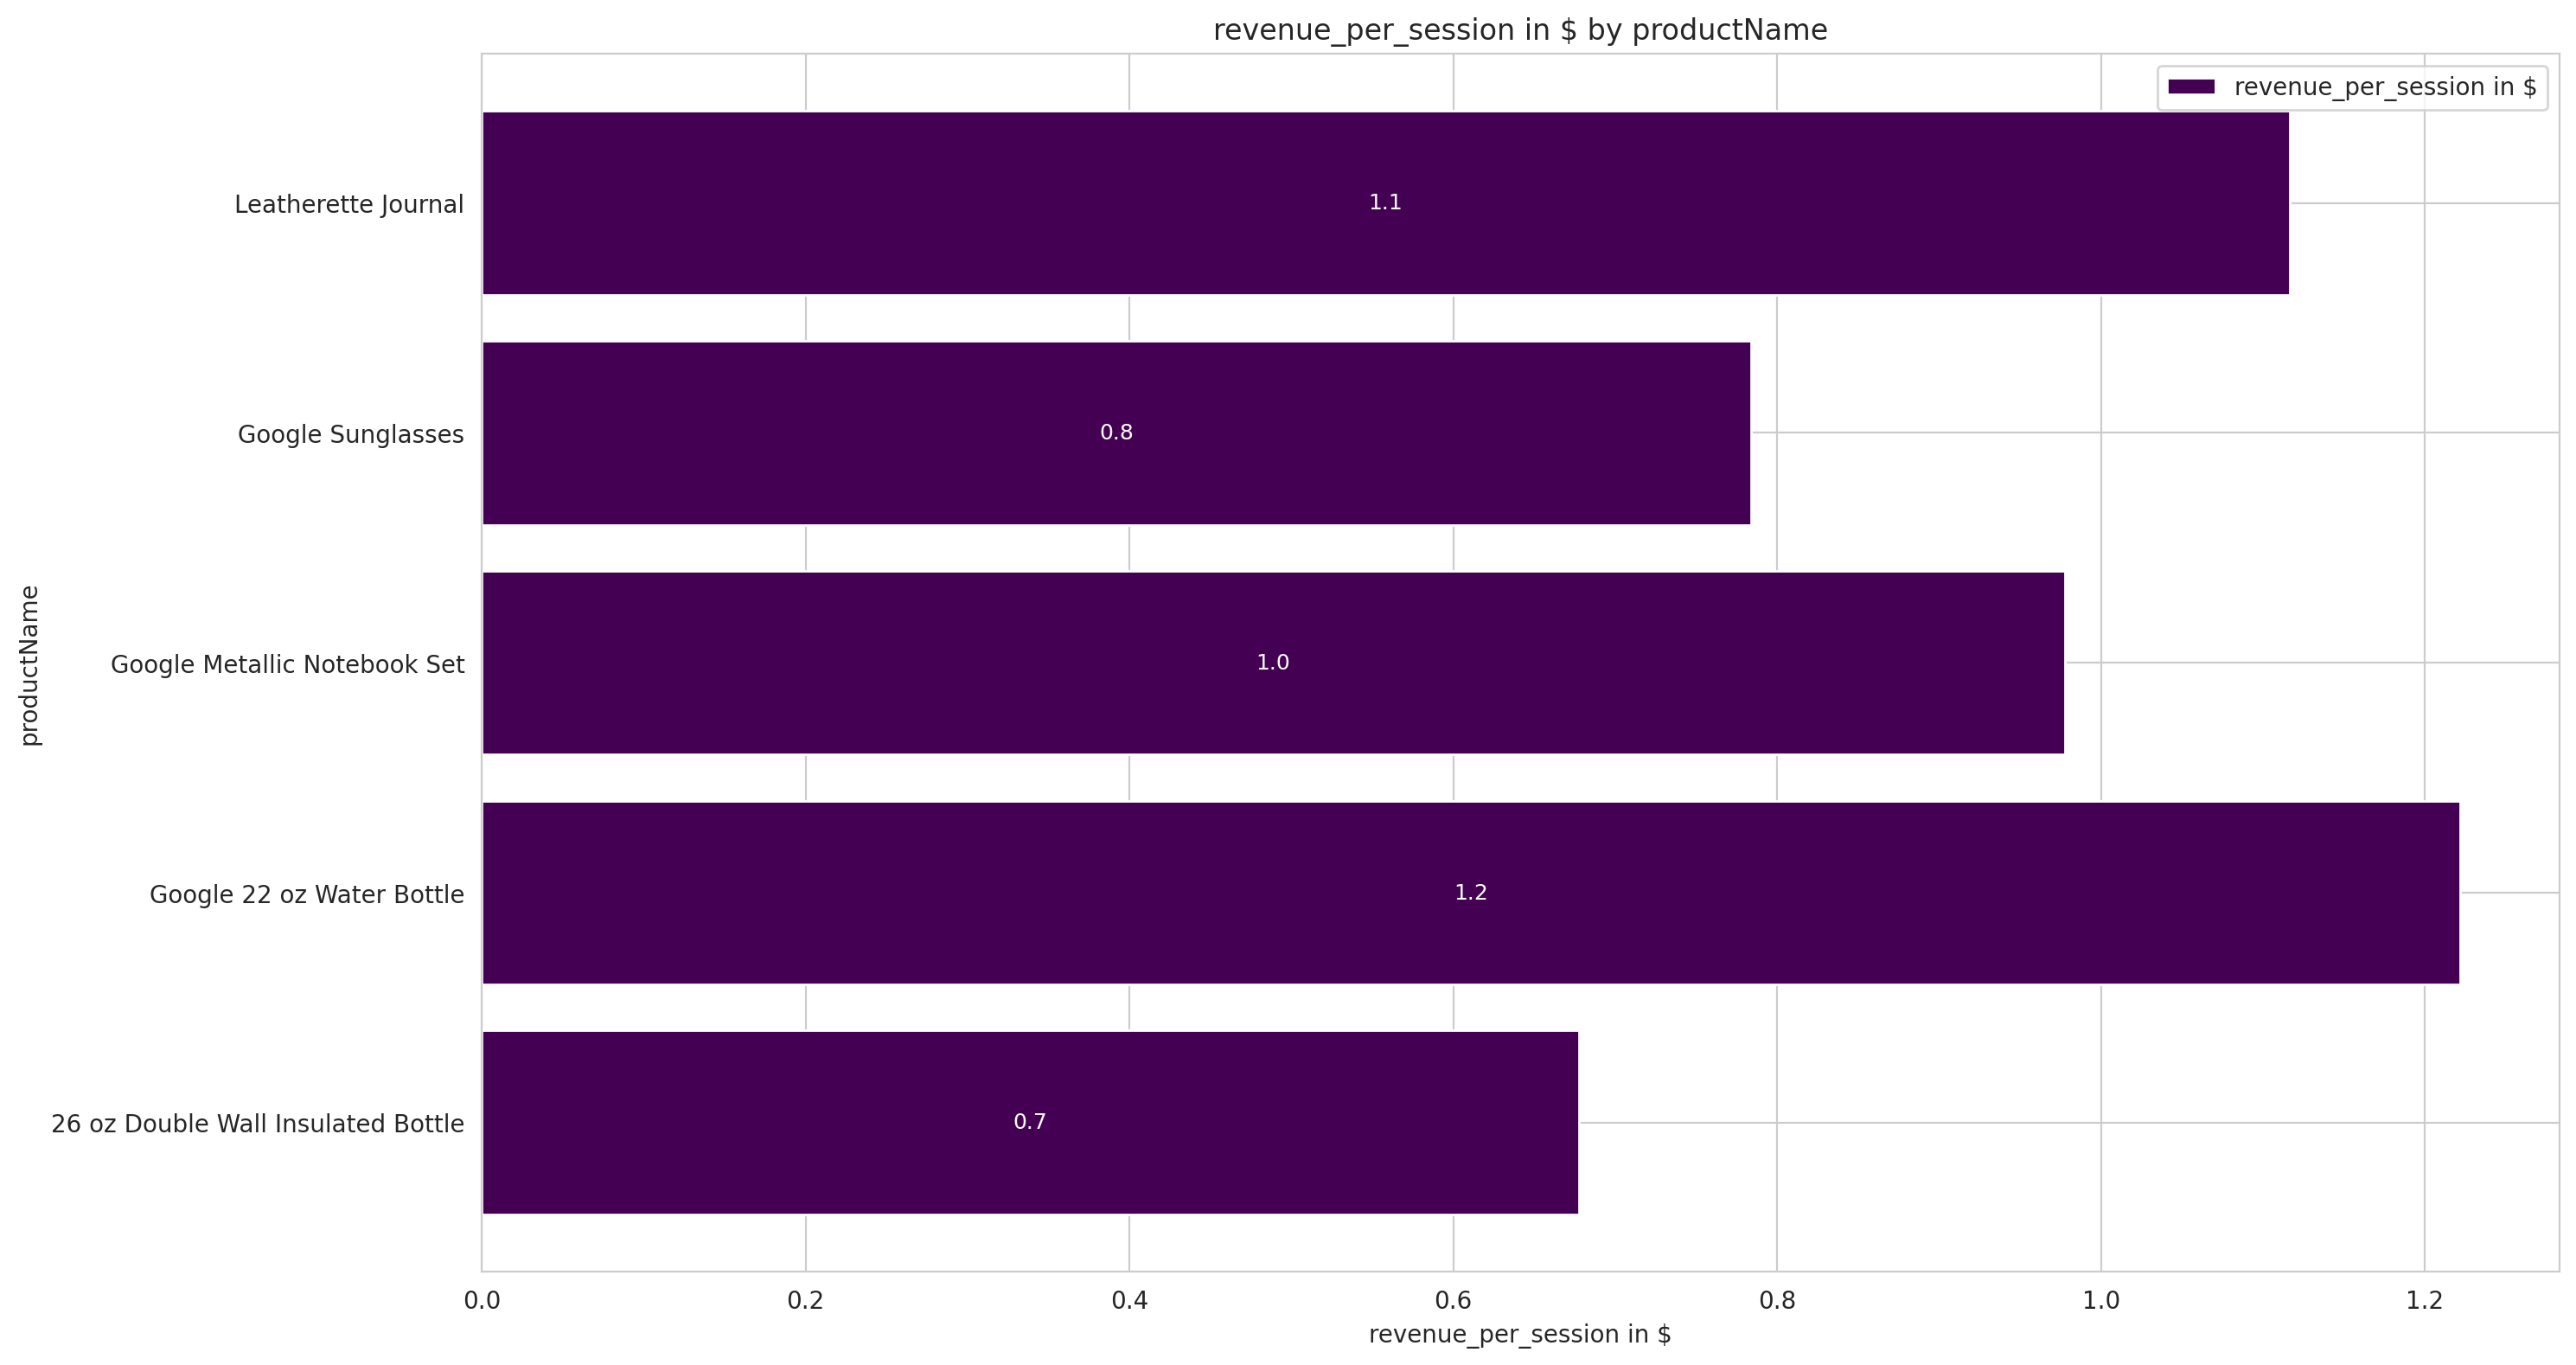

<Figure size 1500x800 with 0 Axes>

In [81]:
hier_analysis(data.loc[data['productName'].isin(top_rev) ,:] , [  'productName' ] , revenue_agg , name  )

In [82]:
[x for x in most_effecient_products['productName'] if x in top_rev]

['26 oz Double Wall Insulated Bottle',
 'Google Sunglasses',
 'Google 22 oz Water Bottle',
 'Leatherette Journal',
 'Google Metallic Notebook Set']

Here we find that top 5 revenue per session are included in the most effecient products part , which is valid by definition.

Despite the whole average per traffic rate is less than 1 , in the top 2 peoducts it exceeds 1 , assuring that there is an exceptional thing about them.

<Figure size 1200x500 with 0 Axes>

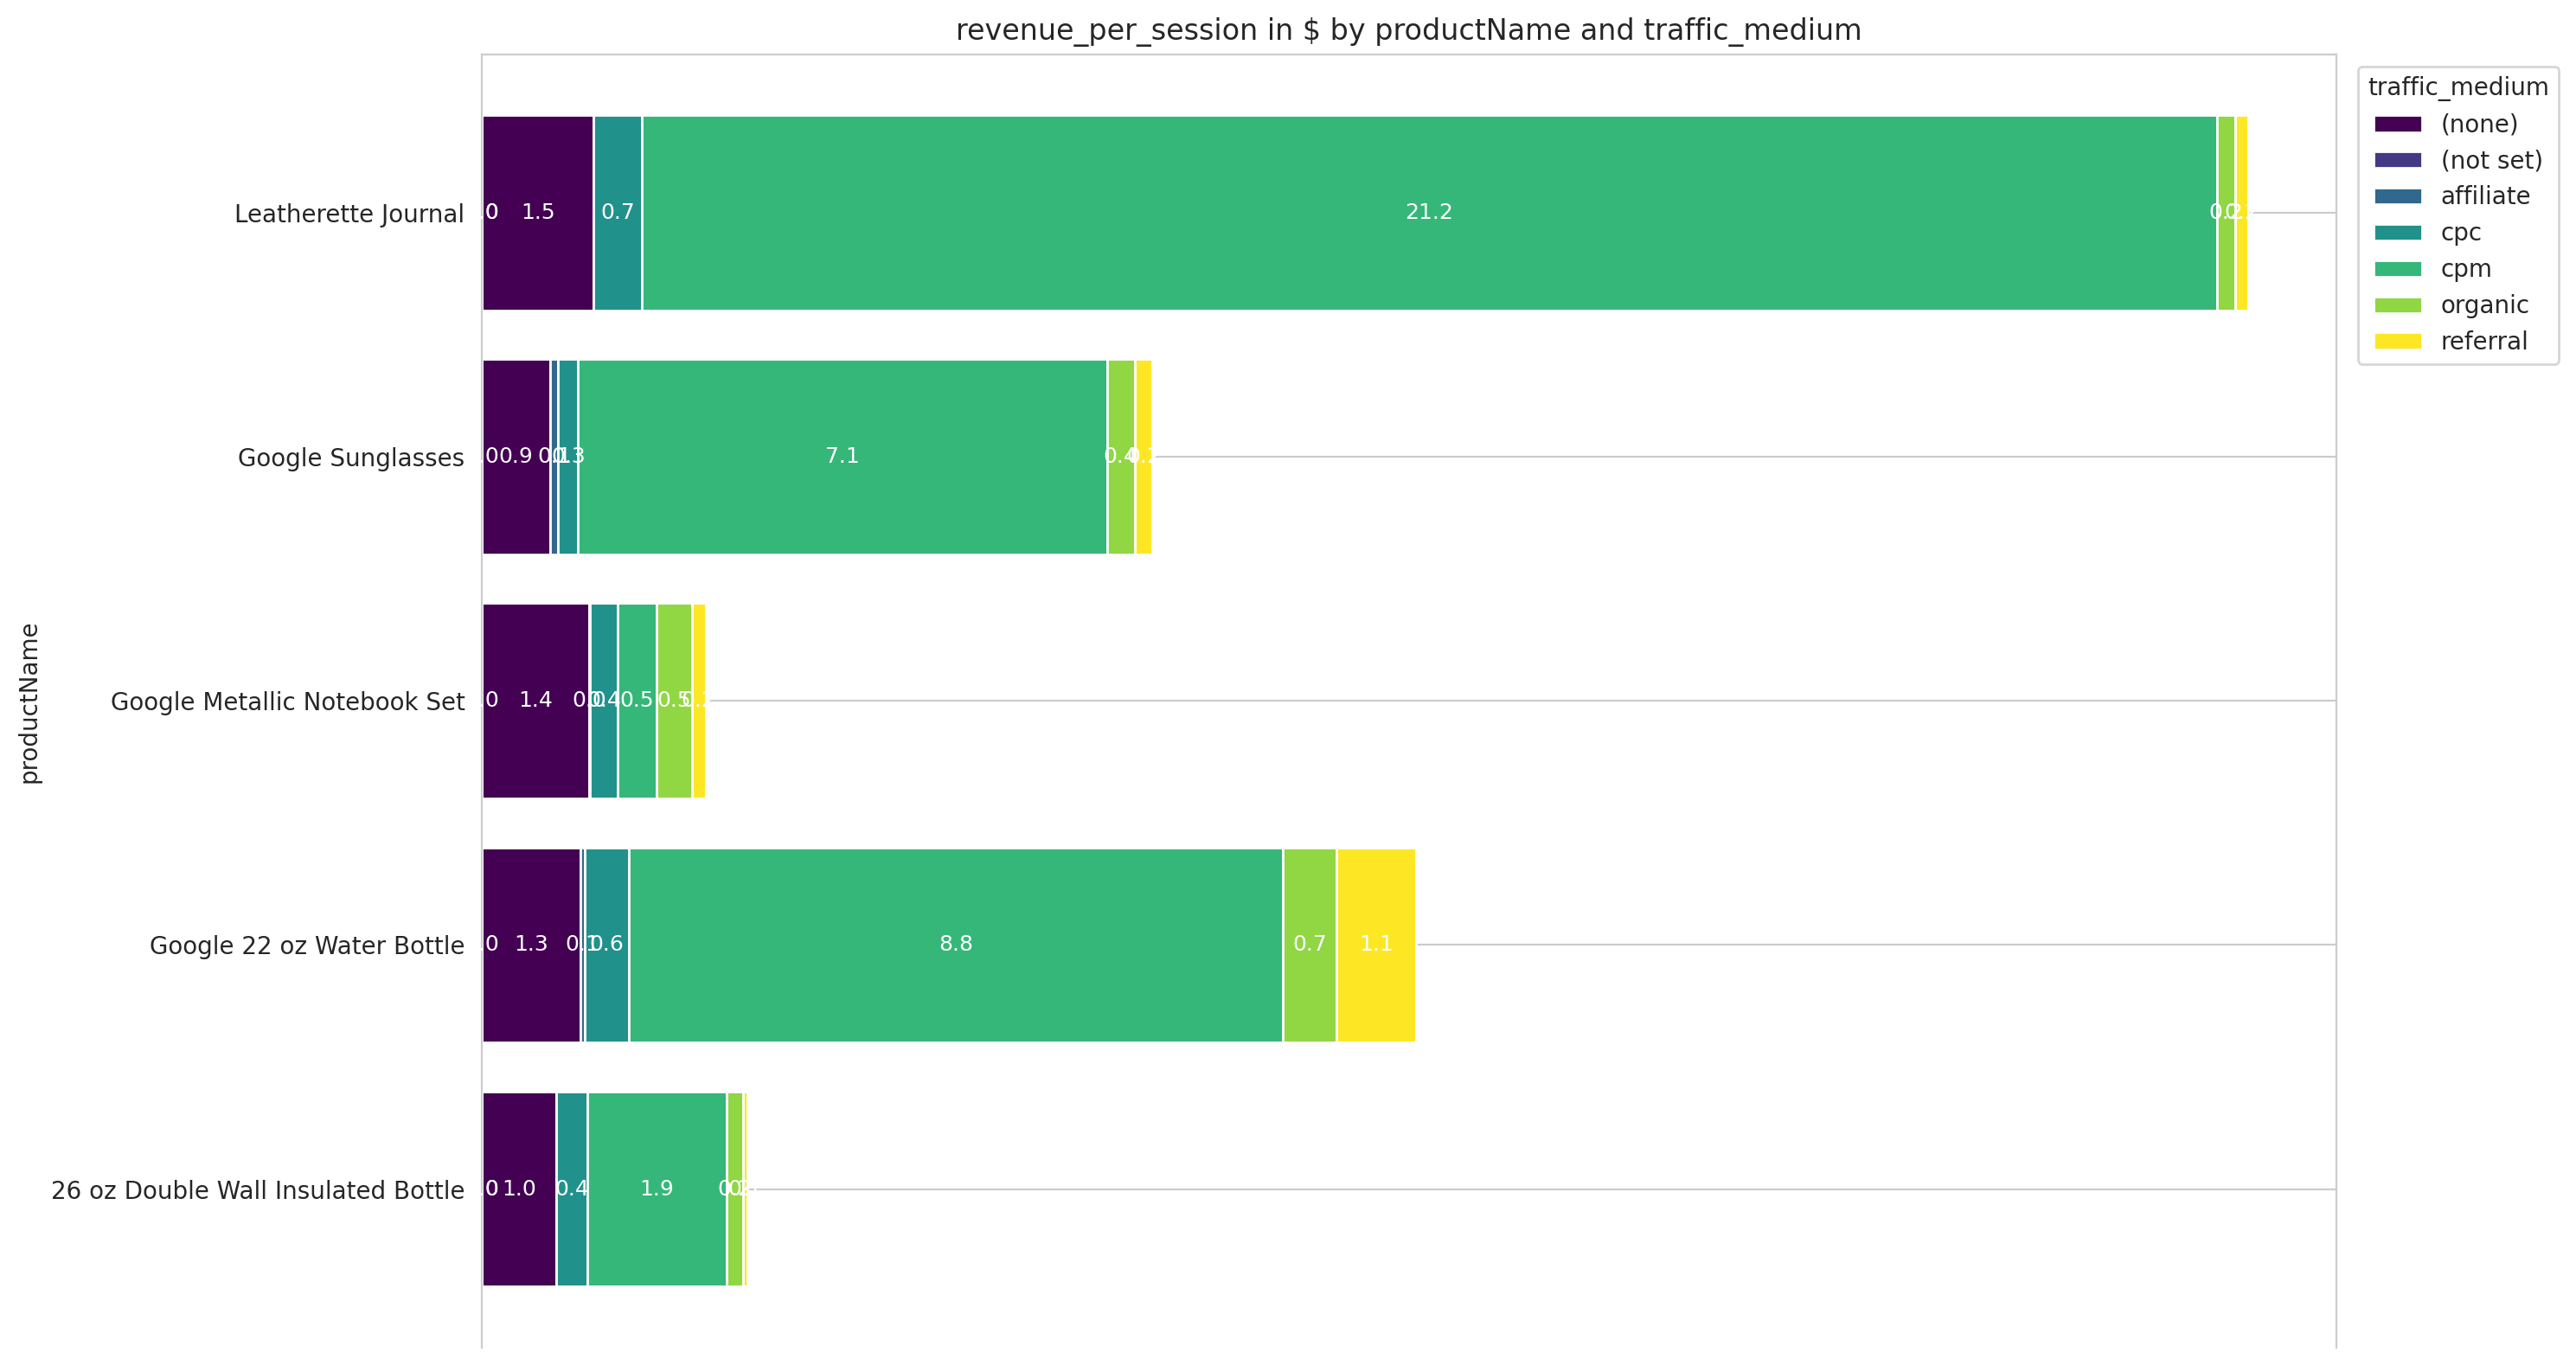

<Figure size 1500x800 with 0 Axes>

In [83]:
hier_analysis(data.loc[data['productName'].isin(top_rev) ,:] , [  'productName', 'traffic_medium' ] , revenue_agg , name  )

<Figure size 1200x500 with 0 Axes>

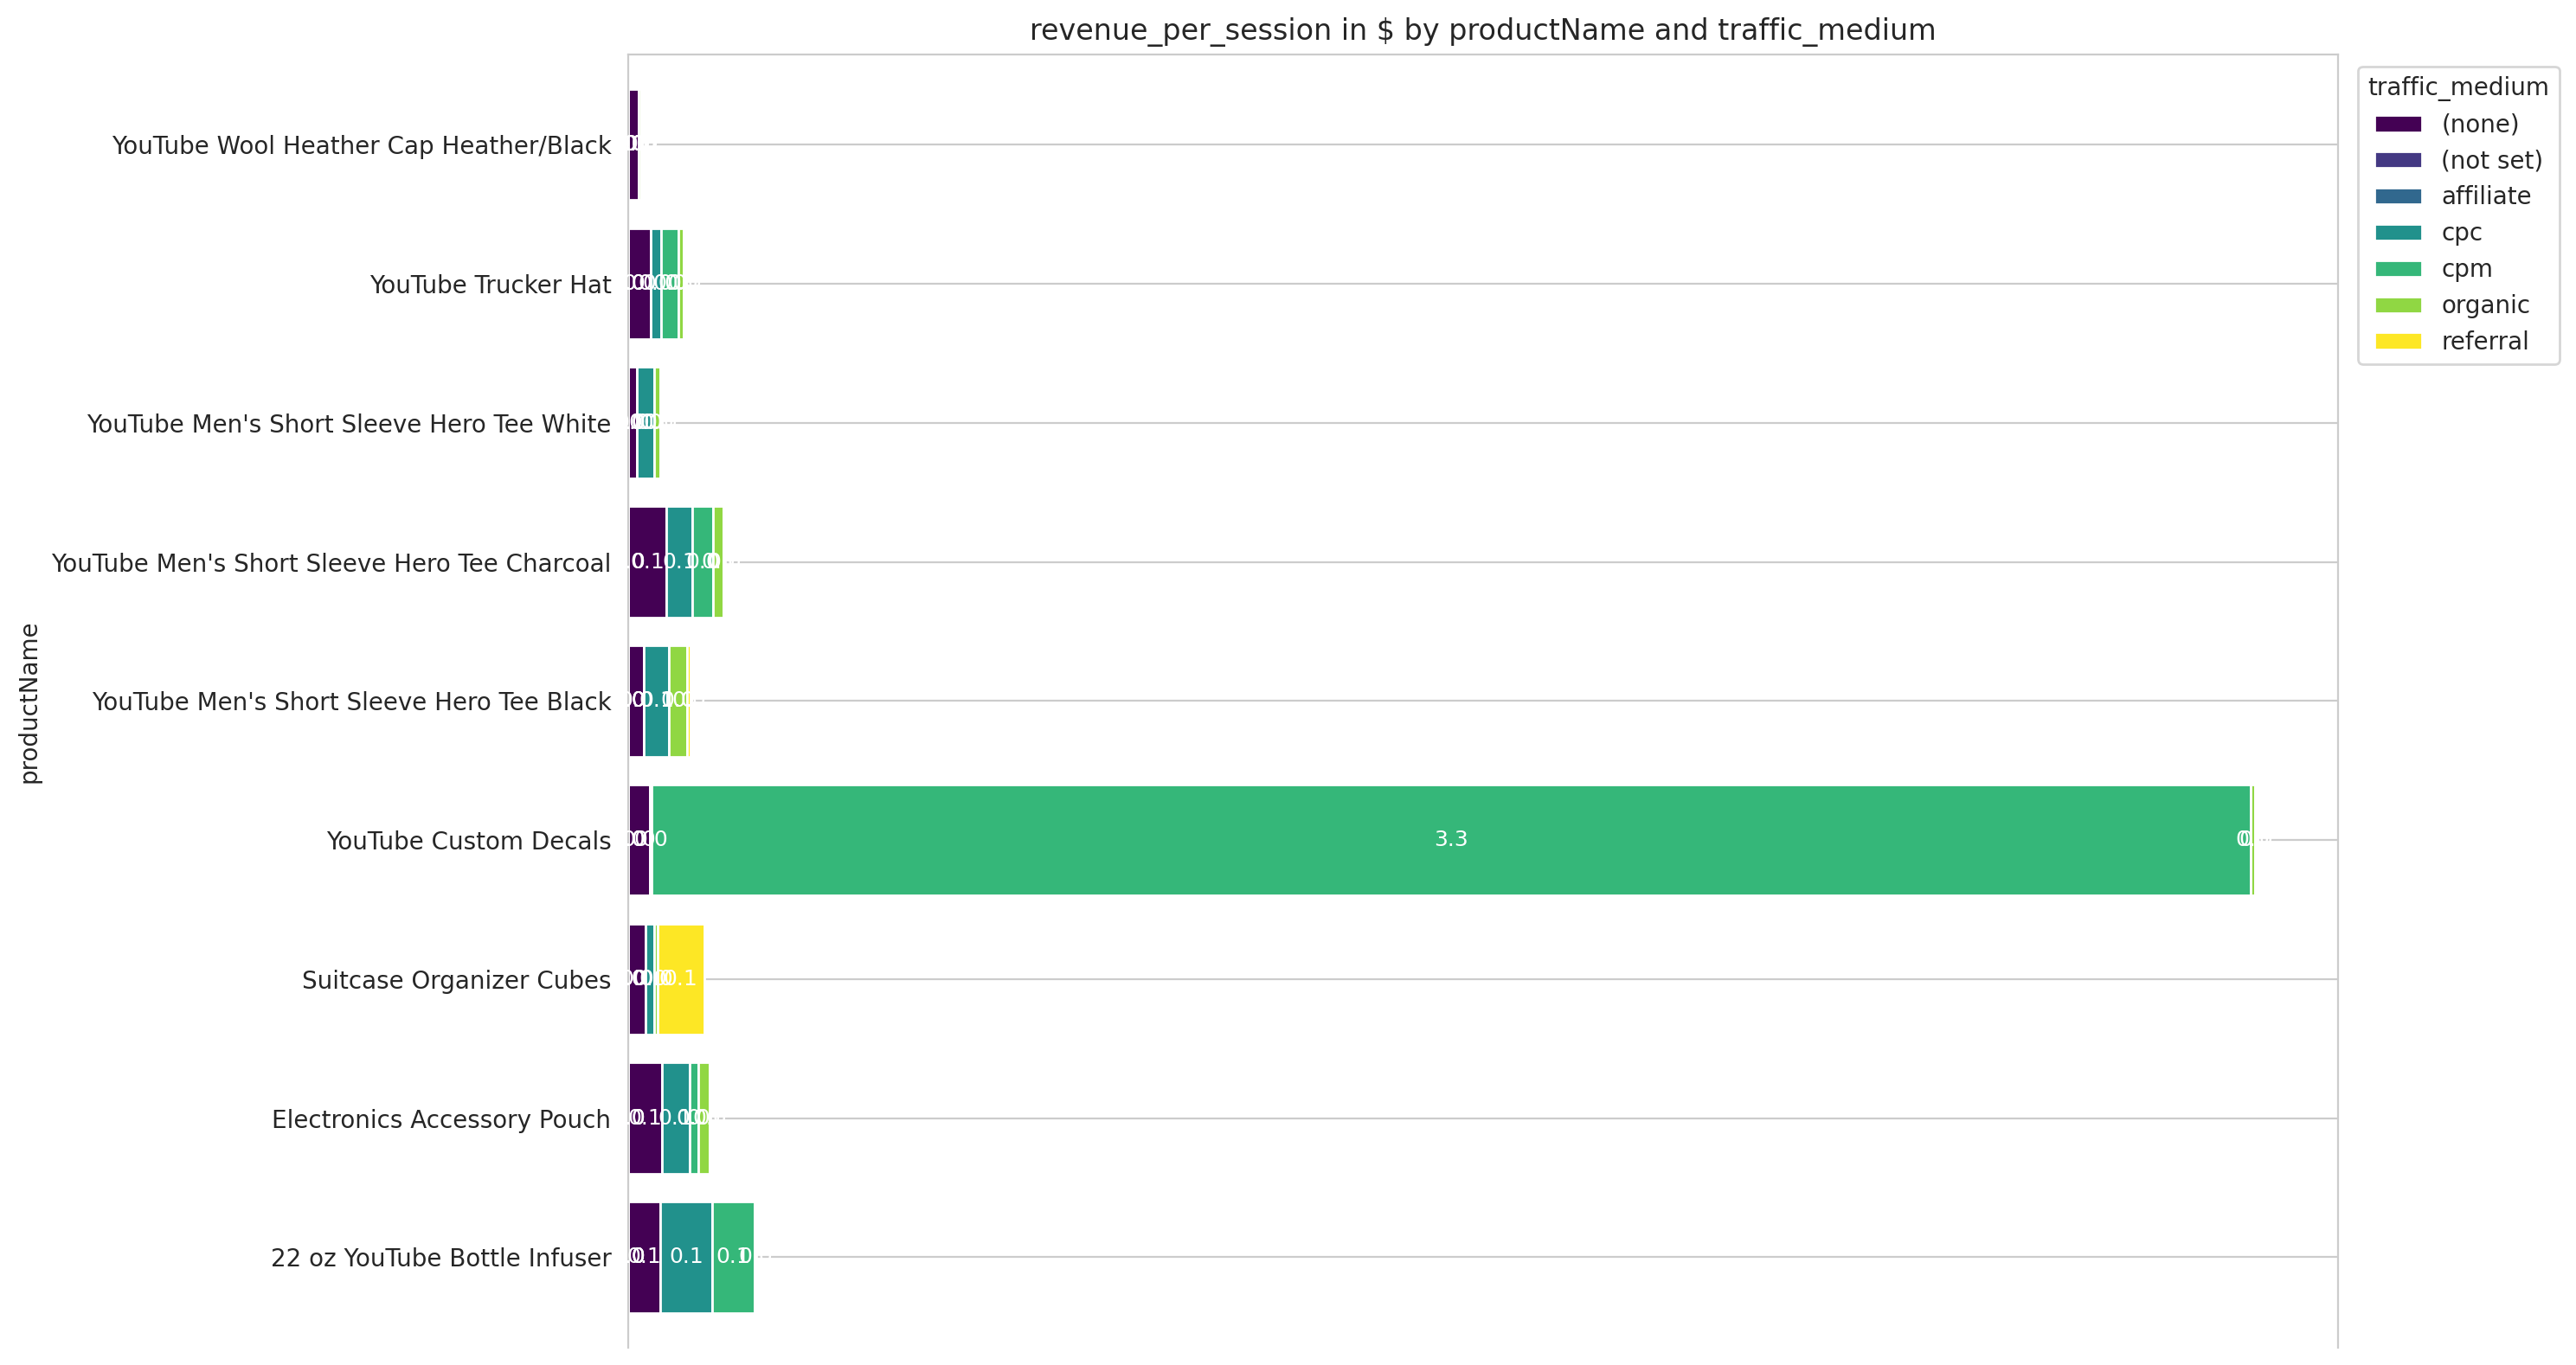

<Figure size 1500x800 with 0 Axes>

In [84]:
hier_analysis(data.loc[data['productName'].isin(list(least_effecient_products['productName'])) ,:] , [  'productName', 'traffic_medium' ] ,  revenue_agg , name  )

Comparing most effecient products , to the least effecient ones , we see that the most clear difference is the failure of CPM traffic medium among least ones , the largest revenue per session among these products is "Youtube custom decals" with 3.27.

**By time**

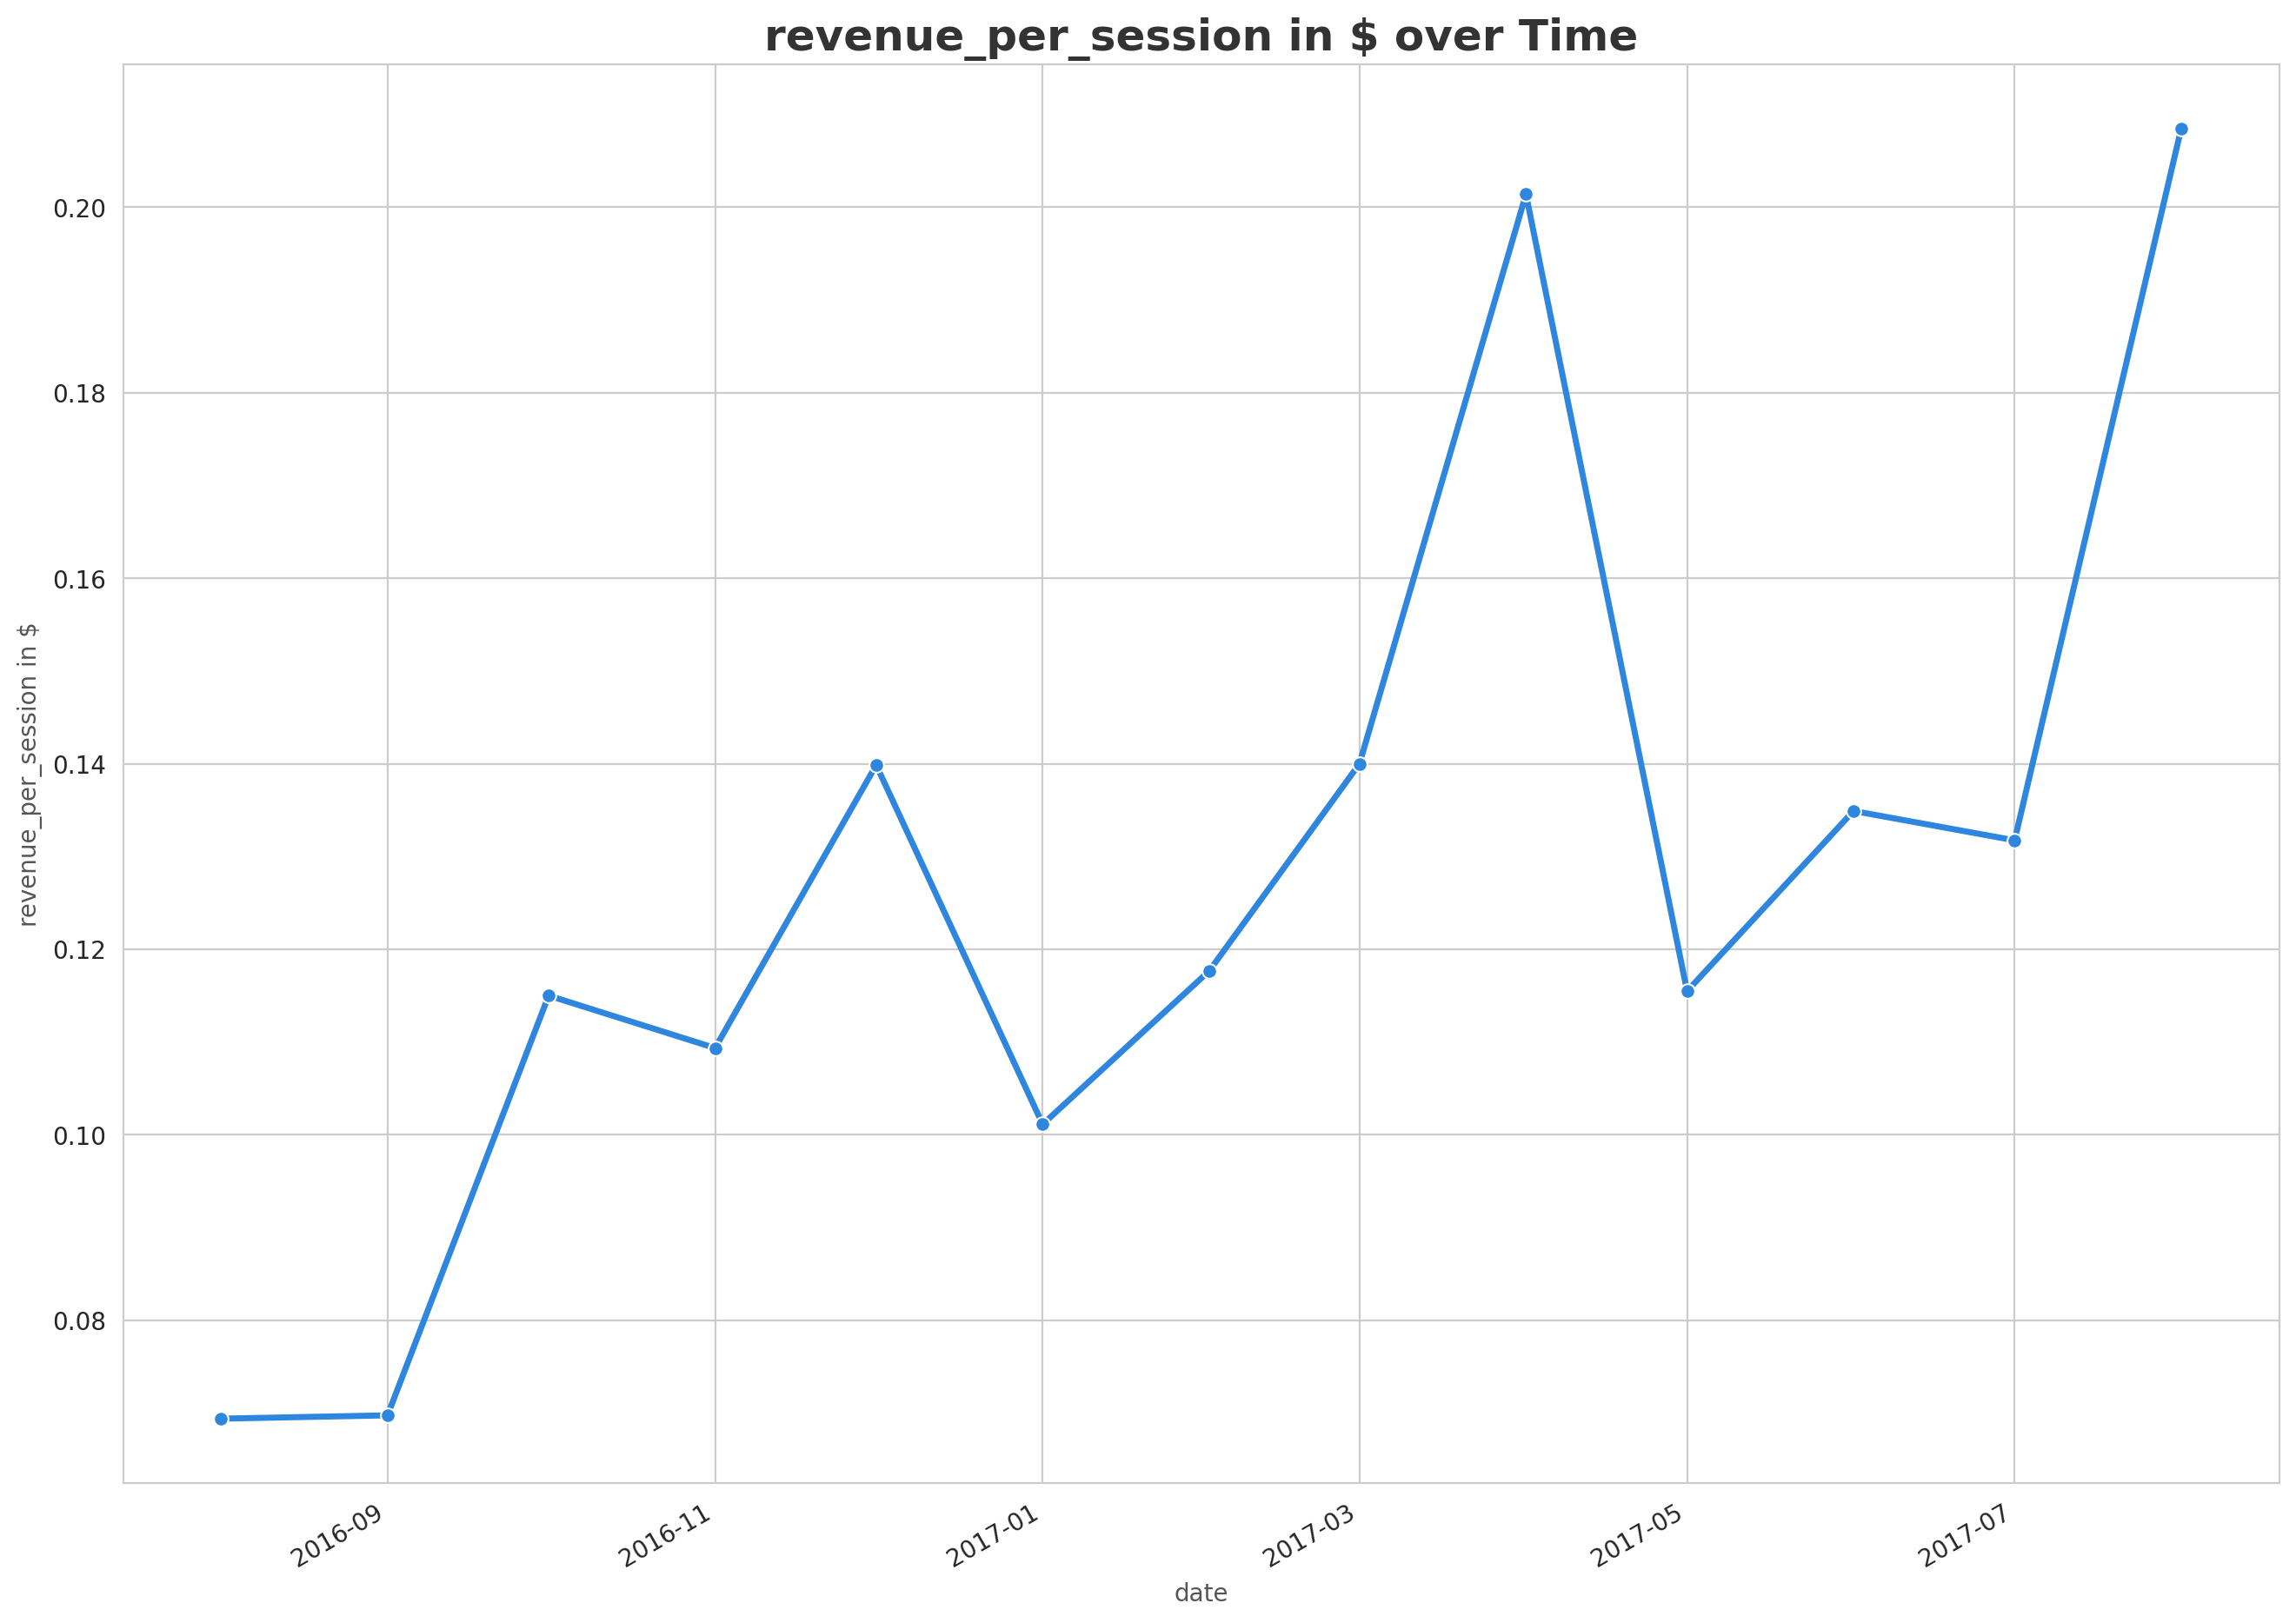

In [85]:
hier_analysis(data , [  'date' , ] , revenue_agg , name , figsize=(16,12))

We find that revenue per session has a positive trend over time, but peaks generally are in the season of Holidays , march , and summer seasons.

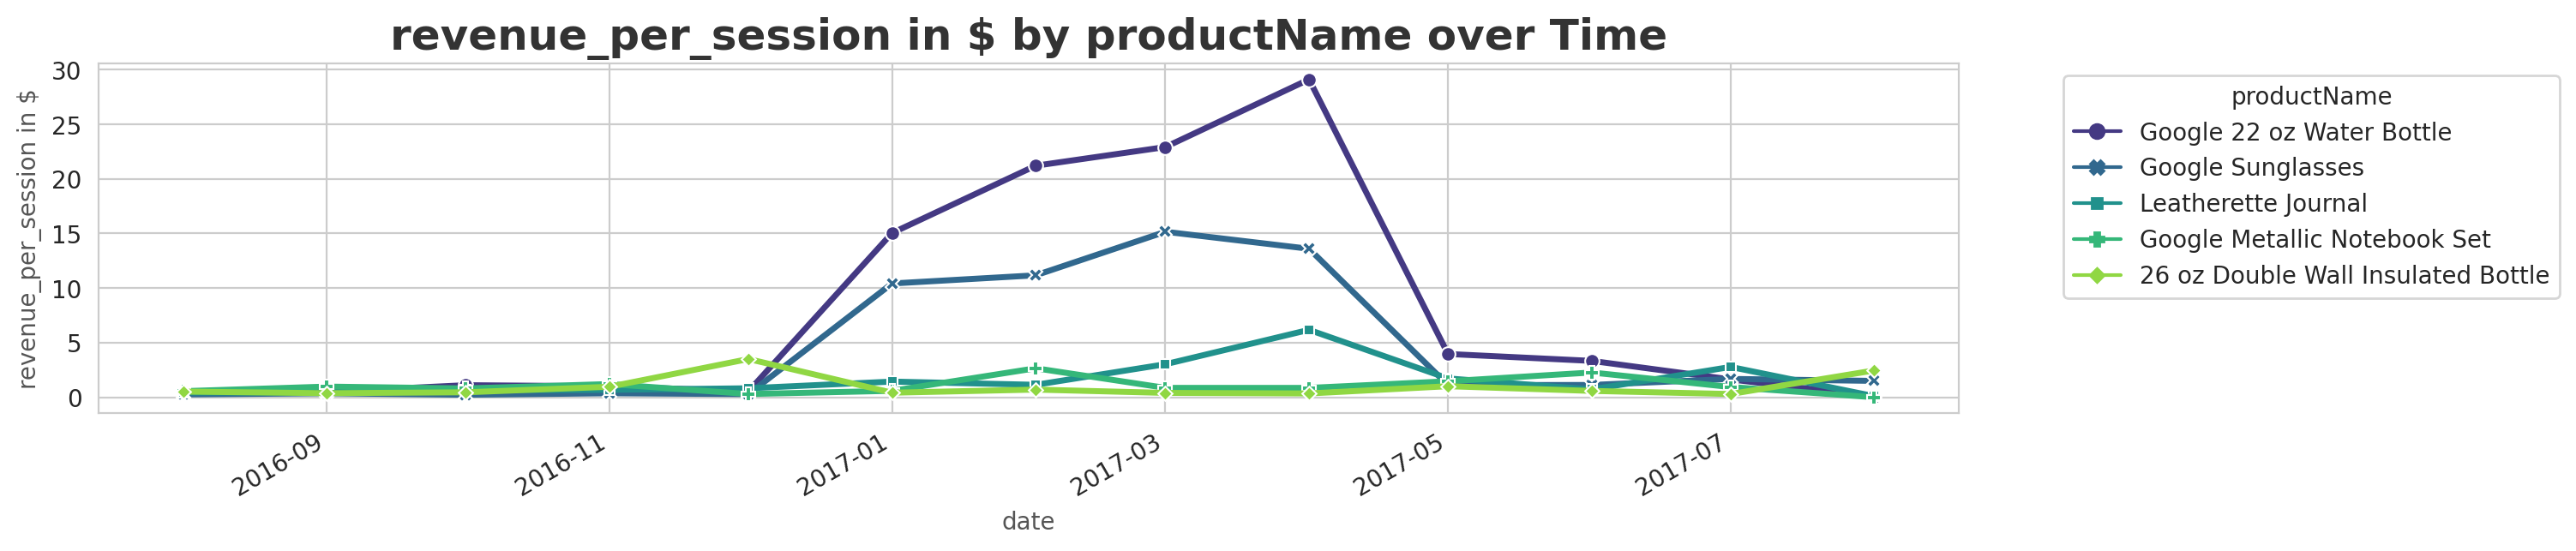

In [86]:
hier_analysis(data.loc[data['productName'].isin(top_rev) ,:] , [  'date',  'productName'  ] , revenue_agg , name  )

Especially in summer seasons with google products of water bbottle and sun glasses , clear due to weather.


<Figure size 1200x300 with 0 Axes>

<Figure size 1200x300 with 0 Axes>

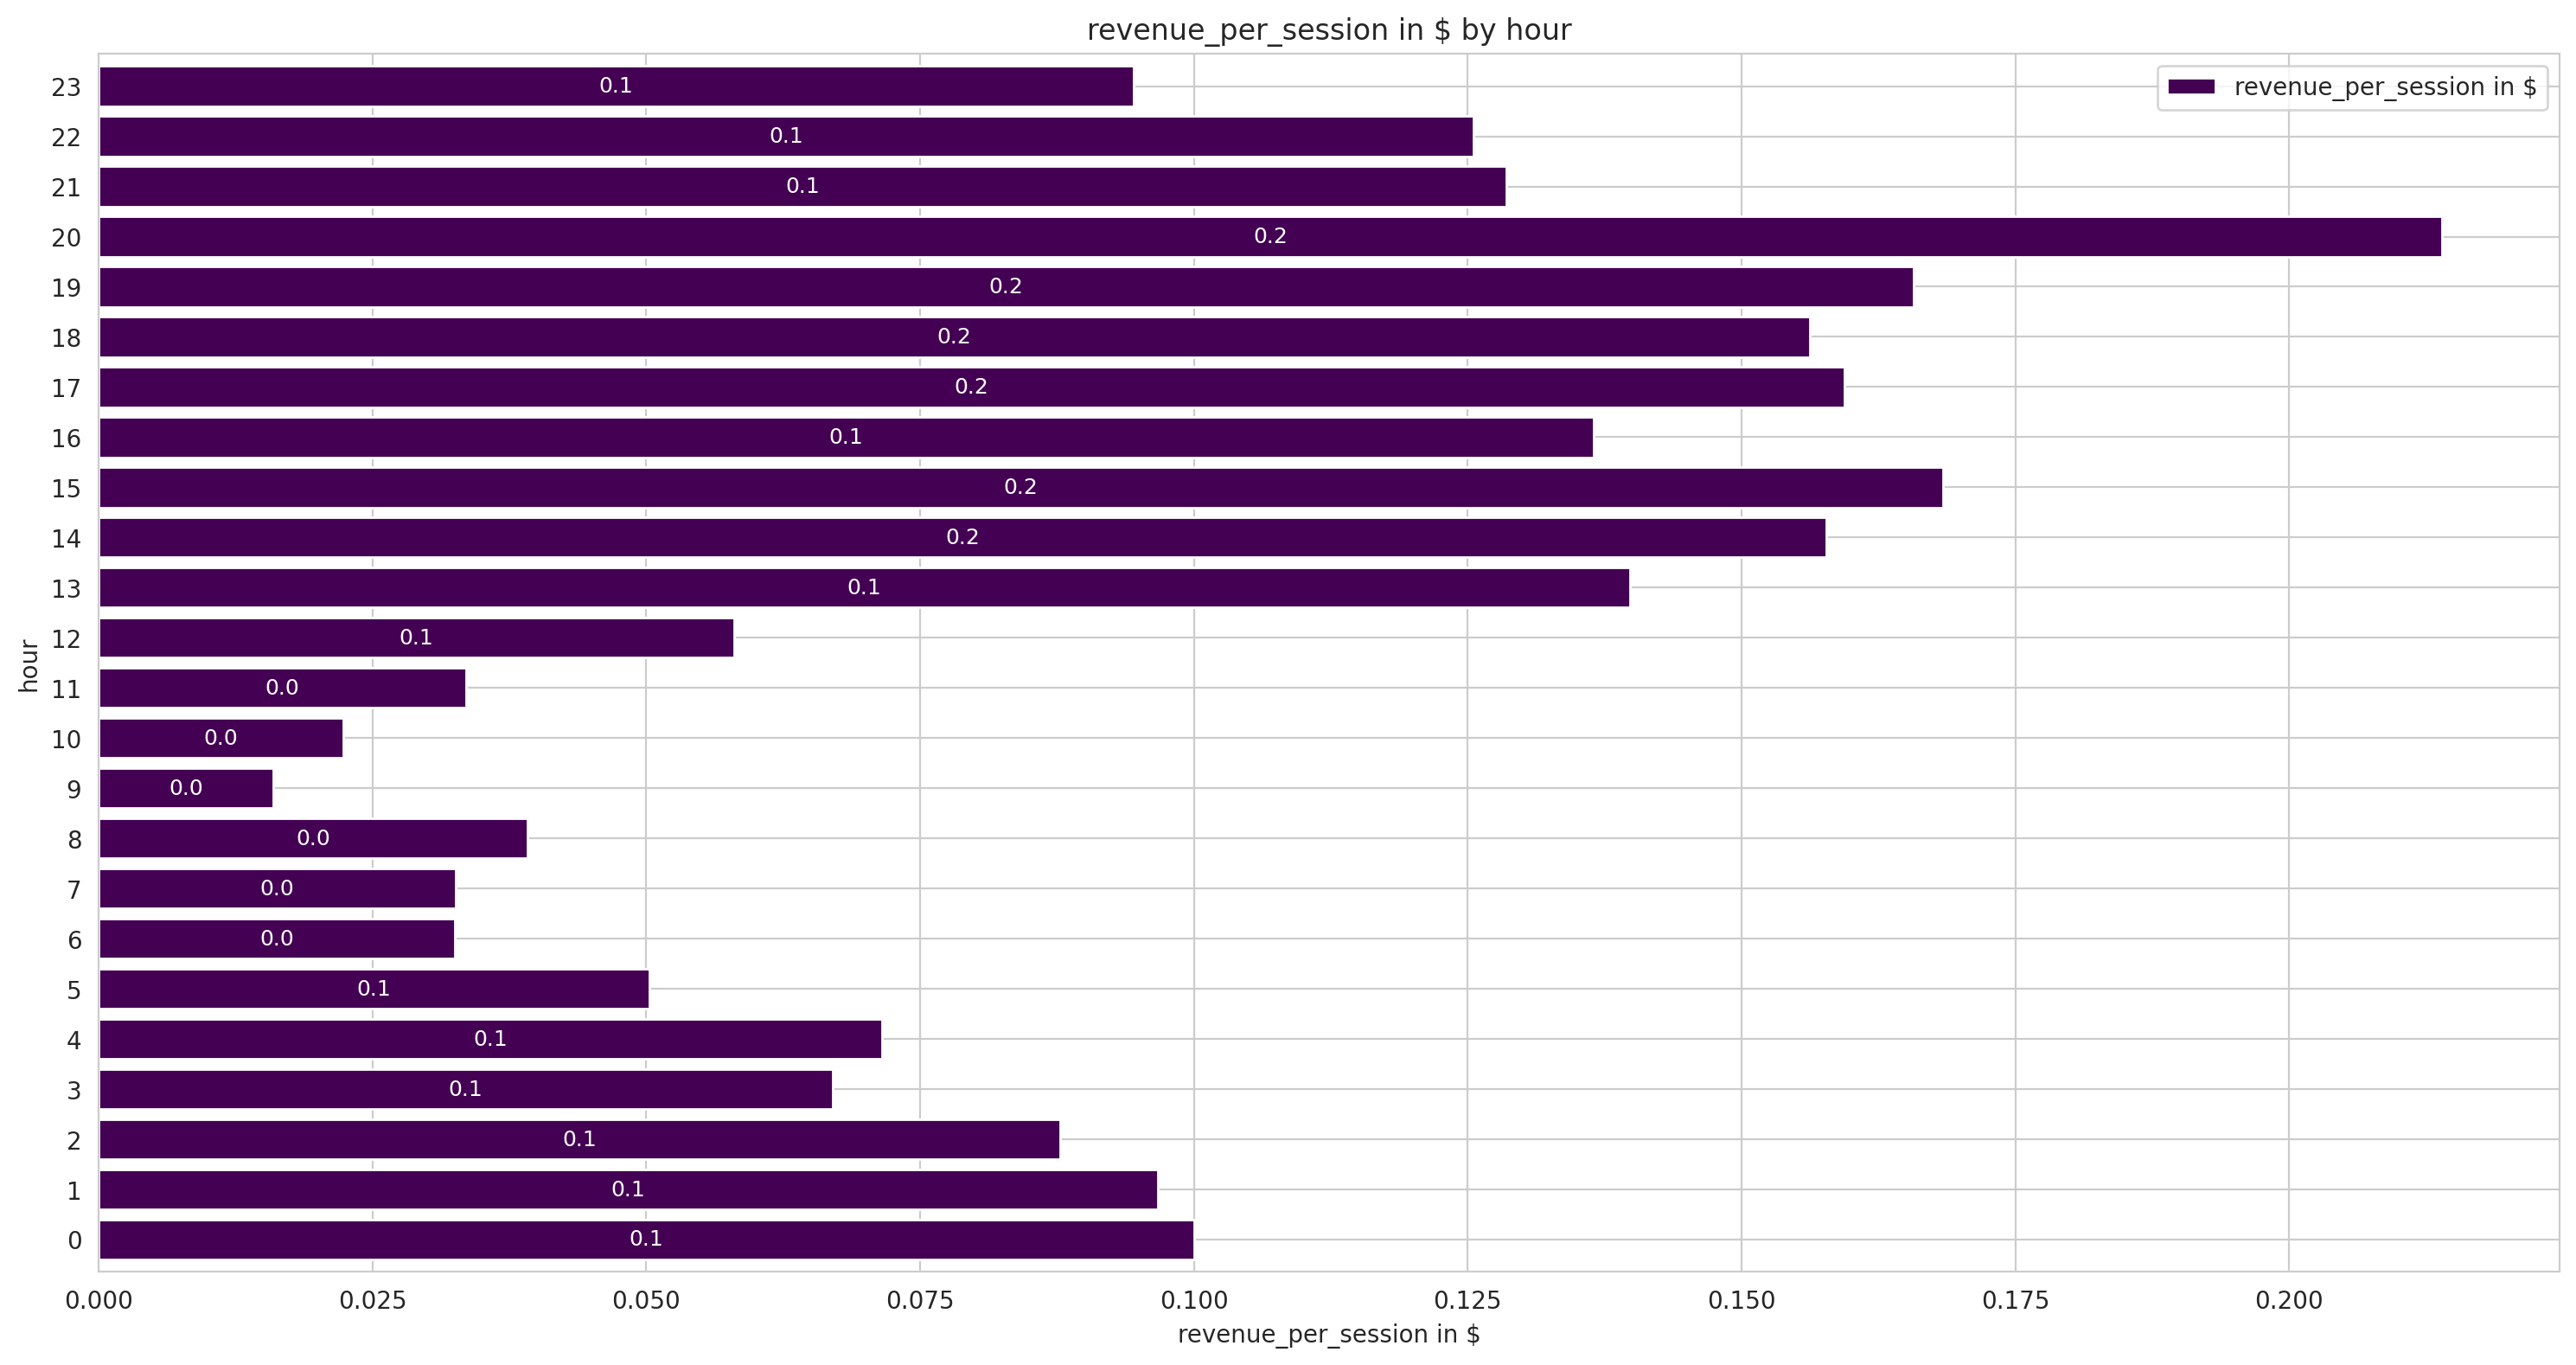

<Figure size 1500x800 with 0 Axes>

In [87]:
hier_analysis(data , [  'hour' , ] , revenue_agg , name  )

Clarifying what we found above of lack of traffic and serious E shopping in hours of work from 6:00 am to 1:00 PM

**Executive summary for revenue per session Statistics**

1 - Largest revenue per session is from traffic from CPM medium

2- Successful products distinguish most clearly with the higher rate of revenue per session compared to least successful ones.


3 - least revenue in Early morning due to way to work and early work hours


4- most revenue in summer and new year holidays.



# Geographic Analysis

We plot map of world based on

In [88]:
revenue_per_country = data.merge(right=cities[['country' ,'iso3' ]].drop_duplicates() , on ='country' , how = 'left' ).groupby(['country' ,'iso3' ])['total_revenue'].sum().reset_index()

In [89]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [90]:
world_with_data = world.merge(revenue_per_country, left_on='iso_a3', right_on='iso3', how='left')


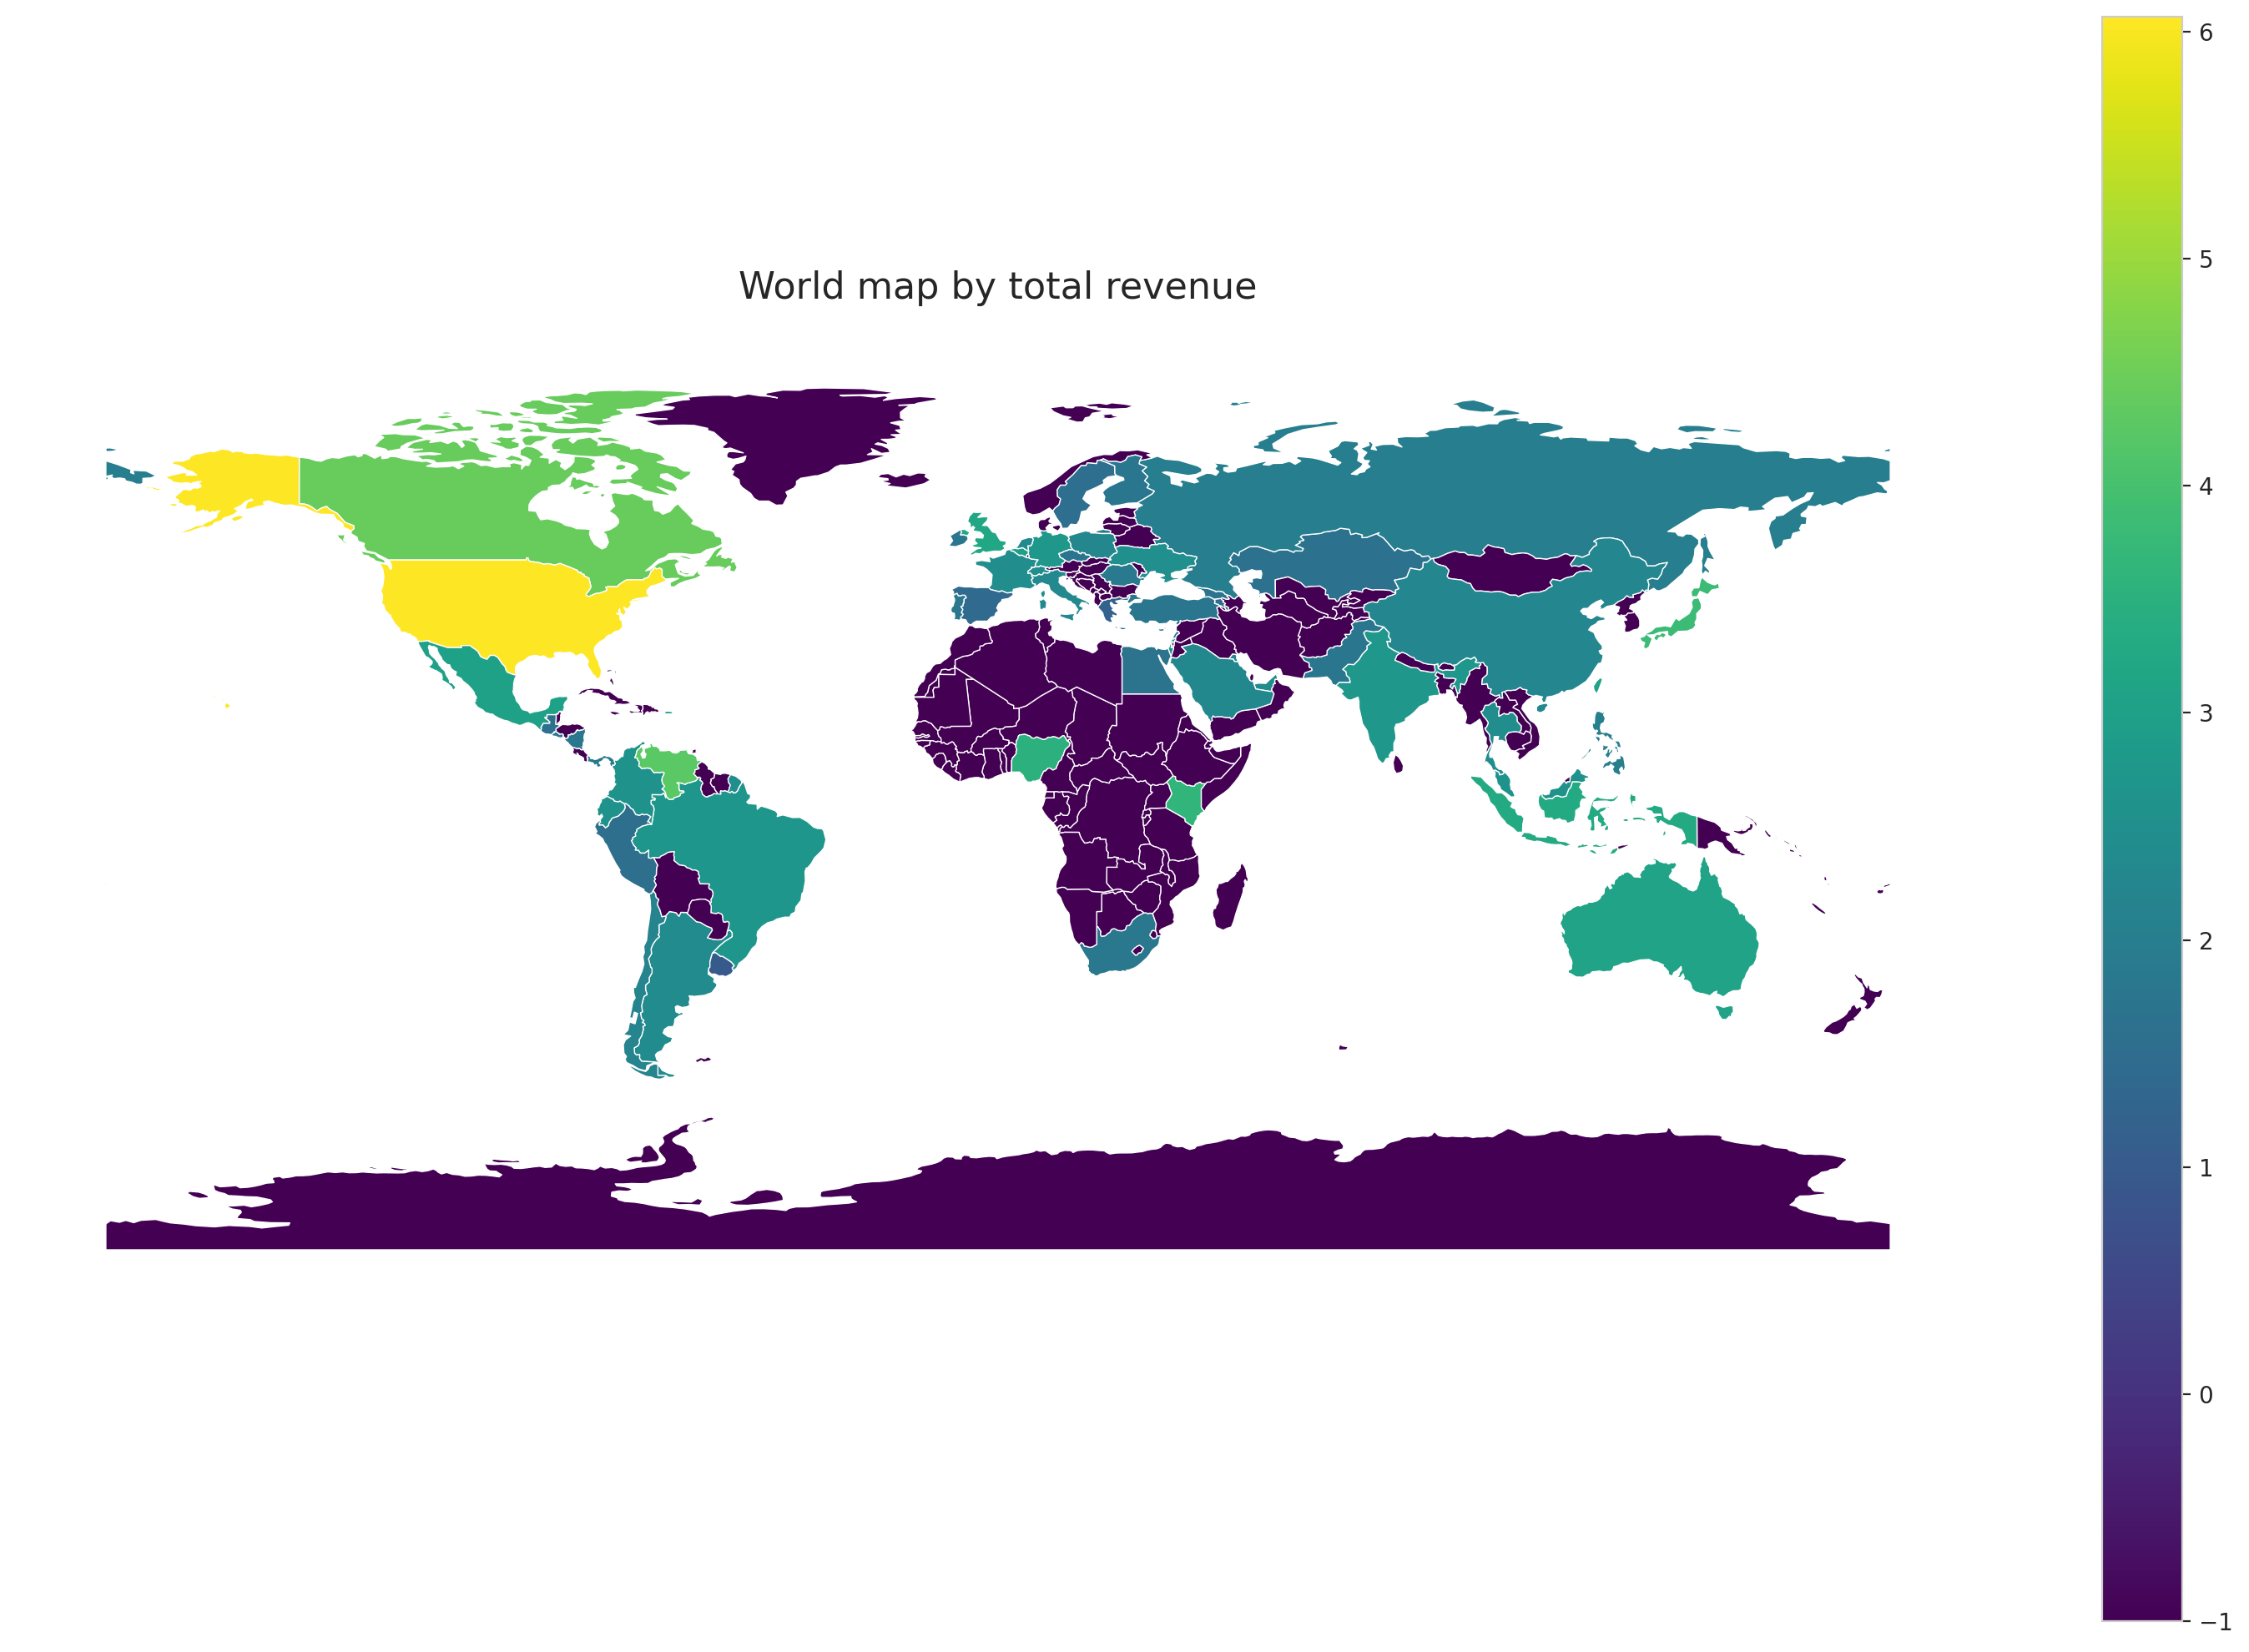

In [91]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
log_values = world_with_data["total_revenue"].fillna(0) + 0.1
world_with_data_log = world_with_data.copy()
world_with_data_log['log_values'] = np.log10(log_values)


# Plot countries with data
world_with_data_log.plot(column="log_values", 
                    ax=ax, 
                    legend=True,
                    cmap='viridis',
                    missing_kwds={'color': 'lightgray'},
                    edgecolor='white',
                    linewidth=0.5)

ax.set_title("World map by total revenue", fontsize=16, pad=20)
ax.set_axis_off()  # Remove axes for cleaner look

plt.tight_layout()
plt.show()

We find that the most revenue comes from USA , and Canada followed by UK , West Africa and Mexico.

This is Expected , generally western citizen are more familiar with google products and can afford cargo charges unlike people from Middle east and East Europe